# Análisis exploratorio de datos

**Trabajo Fin de Máster · Big Data y Data Science**
Predicción del precio horario del mercado diario español y optimización de un sistema de
almacenamiento

Capa bronce · 58.319 horas · enero de 2020 a agosto de 2026

---

Este cuaderno **describe y diagnostica**. No modifica ningún valor del conjunto de datos.

Su finalidad es doble: verificar que las fuentes seleccionadas son las adecuadas y que el
conjunto reúne la calidad necesaria, y caracterizar el problema de predicción antes de abordar
la ingeniería de variables y el modelado.

## Qué establece este análisis

Un análisis exploratorio no es un inventario de gráficos: es la cadena de comprobaciones que
justifica las decisiones de las fases siguientes. Éstas son las cinco que sostiene, con la cifra
que las respalda y el apartado donde se demuestran.

**1. El problema cambió de naturaleza durante el propio período de entrenamiento.** El perfil
horario del precio se ha invertido —la hora barata pasa de la madrugada al mediodía— y las horas
de precio nulo o negativo, inexistentes hasta 2023, superan las ochocientas al año. Un modelo
entrenado sobre el histórico completo con igual peso aprende una estructura que ya no existe.
*(3.3, 3.4)*

**2. Ese cambio tiene una causa medible, y por tanto es una variable.** La potencia fotovoltaica
instalada explica la profundidad del hueco de precio del mediodía con una correlación de −0,86
**medida dentro de cada mes del calendario**, negativa en los doce. No es tendencia compartida.
La no estacionariedad deja así de ser una limitación que soportar y pasa a ser un efecto que se
puede incorporar como regresor. *(6.4)*

**3. La restricción operativa descarta la mayor parte de la información disponible.** El modelo
debe emitir su predicción a las 12:00 del día D, y en ese instante sólo **20 de las 82 variables
numéricas** existen; de las quince más asociadas al precio, únicamente tres. Casi todo lo que
mejor correlaciona con el precio es consecuencia de la misma casación que lo forma. *(4.2)*

**4. Lo que queda son previsiones, y su error es el suelo del modelo.** Las variables utilizables
no son magnitudes observadas: la previsión de eólica yerra 772 MW de media y la de solar 547, con
sesgo sistemático en ambas. Ningún algoritmo recupera información que la entrada no contiene.
*(5.1)*

**5. Existe una referencia económica que el modelo debe superar.** Una regla horaria fija, sin
modelo alguno, captura el **71 % del arbitraje máximo** obtenible con previsión perfecta. Ese
margen restante —y no el error absoluto medio— es la vara con la que se mide si el trabajo
aporta algo. *(7.4)*

Además quedan documentadas **cuatro incidencias de calidad con su corrección** y **tres
verificaciones que no se han podido cerrar**, enumeradas en el bloque 9 junto con las líneas de
análisis que el conjunto de datos disponible no permite ejecutar.

## Dónde termina este cuaderno y empieza el siguiente

El análisis exploratorio y la ingeniería de variables son dos actividades distintas y se
documentan por separado, siguiendo la separación que el máster establece entre la depuración
(`VinoDep.py`) y la selección de variables (`VinoSelecVar.py`):

| | `01_analisis_exploratorio` | `02_ingenieria_variables` |
|---|---|---|
| **Pregunta** | ¿Qué datos tengo, son correctos, y cómo es el fenómeno? | ¿Qué matriz construyo, con qué tratamiento, y qué sobrevive? |
| **Operación** | Describir, contrastar, medir | Corregir, imputar, derivar, transformar, seleccionar |
| **Sobre el dato** | No lo toca | Lo modifica y lo guarda |
| **Partición** | Sobre el conjunto completo, porque describe | Sólo sobre `train`, porque decide |
| **Produce** | Hallazgos con su consecuencia | Matriz de modelado y registro de decisiones |

La razón de que la partición aparezca en la tabla es metodológica y no organizativa. Describir
el conjunto completo es legítimo: se está caracterizando el fenómeno. **Elegir** una variable
mirando el conjunto completo no lo es: la elección se contagia de la partición de validación y
el rendimiento medido después queda inflado. Por eso todo lo que decide vive en el cuaderno
siguiente, después de la partición.

## Estructura

| Bloque | Contenido |
|---|---|
| **0** | Carga, verificación de integridad y frontera de disponibilidad |
| **1** | Contraste entre fuentes que miden la misma magnitud |
| **2** | Calidad del conjunto de datos |
| **3** | Caracterización del precio horario |
| **4** | Asociación entre las explicativas y el objetivo |
| **5** | Error heredado de las variables de entrada |
| **6** | El sistema eléctrico subyacente |
| **7** | El problema en términos económicos |
| **8** | Estructura del conjunto: redundancia y dimensionalidad |
| **9** | Hallazgos, alcance y traspaso a la ingeniería de variables |
| **10** | Láminas compuestas para la memoria |

## Criterios metodológicos

**La capa bronce no imputa.** No se corrigen valores atípicos, no se rellenan huecos y no se
transforman unidades. Los valores ausentes que aparecen en el análisis son información: en unos
casos responden al diseño de la unión —una tabla de frecuencia diaria aterriza únicamente en una
hora de cada veinticuatro— y en otros señalan huecos reales que se documentan. El tratamiento
corresponde a la capa siguiente.

**La asociación estadística no determina por sí sola la selección de variables.** El modelo
predice las veinticuatro horas del día D+1 y debe emitir su predicción a las 12:00 del día D,
momento en que se celebra la casación del mercado diario. Ante cualquier asociación intensa se
plantean dos preguntas independientes: cuál es su magnitud y si la variable estaba disponible en
ese instante. Únicamente la segunda determina si puede incorporarse al modelo.

---
# 0 · Carga, integridad y frontera de disponibilidad

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sys.path.insert(0, str(Path.cwd()))
import comun_tfm as cm
from comun_tfm import (PALETA, COLOR_FUGA, DIAS, TZ, APAGON, EXCEPCION, K_HORAS,
                       FRONTERA, fuga_de, v_cramer, corr_segura, clasificar_horas, Registro)

%matplotlib inline
cm.configurar_matplotlib()

# El registro sustituye a la lista global: cada hallazgo se anota donde se demuestra.
REG = Registro("HALLAZGOS DEL ANÁLISIS")

In [2]:
df = cm.cargar_bronce()

# Del bloque de materias primas se emplea el precio del gas del mercado iberico, que es la
# referencia de coste de la tecnologia que fija el precio marginal en el sistema español y
# la que mayor asociacion presenta con el objetivo. El resto de columnas del bloque quedan
# fuera del alcance del proyecto, y por tanto tambien de este analisis.
COMMODITIES = ("commodities_gas_mibgas",)
fuera_alcance = [x for x in df.columns
                 if x.startswith("commodities_") and x not in COMMODITIES]
if fuera_alcance:
    df = df.drop(columns=fuera_alcance)
    print(f"Fuera de alcance ({len(fuera_alcance)}): {fuera_alcance}")

print(f"{df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Rango: {df['ts_utc'].min()} → {df['ts_utc'].max()}")
print("Integridad: una fila por hora, sin duplicados.")

Fuera de alcance (2): ['commodities_co2_eua_dec', 'commodities_gas_ttf_m1']
58,319 filas × 102 columnas
Rango: 2019-12-31 23:00:00+00:00 → 2026-08-26 21:00:00+00:00
Integridad: una fila por hora, sin duplicados.


In [3]:
# Columnas y drivers resueltos una sola vez, en el módulo compartido.
COLS = cm.resolver_columnas(df)
globals().update(COLS)          # P, DEM, EOL, FV, HID, CCGT, GAS, CO2, T2M, ...

# El resolutor puede apuntar a una columna del bloque de materias primas que queda fuera de
# alcance. Se reapunta al gas iberico, que ademas es el que mayor asociacion presenta con el
# precio, y el derecho de emision deja de estar disponible como driver.
GAS = cm.pick(df, "commodities_gas_mibgas")
CO2 = None
COLS.update({"GAS": GAS, "CO2": CO2})

DRIVERS = cm.drivers_de(df, COLS)
DRIVERS = {k: v for k, v in DRIVERS.items() if v[0] in df.columns}

NORMAL = df[df["regimen"] == "normal"]
print(f"Objetivo: {P} · {len(DRIVERS)} drivers resueltos · "
      f"{len(NORMAL):,} horas en régimen normal")
print(f"Gas: {GAS}")

Objetivo: spot_es_esios · 10 drivers resueltos · 44,543 horas en régimen normal
Gas: commodities_gas_mibgas


## 0.1 · La frontera de disponibilidad

Se declara **antes** de mirar ninguna correlación, para que ningún resultado bonito la modifique
a posteriori.

En este cuaderno la frontera sólo **colorea** los resultados: sirve para leer cada asociación
sabiendo si la variable existía en el momento de predecir. Quien la aplica como **filtro** es el
cuaderno de ingeniería de variables, que importa esta misma tabla del módulo compartido para que
las dos versiones no puedan divergir.

In [4]:
FRONTERA

,tabla,veredicto,motivo
0,spot_price (España),TARGET,"Casación a las 12:00 de D, publicación ~12:45"
1,spot_price (11 zonas),CON FUGA,Casación SDAC simultánea: el de D+1 no existe ...
2,forecast (REE),SIN FUGA,Publicada antes de las 11:00 de D-1 (Circular ...
3,entsoe_forecast_da,SIN FUGA*,Se reescribe hacia atrás: ver bloque 2.6 del EDA
4,ecmwf_forecast_agg,SIN FUGA*,Sin histórico: ventana móvil de días. Ver bloq...
5,esios_capacity_available,CONDICIONAL,D-01: el valor guardado conoce el propio día
6,era5_weather_agg,CON FUGA,"Reanálisis: el tiempo que ocurrió, no el previsto"
7,generation / load_inter,CON FUGA,Real: a las 12:00 sólo han pasado las horas 00-11
8,esios_pdbc_gen,CON FUGA,Misma casación que el precio: circular
9,commodities / trayport,DESFASE D-2,"Cierran ~17:30, tras el cierre eléctrico"


---
# 1 · ¿Son correctas las fuentes elegidas?

Varias magnitudes están medidas por dos organismos que no siempre coinciden. Este bloque
contrasta con evidencia propia las decisiones tomadas durante la ingesta, en lugar de citarlas.

Una decisión heredada sin verificar es una cita a una conversación; con evidencia, es un
resultado.

## 1.1 · El agregado de gas de ENTSO-E no es el ciclo combinado de ESIOS *(D-02)*

`entsoe_gas_mw` corresponde a la categoría B04 de ENTSO-E, que agrupa ciclo combinado y
cogeneración. ESIOS los separa. Si la suma de ESIOS reproduce el B04, las fuentes son
equivalentes; si además el desfase entre ambas cambia con el tiempo, no se puede usar una en
entrenamiento y otra en validación.

In [5]:
if GAS_ENT and CCGT and OTHERTH:
    g = df[[GAS_ENT, CCGT, OTHERTH, "anio"]].dropna()
    g["suma_esios"] = g[CCGT] + g[OTHERTH]
    g["dif"] = g[GAS_ENT] - g["suma_esios"]
    print(f"Correlación B04 vs (CCGT + otras térmicas): {g[GAS_ENT].corr(g['suma_esios']):.4f}")
    print(f"Diferencia media: {g['dif'].mean():,.0f} MW\n")
    display(g.groupby("anio")["dif"].agg(["mean", "std"]).round(0).T)
    deriva = g.groupby("anio")["dif"].mean()
    REG.anotar("D-02", "entsoe_gas_mw agrega CCGT y cogeneración con desfase no estable",
               "confirmado",
               f"La diferencia media se mueve entre {deriva.min():,.0f} y {deriva.max():,.0f} MW "
               "según el año. Usar las columnas de ESIOS por separado y descartar el agregado.")

Correlación B04 vs (CCGT + otras térmicas): 0.9963
Diferencia media: -374 MW



anio,2020,2021,2022,2023,2024,2025,2026
mean,-806.0,-558.0,-341.0,-257.0,-222.0,-177.0,-192.0
std,135.0,200.0,218.0,182.0,177.0,186.0,75.0


  [D-02] confirmado: entsoe_gas_mw agrega CCGT y cogeneración con desfase no estable


## 1.2 · El autoconsumo entra en las series de ESIOS desde diciembre de 2025 *(D-03)*

Si una serie cambia de perímetro a mitad del histórico deja de medir lo mismo antes y después.
El modelo aprendería el cambio de definición como si fuera un cambio del sistema.

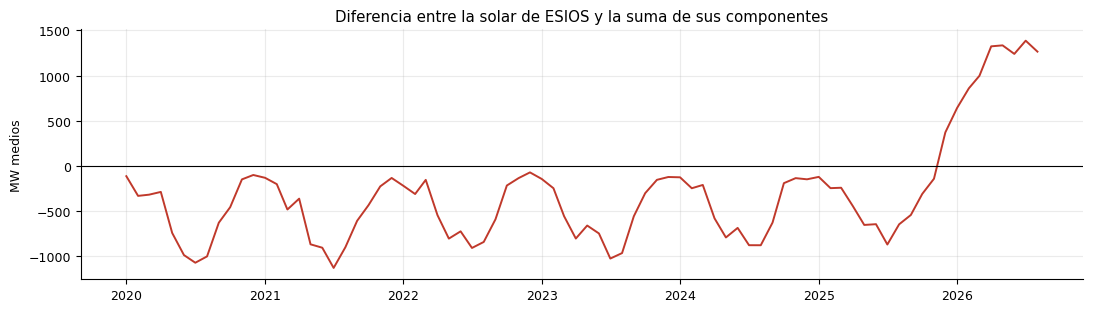

Diferencia media en los 6 últimos meses: 1,258 MW
Diferencia media en el resto del histórico: -447 MW
  [D-03] confirmado: esios_gen_ree_gsolar_mw cambia de perímetro (incorpora autoconsumo)


In [6]:
if SOLREE and SOLTER and FV:
    s = df[["mes_p", SOLREE, SOLTER, FV]].dropna()
    m = s.groupby("mes_p").mean()
    m["dif ESIOS − calc"] = m[SOLREE] - m[SOLTER] - m[FV]

    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(m.index.to_timestamp(), m["dif ESIOS − calc"], lw=1.4, color=PALETA["alerta"])
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("MW medios"); ax.set_xlabel("")
    ax.set_title("Diferencia entre la solar de ESIOS y la suma de sus componentes")
    plt.tight_layout(); plt.show()

    reciente = m["dif ESIOS − calc"].tail(6).mean()
    previo = m["dif ESIOS − calc"].head(-6).mean()
    print(f"Diferencia media en los 6 últimos meses: {reciente:,.0f} MW")
    print(f"Diferencia media en el resto del histórico: {previo:,.0f} MW")
    if abs(reciente - previo) > 200:
        REG.anotar("D-03", "esios_gen_ree_gsolar_mw cambia de perímetro (incorpora autoconsumo)",
                   "confirmado",
                   "Usar calc_solar_fv_mw, que mantiene el perímetro constante en todo el "
                   "histórico. Descartar la columna de ESIOS y, por el mismo motivo, "
                   "load_inter_ree_load.")

,min,max
anio,,
2020,25.6,457.0
2021,481.7,752.2
2022,800.0,1700.4
2023,1991.2,3719.3
2024,4011.3,6433.6
2025,6696.7,8472.2
2026,8560.5,9125.0


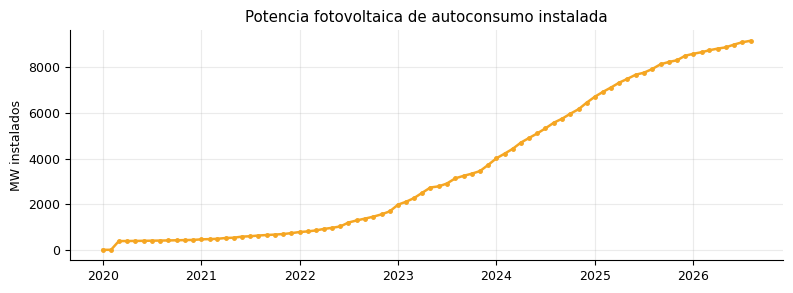

Crece de 26 a 9,125 MW de forma sostenida, y por una vía independiente: esta tabla de potencia instalada no
interviene en la resta de series horarias del apartado anterior, de modo que
respalda la misma conclusión desde un origen distinto. El cambio de perímetro
tiene una causa física identificable y no es un artefacto del cálculo.


In [7]:
# Validación por una vía independiente: la potencia de autoconsumo instalada no
# interviene en la resta de series horarias, así que si crece en paralelo confirma el
# fenómeno desde otra tabla.
cai = cm.pick(df, "cap_inst_autoconsume_solar_pv_mw")
if cai:
    serie = df.groupby("mes_p")[cai].mean().dropna()
    if len(serie) > 12:
        ev = df.groupby("anio")[cai].agg(["min", "max"]).dropna()
        display(ev.round(1))

        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(serie.index.to_timestamp(), serie.values, lw=1.8, marker="o", ms=2.5,
                color=PALETA["acento"])
        ax.set_ylabel("MW instalados"); ax.set_xlabel("")
        ax.set_title("Potencia fotovoltaica de autoconsumo instalada")
        plt.tight_layout(); plt.show()

        print(f"Crece de {ev['min'].iloc[0]:,.0f} a {ev['max'].iloc[-1]:,.0f} MW de forma "
              "sostenida, y por una vía independiente: esta tabla de potencia instalada no")
        print("interviene en la resta de series horarias del apartado anterior, de modo que")
        print("respalda la misma conclusión desde un origen distinto. El cambio de perímetro")
        print("tiene una causa física identificable y no es un artefacto del cálculo.")

## 1.3 · La hidráulica de ESIOS mezcla generación y bombeo *(E.2)*

Si `esios_gen_ree_ghidro_mw` incluye la turbinación de bombeo y las columnas de ENTSO-E la
separan, ambas no son intercambiables aunque se llamen igual.

In [8]:
if HREE and PG:
    h = df[[HREE, PG, "anio"]].dropna()
    hrr = cm.pick(df, "entsoe_hydro_run_river_mw")
    hres = cm.pick(df, "entsoe_hydro_reservoir_mw")
    if hrr and hres:
        h2 = df[[HREE, PG, hrr, hres]].dropna()
        h2["entsoe_sin_bombeo"] = h2[hrr] + h2[hres]
        h2["entsoe_con_bombeo"] = h2["entsoe_sin_bombeo"] + h2[PG]
        print(f"ESIOS hidro vs ENTSO-E SIN bombeo: r = {h2[HREE].corr(h2['entsoe_sin_bombeo']):.4f} "
              f"· dif. media {(h2[HREE] - h2['entsoe_sin_bombeo']).mean():,.0f} MW")
        print(f"ESIOS hidro vs ENTSO-E CON bombeo: r = {h2[HREE].corr(h2['entsoe_con_bombeo']):.4f} "
              f"· dif. media {(h2[HREE] - h2['entsoe_con_bombeo']).mean():,.0f} MW")
        REG.anotar("E.2", "esios_gen_ree_ghidro_mw mezcla generación hidráulica y turbinación",
                   "confirmado",
                   "Usar las columnas de ENTSO-E, que separan fluyente, embalse y bombeo. "
                   "Mezcladas, la hidráulica y el almacenamiento son indistinguibles.")

ESIOS hidro vs ENTSO-E SIN bombeo: r = 0.8583 · dif. media -109 MW
ESIOS hidro vs ENTSO-E CON bombeo: r = 0.9461 · dif. media -1,061 MW
  [E.2] confirmado: esios_gen_ree_ghidro_mw mezcla generación hidráulica y turbinación


## 1.4 · La eólica sí es intercambiable entre fuentes *(E.1)*

El contraste anterior obliga a comprobar el caso simétrico: no todas las parejas de fuentes
discrepan, y darlo por supuesto sería el error opuesto.

In [9]:
if EOL and WREE:
    w = df[[EOL, WREE]].dropna()
    dif = w[EOL] - w[WREE]
    print(f"n = {len(w):,} horas · r = {w[EOL].corr(w[WREE]):.6f}")
    print(f"Diferencia media {dif.mean():+,.1f} MW · máxima absoluta {dif.abs().max():,.0f} MW")
    print("\nLas dos fuentes miden lo mismo: la elección entre ellas es indiferente y se "
          "resuelve por cobertura.")

n = 58,283 horas · r = 0.999601
Diferencia media -1.3 MW · máxima absoluta 5,778 MW

Las dos fuentes miden lo mismo: la elección entre ellas es indiferente y se resuelve por cobertura.


## 1.5 · Columnas sin variación: la constancia es una cuestión de grado *(D-04)*

Una variable sin varianza no puede explicar nada, y además rompe cualquier estandarización por
división entre cero. Localizarlas es, por tanto, obligado.

La comprobación evidente —contar valores distintos y quedarse con las que sólo tienen uno—
resulta **insuficiente**, y el conjunto de columnas de capacidad lo demuestra bien. Se examinan
en su totalidad, ordenadas por **coeficiente de variación**, que es la desviación típica
expresada como porcentaje de la media y por tanto comparable entre magnitudes de escalas muy
distintas.

In [10]:
cap = [c for c in df.columns if c.startswith(("cap_inst_", "cap_disp_"))]
CAP = pd.DataFrame({"valores distintos": df[cap].nunique(),
                    "desv. típica": df[cap].std(),
                    "media": df[cap].mean()})
CAP["CV %"] = CAP["desv. típica"] / CAP["media"].abs() * 100
CAP["disponibilidad"] = [fuga_de(c, P) for c in CAP.index]
display(CAP.sort_values("CV %").round(3))

,valores distintos,desv. típica,media,CV %,disponibilidad
cap_inst_autoconsume_battery_mw,1,0.000,5.000,0.000,SIN FUGA
cap_inst_ccgt_mw,1,0.000,24561.850,0.000,SIN FUGA
cap_inst_pump_mw,1,0.000,3331.400,0.000,SIN FUGA
cap_inst_fuel_mw,1,0.000,7.950,0.000,SIN FUGA
cap_inst_nuclear_mw,1,0.000,7117.290,0.000,SIN FUGA
cap_disp_fuel_mw,1,0.000,7.900,0.000,CONDICIONAL
cap_inst_solar_thermal_mw,48,0.350,2302.416,0.015,SIN FUGA
cap_inst_hydro_mw,23,7.147,17090.913,0.042,SIN FUGA
cap_inst_other_renewable_mw,30,14.114,1101.336,1.282,SIN FUGA
cap_inst_waste_nonrenewable_mw,8,9.897,391.860,2.526,SIN FUGA


La tabla separa tres situaciones que un recuento de valores distintos confunde:

**Constantes exactas.** Seis columnas con un único valor en seis años y medio. El dato es
correcto y su lectura es física: España no ha conectado centrales nucleares ni ciclos combinados
nuevos en el período, de modo que su potencia instalada no se mueve.

**Cuasi-constantes, que el recuento no detecta.** `cap_inst_solar_thermal_mw` presenta
**cuarenta y ocho valores distintos** —superaría cualquier filtro basado en contarlos— y sin
embargo su desviación típica es de 0,35 MW sobre una media de 2.302: varía un **0,015 %**. Lo
mismo ocurre con la hidráulica. Son constantes a todos los efectos prácticos, y tratarlas como
variables introduce columnas que sólo aportan ruido de redondeo.

**Variación real.** La fotovoltaica instalada y el autoconsumo se mueven en el mismo orden de
magnitud que su media, y el carbón cae a cero. Ésas sí describen la transformación del parque.

In [11]:
UMBRAL_CV = 5.0        # % de la media; declarado aquí y reutilizado en la ingeniería de variables

exactas = CAP[CAP["valores distintos"] <= 1]
cuasi = CAP[(CAP["valores distintos"] > 1) & (CAP["CV %"] < UMBRAL_CV)]

print(f"Constantes exactas (un solo valor)        : {len(exactas):2d}")
print(f"Cuasi-constantes (CV < {UMBRAL_CV} % de la media) : {len(cuasi):2d}")
print(f"Total sin variación aprovechable          : {len(exactas) + len(cuasi):2d} "
      f"de {len(cap)} columnas de capacidad\n")

print("Las que un filtro por valores distintos dejaría pasar:")
for c, f in cuasi.iterrows():
    print(f"  {c:36s} {int(f['valores distintos']):3d} valores · "
          f"CV {f['CV %']:5.2f} % · media {f['media']:>10,.1f}")

# El barrido general, sobre todas las numericas y no solo las de capacidad.
num_todas = [c for c in df.select_dtypes(include=[np.number]).columns
             if c not in ("hora", "anio", "mes", "dow", "hour_utc", "hour_local")]
const_global = [c for c in num_todas if df[c].notna().any() and df[c].nunique(dropna=True) <= 1]
print(f"\nBarrido sobre las {len(num_todas)} columnas numéricas del conjunto: "
      f"{len(const_global)} constantes exactas.")

REG.anotar("D-04", f"{len(exactas)} columnas constantes y {len(cuasi)} cuasi-constantes",
           "confirmado",
           f"El criterio correcto es el coeficiente de variación (< {UMBRAL_CV} %), no el "
           "recuento de valores distintos: dos columnas con 23 y 48 valores distintos varían "
           "menos del 0,05 % y son constantes a efectos prácticos. Se traen como evidencia y se "
           "excluyen del modelado.")

Constantes exactas (un solo valor)        :  6
Cuasi-constantes (CV < 5.0 % de la media) :  6
Total sin variación aprovechable          : 12 de 24 columnas de capacidad

Las que un filtro por valores distintos dejaría pasar:
  cap_inst_hydro_mw                     23 valores · CV  0.04 % · media   17,090.9
  cap_inst_solar_thermal_mw             48 valores · CV  0.02 % · media    2,302.4
  cap_inst_other_renewable_mw           30 valores · CV  1.28 % · media    1,101.3
  cap_inst_waste_nonrenewable_mw         8 valores · CV  2.53 % · media      391.9
  cap_inst_waste_renewable_mw            2 valores · CV  3.65 % · media      129.5
  cap_inst_cogeneration_mw              72 valores · CV  2.61 % · media    5,504.6

Barrido sobre las 89 columnas numéricas del conjunto: 6 constantes exactas.
  [D-04] confirmado: 6 columnas constantes y 6 cuasi-constantes


**Consecuencia para el bloque 4.** Varias de estas columnas de capacidad aparecerán entre las
variables *disponibles al predecir* con correlaciones aparentemente altas. Conviene tener
presente desde ahora que una serie casi constante, o que crece de forma monótona, correlaciona
con cualquier otra que comparta tendencia sin que exista relación entre ambas. El apartado 4.4
somete esa sospecha a contraste año a año.

## 1.6 · Dos sospechas que se comprueban y se descartan

Un descarte documentado tiene el mismo valor que una confirmación, y es lo que separa un análisis
exploratorio de una galería de gráficos. Se recogen aquí dos hipótesis que parecían plausibles y
que la evidencia no sostiene.

### 1.6.1 · La demanda residual prevista **no** arrastra el autoconsumo *(A.5)*

El apartado 1.2 estableció que el autoconsumo entró en varias series de ESIOS en diciembre de
2025. Cabe sospechar que `forecast_demanda_residual_prev_mw` sufra el mismo corte, en cuyo caso
habría que excluirla por una segunda razón.

**La comprobación tiene que estar bien planteada.** La tentación es mirar la diferencia entre la
residual y la demanda de mercado y buscar un salto en diciembre de 2025. Pero esa diferencia es,
por construcción, la generación renovable prevista cambiada de signo, y la renovable es
fuertemente estacional: sus saltos de un mes al siguiente son de miles de megavatios **en
cualquier punto del período**, de modo que la prueba no distingue un cambio de perímetro de la
llegada del invierno.

La prueba correcta explota la identidad que define la variable. Si
`residual = demanda − renovable`, entonces el residuo

    r = residual_prev − (demanda_prev − renovable_prev)

debe ser aproximadamente constante. Un cambio de perímetro rompe esa identidad **en la fecha del
cambio y sólo en ella**, y el residuo está ya libre de estacionalidad porque la renovable aparece
en ambos lados de la resta.

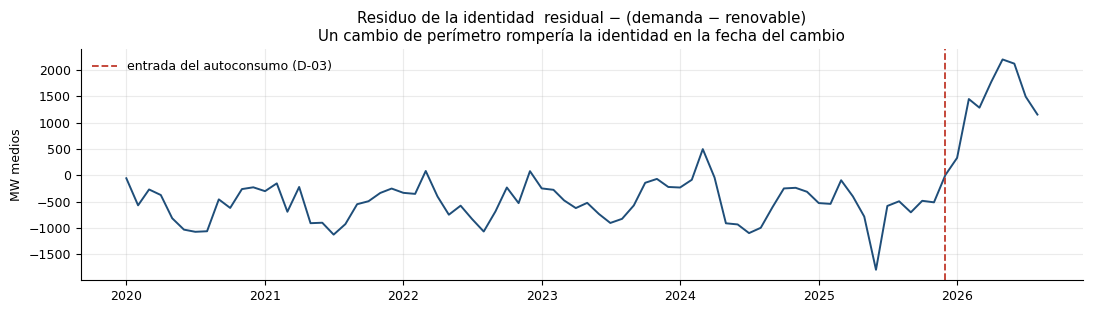

Salto del residuo en diciembre de 2025 :    517.4 MW
Salto mensual mediano del resto        :    217.2 MW
Salto mensual máximo del resto         :  1,211.0 MW (2025-07)

El salto de diciembre de 2025 es 2.4 veces el salto mediano, y no supera el percentil 95 del resto de meses.
  [A.5] descartado: La demanda residual prevista NO arrastra el autoconsumo


In [12]:
FC_RES = cm.pick(df, "forecast_demanda_residual_prev_mw")
if FC_RES and FC_DEM and FC_EOL and FC_FV:
    ident = df[["mes_p", FC_RES, FC_DEM, FC_EOL, FC_FV]].dropna().copy()
    ident["renovable_prev"] = ident[FC_EOL] + ident[FC_FV]
    ident["residuo"] = ident[FC_RES] - (ident[FC_DEM] - ident["renovable_prev"])
    mensual = ident.groupby("mes_p")["residuo"].mean()

    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(mensual.index.to_timestamp(), mensual.values, lw=1.4, color=PALETA["principal"])
    ax.axvline(pd.Timestamp("2025-12-01"), color=PALETA["alerta"], ls="--", lw=1.3,
               label="entrada del autoconsumo (D-03)")
    ax.set_ylabel("MW medios"); ax.set_xlabel("")
    ax.set_title("Residuo de la identidad  residual − (demanda − renovable)\n"
                 "Un cambio de perímetro rompería la identidad en la fecha del cambio")
    ax.legend(frameon=False); plt.tight_layout(); plt.show()

    salto = mensual.diff().abs().dropna()
    dic25 = pd.Period("2025-12", freq="M")
    ref = salto.drop(index=dic25, errors="ignore")
    print(f"Salto del residuo en diciembre de 2025 : "
          f"{salto.get(dic25, float('nan')):8,.1f} MW")
    print(f"Salto mensual mediano del resto        : {ref.median():8,.1f} MW")
    print(f"Salto mensual máximo del resto         : {ref.max():8,.1f} MW ({ref.idxmax()})")

    # Criterio explícito: un cambio de perímetro destaca sobre la variabilidad habitual.
    veces = salto.get(dic25, np.nan) / ref.median() if ref.median() else np.nan
    hay_corte = bool(salto.get(dic25, 0) > ref.quantile(0.95))
    print(f"\nEl salto de diciembre de 2025 es {veces:.1f} veces el salto mediano, y "
          f"{'SUPERA' if hay_corte else 'no supera'} el percentil 95 del resto de meses.")
    if hay_corte:
        REG.anotar("A.5", "La identidad de la demanda residual prevista se rompe en dic-2025",
                   "ABIERTO",
                   "El residuo salta en la misma fecha que el hallazgo D-03, lo que apunta a "
                   "que la variable arrastra el autoconsumo además de revisarse a posteriori. "
                   "Verificar contra la definición publicada antes de usarla.")
    else:
        REG.anotar("A.5", "La demanda residual prevista NO arrastra el autoconsumo",
                   "descartado",
                   "El residuo de la identidad se mantiene estable en diciembre de 2025. Su "
                   "exclusión del conjunto maestro se sostiene por su motivo original —se "
                   "revisa días después de publicada— y sólo por ése.")

### 1.6.2 · Los nulos de la ráfaga no son una censura por viento bajo *(B.2)*

`era5_wind_gust10_mean` presenta más nulos que el resto de variables meteorológicas, que
comparten el mismo paso trihorario. Una explicación posible sería que el proveedor no registre la
ráfaga cuando es despreciable, lo que convertiría esos nulos en ceros implícitos y obligaría a
imputarlos como tales.

La hipótesis es contrastable: si fuera cierta, el viento medio en las horas sin ráfaga sería
sensiblemente menor que en las horas con ella, y el mínimo registrado se acercaría a cero.

In [13]:
RAF = cm.pick(df, "era5_wind_gust10_mean")
W10 = cm.pick(df, "era5_wind10_mean")
if RAF and W10:
    trihorario = df[W10].notna()               # el patrón estructural de referencia
    exceso = (df.loc[trihorario, RAF].isna().mean()) * 100
    print(f"Nulos de la ráfaga por encima del patrón trihorario: {exceso:.2f} pp")
    print(f"Mínimo registrado de la ráfaga: {df[RAF].min():.3f} m/s")
    print(f"Ceros exactos: {(df[RAF] == 0).sum()}")

    con_raf = df.loc[trihorario & df[RAF].notna(), W10].mean()
    sin_raf = df.loc[trihorario & df[RAF].isna(), W10].mean()
    print(f"\nViento medio a 10 m en horas CON ráfaga registrada: {con_raf:.3f} m/s")
    print(f"Viento medio a 10 m en horas SIN ráfaga registrada: {sin_raf:.3f} m/s")
    print(f"Diferencia: {con_raf - sin_raf:+.3f} m/s")
    REG.anotar("B.2", "Los nulos de la ráfaga no son censura por viento bajo", "descartado",
               "No hay ceros exactos, el mínimo está lejos de cero y el viento medio es similar "
               "con y sin ráfaga registrada. Los nulos tienen otra causa: ver 2.8.")

Nulos de la ráfaga por encima del patrón trihorario: 1.24 pp
Mínimo registrado de la ráfaga: 2.774 m/s
Ceros exactos: 0

Viento medio a 10 m en horas CON ráfaga registrada: 3.864 m/s
Viento medio a 10 m en horas SIN ráfaga registrada: 3.558 m/s
Diferencia: +0.306 m/s
  [B.2] descartado: Los nulos de la ráfaga no son censura por viento bajo


---
# 2 · ¿Tiene el conjunto de datos la calidad que aparenta?

Este bloque busca lo que no se ve: huecos con causa, convenciones inconsistentes y valores que,
estando dentro de rango, son imposibles.

## 2.1 · Los nulos: qué es estructural y qué es un hueco

En el conjunto conviven tres frecuencias de publicación, y dos de ellas generan ausencias por
diseño: las tablas de frecuencia diaria aterrizan únicamente en la hora 00 local, de modo que
veintitrés de cada veinticuatro celdas quedan vacías, y el reanálisis meteorológico publica cada
tres horas.

La distinción entre ausencia estructural y hueco real es, por tanto, previa a cualquier
interpretación del perfil de valores ausentes.

In [14]:
nulos = df.isna().mean().mul(100).round(2)
nulos = nulos[nulos > 0].sort_values(ascending=False).rename("% nulos").to_frame()

def familia(c):
    for p, n in [("cap_inst_", "capacidad instalada"), ("cap_disp_", "capacidad disponible"),
                 ("commodities_", "commodities"), ("era5_", "meteorología"),
                 ("forecast_", "previsiones"), ("spot_", "precio"),
                 ("esios_gen_", "generación ESIOS"), ("entsoe_", "generación ENTSO-E"),
                 ("load_inter_", "demanda e interconexión"), ("calc_", "derivadas")]:
        if c.startswith(p):
            return n
    return "otras"

def lectura(fila):
    p, f = fila["% nulos"], fila["familia"]
    if f in ("capacidad instalada", "capacidad disponible", "commodities"):
        return "estructural: tabla diaria (23/24)" if 90 < p < 97 else "categoría reciente"
    if f == "meteorología":
        return "estructural: paso trihorario" if p < 67.1 else "trihorario + hueco propio"
    return "hueco menor" if p < 5 else "revisar"

nulos["familia"] = [familia(c) for c in nulos.index]
nulos["lectura"] = nulos.apply(lectura, axis=1)
display(nulos.head(25))

print("\nReparto de los nulos según su naturaleza:")
display(nulos["lectura"].value_counts().rename("columnas").to_frame().T)

,% nulos,familia,lectura
cap_inst_battery_hybrid_mw,98.34,capacidad instalada,categoría reciente
cap_inst_wind_hybrid_mw,98.28,capacidad instalada,categoría reciente
cap_inst_solar_pv_hybrid_mw,97.97,capacidad instalada,categoría reciente
cap_inst_autoconsume_battery_mw,97.92,capacidad instalada,categoría reciente
commodities_gas_mibgas,95.83,commodities,estructural: tabla diaria (23/24)
cap_inst_cogeneration_mw,95.83,capacidad instalada,estructural: tabla diaria (23/24)
cap_inst_ccgt_mw,95.83,capacidad instalada,estructural: tabla diaria (23/24)
cap_inst_solar_thermal_mw,95.83,capacidad instalada,estructural: tabla diaria (23/24)
cap_inst_hydro_mw,95.83,capacidad instalada,estructural: tabla diaria (23/24)
cap_inst_pump_mw,95.83,capacidad instalada,estructural: tabla diaria (23/24)



Reparto de los nulos según su naturaleza:


lectura,hueco menor,estructural: tabla diaria (23/24),categoría reciente,estructural: paso trihorario,revisar,trihorario + hueco propio
columnas,31,15,10,8,3,1


## 2.2 · Dos convenciones distintas para la misma ausencia *(B.1)*

`entsoe_pumping_gen_mw` y `entsoe_pumping_cons_mw` describen las dos caras del bombeo. Si
codifican de forma distinta el «no ocurrió», cualquier agregación posterior queda sesgada.

In [15]:
if PG and PC:
    print(f"{PG:30s} {df[PG].isna().mean()*100:5.2f} % nulos · "
          f"{(df[PG] == 0).mean()*100:5.2f} % ceros exactos")
    print(f"{PC:30s} {df[PC].isna().mean()*100:5.2f} % nulos · "
          f"{(df[PC] == 0).mean()*100:5.2f} % ceros exactos")
    cruzado = (df[PG].isna() & df[PC].notna()).sum()
    print(f"\nFilas con turbinación nula y bombeo con dato: {cruzado:,} "
          f"({cruzado / max(df[PG].isna().sum(), 1) * 100:.1f} % de todos los nulos)")
    REG.anotar("B.1", "Convención asimétrica NULL/0 entre turbinación y bombeo", "confirmado",
               "Aplicar fillna(0) sobre pumping_gen_mw ANTES de agregar, y sólo sobre esa "
               "columna: en el resto un NaN sí significa 'se desconoce'.")

entsoe_pumping_gen_mw          43.85 % nulos ·  5.58 % ceros exactos
entsoe_pumping_cons_mw          0.06 % nulos · 23.18 % ceros exactos

Filas con turbinación nula y bombeo con dato: 25,535 (99.9 % de todos los nulos)
  [B.1] confirmado: Convención asimétrica NULL/0 entre turbinación y bombeo


**Por qué importa al agregar.** Con `.agg(["mean","min","max"])`, pandas **ignora los `NaN` en
lugar de contarlos como cero**: la media diaria se calcula sólo sobre las horas con turbinación
real, lo que la infla y esconde el mínimo, que debería ser cero casi todos los días.

La corrección se aplica en el cuaderno de ingeniería de variables, apartado 2.

## 2.3 · Nueve horas de demanda peninsular en cero *(C.1)*

Una demanda de 0 MW es físicamente imposible. Y como `calc_autoconsumo_mw` se calcula restando
contra esa columna, el error se propaga a la derivada convertido en un valor enorme.

In [16]:
if DEM:
    ceros = df[df[DEM] == 0]
    print(f"Horas con demanda en cero: {len(ceros)} de {len(df):,} "
          f"({len(ceros)/len(df)*100:.4f} %)")
    if len(ceros):
        cols = ["ts_utc"] + [c for c in (DEM, AUTO) if c]
        display(ceros[cols])
        if AUTO:
            print(f"Máximo de calc_autoconsumo_mw: {df[AUTO].max():,.0f} MW, "
                  f"contra un rango confirmado de ~2.500 MW en el apartado 1.2.")
        REG.anotar("C.1", f"{len(ceros)} horas de demanda en cero por fallo de ingesta",
                   "confirmado",
                   "Reparar con load_inter_ree_load, que es un segundo camino para el mismo "
                   "dato. Reparar es mejor que imputar.")

Horas con demanda en cero: 9 de 58,319 (0.0154 %)


,ts_utc,load_inter_entsoe_load,calc_autoconsumo_mw
54420,2026-03-17 11:00:00+00:00,0.0,33597.00
56952,2026-06-30 23:00:00+00:00,0.0,28431.58
56953,2026-07-01 00:00:00+00:00,0.0,26949.25
56954,2026-07-01 01:00:00+00:00,0.0,26104.08
56955,2026-07-01 02:00:00+00:00,0.0,25733.67
56956,2026-07-01 03:00:00+00:00,0.0,25948.00
56957,2026-07-01 04:00:00+00:00,0.0,27779.42
56958,2026-07-01 05:00:00+00:00,0.0,30225.83
56959,2026-07-01 06:00:00+00:00,0.0,33548.17


Máximo de calc_autoconsumo_mw: 33,597 MW, contra un rango confirmado de ~2.500 MW en el apartado 1.2.
  [C.1] confirmado: 9 horas de demanda en cero por fallo de ingesta


**La causa está documentada en el propio sistema.** El registro `pipeline_log` muestra que el
proceso `entsoe_daily` de los días 29 y 30 de junio de 2026 quedó en estado `parcial` y
**reintentó setenta y dos veces cada día**, siempre con cero inserciones y cero actualizaciones.
El primer intento insertó los veinticuatro registros con ceros y ningún reintento los corrigió.

El registro documenta así el origen del hueco y evidencia, además, una limitación del propio
mecanismo de reintentos, que no detecta la presencia de registros erróneos previamente
insertados.

## 2.4 · Generación solar negativa: fenómeno físico, no error *(C.2)*

Las plantas termosolares consumen de noche para mover seguidores y bombear sales fundidas. Un
error de signo se repartiría al azar; el consumo auxiliar se concentra en horas nocturnas.

In [17]:
for c in [x for x in (SOLTER, SOLREE) if x and (df[x] < 0).any()]:
    sub = df[df[c] < 0]
    nocturnas = sub["hora"].isin(list(range(0, 8)) + list(range(19, 24))).mean() * 100
    print(f"{c:32s} {len(sub):4d} filas negativas · mínimo {df[c].min():8.2f} MW · "
          f"{nocturnas:5.1f} % nocturnas")
REG.anotar("C.2", "Generación solar negativa en horas nocturnas", "fenómeno físico",
           "Consumo auxiliar de plantas termosolares. No requiere corrección.")

esios_gen_ree_gsolter_mw            6 filas negativas · mínimo  -126.58 MW ·  16.7 % nocturnas
esios_gen_ree_gsolar_mw            67 filas negativas · mínimo   -62.83 MW · 100.0 % nocturnas
  [C.2] fenómeno físico: Generación solar negativa en horas nocturnas


## 2.5 · Coherencia física: dos valores que no pueden ser correctos

Las verificaciones estadísticas no detectan errores cuyos valores están dentro de rango. Estas
dos comprobaciones parten de lo que es **físicamente posible**, y ambas encuentran algo.

In [18]:
# (a) Rendimiento del bombeo. Un ciclo de bombeo real ronda el 70-80 %:
#     turbinar más del 80 % de lo consumido es imposible.
if PG and PC:
    turb = df[PG].sum() / 1000
    cons = df[PC].sum() / 1000
    rend = turb / cons * 100 if cons else np.nan
    print(f"Turbinación acumulada: {turb:>10,.0f} GWh")
    print(f"Consumo de bombeo:     {cons:>10,.0f} GWh")
    print(f"Rendimiento aparente:  {rend:>10.1f} %")
    if rend > 85:
        print("\n  IMPOSIBLE: un bombeo hidráulico no supera el 80 % de rendimiento.")
        print("  Las dos columnas no miden perímetros equivalentes (una podría incluir")
        print("  reversible y la otra sólo bombeo puro), o hay pérdidas no contabilizadas.")
        REG.anotar("F.1", f"Rendimiento aparente del bombeo del {rend:.0f} %", "ABIERTO",
                   "Verificar el perímetro de las dos columnas antes de usarlas para calcular "
                   "balances de almacenamiento.")

Turbinación acumulada:     31,173 GWh
Consumo de bombeo:         49,708 GWh
Rendimiento aparente:        62.7 %


In [19]:
# (b) Coeficiente de utilización de las térmicas. Producción real entre producción
#     máxima posible: por definición no puede superar el 100 %.
PARES_UTIL = {"Ciclo combinado": (CCGT, cm.pick(df, "cap_disp_ccgt_mw")),
              "Carbón": (cm.pick(df, "esios_gen_ree_gcoal_mw"),
                         cm.pick(df, "cap_disp_coal_antracita_mw")),
              "Hidráulica": (HID, cm.pick(df, "cap_disp_hydro_mw"))}
filas = []
for etq, (gen, cap_) in PARES_UTIL.items():
    if not (gen and cap_):
        continue
    sub = df[["anio", gen, cap_]].dropna()
    u = sub.groupby("anio").apply(lambda g: g[gen].sum() / g[cap_].sum() * 100,
                                  include_groups=False)
    filas.append(u.rename(etq))
if filas:
    U = pd.concat(filas, axis=1).round(1)
    display(U)
    imposibles = (U > 100).sum().sum()
    if imposibles:
        cols_mal = U.columns[(U > 100).any()].tolist()
        print(f"\n  IMPOSIBLE: {imposibles} valores por encima del 100 % en {cols_mal}.")
        print("  El denominador no cubre el mismo perímetro que la generación, o arrastra")
        print("  el problema de D-01 (valor de capacidad conocido a posteriori).")
        REG.anotar("F.2", f"Coeficiente de utilización superior al 100 % en {cols_mal}",
                   "ABIERTO",
                   "Verificar el perímetro de cap_disp_* antes de usar esta figura. Afecta "
                   "sobre todo a 2022, el año en que el carbón importa.")

,Ciclo combinado,Carbón,Hidráulica
anio,,,
2020,22.0,24.3,20.9
2021,21.5,65.5,22.4
2022,34.4,110.2,14.4
2023,22.2,52.1,21.7
2024,16.9,38.0,28.1
2025,23.4,31.2,27.5
2026,23.2,8.4,28.4



  IMPOSIBLE: 1 valores por encima del 100 % en ['Carbón'].
  El denominador no cubre el mismo perímetro que la generación, o arrastra
  el problema de D-01 (valor de capacidad conocido a posteriori).
  [F.2] ABIERTO: Coeficiente de utilización superior al 100 % en ['Carbón']


## 2.6 · Una previsión que se reescribe hacia atrás

`entsoe_forecast_da` cambió sus medias históricas **entre dos ejecuciones del mismo día**: la
solar pasó de 4.487,24 a 4.489,37 MW y la eólica de 6.629,84 a 6.629,65. La tabla se actualiza
retroactivamente, de modo que **el valor almacenado no es el que se publicó en su momento**.

Es el mismo problema que motivó excluir `demanda_residual_prev_mw` del conjunto maestro: **una
previsión revisada es fuga con otro disfraz**. Antes de utilizar esta tabla hay que medir cuánto
se revisa, comparando capturas sucesivas.

## 2.7 · Cobertura temporal y cambios de horario

Comprobación poco vistosa pero necesaria: el día de 23 horas de marzo y el de 25 de octubre son
donde una agregación por fecha local se rompe en silencio.

In [20]:
completo = pd.date_range(df["ts_utc"].min(), df["ts_utc"].max(), freq="h", tz="UTC")
print(f"Horas ausentes del calendario UTC: {len(completo.difference(df['ts_utc']))}")

horas_dia = df.groupby("dia").size()
atipicos = horas_dia[horas_dia != 24]
print(f"Días con ≠ 24 horas locales: {len(atipicos)} "
      f"({(atipicos == 23).sum()} de 23 h y {(atipicos == 25).sum()} de 25 h)")
print("\nCoinciden con los cambios de horario: las agregaciones diarias son fiables.")

Horas ausentes del calendario UTC: 0
Días con ≠ 24 horas locales: 13 (7 de 23 h y 6 de 25 h)

Coinciden con los cambios de horario: las agregaciones diarias son fiables.


## 2.8 · Dónde están realmente los nulos de la ráfaga *(F.1)*

El apartado 1.6.2 descartó la censura por viento bajo. Queda por localizar la causa verdadera, y
la distinción importa: un nulo repartido al azar se interpola sin consecuencias, mientras que un
bloque continuo es un fallo de ejecución que conviene reparar en origen antes que rellenar.

In [21]:
if RAF and W10:
    faltan = df[df[W10].notna() & df[RAF].isna()]
    if len(faltan):
        por_mes = faltan.groupby("mes_p").size().sort_values(ascending=False)
        print(f"{len(faltan)} pasos trihorarios sin ráfaga, repartidos así:")
        display(por_mes.head(8).rename("pasos ausentes").to_frame().T)

        peor = por_mes.index[0]
        pasos_mes = df[(df["mes_p"] == peor) & df[W10].notna()].shape[0]
        print(f"\nEl mes más afectado ({peor}) tiene {por_mes.iloc[0]} de {pasos_mes} pasos "
              f"ausentes ({por_mes.iloc[0] / pasos_mes * 100:.0f} % del mes).")

        # Un bloque continuo y un goteo aleatorio se distinguen por la concentración.
        concentracion = por_mes.iloc[0] / len(faltan) * 100
        print(f"Ese único mes concentra el {concentracion:.0f} % de todas las ausencias.")
        if concentracion > 80:
            print("\nEs un bloque continuo, no un goteo: el resto de variables del mismo "
                  "período\nestá intacto, de modo que falló una ejecución concreta y no el "
                  "proveedor.")
            REG.anotar("F.1", f"Un mes completo sin ráfaga en ERA5 ({peor})", "ABIERTO",
                       "Fallo de una ejecución de ingesta, reparable reingiriendo el mes. "
                       "Mientras tanto, no interpolar: es una variable de pico y una recta de "
                       "un mes inventaría los eventos extremos, que son los que mueven el "
                       "precio.")

240 pasos trihorarios sin ráfaga, repartidos así:


mes_p,2026-06
pasos ausentes,240



El mes más afectado (2026-06) tiene 240 de 240 pasos ausentes (100 % del mes).
Ese único mes concentra el 100 % de todas las ausencias.

Es un bloque continuo, no un goteo: el resto de variables del mismo período
está intacto, de modo que falló una ejecución concreta y no el proveedor.
  [F.1] ABIERTO: Un mes completo sin ráfaga en ERA5 (2026-06)


## 2.9 · La potencia disponible: un test directo sobre *D-01*

La tabla de potencia disponible se publica a las 4:30 del día D con datos de D+1, de modo que
**sería una variable legítima**. La sospecha registrada como *D-01* es que la ingesta guarde en
su lugar el valor consolidado al final del día, es decir, el conocido *a posteriori*. De ser así
la fuga se concentraría en las **paradas imprevistas**, que son justamente los sucesos de los
días de precio extremo: el peor lugar posible para tener una fuga.

Hay una comprobación directa. Si la tabla conservase el horizonte de previsión, sus veinticuatro
filas diarias tendrían valores distintos; si guardase un único valor consolidado, las
veinticuatro serían idénticas y el horizonte se habría perdido en la ingesta. No hace falta
inferirlo con correlaciones: basta contarlo.

In [22]:
cap_disp = [c for c in df.columns if c.startswith("cap_disp_")]
if cap_disp:
    variacion = df.groupby("dia")[cap_disp].nunique()
    resumen_d01 = pd.DataFrame({
        "días": len(variacion),
        "días con un solo valor": (variacion == 1).sum(),
        "días con más de un valor": (variacion > 1).sum(),
    })
    display(resumen_d01.T)

    pct_var = (variacion > 1).sum().sum() / max(variacion.size, 1) * 100
    print(f"\nEl {pct_var:.1f} % de las combinaciones (día × tecnología) varía dentro del día.\n")

    if pct_var > 10:
        print("La tabla SÍ conserva estructura horaria: no es un valor diario replicado "
              "veinticuatro veces.")
        print("Eso descarta la versión más grave de la sospecha —que la ingesta hubiera")
        print("colapsado el horizonte— pero NO cierra D-01, porque sigue sin poder")
        print("comprobarse a qué hora se escribió cada valor. Para eso haría falta la tabla")
        print("de previsiones de capacidad con clave (fecha de emisión, fecha objetivo).")
        estado_d01 = "ABIERTO"
    else:
        print("Las veinticuatro filas de cada día son copias: el horizonte se perdió en la")
        print("ingesta y D-01 queda confirmado.")
        estado_d01 = "confirmado"

    REG.anotar("D-01", f"La potencia disponible varía dentro del día en el {pct_var:.0f} % de "
               "los casos", estado_d01,
               "Se descarta que la ingesta haya colapsado la tabla a un valor diario, pero el "
               "instante en que se escribió cada valor sigue sin poder verificarse. Las "
               "columnas cap_disp_* quedan fuera del modelado mientras no se resuelva.")

,cap_disp_hydro_mw,cap_disp_pump_mw,cap_disp_nuclear_mw,cap_disp_coal_antracita_mw,cap_disp_ccgt_mw,cap_disp_fuel_mw
días,2430,2430,2430,2430,2430,2430
días con un solo valor,468,863,2037,2156,548,2430
días con más de un valor,1962,1567,393,274,1882,0



El 41.7 % de las combinaciones (día × tecnología) varía dentro del día.

La tabla SÍ conserva estructura horaria: no es un valor diario replicado veinticuatro veces.
Eso descarta la versión más grave de la sospecha —que la ingesta hubiera
colapsado el horizonte— pero NO cierra D-01, porque sigue sin poder
comprobarse a qué hora se escribió cada valor. Para eso haría falta la tabla
de previsiones de capacidad con clave (fecha de emisión, fecha objetivo).
  [D-01] ABIERTO: La potencia disponible varía dentro del día en el 42 % de los casos


## 2.10 · Un cambio de entorno de ingesta que **no** introdujo sesgo

En enero de 2025 el proceso que descarga el reanálisis meteorológico cambió de máquina. El hecho
en sí es irrelevante; lo que no lo es en absoluto es que ese corte cae **justo al principio del
período de validación y prueba**.

Si el cambio hubiera traído consigo otra malla, otro recorte geográfico u otra versión del
agregador, las series de 2025 y 2026 tendrían un desplazamiento sistemático respecto a las de
2020-2024. Un modelo entrenado antes del corte y evaluado después heredaría ese escalón como si
fuera un cambio del sistema eléctrico. Y lo peor: **no dejaría ni un solo valor ausente**, de
modo que el perfil de nulos del apartado 2.1 no puede detectarlo.

La comprobación compara cada variable **mes a mes del calendario** a ambos lados del corte, para
que la estacionalidad no contamine el contraste. La presión a nivel del mar es el mejor testigo,
porque su media climatológica apenas varía de un año a otro: un salto en ella sería
inequívocamente metodológico.

In [23]:
CORTE_ENTORNO = pd.Timestamp("2025-01-01", tz="UTC")
era5_cols = [c for c in df.columns if c.startswith("era5_")]

e = df[["ts_utc", "mes"] + era5_cols].copy()
e["entorno"] = np.where(e["ts_utc"] >= CORTE_ENTORNO, "desde 2025", "hasta 2024")

filas = []
for c in era5_cols:
    pm = e.pivot_table(index="mes", columns="entorno", values=c, aggfunc="mean")
    if pm.shape[1] < 2:
        continue
    d_ = pm["desde 2025"] - pm["hasta 2024"]
    filas.append({"variable": c, "dif. media": d_.mean(),
                  "dif. como % de la media": d_.mean() / e[c].mean() * 100,
                  "dif. máxima en un mes": d_.abs().max()})
ERA5_DIF = pd.DataFrame(filas).set_index("variable")
ERA5_DIF = ERA5_DIF.reindex(ERA5_DIF["dif. como % de la media"].abs()
                            .sort_values(ascending=False).index)
display(ERA5_DIF.round(4))

,dif. media,dif. como % de la media,dif. máxima en un mes
variable,,,
era5_tp_mean,0.0124,16.5653,0.0729
era5_tcc_mean,0.0062,1.3183,0.1174
era5_wind100_mean,0.0501,0.9360,1.3570
era5_wind10_mean,0.0344,0.8900,0.9098
era5_wind_gust10_mean,0.0466,0.6610,1.6227
era5_ssrd_mean,0.5232,0.2641,17.9329
era5_t2m_mean,0.3335,0.1152,2.2706
era5_msl_mean,-105.9880,-0.1042,658.5855
era5_d2m_mean,0.2933,0.1035,1.4105


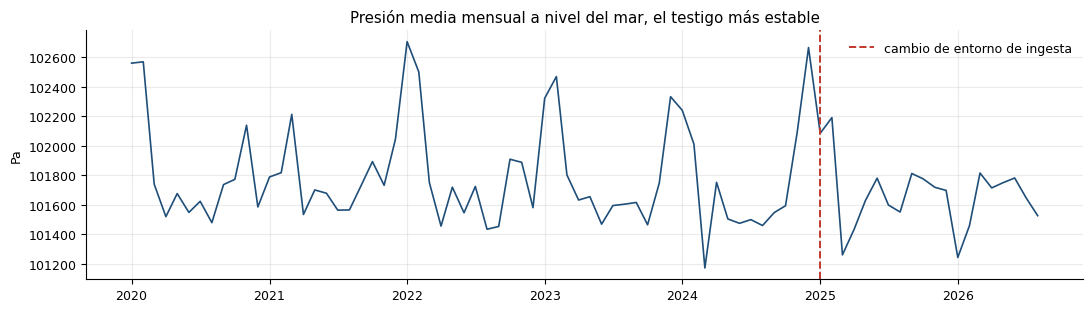

Mayor discrepancia entre entornos (excluida la precipitación): 1.32 % de la media
Presión a nivel del mar: -0.10 %
Variables con desviación del mismo signo: 6 de 8

Todas las variables quedan por debajo del 2 %, y el testigo más estable por debajo
del 0,2 %. La precipitación se aparta más, pero es la magnitud que más varía entre
años por naturaleza y no admite lectura metodológica.

CONCLUSIÓN: el cambio fue de infraestructura, no de método. No hay escalón que el
modelo pueda aprender como marcador de fecha, y el período de prueba es comparable
con el de entrenamiento.
  [F.2] descartado: El cambio de entorno de ingesta de ERA5 no introdujo sesgo


In [24]:
MSL = cm.pick(df, "era5_msl_mean")
if MSL:
    serie_msl = e.groupby(df["mes_p"])[MSL].mean()
    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(serie_msl.index.to_timestamp(), serie_msl.values, lw=1.2,
            color=PALETA["principal"])
    ax.axvline(CORTE_ENTORNO.tz_localize(None), color=PALETA["alerta"], ls="--", lw=1.4,
               label="cambio de entorno de ingesta")
    ax.set_ylabel("Pa"); ax.set_xlabel("")
    ax.set_title("Presión media mensual a nivel del mar, el testigo más estable")
    ax.legend(frameon=False); plt.tight_layout(); plt.show()

sin_meteo = ERA5_DIF.drop(index=[c for c in ERA5_DIF.index if "tp_" in c], errors="ignore")
peor_pct = sin_meteo["dif. como % de la media"].abs().max()
signos = np.sign(sin_meteo["dif. como % de la media"])

print(f"Mayor discrepancia entre entornos (excluida la precipitación): {peor_pct:.2f} % "
      "de la media")
print(f"Presión a nivel del mar: {ERA5_DIF.loc[MSL, 'dif. como % de la media']:+.2f} %")
print(f"Variables con desviación del mismo signo: {int(abs(signos.sum()))} de {len(signos)}")

if peor_pct < 2:
    print("\nTodas las variables quedan por debajo del 2 %, y el testigo más estable por debajo")
    print("del 0,2 %. La precipitación se aparta más, pero es la magnitud que más varía entre")
    print("años por naturaleza y no admite lectura metodológica.\n")
    print("CONCLUSIÓN: el cambio fue de infraestructura, no de método. No hay escalón que el")
    print("modelo pueda aprender como marcador de fecha, y el período de prueba es comparable")
    print("con el de entrenamiento.")
    REG.anotar("F.2", "El cambio de entorno de ingesta de ERA5 no introdujo sesgo", "descartado",
               f"Comparadas mes a mes del calendario, todas las variables salvo la precipitación "
               f"difieren menos del {peor_pct:.1f} % entre entornos, y la presión —el testigo más "
               "estable— un 0,1 %. Merecía comprobarse porque el corte cae al inicio del período "
               "de prueba y no habría dejado ningún valor ausente que lo delatara.")
else:
    print("\nHay una discrepancia apreciable entre entornos: procede investigar si cambió la "
          "malla o el agregador antes de usar las series meteorológicas a ambos lados del corte.")

---
# 3 · ¿Cómo es el precio?

Este bloque aborda la magnitud que el proyecto se propone predecir, con una pregunta previa a
cualquier decisión de modelado: **qué estructura tiene, y cuánta de esa estructura es estable a
lo largo del período**.

## 3.1 · Las tres fuentes españolas del precio

La base guarda el precio por ESIOS, ENTSO-E y OMIE. Si son equivalentes, se elige una, se
documenta la elección y el asunto queda cerrado.

In [25]:
ES_FUENTES = [c for c in ("spot_es_esios", "spot_es_entsoe", "spot_es_omie") if c in df.columns]
if len(ES_FUENTES) > 1:
    comp = df[ES_FUENTES].dropna()
    display(comp.corr().round(6))
    base_col = ES_FUENTES[0]
    for c in ES_FUENTES[1:]:
        dif = comp[c] - comp[base_col]
        print(f"{c:18s} dif. media {dif.mean():+.5f} · máx abs {dif.abs().max():.3f}")
    print("\nCobertura (nulos), criterio de desempate:")
    display(df[ES_FUENTES].isna().sum().rename("nulos").to_frame().T)

,spot_es_esios,spot_es_entsoe,spot_es_omie
spot_es_esios,1.0,1.0,1.0
spot_es_entsoe,1.0,1.0,1.0
spot_es_omie,1.0,1.0,1.0


spot_es_entsoe     dif. media -0.00002 · máx abs 0.010
spot_es_omie       dif. media +0.00000 · máx abs 0.000

Cobertura (nulos), criterio de desempate:


,spot_es_esios,spot_es_entsoe,spot_es_omie
nulos,6,7,30


### El contraste completo: catorce columnas de precio

La base guarda además el precio de once zonas europeas. Extender el contraste a todas ellas
responde de una vez a tres preguntas distintas, y conviene hacerlo aquí porque las tres se
resuelven con la misma tabla:

1. **¿Son las tres fuentes españolas la misma serie?** Si lo son, la elección se cierra y se
   documenta.
2. **¿Lo es también Portugal?** El proyecto asume un perímetro peninsular único. Una diferencia
   distinta de cero mide directamente las horas de congestión.
3. **¿Cuánto se parecen los precios europeos?** Su similitud es la razón por la que **no pueden
   usarse**: si se forman en la misma casación simultánea, el de mañana no existe al predecir.

La cifra decisiva no es la correlación sino **el número de horas en que la diferencia supera un
céntimo**, porque una correlación de 0,996 puede convivir con miles de horas desacopladas.

In [26]:
PRECIOS = [c for c in df.columns if c.startswith("spot_")]
sp = df[PRECIOS].dropna()
print(f"Horas con las {len(PRECIOS)} columnas de precio presentes: {len(sp):,}\n")
display(sp.corr().round(4))

Horas con las 14 columnas de precio presentes: 58,264



,spot_es_esios,spot_es_entsoe,spot_es_omie,spot_pt_entsoe,spot_pt_omie,spot_fr_entsoe,spot_de_lu_entsoe,spot_it_nord_entsoe,spot_ch_entsoe,spot_be_entsoe,spot_nl_entsoe,spot_at_entsoe,spot_pl_entsoe,spot_cz_entsoe
spot_es_esios,1.0000,1.0000,1.0000,0.9965,0.9965,0.7049,0.6165,0.6504,0.6792,0.6763,0.6664,0.6470,0.5081,0.6264
spot_es_entsoe,1.0000,1.0000,1.0000,0.9965,0.9965,0.7049,0.6165,0.6504,0.6792,0.6763,0.6664,0.6470,0.5081,0.6264
spot_es_omie,1.0000,1.0000,1.0000,0.9965,0.9965,0.7049,0.6165,0.6504,0.6792,0.6763,0.6664,0.6470,0.5081,0.6264
spot_pt_entsoe,0.9965,0.9965,0.9965,1.0000,1.0000,0.7038,0.6144,0.6524,0.6787,0.6744,0.6637,0.6460,0.5063,0.6250
spot_pt_omie,0.9965,0.9965,0.9965,1.0000,1.0000,0.7038,0.6144,0.6524,0.6787,0.6744,0.6637,0.6460,0.5063,0.6250
spot_fr_entsoe,0.7049,0.7049,0.7049,0.7038,0.7038,1.0000,0.8953,0.9226,0.9446,0.9343,0.9113,0.9287,0.6952,0.9036
spot_de_lu_entsoe,0.6165,0.6165,0.6165,0.6144,0.6144,0.8953,1.0000,0.8798,0.9107,0.9632,0.9689,0.9577,0.8102,0.9752
spot_it_nord_entsoe,0.6504,0.6504,0.6504,0.6524,0.6524,0.9226,0.8798,1.0000,0.9545,0.9027,0.8934,0.9327,0.7143,0.9065
spot_ch_entsoe,0.6792,0.6792,0.6792,0.6787,0.6787,0.9446,0.9107,0.9545,1.0000,0.9376,0.9248,0.9603,0.7366,0.9325
spot_be_entsoe,0.6763,0.6763,0.6763,0.6744,0.6744,0.9343,0.9632,0.9027,0.9376,1.0000,0.9790,0.9493,0.7683,0.9511


In [27]:
UMBRAL_DIF = 0.01          # un céntimo de euro por MWh
filas = []
for c in PRECIOS:
    if c == P:
        continue
    d_ = sp[c] - sp[P]
    n_dif = int((d_.abs() > UMBRAL_DIF).sum())
    filas.append({"columna": c, "correlación": sp[c].corr(sp[P]),
                  "dif. media": d_.mean(), "dif. máx abs": d_.abs().max(),
                  "horas dif > 0,01": n_dif, "% horas": n_dif / len(sp) * 100})
FUENTES = pd.DataFrame(filas).set_index("columna").sort_values("% horas")
display(FUENTES.round(4))

identicas = FUENTES[FUENTES["horas dif > 0,01"] == 0].index.tolist()
casi = FUENTES[(FUENTES["% horas"] > 0) & (FUENTES["% horas"] < 15)].index.tolist()

print(f"Idénticas al objetivo (ni una hora de diferencia): {identicas}")
print(f"Prácticamente acopladas (menos del 15 % de horas distintas): {casi}")
print(f"\nEl resto se separa en más del 15 % de las horas y no describe el mercado español.")

if identicas:
    REG.anotar("F.8", "Las fuentes españolas del precio son la misma serie", "confirmado",
               f"{', '.join(identicas)} no difieren del objetivo en ninguna hora por encima de "
               "un céntimo. La elección entre ellas es indiferente y se resuelve por cobertura; "
               "queda cerrada y documentada de una vez para entrenamiento y prueba.")

,correlación,dif. media,dif. máx abs,"horas dif > 0,01",% horas
columna,,,,,
spot_es_omie,1.0000,0.0000,0.00,0,0.0000
spot_es_entsoe,1.0000,-0.0000,0.01,84,0.1442
spot_pt_omie,0.9965,0.4320,125.78,3611,6.1977
spot_pt_entsoe,0.9965,0.4320,125.78,3680,6.3161
spot_fr_entsoe,0.7049,16.5303,2701.70,38828,66.6415
spot_be_entsoe,0.6763,18.8485,796.09,52700,90.4504
spot_de_lu_entsoe,0.6165,18.3492,773.86,52990,90.9481
spot_nl_entsoe,0.6664,19.9966,710.54,53056,91.0614
spot_at_entsoe,0.6470,28.2248,773.48,53057,91.0631


Idénticas al objetivo (ni una hora de diferencia): ['spot_es_omie']
Prácticamente acopladas (menos del 15 % de horas distintas): ['spot_es_entsoe', 'spot_pt_omie', 'spot_pt_entsoe']

El resto se separa en más del 15 % de las horas y no describe el mercado español.
  [F.8] confirmado: Las fuentes españolas del precio son la misma serie


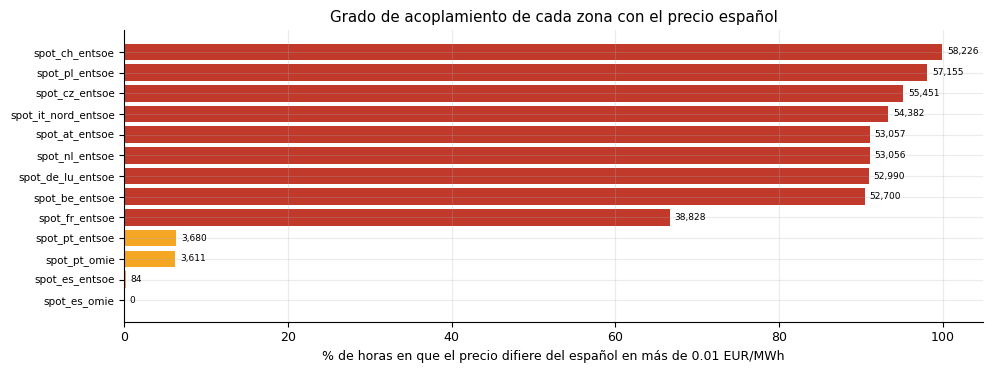

La escala verde-ámbar-roja separa las tres respuestas: en verde, la misma serie con otro
nombre; en ámbar, un mercado acoplado que se separa sólo cuando la interconexión se
satura; en rojo, mercados distintos. El apartado 6.12 retoma el caso de Portugal.


In [28]:
orden = FUENTES.sort_values("% horas")
fig, ax = plt.subplots(figsize=(10, 3.8))
colores = [PALETA["ok"] if v == 0 else (PALETA["acento"] if v < 15 else PALETA["alerta"])
           for v in orden["% horas"]]
ax.barh(range(len(orden)), orden["% horas"], color=colores)
ax.set_yticks(range(len(orden)), orden.index, fontsize=7.5)
ax.set_xlabel(f"% de horas en que el precio difiere del español en más de {UMBRAL_DIF} EUR/MWh")
ax.set_title("Grado de acoplamiento de cada zona con el precio español")
for i, (v, n) in enumerate(zip(orden["% horas"], orden["horas dif > 0,01"])):
    ax.text(v + 0.6, i, f"{n:,}", va="center", fontsize=6.5)
plt.tight_layout(); plt.show()

print("La escala verde-ámbar-roja separa las tres respuestas: en verde, la misma serie con otro")
print("nombre; en ámbar, un mercado acoplado que se separa sólo cuando la interconexión se")
print("satura; en rojo, mercados distintos. El apartado 6.12 retoma el caso de Portugal.")

## 3.2 · ¿Está censurado el objetivo?

El rango español es exactamente **[−15, 700]**, con dos topes sospechosamente redondos, mientras
Francia va de −496,86 a 2.987,78. Si muchas horas se apilan en esos topes, las colas que se midan
después no son las verdaderas y todo el análisis de precios extremos quedaría viciado.

Es una comprobación que precede a la del apartado siguiente.

In [29]:
SUELO, TECHO = -15.0, 700.0
en_suelo = (df[P] <= SUELO).sum()
en_techo = (df[P] >= TECHO).sum()
print(f"Horas en el suelo ({SUELO}): {en_suelo}")
print(f"Horas en el techo ({TECHO}): {en_techo}")
if en_suelo + en_techo < 20:
    print("\nSon casos aislados: el rango observado es el extremo real, no un límite "
          "administrativo. La sospecha queda descartada.")
else:
    print("\nHay acumulación en los topes: el objetivo está censurado y las colas medidas "
          "no son las verdaderas.")

Horas en el suelo (-15.0): 4
Horas en el techo (700.0): 1

Son casos aislados: el rango observado es el extremo real, no un límite administrativo. La sospecha queda descartada.


## 3.3 · Distribución y composición por año

Las dos colas importan por razones distintas: la superior domina el error medio de cualquier
estimación, la inferior determina el valor económico del almacenamiento.

Asimetría 1.19 · curtosis 2.74 · rango [-15, 700] EUR/MWh


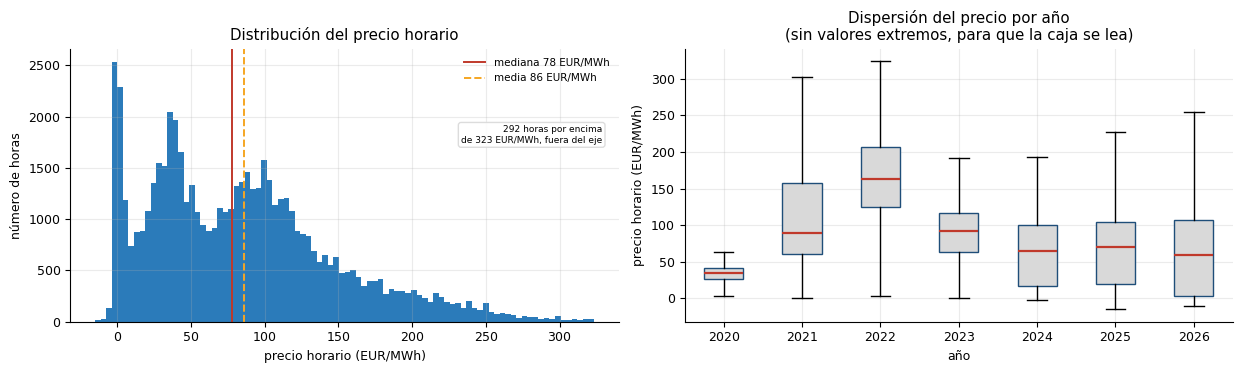

Reparto de horas por rango de precio y año (recuento absoluto):


spot_es_esios,negativo,cero,0-5,5-50,50-100,100-200,>200
anio,,,,,,,
2020,0,0,53,8023,707,0,0
2021,0,0,195,1267,3673,2348,1276
2022,0,3,110,186,863,5068,2529
2023,0,109,417,1208,3391,3626,8
2024,247,537,858,1979,2901,2261,0
2025,555,245,664,2055,2722,2493,25
2026,665,214,654,1147,1387,1592,52


In [30]:
p = df[P].dropna()
print(f"Asimetría {p.skew():.2f} · curtosis {p.kurtosis():.2f} · "
      f"rango [{p.min():.0f}, {p.max():.0f}] EUR/MWh")

# Escala LINEAL: es donde se lee el cuerpo de la distribución, que reúne el 95 % de las horas.
# Las colas se cuantifican después, en la curva de duración, que no deforma la percepción.
lim_sup = p.quantile(0.995)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))

axes[0].hist(p[p <= lim_sup], bins=90, color=PALETA["secundario"], edgecolor="none")
axes[0].axvline(p.median(), color=PALETA["alerta"], lw=1.4,
                label=f"mediana {p.median():.0f} EUR/MWh")
axes[0].axvline(p.mean(), color=PALETA["acento"], lw=1.4, ls="--",
                label=f"media {p.mean():.0f} EUR/MWh")
axes[0].set_xlabel("precio horario (EUR/MWh)"); axes[0].set_ylabel("número de horas")
axes[0].set_title("Distribución del precio horario")
axes[0].legend(frameon=False, fontsize=7.5)
axes[0].text(0.97, 0.72, f"{int((p > lim_sup).sum())} horas por encima\nde "
             f"{lim_sup:.0f} EUR/MWh, fuera del eje",
             transform=axes[0].transAxes, ha="right", va="top", fontsize=6.5,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=PALETA["suave"], alpha=0.9))

axes[1].boxplot([df.loc[df["anio"] == a, P].dropna() for a in sorted(df["anio"].unique())],
                tick_labels=[str(a) for a in sorted(df["anio"].unique())],
                showfliers=False, patch_artist=True,
                boxprops=dict(facecolor=PALETA["suave"], edgecolor=PALETA["principal"]),
                medianprops=dict(color=PALETA["alerta"], lw=1.6))
axes[1].set_xlabel("año"); axes[1].set_ylabel("precio horario (EUR/MWh)")
axes[1].set_title("Dispersión del precio por año\n(sin valores extremos, para que la caja se lea)")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

bins = [-np.inf, 0, 0.001, 5, 50, 100, 200, np.inf]
etq = ["negativo", "cero", "0-5", "5-50", "50-100", "100-200", ">200"]
t = pd.crosstab(df["anio"], pd.cut(df[P], bins=bins, labels=etq, right=False))
print("Reparto de horas por rango de precio y año (recuento absoluto):")
display(t)

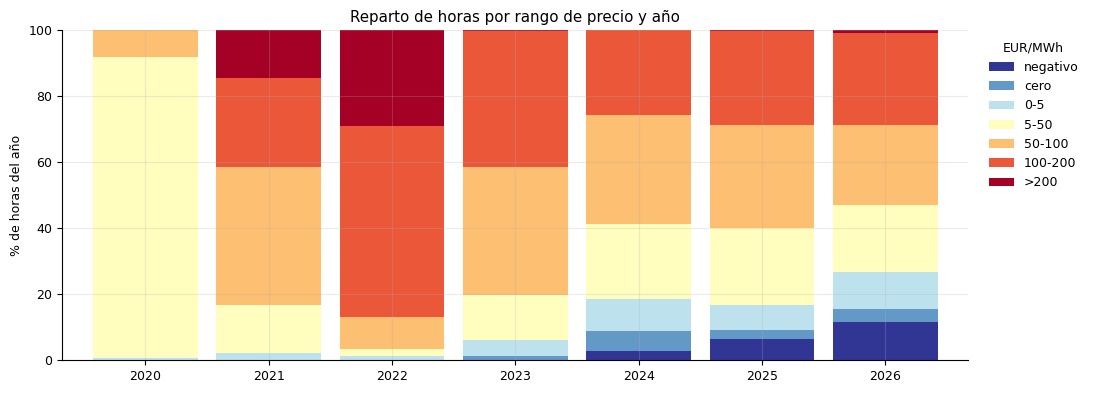

anio,2020,2021,2022,2023,2024,2025,2026
horas con precio ≤ 0,0,0,3,109,784,800,879
horas con precio > 200,0,1255,2487,7,0,20,52


Las horas de precio nulo o negativo son un fenómeno NUEVO, no una cola de la
distribución: prácticamente inexistentes hasta 2023 y crecientes desde entonces.
Las horas muy caras siguen el camino inverso, concentradas en la crisis de 2021-2022.

Ambas cosas importan al almacenamiento por motivos opuestos: las primeras son las horas
en que cargar llega a estar retribuido, y las segundas las que concentran el ingreso.
  [P.9] confirmado: La composición del precio por rango cambia radicalmente entre años


In [31]:
pct = t.div(t.sum(axis=1), axis=0) * 100
ax = pct.plot(kind="bar", stacked=True, figsize=(11, 4), colormap="RdYlBu_r", width=0.85)
ax.set_ylabel("% de horas del año"); ax.set_xlabel(""); ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.set_title("Reparto de horas por rango de precio y año")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, title="EUR/MWh")
plt.tight_layout(); plt.show()

baratas = df.assign(cero_o_neg=df[P] <= 0).groupby("anio")["cero_o_neg"].sum()
caras = df.assign(altas=df[P] > 200).groupby("anio")["altas"].sum()
display(pd.DataFrame({"horas con precio ≤ 0": baratas,
                      "horas con precio > 200": caras}).T)

print("Las horas de precio nulo o negativo son un fenómeno NUEVO, no una cola de la")
print("distribución: prácticamente inexistentes hasta 2023 y crecientes desde entonces.")
print("Las horas muy caras siguen el camino inverso, concentradas en la crisis de 2021-2022.\n")
print("Ambas cosas importan al almacenamiento por motivos opuestos: las primeras son las horas")
print("en que cargar llega a estar retribuido, y las segundas las que concentran el ingreso.")

REG.anotar("P.9", "La composición del precio por rango cambia radicalmente entre años",
           "confirmado",
           f"Las horas con precio nulo o negativo pasan de {int(baratas.iloc[0])} a "
           f"{int(baratas.iloc[-1])}. No es una cola de la distribución sino un fenómeno nuevo, "
           "consecuencia del excedente renovable, y define el valor de cargar la batería.")

### Cuánto se aleja de la normalidad, y qué parte del año está en las colas

El histograma muestra la forma; el gráfico cuantil-cuantil la cuantifica frente a la referencia
normal, y la curva de duración —el precio ordenado de mayor a menor— responde a la pregunta que
importa para el almacenamiento: **cuántas horas al año hay realmente por encima o por debajo de
un nivel dado**.

La curva de duración es el instrumento habitual en planificación de sistemas eléctricos, y aquí
tiene una lectura directa: la anchura de sus extremos es el número de horas en que una batería
podría operar con margen.

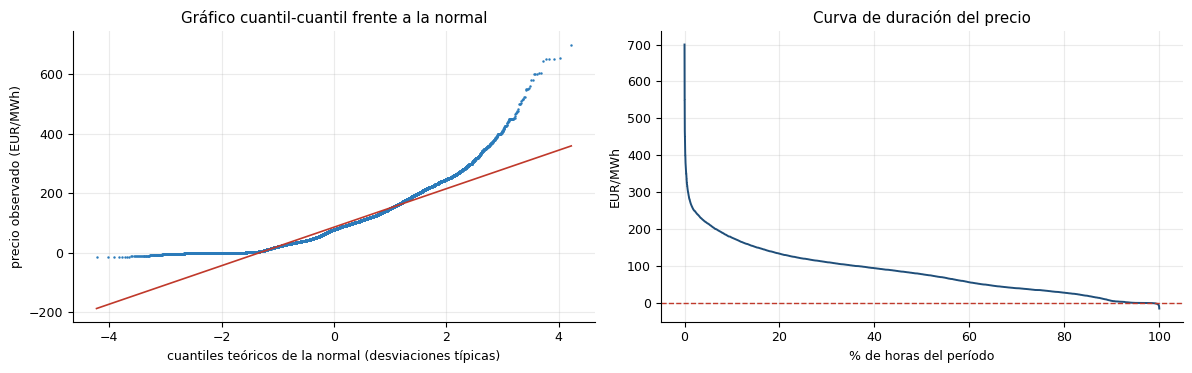

Horas con precio    por encima de 200:  3,821  ( 6.55 % ·   574 h/año)
Horas con precio    por encima de 100: 21,102  (36.19 % ·  3170 h/año)
Horas con precio    menor o igual a 0:  2,575  ( 4.42 % ·   387 h/año)

Las colas son estrechas en porcentaje pero suficientes en horas absolutas: es
precisamente en ellas donde se concentra el margen del arbitraje.


In [32]:
from scipy import stats

p_ord = np.sort(p.values)[::-1]
horas_pct = np.arange(1, len(p_ord) + 1) / len(p_ord) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

stats.probplot(p.values, dist="norm", plot=axes[0])
axes[0].get_lines()[0].set(marker=".", markersize=1.5, color=PALETA["secundario"])
axes[0].get_lines()[1].set(color=PALETA["alerta"], lw=1.2)
axes[0].set_title("Gráfico cuantil-cuantil frente a la normal")
axes[0].set_xlabel("cuantiles teóricos de la normal (desviaciones típicas)"); axes[0].set_ylabel("precio observado (EUR/MWh)")

axes[1].plot(horas_pct, p_ord, lw=1.4, color=PALETA["principal"])
axes[1].axhline(0, color=PALETA["alerta"], lw=1, ls="--")
axes[1].set_xlabel("% de horas del período"); axes[1].set_ylabel("EUR/MWh")
axes[1].set_title("Curva de duración del precio")
plt.tight_layout(); plt.show()

for umbral in (200, 100, 0):
    n = int((p > umbral).sum()) if umbral > 0 else int((p <= 0).sum())
    etq = f"por encima de {umbral}" if umbral > 0 else "menor o igual a 0"
    print(f"Horas con precio {etq:>20s}: {n:6,}  ({n / len(p) * 100:5.2f} % · "
          f"{n / (len(p) / 8760):5.0f} h/año)")
print("\nLas colas son estrechas en porcentaje pero suficientes en horas absolutas: es")
print("precisamente en ellas donde se concentra el margen del arbitraje.")

La asimetría y la curtosis anteriores son el diagnóstico que, en la metodología del máster,
motiva probar transformaciones (`mejorTransfCorr`). La búsqueda de la transformación no se hace
aquí: se hace en el cuaderno de ingeniería, apartado 4.8, sobre `train` y con verificación
posterior en validación. Su apartado 0.2 explica por qué esa verificación es imprescindible.

## 3.4 · La estructura horaria no es estacionaria

**Es el resultado más importante del análisis.** El perfil horario medio del precio ha cambiado
de forma durante el propio período de entrenamiento.

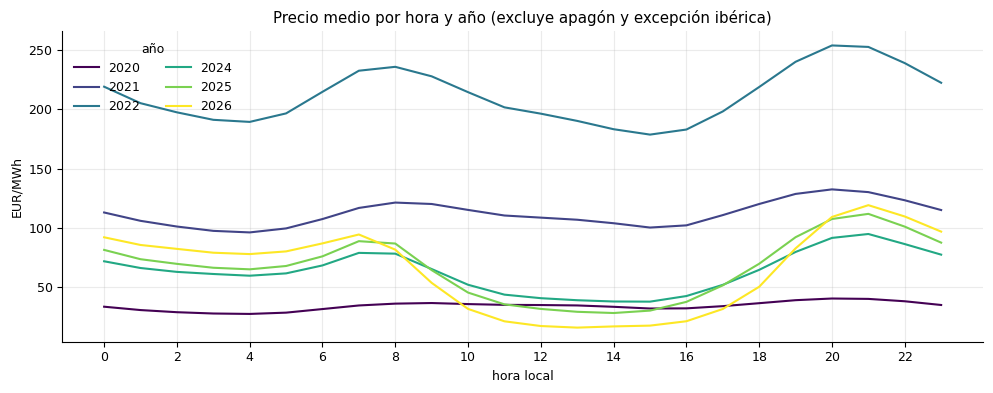

anio,2020,2021,2022,2024,2025,2026
amplitud (EUR/MWh),13.0,36.3,75.2,57.1,83.7,103.3
hora del mínimo,4.0,4.0,15.0,15.0,14.0,13.0


La hora barata del día se desplaza de la madrugada al mediodía y la diferencia entre
la hora más cara y la más barata se multiplica varias veces.

  [P.0] confirmado: El perfil horario del precio no es estacionario en el período


In [33]:
perfil = NORMAL.pivot_table(index="hora", columns="anio", values=P, aggfunc="mean")
ax = perfil.plot(figsize=(10, 4), colormap="viridis", lw=1.5)
ax.set_xlabel("hora local"); ax.set_ylabel("EUR/MWh"); ax.set_xticks(range(0, 24, 2))
ax.set_title("Precio medio por hora y año (excluye apagón y excepción ibérica)")
ax.legend(title="año", frameon=False, ncol=2)
plt.tight_layout(); plt.show()

resumen = pd.DataFrame({"amplitud (EUR/MWh)": (perfil.max() - perfil.min()).round(1),
                        "hora del mínimo": perfil.idxmin()})
display(resumen.T)
print("La hora barata del día se desplaza de la madrugada al mediodía y la diferencia entre")
print("la hora más cara y la más barata se multiplica varias veces.\n")

REG.anotar("P.0", "El perfil horario del precio no es estacionario en el período", "confirmado",
           "Un modelo entrenado sobre el histórico completo con igual peso aprende una "
           "estructura horaria que ya no existe. Ponderar los años recientes, incluir la "
           "capacidad fotovoltaica instalada como regresor, o ambas cosas.")

## 3.5 · Los regímenes son procesos distintos

Dos tramos del histórico no responden al mismo mecanismo de formación de precios: la excepción
ibérica y el apagón peninsular. No son observaciones extremas, son **otro proceso**.

,count,mean,std,min,5%,50%,95%,max
regimen,,,,,,,,
apagón,216.0,14.19,21.80,-10.0,-4.00,4.3,56.54,117.01
excepción ibérica,13558.0,102.63,47.82,0.0,6.74,105.0,176.00,300.00
normal,44539.0,81.05,71.47,-15.0,0.00,62.9,224.01,700.00


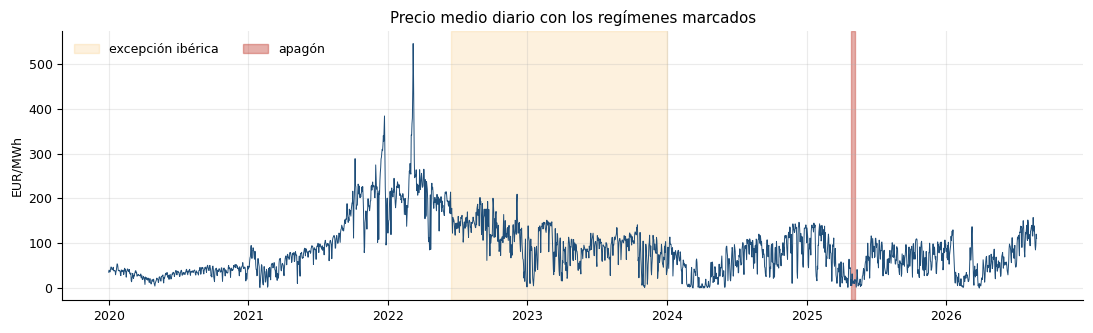

Razón mediana entre el precio eléctrico y el del gas, por régimen:


regimen,apagón,excepción ibérica,normal
precio / gas,0.88,2.28,2.57


El tope al gas desacopló ambas series: no es ruido, es otro mecanismo.
  [P.2] confirmado: Dos tramos del histórico responden a otro mecanismo de precios


In [34]:
display(df.groupby("regimen")[P].describe(percentiles=[.05, .5, .95]).round(2))

diario = df.groupby("dia")[P].mean()
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(pd.to_datetime(diario.index), diario.values, lw=0.7, color=PALETA["principal"])
ax.axvspan(EXCEPCION[0].tz_localize(None), EXCEPCION[1].tz_localize(None),
           alpha=0.15, color=PALETA["acento"], label="excepción ibérica")
ax.axvspan(APAGON[0].tz_localize(None), APAGON[1].tz_localize(None),
           alpha=0.40, color=PALETA["alerta"], label="apagón")
ax.set_ylabel("EUR/MWh"); ax.legend(frameon=False, ncol=2)
ax.set_title("Precio medio diario con los regímenes marcados")
plt.tight_layout(); plt.show()

if GAS:
    d = df[["regimen", P, GAS]].dropna()
    ratio = (d[P] / d[GAS].replace(0, np.nan)).groupby(d["regimen"]).median().round(2)
    print("Razón mediana entre el precio eléctrico y el del gas, por régimen:")
    display(ratio.rename("precio / gas").to_frame().T)
    print("El tope al gas desacopló ambas series: no es ruido, es otro mecanismo.")

REG.anotar("P.2", "Dos tramos del histórico responden a otro mecanismo de precios", "confirmado",
           "Marcar el régimen como variable indicadora y decidir explícitamente si se "
           "entrena con esos tramos, en lugar de dejarlos entrar sin señalar.")

## 3.6 · El precio frente al gas: el coste marginal implícito

Durante buena parte del histórico es el ciclo combinado quien marca el precio marginal, de modo
que el precio debería seguir al gas con un factor próximo al rendimiento de la central. Es la
relación fundamental del mercado, y merece examinarse por separado por dos motivos.

El primero es que **la excepción ibérica la rompe por construcción**: el tope al precio del gas
desacopla ambas series, y comprobarlo valida de paso que las fechas del mecanismo que se están
empleando son las correctas.

El segundo, y más útil para el modelado, es que **esa relación no es uniforme**. El gas sólo fija
el precio cuando la térmica es la tecnología marginal, es decir, en las horas caras. En las horas
baratas marca la renovable, cuyo coste variable es nulo y no guarda relación alguna con el gas.
Una correlación global promedia ambos regímenes y no describe ninguno.

Mediana por régimen (el ratio es el coste marginal implícito):


,spot_es_esios,commodities_gas_mibgas,ratio
regimen,,,
apagón,28.10,31.78,0.88
excepción ibérica,113.69,43.10,2.28
normal,79.69,33.42,2.57


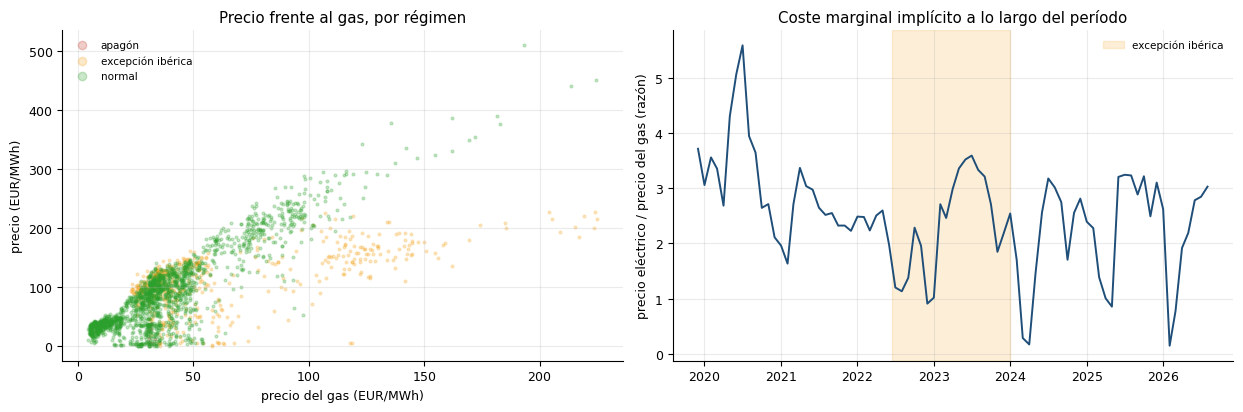

Ratio mediano en régimen normal      : 2.57
Ratio mediano bajo la excepción      : 2.28

El desplome del ratio durante la excepción confirma el desacople y valida las
fechas del mecanismo: no es ruido, es otro mecanismo de formación de precios.


In [35]:
if GAS:
    g = df[["ts_utc", "regimen", "anio", "hora", P, GAS]].dropna().copy()
    g["ratio"] = g[P] / g[GAS].replace(0, np.nan)
    print("Mediana por régimen (el ratio es el coste marginal implícito):")
    display(g.groupby("regimen")[[P, GAS, "ratio"]].median().round(2))

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
    colores_reg = {"normal": PALETA["ok"], "excepción ibérica": PALETA["acento"],
                   "apagón": PALETA["alerta"]}
    for r_, sub in g.groupby("regimen"):
        axes[0].scatter(sub[GAS], sub[P], s=4, alpha=0.25,
                        color=colores_reg.get(r_, PALETA["neutro"]), label=r_)
    axes[0].set_xlabel("precio del gas (EUR/MWh)"); axes[0].set_ylabel("precio (EUR/MWh)")
    axes[0].set_title("Precio frente al gas, por régimen")
    axes[0].legend(frameon=False, markerscale=3, fontsize=7.5)

    rr = g.set_index("ts_utc")["ratio"].resample("MS").median()
    axes[1].plot(rr.index, rr.values, lw=1.4, color=PALETA["principal"])
    axes[1].axvspan(EXCEPCION[0].tz_localize(None), EXCEPCION[1].tz_localize(None),
                    alpha=0.18, color=PALETA["acento"], label="excepción ibérica")
    axes[1].set_ylabel("precio eléctrico / precio del gas (razón)"); axes[1].set_xlabel("")
    axes[1].set_title("Coste marginal implícito a lo largo del período")
    axes[1].legend(frameon=False, fontsize=7.5)
    plt.tight_layout(); plt.show()

    r_norm = g.loc[g["regimen"] == "normal", "ratio"].median()
    r_exc = g.loc[g["regimen"] == "excepción ibérica", "ratio"].median()
    print(f"Ratio mediano en régimen normal      : {r_norm:.2f}")
    print(f"Ratio mediano bajo la excepción      : {r_exc:.2f}")
    print("\nEl desplome del ratio durante la excepción confirma el desacople y valida las")
    print("fechas del mecanismo: no es ruido, es otro mecanismo de formación de precios.")

### El gas pesa en las horas caras y no en las baratas

La comprobación decisiva. Se divide el histórico en deciles de precio y se mide, **dentro de
cada uno**, la asociación entre el precio y el gas. Si la hipótesis del párrafo anterior es
cierta, la asociación debe crecer con el nivel de precio.

,precio medio,r con el gas,ratio mediano,horas
decil,,,,
1,9.384,-0.240,0.245,186.0
2,27.799,0.002,2.734,186.0
3,36.723,-0.092,2.809,185.0
4,47.229,0.452,2.580,186.0
5,69.776,-0.047,2.312,185.0
6,87.100,0.202,2.659,186.0
7,102.253,0.046,2.875,185.0
8,119.359,0.247,2.981,186.0
9,160.108,0.688,2.645,185.0


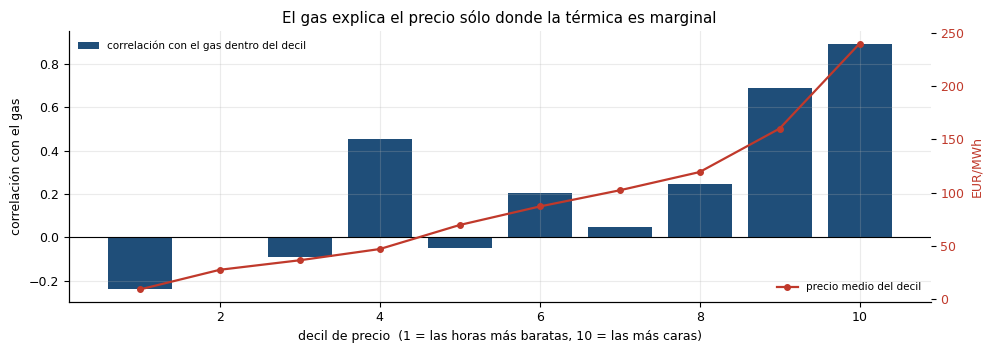

Correlación media con el gas en los tres deciles más baratos : -0.1100
Correlación media con el gas en los tres deciles más caros   : +0.6096
Diferencia: +0.7196

  [P.10] confirmado: El gas explica el precio sólo en las horas caras


In [36]:
if GAS:
    gn = g[g["regimen"] == "normal"].copy()
    gn["decil"] = pd.qcut(gn[P], 10, labels=False, duplicates="drop") + 1

    por_decil = gn.groupby("decil").apply(lambda x: pd.Series({
        "precio medio": x[P].mean(),
        "r con el gas": corr_segura(x[P], x[GAS]),
        "ratio mediano": x["ratio"].median(),
        "horas": len(x)}), include_groups=False)
    display(por_decil.round(3))

    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.bar(por_decil.index, por_decil["r con el gas"], color=PALETA["principal"],
           label="correlación con el gas dentro del decil")
    ax.set_xlabel("decil de precio  (1 = las horas más baratas, 10 = las más caras)")
    ax.set_ylabel("correlación con el gas")
    ax.axhline(0, color="black", lw=0.8)
    ax2 = ax.twinx()
    ax2.plot(por_decil.index, por_decil["precio medio"], color=PALETA["alerta"], lw=1.6,
             marker="o", ms=4, label="precio medio del decil")
    ax2.set_ylabel("EUR/MWh", color=PALETA["alerta"])
    ax2.tick_params(axis="y", labelcolor=PALETA["alerta"]); ax2.grid(False)
    ax.set_title("El gas explica el precio sólo donde la térmica es marginal")
    ax.legend(loc="upper left", frameon=False, fontsize=7.5)
    ax2.legend(loc="lower right", frameon=False, fontsize=7.5)
    plt.tight_layout(); plt.show()

    bajo = por_decil.loc[por_decil.index <= 3, "r con el gas"].mean()
    alto = por_decil.loc[por_decil.index >= 8, "r con el gas"].mean()
    print(f"Correlación media con el gas en los tres deciles más baratos : {bajo:+.4f}")
    print(f"Correlación media con el gas en los tres deciles más caros   : {alto:+.4f}")
    print(f"Diferencia: {alto - bajo:+.4f}\n")

    REG.anotar("P.10", "El gas explica el precio sólo en las horas caras", "confirmado",
               f"La correlación con el gas pasa de {bajo:+.3f} en los deciles baratos a "
               f"{alto:+.3f} en los caros. Es la firma de un cambio de tecnología marginal: "
               "renovable abajo, ciclo combinado arriba. Un coeficiente global promedia dos "
               "regímenes distintos, y el modelado debería permitir que el efecto del gas "
               "dependa del nivel — por interacción o por un modelo no lineal.")

Es un resultado con consecuencia directa sobre el modelado, y no sólo descriptivo. El precio del
gas es una de las **pocas variables sin fuga** de que se dispone —cierra antes del mercado
eléctrico—, de modo que saber *dónde* aporta importa tanto como saber *cuánto*. Su información se
concentra en las horas que además son las que producen el ingreso de la batería, que es
precisamente donde el modelo tiene que acertar.

Justifica también la variable derivada `coste_ccgt` que el cuaderno de ingeniería construye en su
apartado 4.5: combinar gas y CO2 en el coste marginal del ciclo combinado es más informativo que
darle al modelo las dos series por separado.

## 3.7 · La estructura de dependencia temporal del precio

El precio del mercado diario presenta una fuerte dependencia de sus propios valores pasados. La
magnitud de esa dependencia establece la referencia mínima que debe superar cualquier variable
explicativa exógena para justificar su incorporación al modelo.

**Este apartado mide la dependencia; no construye los retardos.** La construcción de las
variables retardadas y la elección de cuáles entran al modelo corresponden al cuaderno de
ingeniería, apartado 4.2, y se deciden sobre `train`.

### Autocorrelación simple y parcial

Se parte de los dos estadísticos canónicos del análisis de series temporales. La función de
autocorrelación (ACF) mide la asociación entre el precio y su valor *k* horas antes, incluyendo
todo lo que pasa por los retardos intermedios. La autocorrelación **parcial** (PACF) descuenta
precisamente esa transmisión y aísla la aportación propia de cada retardo.

La distinción es la que decide cuántos retardos hay que construir: si la ACF decae despacio pero
la PACF se corta tras unos pocos, la dependencia aparente de los retardos lejanos se explica por
los cercanos y añadirlos al modelo sería redundante.

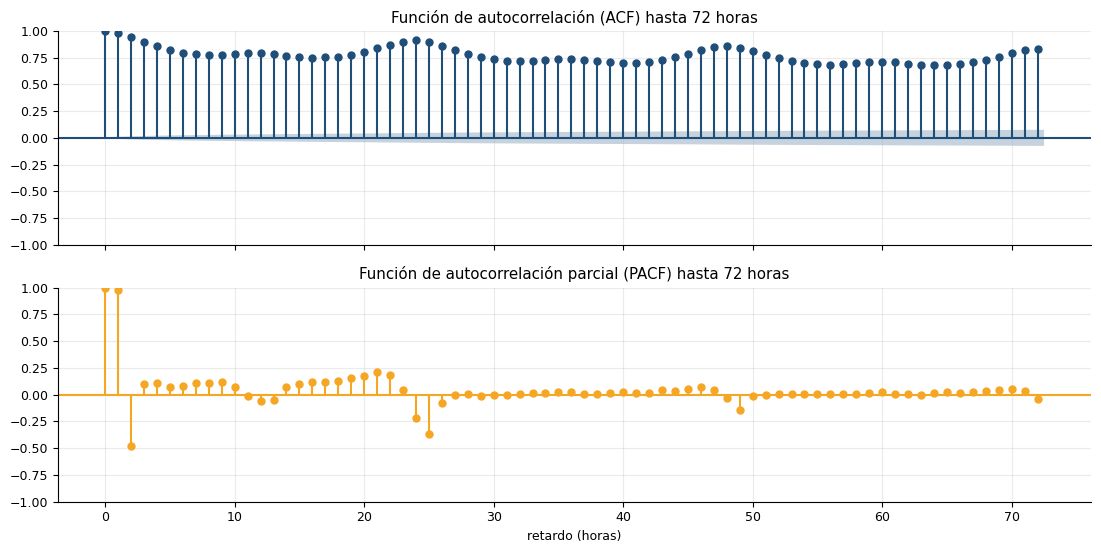

Retardos con autocorrelación parcial significativa: 60 de 72
Los diez primeros: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

La PACF sigue siendo significativa en el retardo 24 (-0.215) y en el 48 (-0.033),
de modo que el ciclo diario aporta información propia y no sólo transmitida por los
retardos cercanos. Es la justificación formal de construir el retardo de 24 horas.


In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

s_completa = df.set_index("ts_utc")[P].asfreq("h").interpolate(limit=3).dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
plot_acf(s_completa, lags=72, ax=axes[0], color=PALETA["principal"],
         vlines_kwargs={"colors": PALETA["principal"]})
axes[0].set_title("Función de autocorrelación (ACF) hasta 72 horas")
plot_pacf(s_completa, lags=72, ax=axes[1], method="ywm", color=PALETA["acento"],
          vlines_kwargs={"colors": PALETA["acento"]})
axes[1].set_title("Función de autocorrelación parcial (PACF) hasta 72 horas")
axes[1].set_xlabel("retardo (horas)")
for a in axes:
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

from statsmodels.tsa.stattools import pacf as _pacf
vals = _pacf(s_completa, nlags=72, method="ywm")
umbral = 1.96 / np.sqrt(len(s_completa))
significativos = [k for k in range(1, 73) if abs(vals[k]) > umbral]
print(f"Retardos con autocorrelación parcial significativa: {len(significativos)} de 72")
print(f"Los diez primeros: {significativos[:10]}")
print(f"\nLa PACF sigue siendo significativa en el retardo 24 ({vals[24]:+.3f}) y en el 48 "
      f"({vals[48]:+.3f}),")
print("de modo que el ciclo diario aporta información propia y no sólo transmitida por los")
print("retardos cercanos. Es la justificación formal de construir el retardo de 24 horas.")

### Descomposición en tendencia, estacionalidad y residuo

La descomposición separa la serie diaria en sus tres componentes. Su interés aquí no es
predictivo sino diagnóstico: **cuantifica qué fracción de la variabilidad del precio es
estructura recurrente y cuál es el residuo** que un modelo tendría que explicar con variables
exógenas.

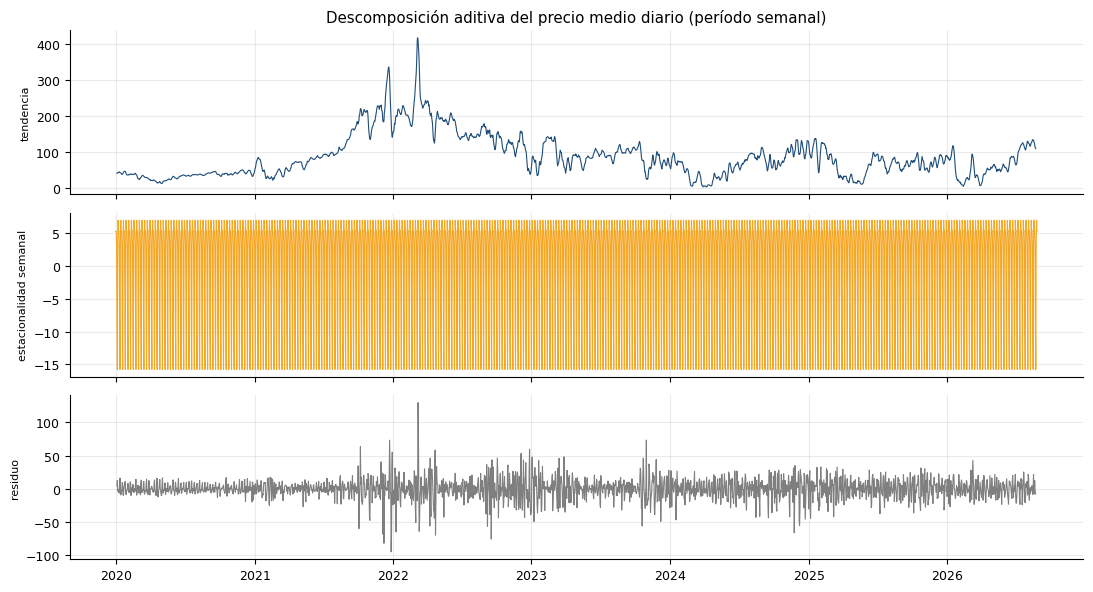

Desviación típica del precio medio diario :  61.72 EUR/MWh
  atribuible a la tendencia               :  58.51
  atribuible a la estacionalidad semanal  :   7.94
  residuo                                 :  15.09

La estacionalidad semanal es de pequeña magnitud frente a la tendencia: el nivel del
precio lo gobiernan los combustibles y el parque de generación, no el calendario. El
calendario importa para la FORMA del día, que es lo que el apartado 3.4 ya mostró.


In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose

diaria = df.groupby("dia")[P].mean()
diaria.index = pd.to_datetime(diaria.index)
diaria = diaria.asfreq("D").interpolate(limit=3).dropna()

desc = seasonal_decompose(diaria, model="additive", period=7)
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for ax, comp, etq, col in [(axes[0], desc.trend, "tendencia", PALETA["principal"]),
                           (axes[1], desc.seasonal, "estacionalidad semanal", PALETA["acento"]),
                           (axes[2], desc.resid, "residuo", PALETA["neutro"])]:
    ax.plot(comp.index, comp.values, lw=0.8, color=col)
    ax.set_ylabel(etq, fontsize=8)
axes[0].set_title("Descomposición aditiva del precio medio diario (período semanal)")
plt.tight_layout(); plt.show()

var_total = diaria.var()
print(f"Desviación típica del precio medio diario : {diaria.std():6.2f} EUR/MWh")
print(f"  atribuible a la tendencia               : {desc.trend.std():6.2f}")
print(f"  atribuible a la estacionalidad semanal  : {desc.seasonal.std():6.2f}")
print(f"  residuo                                 : {desc.resid.std():6.2f}")
print("\nLa estacionalidad semanal es de pequeña magnitud frente a la tendencia: el nivel del")
print("precio lo gobiernan los combustibles y el parque de generación, no el calendario. El")
print("calendario importa para la FORMA del día, que es lo que el apartado 3.4 ya mostró.")

In [39]:
s = df.set_index("ts_utc")[P].asfreq("h")
d_ = df.groupby("dia")[P].mean(); d_.index = pd.to_datetime(d_.index)

# Los 192 retardos se descomponen en su día y su desfase horario dentro de ese día:
# el retardo 51, por ejemplo, corresponde al día D-3 con un desfase de 21 horas.
acf = pd.DataFrame({"retardo": range(1, 193)})
acf["r"] = [s.corr(s.shift(k)) for k in acf["retardo"]]
acf["dia"] = (((acf["retardo"] - 1) // 24) + 1).astype(int)
acf["desfase_h"] = (((acf["retardo"] - 1) % 24) + 1).astype(int)
acf["etiqueta"] = acf.apply(
    lambda x: f"D−{int(x['dia'])}, misma hora" if x["desfase_h"] == 24
    else f"D−{int(x['dia'])}, {int(x['desfase_h'])}h antes", axis=1)

print("Autocorrelación del precio:")
for etq_, kh, kd in [("D-1", 24, 1), ("D-2", 48, 2), ("D-7", 168, 7)]:
    print(f"  {etq_}: horaria {s.corr(s.shift(kh)):.4f} · diaria {d_.corr(d_.shift(kd)):.4f}")

print("\nLos diez retardos con mayor correlación, identificados:")
display(acf.nlargest(10, "r")[["retardo", "dia", "desfase_h", "etiqueta", "r"]]
        .round(4).reset_index(drop=True))

Autocorrelación del precio:
  D-1: horaria 0.9107 · diaria 0.9406
  D-2: horaria 0.8571 · diaria 0.8868
  D-7: horaria 0.8181 · diaria 0.8294

Los diez retardos con mayor correlación, identificados:


,retardo,dia,desfase_h,etiqueta,r
0,1,1,1,"D−1, 1h antes",0.9792
1,2,1,2,"D−1, 2h antes",0.9392
2,24,1,24,"D−1, misma hora",0.9107
3,23,1,23,"D−1, 23h antes",0.8999
4,3,1,3,"D−1, 3h antes",0.8946
5,25,2,1,"D−2, 1h antes",0.8946
6,22,1,22,"D−1, 22h antes",0.8705
7,26,2,2,"D−2, 2h antes",0.8604
8,48,2,24,"D−2, misma hora",0.8571
9,4,1,4,"D−1, 4h antes",0.8542


El máximo global de la autocorrelación identifica el retardo más informativo del conjunto.
Su posición dentro del ciclo diario indica si el precio se parece más a sí mismo en la hora
homóloga del día anterior o en alguna hora desplazada.

In [40]:
mejor = acf.loc[acf["r"].idxmax()]
print(f"Retardo con mayor correlación: {int(mejor['retardo'])} horas "
      f"({mejor['etiqueta']}), r = {mejor['r']:.4f}")

r24, r168 = acf.loc[acf["retardo"] == 24, "r"].iat[0], acf.loc[acf["retardo"] == 168, "r"].iat[0]
print(f"\n  Misma hora del día anterior       (retardo  24 h): r = {r24:.4f}")
print(f"  Misma hora de la semana anterior  (retardo 168 h): r = {r168:.4f}")
if r24 > r168:
    print(f"\n  Predomina el día anterior, con una ventaja de {r24 - r168:.4f}.")
else:
    print(f"\n  Predomina la semana anterior, con una ventaja de {r168 - r24:.4f}.")
    print("  El precio se parece más a su valor de hace siete días que al de ayer, lo que")
    print("  indica que el calendario semanal pesa más que la proximidad temporal.")

print("\nMáximo de correlación dentro de cada día anterior:")
res = acf.loc[acf.groupby("dia")["r"].idxmax(), ["dia", "desfase_h", "r"]].set_index("dia")
res.columns = ["desfase horario del máximo", "r"]
display(res.round(4).T)

Retardo con mayor correlación: 1 horas (D−1, 1h antes), r = 0.9792

  Misma hora del día anterior       (retardo  24 h): r = 0.9107
  Misma hora de la semana anterior  (retardo 168 h): r = 0.8181

  Predomina el día anterior, con una ventaja de 0.0926.

Máximo de correlación dentro de cada día anterior:


dia,1,2,3,4,5,6,7,8
desfase horario del máximo,1.0000,1.0000,1.0000,1.0000,1.0000,24.0000,24.0000,1.0000
r,0.9792,0.8946,0.8434,0.8207,0.7997,0.8083,0.8181,0.8052


La representación conjunta permite localizar el máximo dentro del ciclo diario. Se marcan los
retardos de hora homóloga, que son los que sostienen la estructura, y se señala el máximo
global.

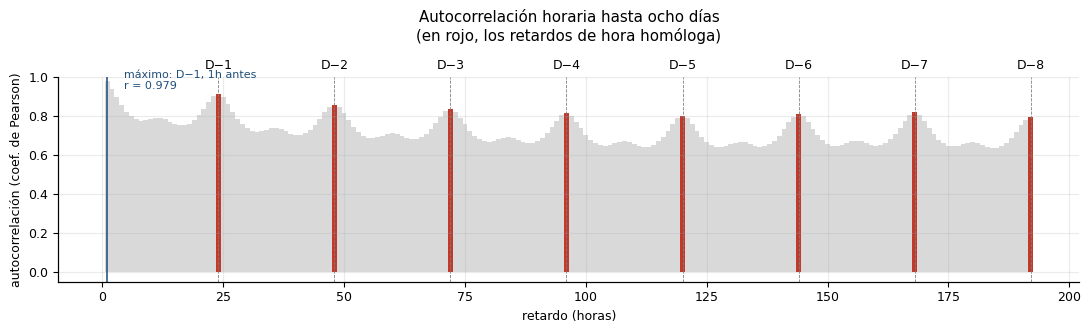

In [41]:
fig, ax = plt.subplots(figsize=(11, 3.4))
misma_hora = acf["desfase_h"] == 24
ax.bar(acf["retardo"], acf["r"], width=1.0,
       color=np.where(misma_hora, PALETA["alerta"], PALETA["suave"]))
ax.axvline(int(mejor["retardo"]), color=PALETA["principal"], lw=1.4, ls="-", alpha=0.8)
ax.annotate(f"máximo: {mejor['etiqueta']}\nr = {mejor['r']:.3f}",
            xy=(mejor["retardo"], mejor["r"]), xytext=(12, -6),
            textcoords="offset points", fontsize=8, color=PALETA["principal"])
sup = ax.twiny(); sup.set_xlim(ax.get_xlim())
sup.set_xticks(range(24, 193, 24), [f"D−{d}" for d in range(1, 9)])
sup.tick_params(length=0); sup.grid(False)
for k in range(24, 193, 24):
    ax.axvline(k, color=PALETA["neutro"], lw=0.6, ls="--")
ax.set_xlabel("retardo (horas)"); ax.set_ylabel("autocorrelación (coef. de Pearson)")
ax.set_ylim(min(0, acf["r"].min()) - 0.05, 1.0)
ax.set_title("Autocorrelación horaria hasta ocho días\n"
             "(en rojo, los retardos de hora homóloga)", pad=26)
plt.tight_layout(); plt.show()

### La autocorrelación descompuesta: una curva por día anterior

El gráfico de barras anterior muestra los 192 retardos en fila, y en esa disposición la
estructura sólo se intuye. Descompuesta —una curva por cada día anterior, y en el eje horizontal
el desfase horario **dentro** de ese día— la misma información se lee de golpe.

Cada curva responde a la pregunta «si retrocedo *d* días y luego *h* horas más, ¿cuánto se parece
el precio?». El punto 24 de cada curva es la hora homóloga, y la separación vertical entre
curvas mide cuánto se degrada la memoria del precio con el horizonte.

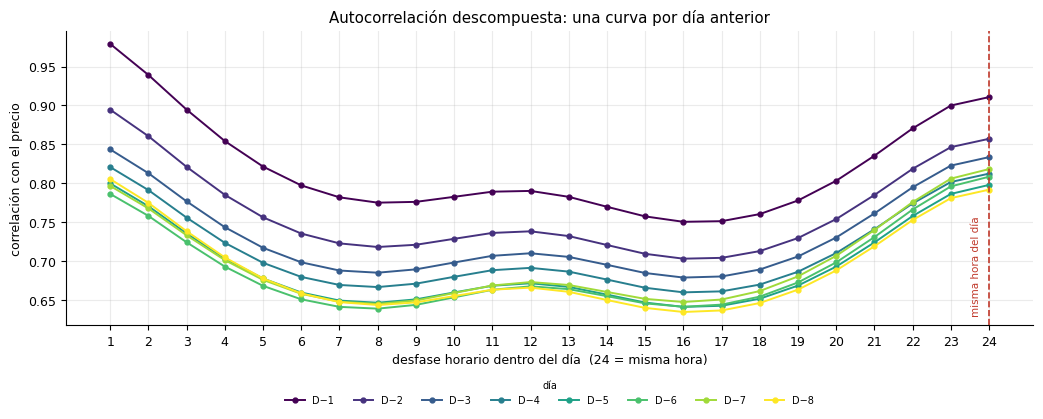

In [42]:
matriz = acf.pivot(index="dia", columns="desfase_h", values="r")
M_desc = acf.pivot(index="desfase_h", columns="dia", values="r")

fig, ax = plt.subplots(figsize=(10.5, 4.4))
cmap = plt.get_cmap("viridis")
for i, d_ in enumerate(M_desc.columns):
    ax.plot(M_desc.index, M_desc[d_], marker="o", ms=3.5, lw=1.4,
            color=cmap(i / max(len(M_desc.columns) - 1, 1)), label=f"D−{d_}")
ax.axvline(24, color=PALETA["alerta"], ls="--", lw=1.2)
ax.annotate("misma hora del día", xy=(24, ax.get_ylim()[0]), xytext=(-6, 8),
            textcoords="offset points", rotation=90, fontsize=7.5,
            color=PALETA["alerta"], ha="right")
ax.set_xticks(range(1, 25))
ax.set_xlabel("desfase horario dentro del día  (24 = misma hora)")
ax.set_ylabel("correlación con el precio")
ax.set_title("Autocorrelación descompuesta: una curva por día anterior")
ax.legend(frameon=False, ncol=8, title="día", fontsize=7, title_fontsize=7,
          loc="lower center", bbox_to_anchor=(0.5, -0.30))
plt.tight_layout(); plt.show()

In [43]:
matriz.index = [f"D−{d}" for d in matriz.index]
print("Correlación media de cada día anterior, sobre sus 24 retardos:")
display(matriz.mean(axis=1).round(4).rename("r media").to_frame().T)
print("\nCorrelación en la hora homóloga de cada día anterior:")
display(matriz[24].round(4).rename("r").to_frame().T)

caida = matriz[24].iloc[0] - matriz[24].iloc[-1]
print(f"\nEntre D−1 y D−{len(matriz)}, la correlación en la hora homóloga cae {caida:.4f}.")
print("La forma de las curvas apenas cambia de un día a otro: lo que se degrada con el")
print("horizonte es el NIVEL de la correlación, no la estructura intradiaria. Eso significa")
print("que un retardo lejano sigue aportando la misma forma del día, sólo que más ruidosa.")

Correlación media de cada día anterior, sobre sus 24 retardos:


,D−1,D−2,D−3,D−4,D−5,D−6,D−7,D−8
r media,0.8187,0.7619,0.7311,0.7114,0.6925,0.6899,0.6973,0.6891



Correlación en la hora homóloga de cada día anterior:


,D−1,D−2,D−3,D−4,D−5,D−6,D−7,D−8
r,0.9107,0.8571,0.8335,0.8123,0.7978,0.8083,0.8181,0.7916



Entre D−1 y D−8, la correlación en la hora homóloga cae 0.1191.
La forma de las curvas apenas cambia de un día a otro: lo que se degrada con el
horizonte es el NIVEL de la correlación, no la estructura intradiaria. Eso significa
que un retardo lejano sigue aportando la misma forma del día, sólo que más ruidosa.


### Persistencia según la hora del día y el horizonte

La autocorrelación agregada oculta que la dependencia del pasado no es igual en todas las horas.
La matriz siguiente calcula, para cada hora de la jornada, la correlación entre su precio y el
de esa misma hora uno a siete días antes.

Las horas con menor persistencia son aquellas en que el precio resulta menos predecible a partir
de su propio histórico, y por tanto aquellas en que las variables exógenas pueden aportar mayor
valor.

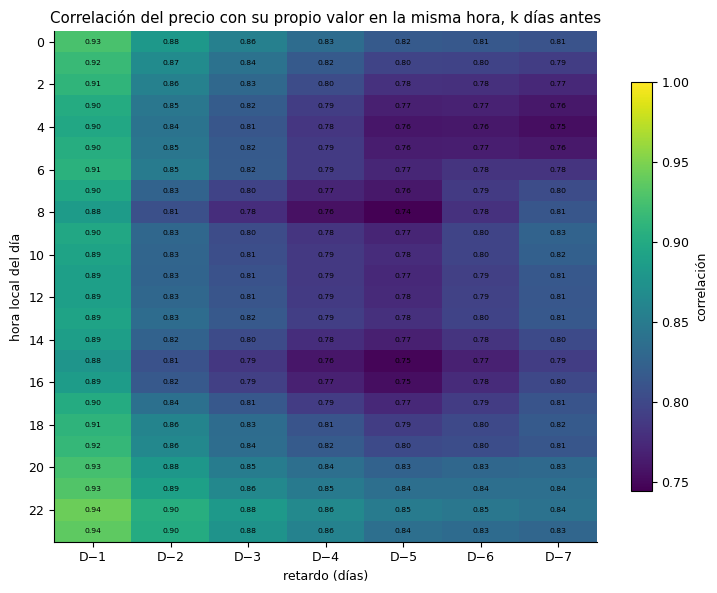

Horas con mayor persistencia diaria: 22h (0.942), 23h (0.937), 21h (0.931)
Horas con menor persistencia diaria: 15h (0.878), 8h (0.885), 16h (0.885)
Diferencia entre extremos: 0.064


In [44]:
# Matriz de días × horas: cada columna es una hora del día y cada fila una fecha.
ancho = df.pivot_table(index="dia", columns="hora", values=P, aggfunc="mean")
ancho.index = pd.to_datetime(ancho.index)
ancho = ancho.sort_index().asfreq("D")

RETARDOS = range(1, 8)
M = pd.DataFrame({f"D−{k}": {h: ancho[h].corr(ancho[h].shift(k)) for h in ancho.columns}
                  for k in RETARDOS})

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(M.values, aspect="auto", cmap="viridis", vmin=np.nanmin(M.values), vmax=1)
ax.set_xticks(range(len(M.columns)), M.columns)
ax.set_yticks(range(0, 24, 2), range(0, 24, 2))
ax.set_xlabel("retardo (días)"); ax.set_ylabel("hora local del día")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if pd.notna(M.iloc[i, j]):
            ax.text(j, i, f"{M.iloc[i, j]:.2f}", ha="center", va="center", fontsize=5.5,
                    color="white" if M.iloc[i, j] < 0.7 else "black")
ax.set_title("Correlación del precio con su propio valor en la misma hora, k días antes")
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.8, label="correlación")
plt.tight_layout(); plt.show()

d1 = M["D−1"]
print(f"Horas con mayor persistencia diaria: "
      f"{', '.join(f'{h}h ({d1[h]:.3f})' for h in d1.nlargest(3).index)}")
print(f"Horas con menor persistencia diaria: "
      f"{', '.join(f'{h}h ({d1[h]:.3f})' for h in d1.nsmallest(3).index)}")
print(f"Diferencia entre extremos: {d1.max() - d1.min():.3f}")

### Persistencia según la hora y el día de la semana

El último nivel de detalle combina ambas dimensiones. Para cada combinación de hora y día de la
semana se calcula la correlación con el valor de la misma hora del día anterior.

El interés reside en localizar las combinaciones en que el retardo diario pierde capacidad
explicativa, que corresponden previsiblemente a las transiciones entre jornada laborable y fin
de semana.

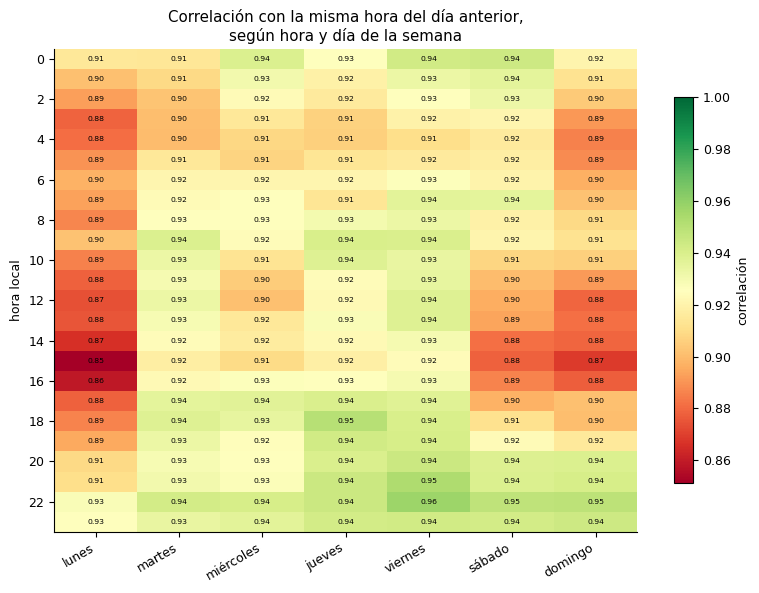

Combinaciones con menor persistencia diaria:
  lunes       a las 15h · r = 0.851
  lunes       a las 16h · r = 0.859
  lunes       a las 14h · r = 0.866
  domingo     a las 15h · r = 0.869
  lunes       a las 12h · r = 0.874

Media por día de la semana:


,lunes,martes,miércoles,jueves,viernes,sábado,domingo
r media con D−1,0.8899,0.9243,0.9222,0.9281,0.9343,0.9169,0.904


In [45]:
previo = ancho.shift(1)
dow = ancho.index.dayofweek

HD = pd.DataFrame(index=range(24), columns=DIAS, dtype=float)
for j, nombre in enumerate(DIAS):
    sel = dow == j
    for h in ancho.columns:
        par = pd.concat([ancho.loc[sel, h], previo.loc[sel, h]], axis=1).dropna()
        HD.loc[h, nombre] = par.iloc[:, 0].corr(par.iloc[:, 1]) if len(par) > 30 else np.nan

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(HD.values.astype(float), aspect="auto", cmap="RdYlGn",
               vmin=np.nanmin(HD.values.astype(float)), vmax=1)
ax.set_xticks(range(7), DIAS, rotation=30, ha="right")
ax.set_yticks(range(0, 24, 2), range(0, 24, 2))
ax.set_ylabel("hora local")
for i in range(24):
    for j in range(7):
        v = HD.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5.5,
                    color="white" if v < 0.55 else "black")
ax.set_title("Correlación con la misma hora del día anterior,\nsegún hora y día de la semana")
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.8, label="correlación")
plt.tight_layout(); plt.show()

plano = HD.stack().dropna()
print("Combinaciones con menor persistencia diaria:")
for (h, dia_sem), v in plano.nsmallest(5).items():
    print(f"  {dia_sem:11s} a las {h:2d}h · r = {v:.3f}")
print("\nMedia por día de la semana:")
display(HD.mean().round(4).rename("r media con D−1").to_frame().T)

### La dependencia temporal no es homogénea entre días de la semana

La autocorrelación calculada sobre el conjunto completo promedia situaciones heterogéneas. El
retardo de veinticuatro horas relaciona cada día con el anterior, y esa relación no es
equivalente en todos los casos: para un lunes, el día anterior es un domingo, con un perfil de
demanda sustancialmente distinto; para un sábado, un viernes laborable.

Si la calidad del retardo diario depende del día de la semana, un modelo que emplee esa variable
de forma uniforme desaprovecha información. El contraste con el retardo semanal, que siempre
relaciona días homólogos, permite cuantificar el efecto.

,ayer (D−1),hace una semana (D−7),ventaja de D−7
lunes,0.8792,0.7895,-0.0897
martes,0.9288,0.7843,-0.1445
miércoles,0.9264,0.7979,-0.1285
jueves,0.9325,0.8429,-0.0895
viernes,0.9380,0.8519,-0.0862
sábado,0.9146,0.8420,-0.0727
domingo,0.9112,0.8046,-0.1067


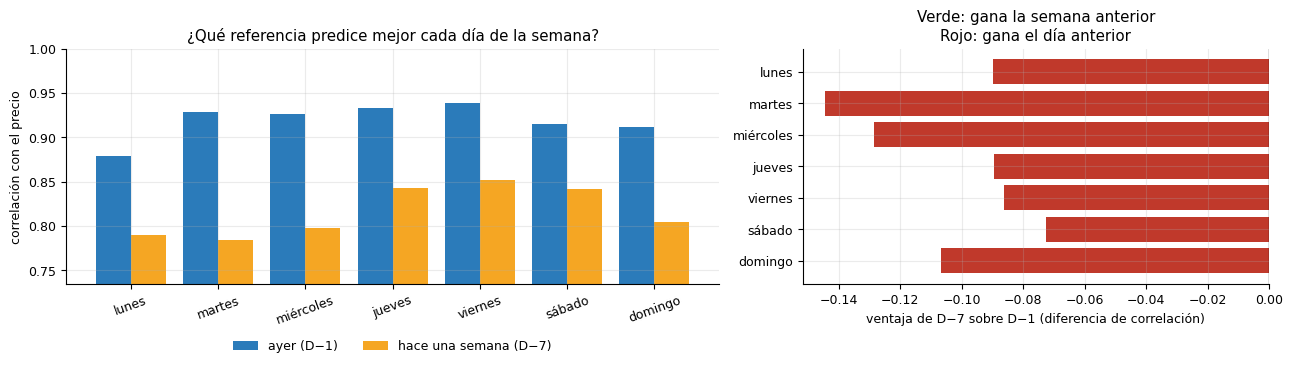

In [46]:
marco = pd.DataFrame({"precio": s, "lag_24h": s.shift(24), "lag_168h": s.shift(168)}).dropna()
marco["dow"] = marco.index.tz_convert(TZ).dayofweek

comparativa = marco.groupby("dow").apply(
    lambda g: pd.Series({"r con D-1": g["precio"].corr(g["lag_24h"]),
                         "r con D-7": g["precio"].corr(g["lag_168h"])}),
    include_groups=False)
comparativa.index = DIAS
comparativa.columns = ["ayer (D−1)", "hace una semana (D−7)"]
comparativa["ventaja de D−7"] = (comparativa["hace una semana (D−7)"]
                                 - comparativa["ayer (D−1)"])
display(comparativa.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1.4, 1]})

x = np.arange(7)
axes[0].bar(x - 0.2, comparativa["ayer (D−1)"], width=0.4, color=PALETA["secundario"],
            label="ayer (D−1)")
axes[0].bar(x + 0.2, comparativa["hace una semana (D−7)"], width=0.4, color=PALETA["acento"],
            label="hace una semana (D−7)")
axes[0].set_xticks(x, DIAS, rotation=20)
axes[0].set_ylabel("correlación con el precio")
axes[0].set_ylim(comparativa[["ayer (D−1)", "hace una semana (D−7)"]].min().min() - 0.05, 1.0)
axes[0].set_title("¿Qué referencia predice mejor cada día de la semana?")
axes[0].legend(frameon=False, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.34))

colores = [PALETA["ok"] if v > 0 else PALETA["alerta"] for v in comparativa["ventaja de D−7"]]
axes[1].barh(DIAS[::-1], comparativa["ventaja de D−7"][::-1], color=colores[::-1])
axes[1].axvline(0, color="black", lw=0.9)
axes[1].set_xlabel("ventaja de D−7 sobre D−1 (diferencia de correlación)")
axes[1].set_title("Verde: gana la semana anterior\nRojo: gana el día anterior")
plt.tight_layout(); plt.show()

In [47]:
peor = comparativa["ayer (D−1)"].idxmin()
mejor_d = comparativa["ayer (D−1)"].idxmax()
rango = comparativa["ayer (D−1)"].max() - comparativa["ayer (D−1)"].min()

print(f"El retardo de 24 h alcanza su valor más bajo en {peor} "
      f"({comparativa.loc[peor, 'ayer (D−1)']:.4f}) y el más alto en {mejor_d} "
      f"({comparativa.loc[mejor_d, 'ayer (D−1)']:.4f}).")
print(f"Diferencia entre ambos extremos: {rango:.4f}.\n")

favorables = comparativa[comparativa["ventaja de D−7"] > 0].index.tolist()
if favorables:
    print(f"El retardo semanal supera al diario en: {', '.join(favorables)}.")
    print("En esos días, la referencia homóloga de la semana anterior resulta más informativa")
    print("que la del día inmediatamente previo.")
else:
    print("El retardo diario supera al semanal en todos los días de la semana.")

REG.anotar("P.1", "La utilidad del retardo diario depende del día de la semana",
           "confirmado",
           "Incorporar la interacción entre el retardo y el día de la semana, o emplear el "
           "retardo semanal en las transiciones entre fin de semana y jornada laborable.")

El retardo de 24 h alcanza su valor más bajo en lunes (0.8792) y el más alto en viernes (0.9380).
Diferencia entre ambos extremos: 0.0588.

El retardo diario supera al semanal en todos los días de la semana.
  [P.1] confirmado: La utilidad del retardo diario depende del día de la semana


### Perfil horario por día de la semana

La distinción entre jornada laborable y fin de semana no se limita a un desplazamiento de nivel.
Si la forma del perfil difiere entre ambos casos, el modelo requiere una interacción entre la
hora del día y el día de la semana, y no basta con una variable indicadora de laboralidad.

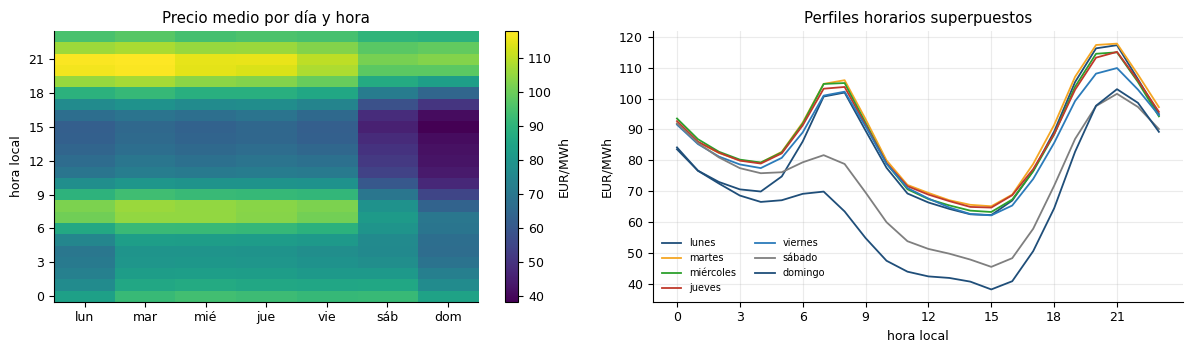

,lunes,martes,miércoles,jueves,viernes,sábado,domingo
nivel medio (EUR/MWh),83.4,87.7,86.4,86.5,84.4,73.2,65.6
amplitud del perfil (EUR/MWh),55.0,52.6,51.7,50.4,47.7,56.0,64.8


In [48]:
sem = NORMAL.pivot_table(index="hora", columns="dow", values=P, aggfunc="mean")
sem.columns = DIAS

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
im = axes[0].imshow(sem.values, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_xticks(range(7), [d[:3] for d in DIAS])
axes[0].set_yticks(range(0, 24, 3)); axes[0].set_ylabel("hora local")
axes[0].set_title("Precio medio por día y hora"); axes[0].grid(False)
fig.colorbar(im, ax=axes[0], label="EUR/MWh")

sem.plot(ax=axes[1], lw=1.3)
axes[1].set_xlabel("hora local"); axes[1].set_ylabel("EUR/MWh")
axes[1].set_xticks(range(0, 24, 3))
axes[1].set_title("Perfiles horarios superpuestos")
axes[1].legend(frameon=False, ncol=2, fontsize=7)
plt.tight_layout(); plt.show()

display(pd.DataFrame({"nivel medio (EUR/MWh)": sem.mean().round(1),
                      "amplitud del perfil (EUR/MWh)": (sem.max() - sem.min()).round(1)}).T)

## 3.8 · El diferencial diario: lo que aprovecha la batería

El ingreso por arbitraje depende del **diferencial intradiario**, no del nivel del precio. Un año
caro con precios planos deja menos margen que uno barato con volatilidad.

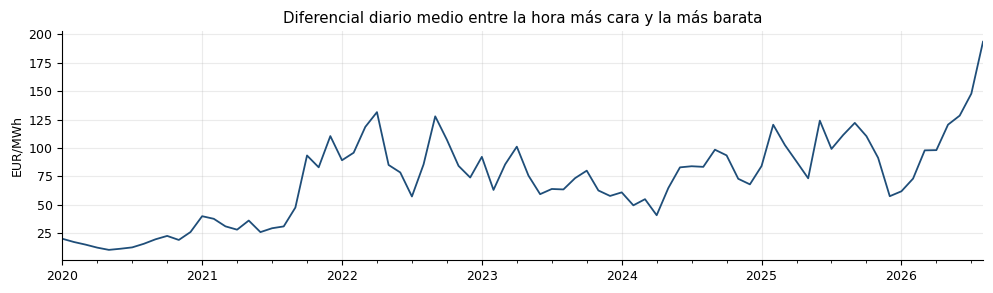

,mínimo,máximo,diferencial_medio,días_con_mínimo_negativo
dia,,,,
2020,1.0,68.9,16.9,0
2021,0.0,409.0,49.6,0
2022,0.0,700.0,94.4,0
2023,0.0,220.0,73.3,0
2024,-2.0,193.0,71.3,46
2025,-15.0,240.0,98.4,89
2026,-9.8,255.2,114.0,108


In [49]:
sp = df.groupby("dia")[P].agg(["min", "max", "mean"]).dropna()
sp.index = pd.to_datetime(sp.index)
sp["diferencial"] = sp["max"] - sp["min"]

ax = sp["diferencial"].resample("MS").mean().plot(figsize=(10, 3),
    color=PALETA["principal"], lw=1.3)
ax.set_ylabel("EUR/MWh"); ax.set_xlabel("")
ax.set_title("Diferencial diario medio entre la hora más cara y la más barata")
plt.tight_layout(); plt.show()

display(sp.groupby(sp.index.year).agg(
    mínimo=("min", "min"), máximo=("max", "max"),
    diferencial_medio=("diferencial", "mean"),
    días_con_mínimo_negativo=("min", lambda x: (x < 0).sum())).round(1))

### La banda diaria completa

La media mensual del diferencial resume; la banda entre el mínimo y el máximo de cada día muestra
la materia prima del arbitraje tal cual es. El área sombreada **es literalmente el ingreso
potencial** de una batería con previsión perfecta, y su anchura variable explica por qué el valor
del almacenamiento no es constante a lo largo del período.

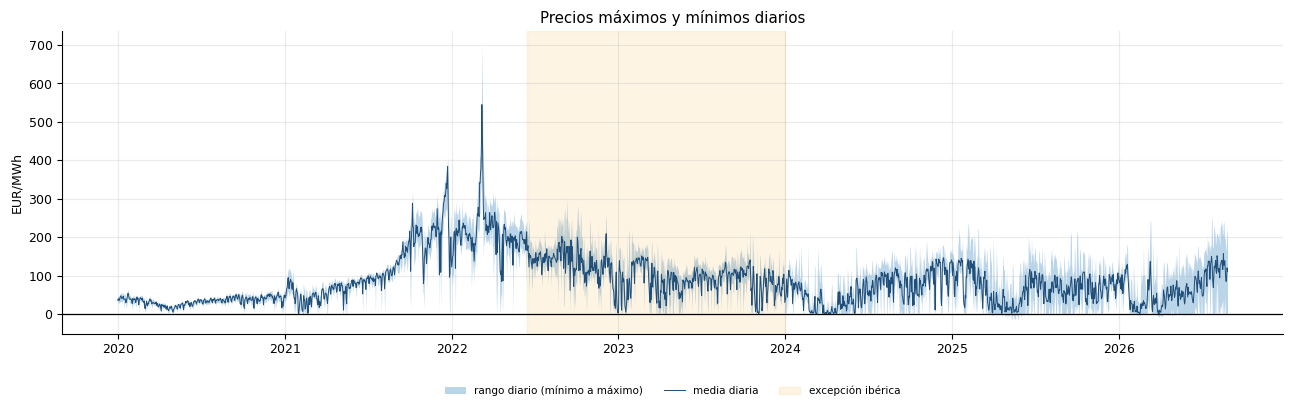

,mínimo_del_año,máximo_del_año,banda_media,banda_p90,días_con_mínimo_negativo
dia,,,,,
2020,1.0,68.9,16.9,26.0,0
2021,0.0,409.0,49.6,91.0,0
2022,0.0,700.0,94.4,148.7,0
2023,0.0,220.0,73.3,119.5,0
2024,-2.0,193.0,71.3,117.1,46
2025,-15.0,240.0,98.4,142.6,89
2026,-9.8,255.2,114.0,190.7,108


«banda_media» es el techo teórico del arbitraje por día y por MWh de batería, y
«banda_p90» el de los días buenos, que son los que concentran el ingreso.
«días_con_mínimo_negativo» cuenta aquellos en que llegó a pagarse por consumir.

La banda media pasa de 16.9 a 114.0 EUR/MWh (+97.1).
El valor del almacenamiento crece con la penetración renovable, que es el mismo
fenómeno que el apartado 6.4 documenta desde el lado de la capacidad instalada.


In [50]:
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.fill_between(sp.index, sp["min"], sp["max"], alpha=0.32, lw=0, color=PALETA["secundario"],
                label="rango diario (mínimo a máximo)")
ax.plot(sp.index, sp["mean"], lw=0.7, color=PALETA["principal"], label="media diaria")
ax.axhline(0, color="black", lw=0.9)
ax.axvspan(EXCEPCION[0].tz_localize(None), EXCEPCION[1].tz_localize(None),
           alpha=0.12, color=PALETA["acento"], label="excepción ibérica")
ax.set_ylabel("EUR/MWh"); ax.set_xlabel("")
ax.set_title("Precios máximos y mínimos diarios")
ax.legend(frameon=False, ncol=3, fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, -0.14))
plt.tight_layout(); plt.show()

anual_banda = sp.groupby(sp.index.year).agg(
    mínimo_del_año=("min", "min"), máximo_del_año=("max", "max"),
    banda_media=("diferencial", "mean"),
    banda_p90=("diferencial", lambda s_: s_.quantile(0.9)),
    días_con_mínimo_negativo=("min", lambda s_: (s_ < 0).sum())).round(1)
display(anual_banda)

print("«banda_media» es el techo teórico del arbitraje por día y por MWh de batería, y")
print("«banda_p90» el de los días buenos, que son los que concentran el ingreso.")
print("«días_con_mínimo_negativo» cuenta aquellos en que llegó a pagarse por consumir.\n")

crec = anual_banda["banda_media"].iloc[-1] - anual_banda["banda_media"].iloc[0]
print(f"La banda media pasa de {anual_banda['banda_media'].iloc[0]:.1f} a "
      f"{anual_banda['banda_media'].iloc[-1]:.1f} EUR/MWh ({crec:+.1f}).")
print("El valor del almacenamiento crece con la penetración renovable, que es el mismo")
print("fenómeno que el apartado 6.4 documenta desde el lado de la capacidad instalada.")

---
# 4 · ¿Qué explica el precio, y qué de eso puede usarse?

Aquí es donde es más fácil engañarse. Cualquier magnitud de generación real correlaciona
espectacularmente con el precio **porque ambas son consecuencia de la misma casación**. La
correlación no es el resultado: el resultado es la correlación acompañada de si esa variable
existía a las 12:00 de D.

Este bloque **mide la asociación**; no selecciona. La preselección de variables se hace en el
cuaderno de ingeniería, apartado 7, sobre `train` y sólo entre las columnas admisibles.

## 4.0 · Una comprobación previa: sobre cuántas filas se calcula cada correlación

Antes de interpretar ningún coeficiente hay que verificar sobre qué observaciones se ha
calculado. En este conjunto conviven **tres frecuencias de publicación** —horaria, trihoraria y
diaria— y al unirlas en una única rejilla horaria cada familia aterriza en horas distintas:

- las tablas horarias ocupan las veinticuatro horas;
- el reanálisis meteorológico ocupa las horas UTC múltiplo de tres;
- las tablas diarias ocupan únicamente la hora 00 local, que en UTC es la 22 o la 23.

Como 22 y 23 no son múltiplos de tres, **una variable meteorológica y una diaria no comparten
ni una sola hora**. Su correlación no es baja: no existe. Y el caso menos visible es peor: una
variable horaria correlacionada con una diaria se calcula sobre una de cada veinticuatro filas,
y siempre la misma hora del día, de modo que el coeficiente no describe la relación sino **la
relación en la madrugada**.

Es un artefacto de la unión, no del fenómeno, y de no comprobarse contaminaría todo el bloque.

In [51]:
FAMILIAS_PRUEBA = {
    "horaria (precio)":        P,
    "horaria (demanda)":       DEM,
    "trihoraria (ERA5)":       T2M,
    "diaria (commodities)":    GAS,
    "diaria (capacidad)":      cm.pick(df, "cap_disp_ccgt_mw"),
}
FAMILIAS_PRUEBA = {k: v for k, v in FAMILIAS_PRUEBA.items() if v}

nombres = list(FAMILIAS_PRUEBA)
SOLAPE = pd.DataFrame(index=nombres, columns=nombres, dtype=float)
for a in nombres:
    for b in nombres:
        SOLAPE.loc[a, b] = (df[FAMILIAS_PRUEBA[a]].notna() & df[FAMILIAS_PRUEBA[b]].notna()).sum()

print("Horas en que ambas familias tienen dato simultáneo:")
display(SOLAPE.astype(int))

nulos_par = (SOLAPE == 0).sum().sum()
print(f"\nPares sin ninguna hora en común: {int(nulos_par)}")
print("\nHoras locales en que aterriza cada familia:")
for k, v in FAMILIAS_PRUEBA.items():
    hs = sorted(df.loc[df[v].notna(), "hora"].unique())
    resumen_h = f"{len(hs)} horas distintas" if len(hs) > 6 else str(hs)
    print(f"  {k:24s} {resumen_h}")

REG.anotar("M.1", "Las correlaciones entre granularidades distintas son un artefacto de la unión",
           "confirmado",
           "Una horaria contra una diaria se calcula sobre 1 de cada 24 filas, siempre la misma "
           "hora. Toda asociación que cruce frecuencias se mide sobre un marco DIARIO agregado, "
           "nunca sobre la rejilla horaria.")

Horas en que ambas familias tienen dato simultáneo:


,horaria (precio),horaria (demanda),trihoraria (ERA5),diaria (commodities),diaria (capacidad)
horaria (precio),58313,58278,19273,2430,58307
horaria (demanda),58278,58284,19267,2429,58278
trihoraria (ERA5),19273,19267,19279,0,19279
diaria (commodities),2430,2429,0,2430,2430
diaria (capacidad),58307,58278,19279,2430,58313



Pares sin ninguna hora en común: 2

Horas locales en que aterriza cada familia:
  horaria (precio)         24 horas distintas
  horaria (demanda)        24 horas distintas
  trihoraria (ERA5)        16 horas distintas
  diaria (commodities)     [np.int32(0)]
  diaria (capacidad)       24 horas distintas
  [M.1] confirmado: Las correlaciones entre granularidades distintas son un artefacto de la unión


## 4.1 · El marco diario, que es donde la comparación es legítima

La corrección consiste en agregar a frecuencia diaria antes de correlacionar. Cada variable se
agrega con el estadístico que le corresponde —media para las que describen un nivel, suma para
las que describen energía— y el resultado es una tabla en la que todas las familias comparten
exactamente las mismas filas.

In [52]:
AGREGADOS = {c: "mean" for c in df.select_dtypes(include=[np.number]).columns
             if c not in ("hora", "anio", "mes", "dow", "hour_utc", "hour_local", "tensor_index")}
DIA = df.groupby("dia").agg(AGREGADOS)
DIA.index = pd.to_datetime(DIA.index)
DIA["dow"] = DIA.index.dayofweek
DIA["mes"] = DIA.index.month
DIA["anio"] = DIA.index.year

cobertura = DIA[[v for v in FAMILIAS_PRUEBA.values()]].notna().all(axis=1).sum()
print(f"Marco diario: {len(DIA):,} días")
print(f"Días con dato en las {len(FAMILIAS_PRUEBA)} familias a la vez: {cobertura:,} "
      f"({cobertura / len(DIA) * 100:.1f} %)")
print("\nFrente a las 0 horas de solape que mostraba la rejilla horaria para varios pares.")

Marco diario: 2,430 días
Días con dato en las 5 familias a la vez: 2,409 (99.1 %)

Frente a las 0 horas de solape que mostraba la rejilla horaria para varios pares.


In [53]:
DRIVERS_DIA = {k: v for k, v in DRIVERS.items() if v[0] in DIA.columns}
filas = []
for k, (c, f) in DRIVERS_DIA.items():
    r_dia = corr_segura(DIA[P], DIA[c])
    r_hora = corr_segura(df[P], df[c])
    n_hora = int((df[P].notna() & df[c].notna()).sum())
    n_dia = int((DIA[P].notna() & DIA[c].notna()).sum())
    filas.append({"driver": k, "disponibilidad": f,
                  "r horario": r_hora, "n horario": n_hora,
                  "r diario": r_dia, "n diario": n_dia})
CMP = pd.DataFrame(filas).set_index("driver")
CMP["|cambio|"] = (CMP["r diario"] - CMP["r horario"]).abs()
display(CMP.sort_values("|cambio|", ascending=False).round(4))

afectados = CMP[CMP["n horario"] < len(df) * 0.10]
if len(afectados):
    print(f"\n{len(afectados)} drivers se calculaban sobre menos del 10 % de las horas:")
    for k in afectados.index:
        print(f"  {k:20s} {afectados.loc[k, 'n horario']:>7,} horas → "
              f"{afectados.loc[k, 'n diario']:>6,} días")
    print("\nPara ellos, el coeficiente horario no es una versión ruidosa del diario: es otra")
    print("cosa. El marco diario es el único en que la comparación entre familias es legítima.")

,disponibilidad,r horario,n horario,r diario,n diario,|cambio|
driver,,,,,,
hidráulica,CON FUGA,0.0287,58277,-0.3062,2429,0.3350
solar FV real,CON FUGA,-0.2629,58277,-0.0717,2429,0.1912
solar prevista,SIN FUGA,-0.2796,58313,-0.1098,2430,0.1698
eólica real,CON FUGA,-0.1287,58277,-0.1777,2429,0.0490
temperatura,CON FUGA,-0.0415,19273,-0.0022,2410,0.0394
ciclo combinado,CON FUGA,0.5612,58313,0.5285,2430,0.0327
demanda prevista,SIN FUGA,0.2025,58312,0.2343,2430,0.0318
demanda real,CON FUGA,0.2022,58278,0.2340,2429,0.0317
eólica prevista,SIN FUGA,-0.1894,58313,-0.2163,2430,0.0269



1 drivers se calculaban sobre menos del 10 % de las horas:
  gas                    2,430 horas →  2,430 días

Para ellos, el coeficiente horario no es una versión ruidosa del diario: es otra
cosa. El marco diario es el único en que la comparación entre familias es legítima.


## 4.2 · Las variables más asociadas al precio, con su etiqueta de disponibilidad

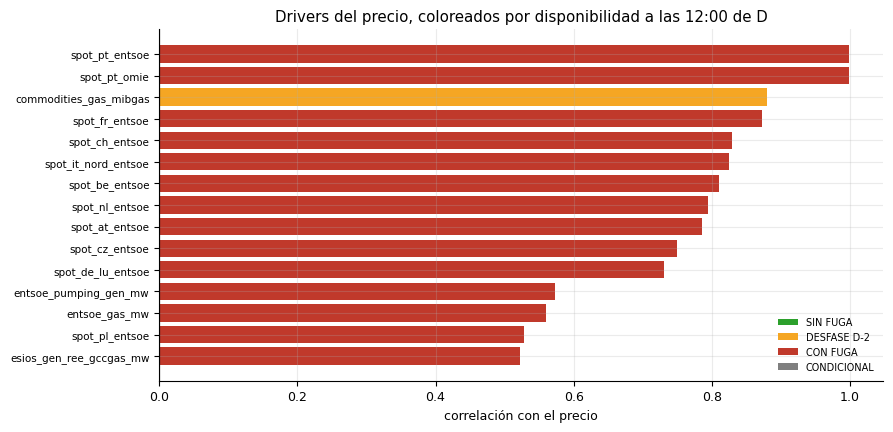

,correlación,disponibilidad
spot_pt_entsoe,0.9979,CON FUGA
spot_pt_omie,0.9979,CON FUGA
commodities_gas_mibgas,0.8803,DESFASE D-2
spot_fr_entsoe,0.8719,CON FUGA
spot_ch_entsoe,0.8297,CON FUGA
spot_it_nord_entsoe,0.8249,CON FUGA
spot_be_entsoe,0.8108,CON FUGA
spot_nl_entsoe,0.7945,CON FUGA
spot_at_entsoe,0.7862,CON FUGA
spot_cz_entsoe,0.7496,CON FUGA


Mejor correlación utilizable: 0.8803
Mejor correlación absoluta:    0.9979

La distancia entre ambas cifras cuantifica el coste que la restricción operativa
impone sobre la capacidad predictiva teórica del sistema.


In [54]:
num = [c for c in df.select_dtypes(include=[np.number]).columns
       if c not in ("hora", "anio", "mes", "dow", "hour_utc", "hour_local", "tensor_index")]
# Las otras fuentes españolas del precio son EL MISMO objetivo: incluirlas sería tautológico.
num = [c for c in num if c not in set(ES_FUENTES) - {P}]
# Y las columnas constantes no tienen correlación definida.
num = [c for c in num if NORMAL[c].std(skipna=True) > 0]

corr = NORMAL[num].corr()[P].drop(P, errors="ignore").dropna()
corr = corr.reindex(corr.abs().sort_values(ascending=False).index).head(15)
fugas = [fuga_de(c, P) for c in corr.index]

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(range(len(corr)), corr.values[::-1],
        color=[COLOR_FUGA.get(f, PALETA["neutro"]) for f in fugas[::-1]])
ax.set_yticks(range(len(corr)), [c[:36] for c in corr.index[::-1]], fontsize=7.5)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("correlación con el precio")
ax.set_title("Drivers del precio, coloreados por disponibilidad a las 12:00 de D")
ax.legend(handles=[Patch(facecolor=v, label=k) for k, v in COLOR_FUGA.items() if k != "TARGET"],
          frameon=False, fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

R = pd.DataFrame({"correlación": corr.round(4), "disponibilidad": fugas})
display(R)

usables = R[R["disponibilidad"].isin(cm.ADMISIBLES)]
if len(usables):
    print(f"Mejor correlación utilizable: {usables['correlación'].abs().max():.4f}")
print(f"Mejor correlación absoluta:    {R['correlación'].abs().max():.4f}")
print("\nLa distancia entre ambas cifras cuantifica el coste que la restricción operativa")
print("impone sobre la capacidad predictiva teórica del sistema.")

### Y ahora, sólo lo que puede usarse

El gráfico anterior está dominado por variables inutilizables. La misma figura restringida a las
que sí están disponibles a las 12:00 de D, **y dibujada en la misma escala**, es la que describe
el problema real al que se enfrenta el modelo.

La comparación entre ambas es el resultado: mide en una sola imagen cuánta capacidad predictiva
teórica se pierde por la restricción operativa.

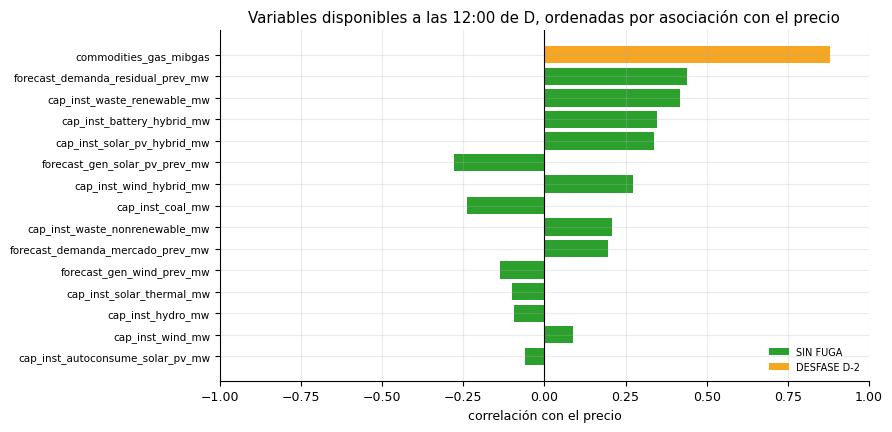

,correlación,disponibilidad
commodities_gas_mibgas,0.8803,DESFASE D-2
forecast_demanda_residual_prev_mw,0.4393,SIN FUGA
cap_inst_waste_renewable_mw,0.4170,SIN FUGA
cap_inst_battery_hybrid_mw,0.3478,SIN FUGA
cap_inst_solar_pv_hybrid_mw,0.3388,SIN FUGA
forecast_gen_solar_pv_prev_mw,-0.2776,SIN FUGA
cap_inst_wind_hybrid_mw,0.2720,SIN FUGA
cap_inst_coal_mw,-0.2378,SIN FUGA
cap_inst_waste_nonrenewable_mw,0.2084,SIN FUGA
forecast_demanda_mercado_prev_mw,0.1970,SIN FUGA


18 de 80 variables numéricas están disponibles al predecir (22 %).
De las quince con mayor asociación en el conjunto completo, 1 son utilizables.

De las quince utilizables mejor asociadas, por naturaleza:


,commodities (cierre diario),capacidad instalada (diaria),previsiones de REE (horarias)
nº de variables,1,10,4


  [M.6] confirmado: La restricción operativa descarta la mayor parte de la asociación medible


In [55]:
corr_todas = NORMAL[num].corr()[P].drop(P, errors="ignore").dropna()
fuga_todas = pd.Series({c: fuga_de(c, P) for c in corr_todas.index})

sin_fuga = corr_todas[fuga_todas.isin(cm.ADMISIBLES)]
sin_fuga = sin_fuga.reindex(sin_fuga.abs().sort_values(ascending=False).index).head(15)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(range(len(sin_fuga)), sin_fuga.values[::-1],
        color=[COLOR_FUGA[fuga_todas[c]] for c in sin_fuga.index[::-1]])
ax.set_yticks(range(len(sin_fuga)), [c[:40] for c in sin_fuga.index[::-1]], fontsize=7.5)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlim(-1, 1)          # misma escala que la figura anterior, para poder compararlas
ax.set_xlabel("correlación con el precio")
ax.set_title("Variables disponibles a las 12:00 de D, ordenadas por asociación con el precio")
ax.legend(handles=[Patch(facecolor=COLOR_FUGA[k], label=k) for k in cm.ADMISIBLES],
          frameon=False, fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

display(pd.DataFrame({"correlación": sin_fuga.round(4),
                      "disponibilidad": [fuga_todas[c] for c in sin_fuga.index]}))

n_util = int(fuga_todas.isin(cm.ADMISIBLES).sum())
top15 = corr_todas.reindex(corr_todas.abs().sort_values(ascending=False).index).head(15).index
util_en_top = sum(1 for c in top15 if fuga_todas[c] in cm.ADMISIBLES)
print(f"{n_util} de {len(fuga_todas)} variables numéricas están disponibles al predecir "
      f"({n_util / len(fuga_todas) * 100:.0f} %).")
print(f"De las quince con mayor asociación en el conjunto completo, {util_en_top} son utilizables.")

# Composicion del conjunto utilizable: no todas sus variables son de la misma naturaleza.
familias_util = pd.Series({
    "commodities (cierre diario)": sum(c.startswith("commodities_") for c in sin_fuga.index),
    "capacidad instalada (diaria)": sum(c.startswith("cap_inst_") for c in sin_fuga.index),
    "previsiones de REE (horarias)": sum(c.startswith("forecast_") for c in sin_fuga.index),
})
print("\nDe las quince utilizables mejor asociadas, por naturaleza:")
display(familias_util[familias_util > 0].rename("nº de variables").to_frame().T)

REG.anotar("M.6", "La restricción operativa descarta la mayor parte de la asociación medible",
           "confirmado",
           f"Sólo {n_util} de {len(fuga_todas)} variables están disponibles al predecir, y "
           f"{util_en_top} de las quince más asociadas. La diferencia entre la mejor "
           "correlación absoluta y la mejor utilizable es el coste de predecir a las 12:00.")

**Tres advertencias sobre este segundo gráfico, que es más frágil de lo que aparenta.**

*La capacidad instalada correlaciona por tendencia, no por relación.* Buena parte de las
variables que sobreviven al filtro son `cap_inst_*`: series que crecen de forma monótona a lo
largo del período, igual que lo hace el precio en su primera mitad. Dos series con tendencia
compartida correlacionan sin que exista relación alguna entre ellas. El apartado 4.4 somete
precisamente esa sospecha a contraste, comprobando si la asociación se sostiene **dentro de cada
año**, que es donde la tendencia deja de operar.

*Las commodities encabezan la lista, pero son diarias.* Su correlación se mide sobre una sola
hora de cada veinticuatro, por el motivo establecido en el apartado 4.0. La cifra que vale para
ellas es la del marco diario, no ésta.

*La demanda residual prevista aparece la primera entre las previsiones horarias*, y conviene
recordar la salvedad del apartado 1.6.1: se descartó que arrastre el autoconsumo, pero sigue
excluida del conjunto maestro por revisarse días después de publicada. Su cifra es, por tanto,
una cota superior.

En conjunto: aplicada la frontera, lo que queda no es un conjunto de variables cómodo. Es
justamente esa incomodidad la que el bloque 5 cuantifica en términos de error heredado.

## 4.3 · La relación depende de la hora del día

El modelo predice las veinticuatro horas de D+1 por separado, de modo que un coeficiente único
promedia relaciones que pueden diferir mucho entre unas horas y otras.

**Dos restricciones sobre qué variables entran en esta figura.** La primera es de utilidad: se
representan sólo las **disponibles al predecir**, porque el perfil horario de una variable con
fuga no puede aprovecharse. La segunda es consecuencia directa del apartado 4.0: se exigen
además **variables con cobertura horaria completa**. Una serie trihoraria como el reanálisis
meteorológico deja huecos alternos al agruparse por hora local, de modo que su correlación se
calcularía sobre subconjuntos minúsculos y la línea resultante sería ruido con apariencia de
señal.

Utilizables con cobertura horaria completa: 4
Excluidas por no tener las 24 horas: 18
  cap_inst_hydro_mw, cap_inst_pump_mw, cap_inst_wind_mw, cap_inst_wind_hybrid_mw, cap_inst_solar_pv_mw, cap_inst_solar_thermal_mw ...
  (son diarias o trihorarias: su perfil horario no está definido)


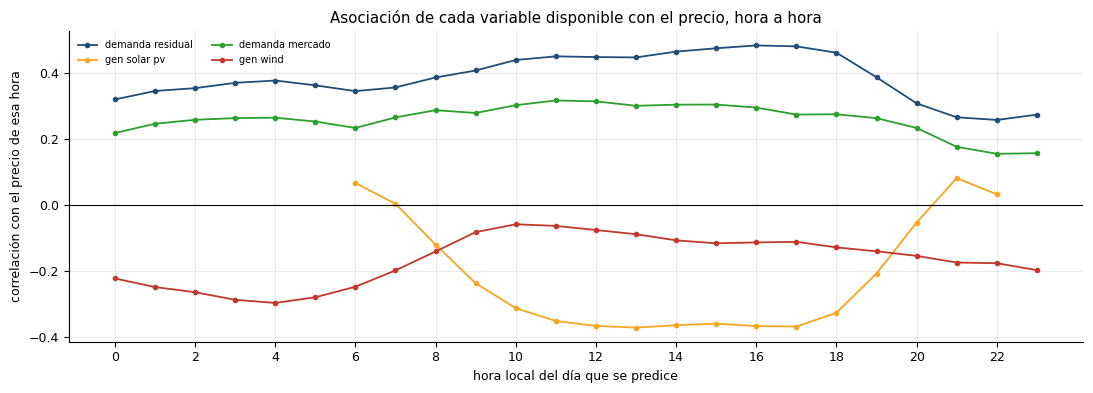

In [56]:
# Cobertura horaria real: una serie diaria o trihoraria no aterriza en las 24 horas locales,
# y agrupar por hora produciría correlaciones sobre subconjuntos diminutos (apartado 4.0).
def cobertura_horaria(col, minimo=20):
    return df.loc[df[col].notna(), "hora"].nunique() >= minimo

candidatas_h = [c for c in num
                if fuga_de(c, P) in cm.ADMISIBLES and cobertura_horaria(c)]
candidatas_h = corr_todas[candidatas_h].abs().nlargest(8).index.tolist()

excluidas = [c for c in num
             if fuga_de(c, P) in cm.ADMISIBLES and not cobertura_horaria(c)]
print(f"Utilizables con cobertura horaria completa: {len([c for c in num if fuga_de(c, P) in cm.ADMISIBLES and cobertura_horaria(c)])}")
print(f"Excluidas por no tener las 24 horas: {len(excluidas)}")
if excluidas:
    print(f"  {', '.join(excluidas[:6])}{' ...' if len(excluidas) > 6 else ''}")
    print("  (son diarias o trihorarias: su perfil horario no está definido)")

por_hora = pd.DataFrame({
    c: NORMAL.groupby("hora").apply(lambda g: corr_segura(g[P], g[c]), include_groups=False)
    for c in candidatas_h})

fig, ax = plt.subplots(figsize=(11, 4))
for c in por_hora.columns:
    ax.plot(por_hora.index, por_hora[c], marker="o", ms=3, lw=1.3,
            label=c.replace("forecast_", "").replace("_prev_mw", "").replace("_", " "))
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hora local del día que se predice")
ax.set_ylabel("correlación con el precio de esa hora")
ax.set_title("Asociación de cada variable disponible con el precio, hora a hora")
ax.legend(frameon=False, fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

In [57]:
resumen_h = pd.DataFrame({
    "r global": corr_todas[candidatas_h].round(4),
    "r mínima": por_hora.min().round(4),
    "r máxima": por_hora.max().round(4),
    "amplitud": (por_hora.max() - por_hora.min()).round(4),
    "hora del máximo |r|": por_hora.abs().idxmax(),
}).sort_values("amplitud", ascending=False)
display(resumen_h)

print("Una amplitud grande indica que el coeficiente global no describe ninguna hora concreta:")
print("esa variable requiere interacción con la hora del día, o un modelo por hora.\n")

anchos = resumen_h[resumen_h["amplitud"] > 0.3].index.tolist()
REG.anotar("P.3", "La asociación con el precio depende de la hora del día", "confirmado",
           f"Amplitud superior a 0,3 en {len(anchos)} de las {len(resumen_h)} variables "
           f"utilizables analizadas ({', '.join(c[:22] for c in anchos[:3])}). Incorporar "
           "interacciones con la hora del día, o modelos por hora.")

,r global,r mínima,r máxima,amplitud,hora del máximo |r|
forecast_gen_solar_pv_prev_mw,-0.2776,-0.3728,0.0805,0.4532,13
forecast_gen_wind_prev_mw,-0.1375,-0.2979,-0.0595,0.2385,4
forecast_demanda_residual_prev_mw,0.4393,0.2570,0.4828,0.2259,16
forecast_demanda_mercado_prev_mw,0.1970,0.1543,0.3160,0.1617,11


Una amplitud grande indica que el coeficiente global no describe ninguna hora concreta:
esa variable requiere interacción con la hora del día, o un modelo por hora.

  [P.3] confirmado: La asociación con el precio depende de la hora del día


## 4.4 · ¿Se sostiene la relación año a año?

Sobre seis años con tendencias fuertes, dos series que crecen juntas correlacionan aunque no
tengan relación causal. Si la asociación global es alta pero las anuales son bajas, era tendencia
compartida — y una feature elegida por ella no generalizaría.

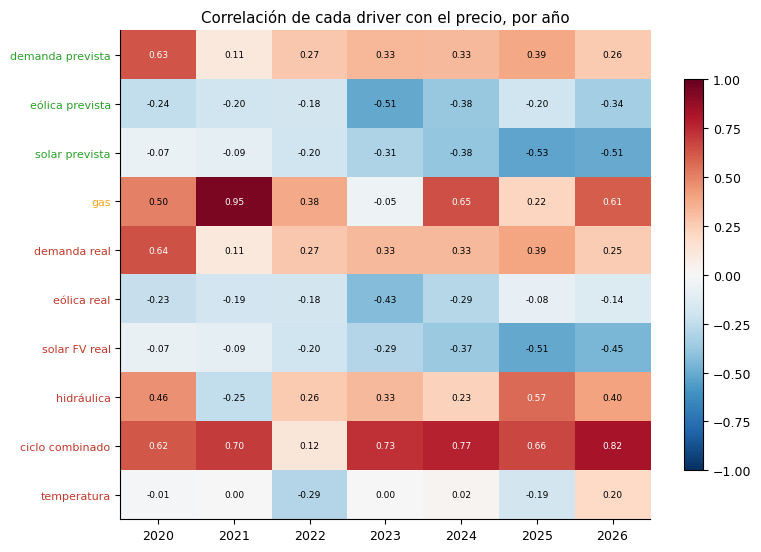

Drivers cuya correlación con el precio más varía entre años:


,gas,hidráulica,ciclo combinado
desviación típica entre años,0.321,0.262,0.237


In [58]:
E = pd.DataFrame([df.groupby("anio").apply(lambda g: corr_segura(g[P], g[v[0]]),
                                           include_groups=False).rename(k)
                  for k, v in DRIVERS.items()])
fig, ax = plt.subplots(figsize=(8, 0.42 * len(E) + 1.4))
im = ax.imshow(E.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(E.shape[1]), E.columns)
ax.set_yticks(range(len(E)), E.index, fontsize=8)
for et, k in zip(ax.get_yticklabels(), E.index):
    et.set_color(COLOR_FUGA.get(DRIVERS[k][1], "black"))
for i in range(E.shape[0]):
    for j in range(E.shape[1]):
        if pd.notna(E.iloc[i, j]):
            ax.text(j, i, f"{E.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(E.iloc[i, j]) > 0.55 else "black")
ax.set_title("Correlación de cada driver con el precio, por año"); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

inestables = E.std(axis=1).sort_values(ascending=False).head(3)
print("Drivers cuya correlación con el precio más varía entre años:")
display(inestables.round(3).rename("desviación típica entre años").to_frame().T)

### La estabilidad vista de forma continua: correlación móvil

El control por año responde con seis cifras. Una ventana móvil de un año, desplazada día a día,
muestra la misma información de forma continua y permite distinguir una relación que se degrada
progresivamente de otra que se rompe en una fecha concreta —lo cual apuntaría a un cambio
regulatorio o de perímetro, no a una deriva del sistema.

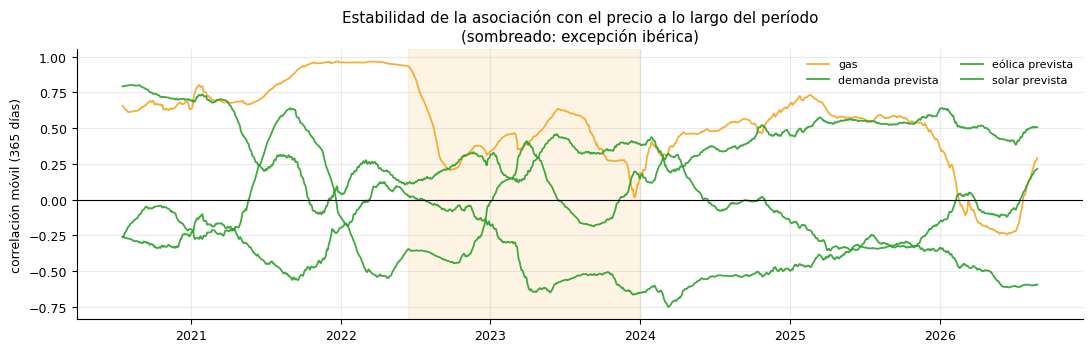

,mínimo,máximo,amplitud
driver,,,
gas,-0.244,0.967,1.211
solar prevista,-0.549,0.639,1.188
demanda prevista,-0.104,0.801,0.906
eólica prevista,-0.751,0.123,0.874


Una amplitud grande indica que la asociación global promedia situaciones distintas y
que el coeficiente único no describe ninguna de ellas.


In [59]:
VENTANA = 365
COMPARADOS = [k for k in ["gas", "demanda prevista", "eólica prevista", "solar prevista"]
              if k in DRIVERS_DIA][:4]

fig, ax = plt.subplots(figsize=(11, 3.6))
for k in COMPARADOS:
    c = DRIVERS_DIA[k][0]
    movil = DIA[P].rolling(VENTANA, min_periods=200).corr(DIA[c])
    ax.plot(movil.index, movil.values, lw=1.3,
            color=COLOR_FUGA.get(DRIVERS_DIA[k][1], PALETA["neutro"]), label=k, alpha=0.9)
ax.axhline(0, color="black", lw=0.8)
ax.axvspan(EXCEPCION[0].tz_localize(None), EXCEPCION[1].tz_localize(None),
           alpha=0.12, color=PALETA["acento"])
ax.set_ylabel(f"correlación móvil ({VENTANA} días)"); ax.set_xlabel("")
ax.set_title("Estabilidad de la asociación con el precio a lo largo del período\n"
             "(sombreado: excepción ibérica)")
ax.legend(frameon=False, ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

filas = []
for k in COMPARADOS:
    m = DIA[P].rolling(VENTANA, min_periods=200).corr(DIA[DRIVERS_DIA[k][0]]).dropna()
    filas.append({"driver": k, "mínimo": m.min(), "máximo": m.max(),
                  "amplitud": m.max() - m.min()})
display(pd.DataFrame(filas).set_index("driver").round(3).sort_values("amplitud",
                                                                    ascending=False))
print("Una amplitud grande indica que la asociación global promedia situaciones distintas y")
print("que el coeficiente único no describe ninguna de ellas.")

## 4.5 · Asociación no lineal: cuando la correlación engaña

El coeficiente de Pearson sólo detecta relaciones lineales. El V de Cramér, que discretiza ambas
variables y mide la asociación mediante una tabla de contingencia, **no supone ninguna forma**.
Es el estadístico que el máster emplea para el cribado de variables (`Vcramer`, `graficoVcramer`).

Una variable con Cramér alto y Pearson bajo mantiene una relación que un modelo lineal
desaprovecharía: es el diagnóstico que motiva buscarle una transformación en el cuaderno
siguiente.

,disponibilidad,Cramér,|Pearson|,ratio
driver,,,,
hidráulica,CON FUGA,0.0979,0.0287,3.40
temperatura,CON FUGA,0.0972,0.0415,2.34
solar prevista,SIN FUGA,0.2254,0.2796,0.81
eólica real,CON FUGA,0.0951,0.1287,0.74
eólica prevista,SIN FUGA,0.1286,0.1894,0.68
solar FV real,CON FUGA,0.1727,0.2629,0.66
gas,DESFASE D-2,0.5004,0.7588,0.66
demanda prevista,SIN FUGA,0.1236,0.2025,0.61
demanda real,CON FUGA,0.1234,0.2022,0.61


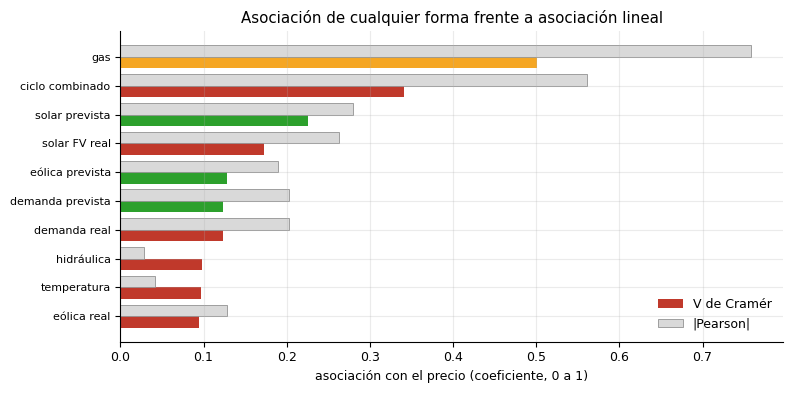

  [P.4] confirmado: Varios drivers presentan asociación marcadamente no lineal


In [60]:
V = pd.DataFrame([{"driver": k, "disponibilidad": f,
                   "Cramér": v_cramer(df[c], df[P]), "|Pearson|": abs(df[c].corr(df[P]))}
                  for k, (c, f) in DRIVERS.items()]).dropna().set_index("driver")
V["ratio"] = (V["Cramér"] / V["|Pearson|"]).round(2)
display(V.sort_values("ratio", ascending=False).round(4))

Vs = V.sort_values("Cramér")
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(Vs))
ax.barh(y - 0.2, Vs["Cramér"], height=0.4, label="V de Cramér",
        color=[COLOR_FUGA.get(f, PALETA["neutro"]) for f in Vs["disponibilidad"]])
ax.barh(y + 0.2, Vs["|Pearson|"], height=0.4, label="|Pearson|",
        color=PALETA["suave"], edgecolor="grey", lw=0.5)
ax.set_yticks(y, Vs.index, fontsize=8)
ax.set_xlabel("asociación con el precio (coeficiente, 0 a 1)"); ax.legend(frameon=False)
ax.set_title("Asociación de cualquier forma frente a asociación lineal")
plt.tight_layout(); plt.show()

no_lineales = V[V["ratio"] > 1.5].index.tolist()
if no_lineales:
    REG.anotar("P.4", "Varios drivers presentan asociación marcadamente no lineal", "confirmado",
               f"Cramér supera en más del 50 % a |Pearson| en: {', '.join(no_lineales)}. "
               "Buscarles transformación (mejorTransfCorr) o emplear modelos no lineales.")

## 4.6 · Correlación cruzada: dónde está el retardo que sí sirve

Una correlación contemporánea sólo pregunta si dos series se mueven a la vez. En un sistema con
inercia —embalses que se gestionan por semanas, gas contratado con antelación, temperatura que
arrastra la demanda con retraso— **la relación puede estar desplazada en el tiempo**.

El concepto no existe en la caja de herramientas de datos transversales, donde no hay orden entre
las filas, y aquí es directamente accionable por partida doble:

- el desfase que maximiza la asociación **es el retardo que hay que construir como variable**;
- y conecta con la frontera de disponibilidad, porque una variable con fuga cuyo desfase óptimo
  sea de uno o más días **es utilizable en su versión retardada**, mientras que otra cuyo óptimo
  sea cero sólo sirve contemporánea y, por tanto, no sirve.

*Convención de signo:* un desfase positivo significa que el valor pasado del driver explica el
precio de hoy, que es justamente el caso aprovechable.

,disponibilidad,r en desfase 0,mejor r,desfase óptimo (días),ganancia
hidráulica,CON FUGA,-0.3062,-0.4388,-5,0.1326
solar FV real,CON FUGA,-0.0717,-0.1168,-5,0.0451
solar prevista,SIN FUGA,-0.1098,-0.1362,-7,0.0264
temperatura,CON FUGA,-0.0022,0.0158,7,0.0137
eólica prevista,SIN FUGA,-0.2163,-0.2163,0,0.0000
demanda prevista,SIN FUGA,0.2343,0.2343,0,0.0000
eólica real,CON FUGA,-0.1777,-0.1777,0,0.0000
demanda real,CON FUGA,0.2340,0.2340,0,0.0000
gas,DESFASE D-2,0.7620,0.7620,0,0.0000
ciclo combinado,CON FUGA,0.5285,0.5285,0,0.0000


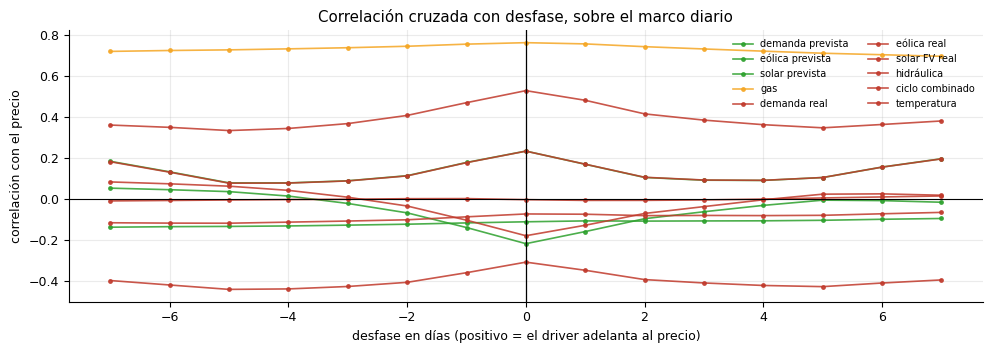

In [61]:
def corr_desfases(objetivo, driver, desfases):
    return pd.Series({k: corr_segura(objetivo, driver.shift(k)) for k in desfases})

DESFASES = range(-7, 8)
CAND_LAG = {k: v[0] for k, v in DRIVERS_DIA.items()}
X = pd.DataFrame({k: corr_desfases(DIA[P], DIA[c], DESFASES) for k, c in CAND_LAG.items()})

LAG = pd.DataFrame({
    "disponibilidad": {k: DRIVERS_DIA[k][1] for k in X.columns},
    "r en desfase 0": X.loc[0],
    "mejor r": X.apply(lambda s_: s_.loc[s_.abs().idxmax()] if s_.notna().any() else np.nan),
    "desfase óptimo (días)": X.apply(lambda s_: s_.abs().idxmax() if s_.notna().any() else np.nan),
})
LAG["ganancia"] = LAG["mejor r"].abs() - LAG["r en desfase 0"].abs()
display(LAG.sort_values("ganancia", ascending=False).round(4))

fig, ax = plt.subplots(figsize=(10, 3.6))
for k in X.columns:
    ax.plot(X.index, X[k], lw=1.2, marker="o", ms=2.5,
            color=COLOR_FUGA.get(DRIVERS_DIA[k][1], PALETA["neutro"]), alpha=0.85, label=k)
ax.axvline(0, color="black", lw=0.9)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("desfase en días (positivo = el driver adelanta al precio)")
ax.set_ylabel("correlación con el precio")
ax.set_title("Correlación cruzada con desfase, sobre el marco diario")
ax.legend(frameon=False, fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### Cuánta asociación sobrevive al retardo que la operación impone

El desfase óptimo es una curiosidad estadística si no se cruza con la restricción real. La
pregunta que decide es más concreta: las magnitudes con fuga sólo pueden usarse con **dos días**
de retardo respecto al día objetivo, según se estableció en el apartado 0.1. Interesa por tanto
cuánta de su asociación sobrevive precisamente a ese desfase, y no al que resulte más favorable.

La tabla siguiente compara la asociación contemporánea —la que no puede usarse— con la que queda
al aplicar el retardo operativo, y expresa la segunda como fracción de la primera.

,disponibilidad,|r| contemporáneo,|r| con 2 días,retención %
driver,,,,
temperatura,CON FUGA,0.002,0.006,254.318
hidráulica,CON FUGA,0.306,0.391,127.738
solar FV real,CON FUGA,0.072,0.080,111.448
gas,DESFASE D-2,0.762,0.743,97.441
solar prevista,SIN FUGA,0.110,0.106,96.927
ciclo combinado,CON FUGA,0.529,0.415,78.596
demanda real,CON FUGA,0.234,0.107,45.675
demanda prevista,SIN FUGA,0.234,0.106,45.249
eólica prevista,SIN FUGA,0.216,0.095,43.794


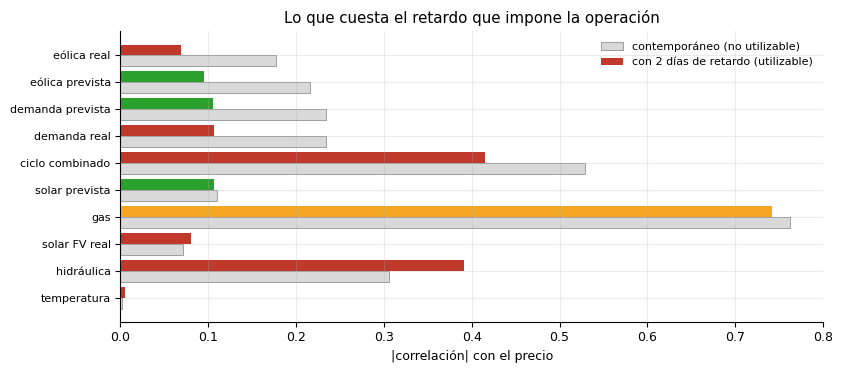

Conservan más del 80 % de su asociación al retardarlas: temperatura, hidráulica, solar FV real, gas, solar prevista
Pierden más de la mitad: demanda real, demanda prevista, eólica prevista, eólica real
  [M.5] confirmado: El retardo operativo no penaliza por igual a todos los drivers


In [62]:
DESFASE_OPERATIVO = 2       # días, respecto al día objetivo (véase el apartado 0.1)

filas = []
for k, c in CAND_LAG.items():
    r0 = corr_segura(DIA[P], DIA[c])
    r_op = corr_segura(DIA[P], DIA[c].shift(DESFASE_OPERATIVO))
    if pd.isna(r0) or pd.isna(r_op) or abs(r0) < 1e-6:
        continue
    filas.append({"driver": k, "disponibilidad": DRIVERS_DIA[k][1],
                  "|r| contemporáneo": abs(r0),
                  f"|r| con {DESFASE_OPERATIVO} días": abs(r_op),
                  "retención %": abs(r_op) / abs(r0) * 100})
RET = pd.DataFrame(filas).set_index("driver").sort_values("retención %", ascending=False)
display(RET.round(3))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
y = np.arange(len(RET))
ax.barh(y - 0.2, RET["|r| contemporáneo"], height=0.4, label="contemporáneo (no utilizable)",
        color=PALETA["suave"], edgecolor="grey", lw=0.5)
ax.barh(y + 0.2, RET[f"|r| con {DESFASE_OPERATIVO} días"], height=0.4,
        label=f"con {DESFASE_OPERATIVO} días de retardo (utilizable)",
        color=[COLOR_FUGA.get(f, PALETA["neutro"]) for f in RET["disponibilidad"]])
ax.set_yticks(y, RET.index, fontsize=8)
ax.set_xlabel("|correlación| con el precio"); ax.legend(frameon=False, fontsize=8)
ax.set_title("Lo que cuesta el retardo que impone la operación")
plt.tight_layout(); plt.show()

resisten = RET[RET["retención %"] > 80].index.tolist()
caen = RET[RET["retención %"] < 50].index.tolist()
print(f"Conservan más del 80 % de su asociación al retardarlas: "
      f"{', '.join(resisten) if resisten else 'ninguna'}")
print(f"Pierden más de la mitad: {', '.join(caen) if caen else 'ninguna'}")

REG.anotar("M.5", "El retardo operativo no penaliza por igual a todos los drivers", "confirmado",
           f"Con {DESFASE_OPERATIVO} días de desfase, unos conservan casi toda su asociación "
           "—son lentos: commodities, hidrología, temperatura— y otros la pierden, porque su "
           "información es intradiaria. La ingeniería de variables retarda los primeros y "
           "sustituye los segundos por su previsión.")

## 4.7 · Correlación parcial: cuánta de esa asociación era sólo el ciclo

Dos variables pueden correlacionar porque una influye en la otra o porque **ambas siguen un
tercer factor común**. En un sistema eléctrico ese factor está siempre presente: el ciclo diario
y el ciclo estacional gobiernan a la vez la demanda, la generación solar, la temperatura y el
precio.

La correlación parcial descuenta esos ciclos —correlacionando los residuos de regresar cada
variable sobre ellos— y deja la asociación que se sostiene por sí misma.

**Su consecuencia para la ingeniería de variables es directa:** un driver cuya asociación
desaparece al controlar por hora y mes no aporta nada a un modelo que ya incluye la hora y el
mes, y esas dos variables están siempre disponibles y no tienen fuga. Incorporarlo sería pagar
una columna por información que el calendario ya da gratis.

,disponibilidad,r simple,r parcial,% que era ciclo
driver,,,,
hidráulica,CON FUGA,0.0287,0.0187,34.8495
solar prevista,SIN FUGA,-0.2796,-0.2555,8.6374
solar FV real,CON FUGA,-0.2629,-0.2402,8.6167
ciclo combinado,CON FUGA,0.5612,0.5486,2.2508
gas,DESFASE D-2,0.7588,0.7496,1.2026
eólica prevista,SIN FUGA,-0.1894,-0.2403,-26.8835
demanda real,CON FUGA,0.2022,0.2854,-41.1268
demanda prevista,SIN FUGA,0.2025,0.2892,-42.8425
eólica real,CON FUGA,-0.1287,-0.1882,-46.2462


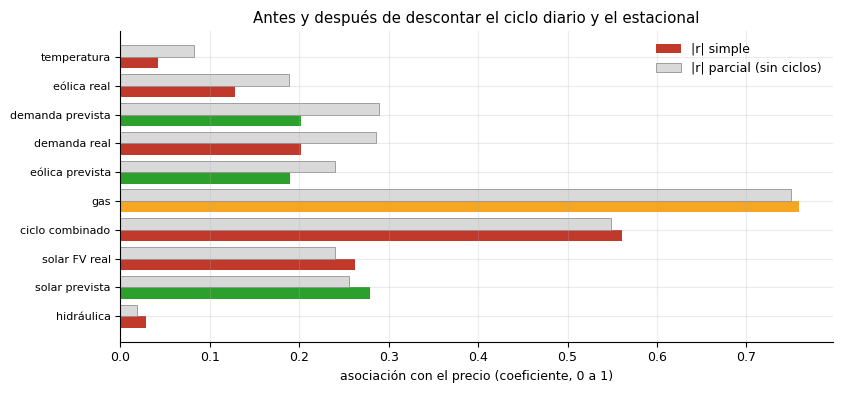

In [63]:
from numpy.linalg import lstsq

def residuos(y, X_ctrl):
    d = pd.concat([y, X_ctrl], axis=1).dropna()
    if len(d) < 100:
        return None
    yy = d.iloc[:, 0].to_numpy()
    XX = np.column_stack([np.ones(len(d)), d.iloc[:, 1:].to_numpy()])
    beta, *_ = lstsq(XX, yy, rcond=None)
    return pd.Series(yy - XX @ beta, index=d.index)

# Armónicos de hora y mes: capturan ambos ciclos sin imponerles una forma lineal.
CTRL = pd.DataFrame({
    "sin_h": np.sin(2 * np.pi * df["hora"] / 24), "cos_h": np.cos(2 * np.pi * df["hora"] / 24),
    "sin_m": np.sin(2 * np.pi * df["mes"] / 12),  "cos_m": np.cos(2 * np.pi * df["mes"] / 12),
}, index=df.index)

res_precio = residuos(df[P], CTRL)
filas = []
for k, (c, f) in DRIVERS.items():
    rb = residuos(df[c], CTRL)
    if rb is None or res_precio is None:
        continue
    comun = res_precio.index.intersection(rb.index)
    if len(comun) < 500:
        continue
    simple = corr_segura(df[P], df[c])
    parcial = corr_segura(res_precio.loc[comun], rb.loc[comun])
    filas.append({"driver": k, "disponibilidad": f, "r simple": simple, "r parcial": parcial,
                  "% que era ciclo": (1 - abs(parcial) / max(abs(simple), 1e-9)) * 100})
PARC = pd.DataFrame(filas).set_index("driver").sort_values("% que era ciclo", ascending=False)
display(PARC.round(4))

fig, ax = plt.subplots(figsize=(8.5, 4))
y = np.arange(len(PARC))
ax.barh(y - 0.2, PARC["r simple"].abs(), height=0.4, label="|r| simple",
        color=[COLOR_FUGA.get(f, PALETA["neutro"]) for f in PARC["disponibilidad"]])
ax.barh(y + 0.2, PARC["r parcial"].abs(), height=0.4, label="|r| parcial (sin ciclos)",
        color=PALETA["suave"], edgecolor="grey", lw=0.5)
ax.set_yticks(y, PARC.index, fontsize=8)
ax.set_xlabel("asociación con el precio (coeficiente, 0 a 1)"); ax.legend(frameon=False)
ax.set_title("Antes y después de descontar el ciclo diario y el estacional")
plt.tight_layout(); plt.show()

puro_ciclo = PARC[PARC["% que era ciclo"] > 60].index.tolist()
if puro_ciclo:
    REG.anotar("M.2", "Parte de la asociación de algunos drivers es sólo ciclo horario y anual",
               "confirmado",
               f"Más del 60 % de la asociación desaparece al controlar por hora y mes en: "
               f"{', '.join(puro_ciclo)}. El calendario ya aporta esa información sin coste y "
               "sin fuga.")

---
# 5 · ¿Cuánto error heredamos de las variables disponibles?

Las variables utilizables no son magnitudes observadas: son **previsiones**. Y una previsión trae
su propio error, que el modelo hereda entero. Ningún algoritmo recupera información que la
entrada no contiene, así que este bloque establece un **suelo al error alcanzable**.

## 5.1 · El error de las previsiones de REE, medido contra la realidad

In [64]:
PARES = [(k, DRIVERS[k][0], real) for k, real in
         [("demanda prevista", DEM), ("eólica prevista", EOL), ("solar prevista", FV)]
         if k in DRIVERS and real]

filas = []
for etq_, cp, cr in PARES:
    d = df[[cp, cr]].dropna()
    err = d[cp] - d[cr]
    filas.append({"variable": etq_, "n": len(d), "MAE (MW)": err.abs().mean(),
                  "sesgo (MW)": err.mean(),
                  "MAPE (%)": (err.abs() / d[cr].replace(0, np.nan)).mean() * 100,
                  "correlación": d[cp].corr(d[cr])})
if filas:
    ERR = pd.DataFrame(filas).set_index("variable")
    display(ERR.round(2))
    print("El sesgo y el error aleatorio tienen consecuencias opuestas: un desvío sistemático")
    print("se corrige antes de entrenar, el ruido no es recuperable.")
    print("\nEl MAPE de la solar no es lo que parece: divide entre valores diminutos al")
    print("amanecer y al anochecer. El MAE es la cifra honesta.")

    sesgadas = ERR[ERR["sesgo (MW)"].abs() > 50].index.tolist()
    if sesgadas:
        REG.anotar("P.5", "Las previsiones de generación tienen sesgo sistemático", "confirmado",
                   f"Sesgo superior a 50 MW en: {', '.join(sesgadas)}. Corregirlo antes de "
                   "entrenar; el componente aleatorio del error no es recuperable.")

,n,MAE (MW),sesgo (MW),MAPE (%),correlación
variable,,,,,
demanda prevista,58277,256.85,0.76,0.95,0.99
eólica prevista,58283,771.70,128.52,15.84,0.95
solar prevista,58283,547.36,197.82,65.21,0.98


El sesgo y el error aleatorio tienen consecuencias opuestas: un desvío sistemático
se corrige antes de entrenar, el ruido no es recuperable.

El MAPE de la solar no es lo que parece: divide entre valores diminutos al
amanecer y al anochecer. El MAE es la cifra honesta.
  [P.5] confirmado: Las previsiones de generación tienen sesgo sistemático


### Dónde falla cada previsión

El error medio es una cifra de resumen; lo que interesa para el modelado es **cuándo** se comete.
Cada variable se representa en su propia fila y con su propia escala, porque sus magnitudes se
diferencian en un orden completo —la demanda yerra en centenares de megavatios y la solar en
millares— y compartir eje aplastaría la primera hasta hacerla ilegible.

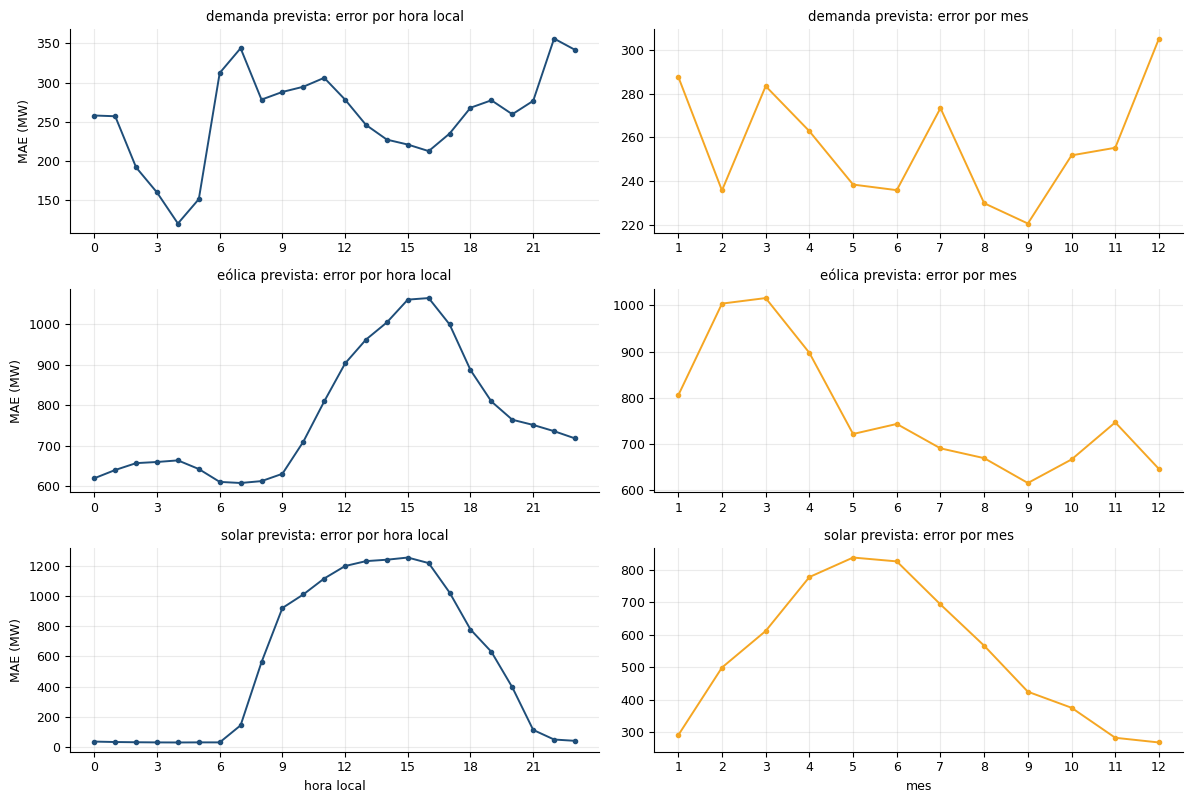

La demanda falla en las horas de rampa —amanecer y anochecer— y en invierno.
La eólica, en las horas centrales y en los meses ventosos de invierno y primavera.
La solar, de forma casi trivial, cuando y donde hay sol: su error es cero de noche.


In [65]:
fig, axes = plt.subplots(len(PARES), 2, figsize=(12, 2.7 * len(PARES)))
axes = np.atleast_2d(axes)
PERFIL_ERR = {}
for i, (etq_, cp, cr) in enumerate(PARES):
    d = df[["hora", "mes", cp, cr]].dropna().copy()
    d["err"] = (d[cp] - d[cr]).abs()
    ph_ = d.groupby("hora")["err"].mean()
    pm_ = d.groupby("mes")["err"].mean()
    PERFIL_ERR[etq_] = ph_

    axes[i, 0].plot(ph_.index, ph_.values, marker="o", ms=3, lw=1.4, color=PALETA["principal"])
    axes[i, 0].set_ylabel("MAE (MW)"); axes[i, 0].set_xticks(range(0, 24, 3))
    axes[i, 0].set_title(f"{etq_}: error por hora local", fontsize=9.5)

    axes[i, 1].plot(pm_.index, pm_.values, marker="o", ms=3, lw=1.4, color=PALETA["acento"])
    axes[i, 1].set_xticks(range(1, 13))
    axes[i, 1].set_title(f"{etq_}: error por mes", fontsize=9.5)
axes[-1, 0].set_xlabel("hora local"); axes[-1, 1].set_xlabel("mes")
plt.tight_layout(); plt.show()

print("La demanda falla en las horas de rampa —amanecer y anochecer— y en invierno.")
print("La eólica, en las horas centrales y en los meses ventosos de invierno y primavera.")
print("La solar, de forma casi trivial, cuando y donde hay sol: su error es cero de noche.")

### La afirmación que conviene contrastar en lugar de enunciar

Es habitual afirmar que el error de la entrada se concentra donde el objetivo es más difícil, de
modo que el modelo fallará justo donde más importa. Suena razonable, pero es una hipótesis y
puede comprobarse.

Se toma como medida de dificultad del objetivo la **dispersión del precio dentro de cada hora**:
las horas en que el precio varía más entre unos días y otros son aquellas en que acertar resulta
más costoso. Si la hipótesis es cierta, el perfil horario del error de previsión debe seguir al
de esa dispersión.

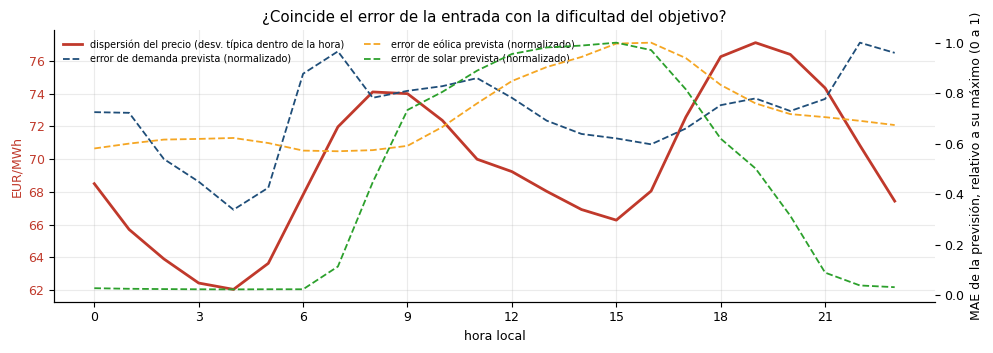

,demanda prevista,eólica prevista,solar prevista
r entre el perfil de error y la dificultad,0.5997,0.0882,0.2627


La hipótesis NO se cumple por igual, y esa diferencia es el resultado:

  demanda prevista     r = +0.600   coincide
  solar prevista       r = +0.263   coincide débilmente
  eólica prevista      r = +0.088   no coincide

Se cumple con claridad en demanda prevista: su error se
concentra en las horas de mayor dispersión del precio —las de rampa, amanecer y
anochecer— que son también aquellas en que el precio se decide.

No se cumple en eólica prevista. Su error es grande pero se reparte de otro
modo, así que no agrava selectivamente las horas difíciles: es ruido de fondo, no un
error concentrado donde más duele.
  [P.11] matizado: El error heredado coincide con la dificultad del objetivo sólo en parte


In [66]:
dificultad = NORMAL.groupby("hora")[P].std()

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(dificultad.index, dificultad.values, lw=2, color=PALETA["alerta"],
        label="dispersión del precio (desv. típica dentro de la hora)")
ax.set_xlabel("hora local"); ax.set_ylabel("EUR/MWh", color=PALETA["alerta"])
ax.tick_params(axis="y", labelcolor=PALETA["alerta"]); ax.set_xticks(range(0, 24, 3))
ax2 = ax.twinx()
for etq_, ph_ in PERFIL_ERR.items():
    ax2.plot(ph_.index, ph_ / ph_.max(), lw=1.3, ls="--", label=f"error de {etq_} (normalizado)")
ax2.set_ylabel("MAE de la previsión, relativo a su máximo (0 a 1)"); ax2.grid(False)
ax.set_title("¿Coincide el error de la entrada con la dificultad del objetivo?")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=7, loc="upper left", ncol=2)
plt.tight_layout(); plt.show()

coinc = pd.Series({etq_: corr_segura(ph_, dificultad) for etq_, ph_ in PERFIL_ERR.items()})
display(coinc.round(4).rename("r entre el perfil de error y la dificultad").to_frame().T)

UMBRAL_COINC = 0.4
cumplen = coinc[coinc > UMBRAL_COINC].index.tolist()
no_cumplen = coinc[coinc.abs() <= 0.2].index.tolist()

print("La hipótesis NO se cumple por igual, y esa diferencia es el resultado:\n")
for etq_ in coinc.sort_values(ascending=False).index:
    veredicto = ("coincide" if coinc[etq_] > UMBRAL_COINC
                 else "no coincide" if abs(coinc[etq_]) <= 0.2 else "coincide débilmente")
    print(f"  {etq_:20s} r = {coinc[etq_]:+.3f}   {veredicto}")

print(f"\nSe cumple con claridad en {', '.join(cumplen) if cumplen else 'ninguna'}: su error se")
print("concentra en las horas de mayor dispersión del precio —las de rampa, amanecer y")
print("anochecer— que son también aquellas en que el precio se decide.")
if no_cumplen:
    print(f"\nNo se cumple en {', '.join(no_cumplen)}. Su error es grande pero se reparte de otro")
    print("modo, así que no agrava selectivamente las horas difíciles: es ruido de fondo, no un")
    print("error concentrado donde más duele.")

REG.anotar("P.11", "El error heredado coincide con la dificultad del objetivo sólo en parte",
           "matizado",
           f"El perfil horario del error correlaciona {coinc.max():+.3f} con la dispersión del "
           f"precio en el mejor caso ({coinc.idxmax()}) y {coinc.min():+.3f} en el peor "
           f"({coinc.idxmin()}). La afirmación habitual —que la entrada falla justo donde el "
           "objetivo es difícil— sólo se sostiene para una de las tres previsiones, y conviene "
           "no generalizarla. Aconseja evaluar el error por hora y no sólo en agregado.")

**Una segunda previsión permitiría medir la incertidumbre irreducible.** Existiendo dos
previsiones independientes del mismo fenómeno —la de REE y la de ENTSO-E—, su discrepancia sería
una estimación directa de la parte del error que ningún modelo puede eliminar, porque afecta por
igual a cualquiera que use esas entradas. Es un contraste valioso y **no puede ejecutarse aquí**:
la tabla `entsoe_forecast_da` no está incorporada al conjunto unificado, según se detalla en el
apartado 9.2.

## 5.2 · La meteorología: una limitación estructural

El diseño de la ingesta contempla dos fuentes meteorológicas complementarias: el reanálisis ERA5
para entrenar y las previsiones del ECMWF para la inferencia, replicando ambas las mismas
variables y la misma área.

El planteamiento es correcto, pero **la tabla de previsiones almacena únicamente una ventana
móvil de los días más recientes**, suficiente para inferir pero no para entrenar. La verificación
de los ficheros tensoriales conservados en el servidor confirmó que tampoco existe histórico al
margen de la base: sólo las últimas semanas.

**Consecuencia, que debe declararse en la memoria.** El modelo únicamente puede entrenarse con
reanálisis —la meteorología que efectivamente se registró—, mientras que en producción recibirá
previsiones sujetas a su propio error. **Cualquier resultado obtenido con variables
meteorológicas es una cota superior optimista**, no el rendimiento esperable en operación.

No es una deficiencia del análisis sino una limitación del dato disponible, y su identificación
temprana permite acotar el alcance de las conclusiones. De cara a desarrollos futuros, acumular
sistemáticamente las previsiones diarias proporcionaría el histórico necesario en unos meses.

---
# 6 · El sistema que genera ese precio

Los bloques anteriores describen el precio y sus drivers. Éste caracteriza el sistema eléctrico
subyacente, que es lo que explica **por qué** el precio se comporta como lo hace.

## 6.1 · El balance de energía del sistema

Antes de estudiar cómo se forma el precio conviene establecer la magnitud de lo que se está
describiendo. Este apartado convierte las potencias horarias en energía anual y reproduce, con
datos propios, el balance que publica el operador del sistema.

*Nota de método.* Las series están en megavatios, que son una potencia instantánea. Como el paso
es horario, cada valor multiplicado por una hora da megavatios-hora, de modo que **la suma de la
columna es directamente energía**; se divide entre mil para expresarla en gigavatios-hora. La
conversión sería incorrecta con un paso distinto del horario, y por eso se hace explícita.

In [67]:
TECNOLOGIAS = {
    "Nuclear":        cm.pick(df, "esios_gen_ree_gnuclear_mw"),
    "Ciclo combinado": CCGT,
    "Carbón":         cm.pick(df, "esios_gen_ree_gcoal_mw"),
    "Otras térmicas": OTHERTH,
    "Eólica":         EOL,
    "Solar FV":       FV,
    "Termosolar":     SOLTER,
    "Hidráulica":     HID,
    "Biomasa":        cm.pick(df, "entsoe_biomass_mw"),
    "Residuos":       cm.pick(df, "entsoe_waste_mw"),
    "Turbinación":    PG,
}
TECNOLOGIAS = {k: v for k, v in TECNOLOGIAS.items() if v}

# MW horarios sumados = MWh; /1000 = GWh. Válido porque el paso es exactamente de una hora.
BAL = pd.DataFrame({k: df.groupby("anio")[v].sum() / 1000 for k, v in TECNOLOGIAS.items()})
BAL["TOTAL generación"] = BAL.sum(axis=1)
if DEM:
    BAL["Demanda"] = df.groupby("anio")[DEM].sum() / 1000
display(BAL.round(0))

completos = [a for a in BAL.index if df[df["anio"] == a].shape[0] > 8000]
ult = completos[-1] if completos else BAL.index[-1]
pri = completos[0] if completos else BAL.index[0]
print(f"Años con cobertura completa: {completos}")
print(f"\nVariación entre {pri} y {ult}, en GWh:")
var = (BAL.loc[ult] - BAL.loc[pri]).drop(["TOTAL generación"], errors="ignore")
display(var.round(0).sort_values().rename("GWh").to_frame().T)

,Nuclear,Ciclo combinado,Carbón,Otras térmicas,Eólica,Solar FV,Termosolar,Hidráulica,Biomasa,Residuos,Turbinación,TOTAL generación,Demanda
anio,,,,,,,,,,,,,
2020,55813.0,38793.0,5133.0,29862.0,53150.0,15479.0,4556.0,23593.0,3832.0,2292.0,0.0,232503.0,237927.0
2021,54199.0,38177.0,5138.0,28337.0,59015.0,20658.0,4698.0,24152.0,4155.0,2475.0,0.0,241004.0,243953.0
2022,56166.0,60997.0,7921.0,19235.0,58827.0,27031.0,4061.0,15520.0,4048.0,2262.0,453.0,256519.0,236087.0
2023,54389.0,39822.0,3958.0,16822.0,61076.0,35796.0,4639.0,23902.0,3098.0,2184.0,6905.0,252590.0,229318.0
2024,52317.0,29106.0,2997.0,15267.0,58978.0,43259.0,4065.0,31129.0,3431.0,1851.0,8057.0,250458.0,232285.0
2025,51924.0,38826.0,1320.0,14860.0,55458.0,48767.0,3625.0,30799.0,3673.0,1644.0,9059.0,259955.0,237677.0
2026,34190.0,25690.0,164.0,7642.0,35023.0,41057.0,3122.0,21232.0,2328.0,1119.0,6699.0,178265.0,160132.0


Años con cobertura completa: [2020, 2021, 2022, 2023, 2024, 2025]

Variación entre 2020 y 2025, en GWh:


,Otras térmicas,Nuclear,Carbón,Termosolar,Residuos,Demanda,Biomasa,Ciclo combinado,Eólica,Hidráulica,Turbinación,Solar FV
GWh,-15002.0,-3889.0,-3813.0,-931.0,-648.0,-251.0,-160.0,33.0,2308.0,7205.0,9059.0,33289.0


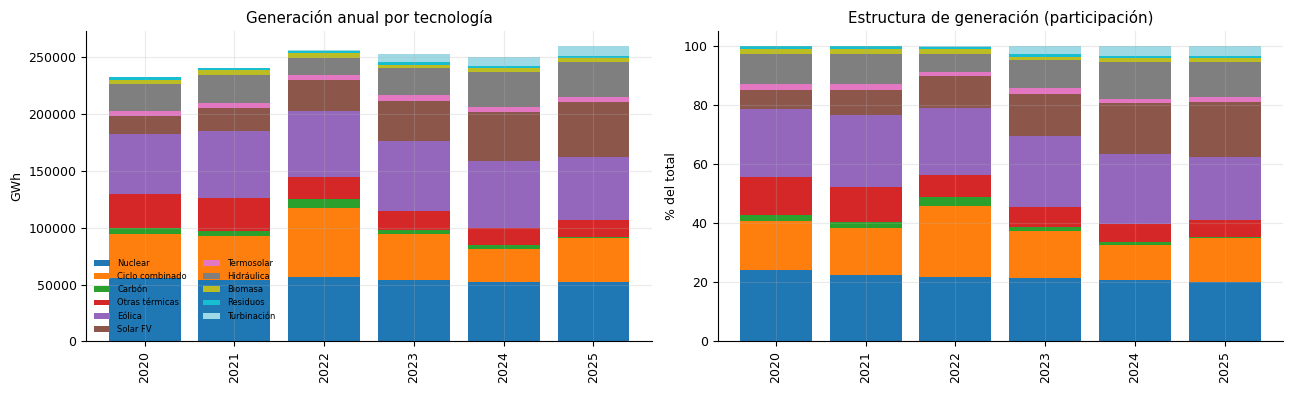

Participación de la generación renovable en el total, por año:


anio,2020,2021,2022,2023,2024,2025,2026
% renovable,43.3,46.8,42.7,50.9,56.2,54.7,57.6


In [68]:
mix = BAL.drop(columns=["TOTAL generación", "Demanda"], errors="ignore")
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
mix.loc[completos].plot(kind="bar", stacked=True, ax=axes[0], width=0.8, colormap="tab20")
axes[0].set_ylabel("GWh"); axes[0].set_xlabel("")
axes[0].set_title("Generación anual por tecnología")
axes[0].legend(frameon=False, fontsize=6, ncol=2)

mix_pct.loc[completos].plot(kind="bar", stacked=True, ax=axes[1], width=0.8, colormap="tab20")
axes[1].set_ylabel("% del total"); axes[1].set_xlabel("")
axes[1].set_title("Estructura de generación (participación)")
axes[1].legend().remove()
plt.tight_layout(); plt.show()

RENOV = ["Eólica", "Solar FV", "Termosolar", "Hidráulica", "Biomasa"]
ren = [c for c in RENOV if c in mix_pct.columns]
print("Participación de la generación renovable en el total, por año:")
display(mix_pct[ren].sum(axis=1).round(1).rename("% renovable").to_frame().T)

## 6.2 · Renovable frente a no renovable

El balance anterior enumera tecnologías. Agrupadas en las dos familias que de verdad se
comportan distinto —la que oferta a coste variable prácticamente nulo y la que oferta a coste de
combustible— la evolución del sistema se lee de un vistazo, y con ella la del precio: cada punto
de participación renovable adicional desplaza la curva de oferta y abarata las horas en que esa
renovable produce.

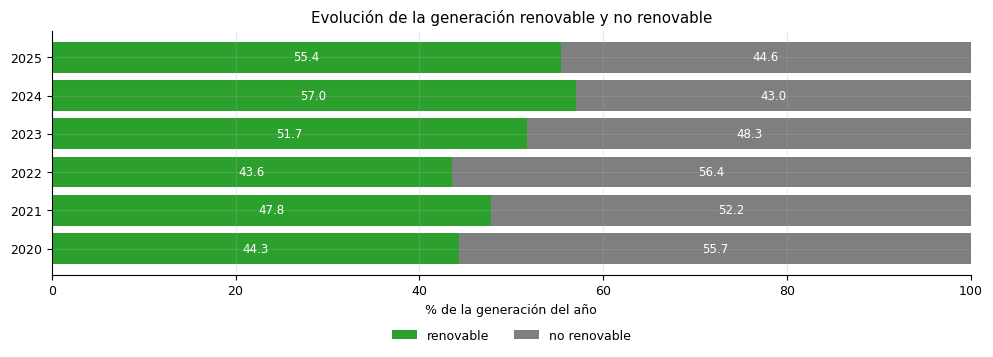

,renovable,no renovable
anio,,
2020,44.3,55.7
2021,47.8,52.2
2022,43.6,56.4
2023,51.7,48.3
2024,57.0,43.0
2025,55.4,44.6


La participación renovable pasa del 44.3 % al 55.4 % (+11.1 puntos).


In [69]:
FAMILIA_TEC = {
    "Eólica": "renovable", "Solar FV": "renovable", "Termosolar": "renovable",
    "Hidráulica": "renovable", "Biomasa": "renovable", "Residuos": "renovable",
    "Nuclear": "no renovable", "Ciclo combinado": "no renovable", "Carbón": "no renovable",
    "Otras térmicas": "no renovable", "Turbinación": "no renovable",
}
E_tec = BAL.drop(columns=["TOTAL generación", "Demanda"], errors="ignore")
E_tec = E_tec.loc[completos]

fam = pd.DataFrame({
    f: E_tec[[t for t in E_tec.columns if FAMILIA_TEC.get(t) == f]].sum(axis=1)
    for f in ("renovable", "no renovable")})
fam_pct = fam.div(fam.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 3.8))
etq_anios = fam_pct.index.astype(str)
ax.barh(etq_anios, fam_pct["renovable"], color=PALETA["ok"], label="renovable")
ax.barh(etq_anios, fam_pct["no renovable"], left=fam_pct["renovable"],
        color=PALETA["neutro"], label="no renovable")
for i, (r_, nr) in enumerate(zip(fam_pct["renovable"], fam_pct["no renovable"])):
    ax.text(r_ / 2, i, f"{r_:.1f}", ha="center", va="center", color="white", fontsize=8.5)
    ax.text(r_ + nr / 2, i, f"{nr:.1f}", ha="center", va="center", color="white", fontsize=8.5)
ax.set_xlabel("% de la generación del año"); ax.set_xlim(0, 100)
ax.set_title("Evolución de la generación renovable y no renovable")
ax.legend(frameon=False, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.32))
plt.tight_layout(); plt.show()

display(fam_pct.round(1))
salto = fam_pct["renovable"].iloc[-1] - fam_pct["renovable"].iloc[0]
print(f"La participación renovable pasa del {fam_pct['renovable'].iloc[0]:.1f} % al "
      f"{fam_pct['renovable'].iloc[-1]:.1f} % ({salto:+.1f} puntos).")

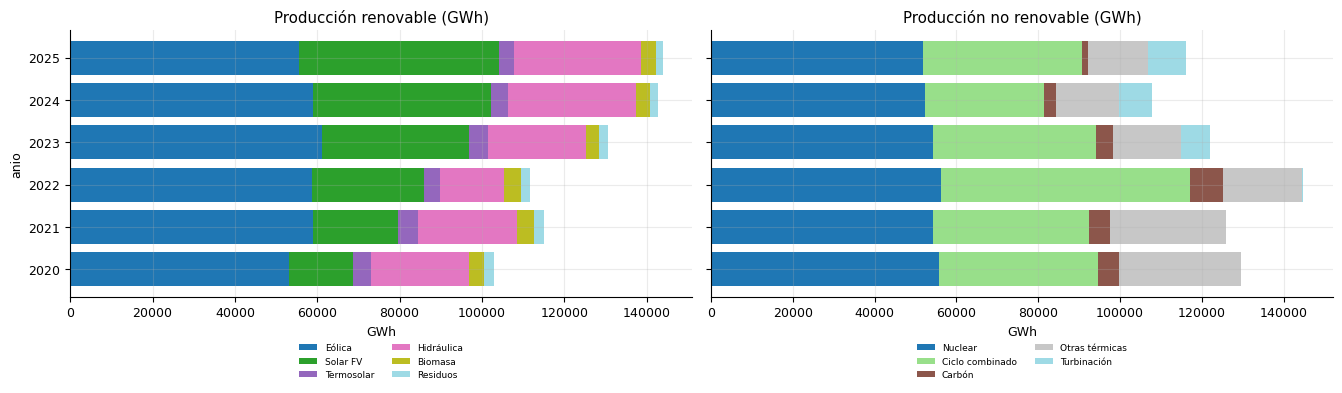

El desglose muestra que el crecimiento renovable no es homogéneo: lo aporta casi todo la
fotovoltaica, mientras la eólica y la hidráulica se mantienen. Y en el lado no renovable,
la caída del carbón se compensa parcialmente con ciclo combinado, que es la tecnología
que fija el precio en las horas caras según el apartado 3.6.


In [70]:
# Dentro de cada familia, qué tecnología aporta el cambio.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2), sharey=True)
for ax, f in zip(axes, ("renovable", "no renovable")):
    sub = E_tec[[t for t in E_tec.columns if FAMILIA_TEC.get(t) == f]]
    sub.plot(kind="barh", stacked=True, ax=ax, width=0.8, colormap="tab20", legend=False)
    ax.set_title(f"Producción {f} (GWh)"); ax.set_xlabel("GWh")
    ax.legend(frameon=False, fontsize=6.5, ncol=2, loc="lower center",
              bbox_to_anchor=(0.5, -0.34))
plt.tight_layout(); plt.show()

print("El desglose muestra que el crecimiento renovable no es homogéneo: lo aporta casi todo la")
print("fotovoltaica, mientras la eólica y la hidráulica se mantienen. Y en el lado no renovable,")
print("la caída del carbón se compensa parcialmente con ciclo combinado, que es la tecnología")
print("que fija el precio en las horas caras según el apartado 3.6.")

## 6.3 · La transformación del parque de generación

El cambio de estructura del precio descrito en el apartado 3.4 tiene una causa física, y esta es
la tabla que la contiene: la potencia instalada por tecnología. Interesa tanto lo que crece como
lo que no se mueve, porque las columnas constantes fueron el hallazgo D-04 y aquí se ve por qué
lo son —España no ha conectado nucleares ni ciclos combinados nuevos en el período—.

anio,2020,2021,2022,2023,2024,2025,2026
hydro,17097.0,17093.0,17092.0,17095.0,17095.0,17083.0,17076.0
wind,26154.0,27588.0,28935.0,29852.0,30764.0,32127.0,32800.0
wind_hybrid,NaN,NaN,NaN,273.0,184.0,296.0,596.0
solar_pv,10257.0,13672.0,18465.0,25372.0,33561.0,44080.0,52682.0
solar_pv_hybrid,NaN,NaN,NaN,6.0,208.0,344.0,681.0
other_renewable,1091.0,1093.0,1094.0,1096.0,1100.0,1118.0,1126.0
waste_nonrenewable,401.0,406.0,395.0,387.0,387.0,383.0,380.0
waste_renewable,119.0,131.0,132.0,132.0,132.0,132.0,132.0
battery_hybrid,NaN,NaN,NaN,NaN,10.0,14.0,144.0
autoconsume_solar_pv,362.0,606.0,1178.0,2857.0,5209.0,7655.0,8831.0


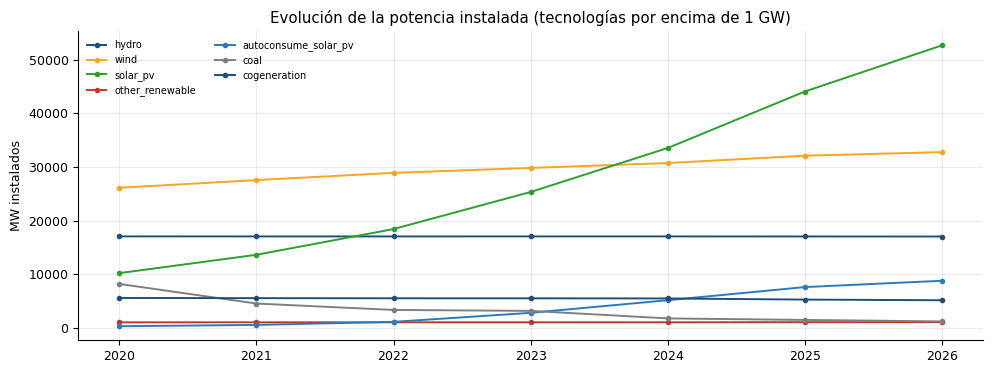

Tecnologías con potencia constante en todo el período: ['pump', 'autoconsume_battery', 'nuclear', 'fuel', 'ccgt']
Confirma D-04 desde el lado físico: no es un fallo del dato, es que no se construyó.


In [71]:
INSTALADA = {c: c.replace("cap_inst_", "").replace("_mw", "")
             for c in df.columns if c.startswith("cap_inst_")}
INST = df.groupby("anio")[list(INSTALADA)].mean().rename(columns=INSTALADA).round(0)
crecen = INST.loc[:, INST.std() > 1]
display(crecen.T)

fig, ax = plt.subplots(figsize=(10, 3.8))
for c in crecen.columns:
    if crecen[c].max() > 1000:
        ax.plot(crecen.index, crecen[c], marker="o", ms=3, lw=1.4, label=c)
ax.set_ylabel("MW instalados"); ax.set_xlabel("")
ax.set_title("Evolución de la potencia instalada (tecnologías por encima de 1 GW)")
ax.legend(frameon=False, fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

constantes_inst = INST.columns[INST.std() < 1e-6].tolist()
print(f"Tecnologías con potencia constante en todo el período: {constantes_inst}")
print("Confirma D-04 desde el lado físico: no es un fallo del dato, es que no se construyó.")

## 6.4 · La capacidad instalada explica el cambio del precio

El apartado 3.4 estableció el resultado más importante del análisis —el perfil horario del precio
ha cambiado de forma durante el propio período de entrenamiento— pero lo dejó como una
constatación. Este apartado le busca la **causa medible**, que es la condición para poder
incorporarla al modelo como variable en lugar de resignarse a la no estacionariedad.

La hipótesis es directa: la fotovoltaica produce en las horas centrales y desplaza allí la curva
de oferta, de modo que **cuanta más potencia instalada haya, más profundo será el hueco de
mediodía**. Se define ese hueco como la diferencia entre el precio medio de las horas centrales
(11 a 16) y el precio medio del día, con lo que queda expresado en euros por megavatio-hora y es
independiente del nivel general de precios.

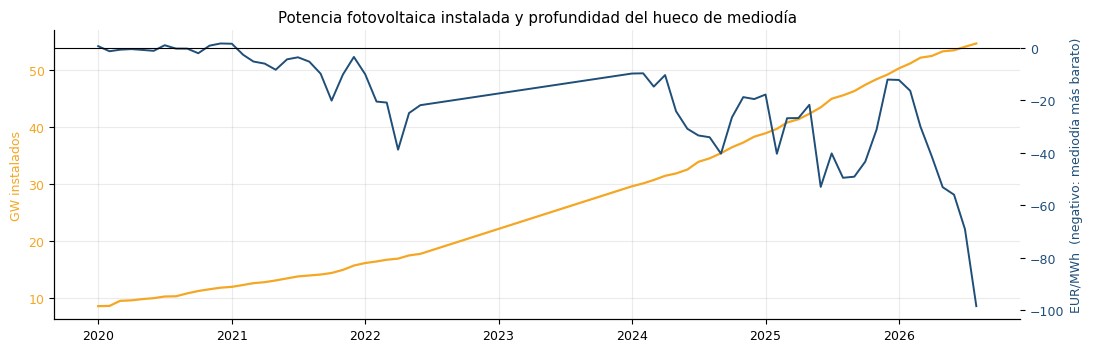

Correlación entre ambas series mensuales: -0.7694
Correlación con la amplitud diaria del precio: +0.7099


In [72]:
FV_CAP = cm.pick(df, "cap_inst_solar_pv_mw")
AUTO_CAP = cm.pick(df, "cap_inst_autoconsume_solar_pv_mw")

MES = NORMAL.groupby("mes_p").apply(lambda g: pd.Series({
    "fv_instalada": g[FV_CAP].mean(),
    "autoconsumo": g[AUTO_CAP].mean() if AUTO_CAP else np.nan,
    "hueco_mediodia": g[g["hora"].between(11, 16)][P].mean() - g[P].mean(),
    "amplitud_diaria": g.groupby("dia")[P].agg(lambda s_: s_.max() - s_.min()).mean(),
    "precio_medio": g[P].mean(),
}), include_groups=False).dropna(subset=["fv_instalada", "hueco_mediodia"])
MES["mes"] = MES.index.month

fig, ax = plt.subplots(figsize=(11, 3.6))
t_ = MES.index.to_timestamp()
ax.plot(t_, MES["fv_instalada"] / 1000, lw=1.6, color=PALETA["acento"],
        label="fotovoltaica instalada (GW)")
ax.set_ylabel("GW instalados", color=PALETA["acento"])
ax.tick_params(axis="y", labelcolor=PALETA["acento"])
ax2 = ax.twinx()
ax2.plot(t_, MES["hueco_mediodia"], lw=1.4, color=PALETA["principal"],
         label="hueco de mediodía (EUR/MWh)")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("EUR/MWh  (negativo: mediodía más barato)", color=PALETA["principal"])
ax2.tick_params(axis="y", labelcolor=PALETA["principal"]); ax2.grid(False)
ax.set_title("Potencia fotovoltaica instalada y profundidad del hueco de mediodía")
plt.tight_layout(); plt.show()

print(f"Correlación entre ambas series mensuales: "
      f"{MES['fv_instalada'].corr(MES['hueco_mediodia']):+.4f}")
print(f"Correlación con la amplitud diaria del precio: "
      f"{MES['fv_instalada'].corr(MES['amplitud_diaria']):+.4f}")

### La comprobación que esa correlación exige

Las dos series crecen —una monótonamente, la otra por estacionalidad— y este mismo cuaderno ha
advertido varias veces de que dos series con tendencia compartida correlacionan sin que exista
relación alguna. Aceptar el coeficiente anterior sin más sería incurrir precisamente en el error
que el apartado 4.4 denuncia.

El contraste adecuado consiste en medir la relación **dentro de cada mes del calendario**: todos
los agostos entre sí, todos los eneros entre sí. Así la estacionalidad queda fijada y lo único
que varía entre observaciones es el año, es decir, la potencia instalada.

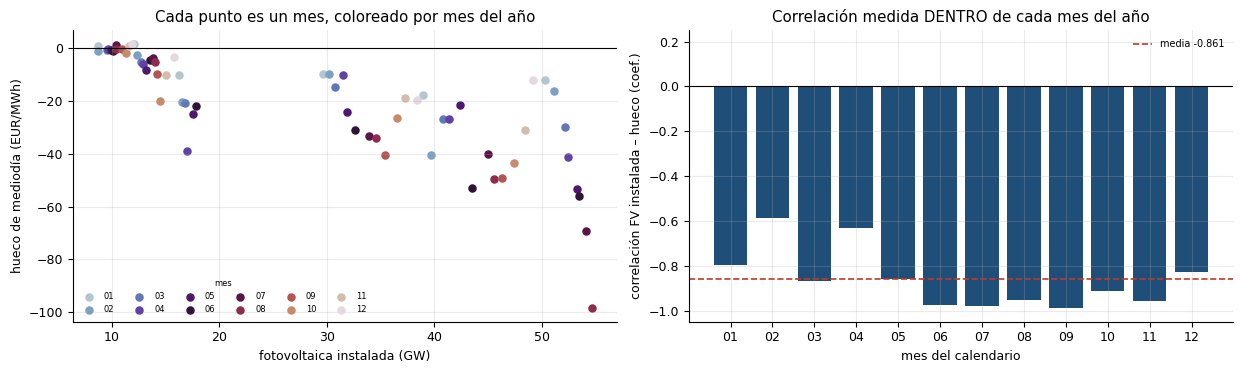

Meses con correlación negativa: 12 de 12
Correlación media intra-mes:    -0.8613
Rango:                          -0.990 a -0.587


In [73]:
intra = MES.groupby("mes").apply(
    lambda g: g["fv_instalada"].corr(g["hueco_mediodia"]) if len(g) > 3 else np.nan,
    include_groups=False).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))

cmap = plt.get_cmap("twilight")
for mm in sorted(MES["mes"].unique()):
    sub = MES[MES["mes"] == mm]
    axes[0].scatter(sub["fv_instalada"] / 1000, sub["hueco_mediodia"], s=26,
                    color=cmap(mm / 12), label=f"{mm:02d}")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xlabel("fotovoltaica instalada (GW)")
axes[0].set_ylabel("hueco de mediodía (EUR/MWh)")
axes[0].set_title("Cada punto es un mes, coloreado por mes del año")
axes[0].legend(frameon=False, fontsize=6, ncol=6, title="mes", title_fontsize=6,
               loc="lower left")

axes[1].bar([f"{m:02d}" for m in intra.index], intra.values, color=PALETA["principal"])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axhline(intra.mean(), color=PALETA["alerta"], ls="--", lw=1.2,
                label=f"media {intra.mean():+.3f}")
axes[1].set_ylim(-1.05, 0.25)
axes[1].set_xlabel("mes del calendario"); axes[1].set_ylabel("correlación FV instalada – hueco (coef.)")
axes[1].set_title("Correlación medida DENTRO de cada mes del año")
axes[1].legend(frameon=False, fontsize=7)
plt.tight_layout(); plt.show()

print(f"Meses con correlación negativa: {int((intra < 0).sum())} de {len(intra)}")
print(f"Correlación media intra-mes:    {intra.mean():+.4f}")
print(f"Rango:                          {intra.min():+.3f} a {intra.max():+.3f}")

In [74]:
if (intra < 0).all() and intra.mean() < -0.5:
    print("La relación sobrevive al control: en LOS DOCE meses del calendario, los años con más")
    print("potencia fotovoltaica instalada son los años con el mediodía más barato. No es")
    print("tendencia compartida, porque dentro de un mismo mes la estacionalidad no varía.\n")
    REG.anotar("P.8", "La capacidad fotovoltaica instalada explica el hueco de mediodía",
               "confirmado",
               f"Correlación media de {intra.mean():+.3f} medida dentro de cada mes del "
               f"calendario, negativa en los {len(intra)} meses. Da a la no estacionariedad del "
               "apartado 3.4 una causa medible, y por tanto una variable: la capacidad instalada "
               "entra al modelo como regresor en lugar de dejar el cambio sin explicar.")
else:
    print("La relación NO se sostiene al controlar por mes: buena parte del coeficiente global")
    print("era tendencia compartida entre dos series crecientes.")

La relación sobrevive al control: en LOS DOCE meses del calendario, los años con más
potencia fotovoltaica instalada son los años con el mediodía más barato. No es
tendencia compartida, porque dentro de un mismo mes la estacionalidad no varía.

  [P.8] confirmado: La capacidad fotovoltaica instalada explica el hueco de mediodía


**Por qué este resultado importa más que su tamaño.** La no estacionariedad detectada en el
apartado 3.4 planteaba un problema sin solución evidente: si la estructura del precio cambia
durante el período de entrenamiento, el histórico antiguo enseña algo que ya no es cierto. Las
salidas habituales son ponderar por antigüedad o recortar el histórico, y ambas desperdician
datos.

Al identificar la causa y disponer de ella como serie medida, aparece una tercera vía: **incluir
la capacidad instalada como variable explicativa**, de modo que el modelo aprenda la relación
condicionada al parque existente en cada momento y el histórico antiguo siga siendo informativo.
Es la razón de que el cuaderno de ingeniería de variables la incorpore en su apartado 4.6.

## 6.5 · La cobertura renovable de la demanda casi se duplica

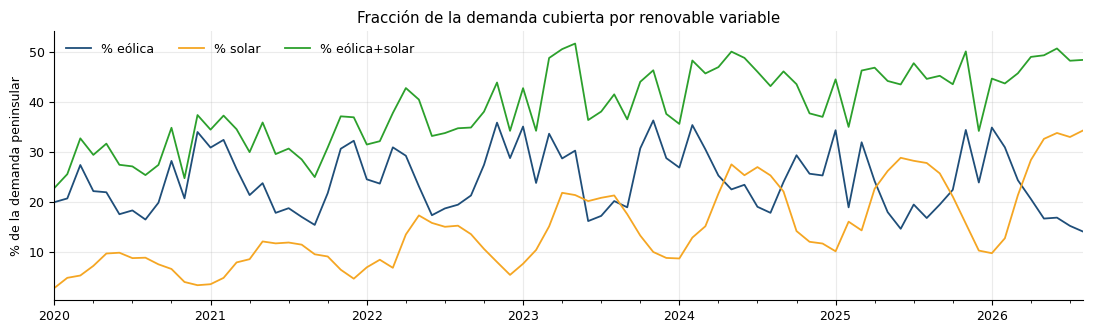

,% eólica,% solar,% eólica+solar
mes_p,,,
2020,22.3,6.6,28.9
2021,24.1,8.5,32.6
2022,25.1,11.4,36.5
2023,26.7,15.7,42.4
2024,25.5,18.7,44.2
2025,23.3,20.6,43.9
2026,21.8,25.8,47.5


Constituye la explicación física del cambio de estructura horaria descrito en 3.4.


In [75]:
if all([DEM, EOL, FV]):
    m = df.groupby("mes_p").agg(dem=(DEM, "sum"), eol=(EOL, "sum"), sol=(FV, "sum"))
    m["% eólica"] = m["eol"] / m["dem"] * 100
    m["% solar"] = m["sol"] / m["dem"] * 100
    m["% eólica+solar"] = m["% eólica"] + m["% solar"]

    ax = m[["% eólica", "% solar", "% eólica+solar"]].plot(figsize=(11, 3.4), lw=1.3)
    ax.set_ylabel("% de la demanda peninsular"); ax.set_xlabel("")
    ax.set_title("Fracción de la demanda cubierta por renovable variable")
    ax.legend(frameon=False, ncol=3); plt.tight_layout(); plt.show()

    display(m.groupby(m.index.year)[["% eólica", "% solar", "% eólica+solar"]].mean().round(1))
    print("Constituye la explicación física del cambio de estructura horaria descrito en 3.4.")

### La renovable frente al precio, y por qué la fracción importa más que los gigavatios

La figura anterior mide cobertura; ésta la enfrenta al precio. Y conviene hacerlo **normalizado**:
lo que hunde el precio no es la energía renovable en términos absolutos sino **la fracción de la
demanda que cubre**. Diez gigavatios de eólica en un día de demanda alta y en uno de demanda baja
producen efectos muy distintos.

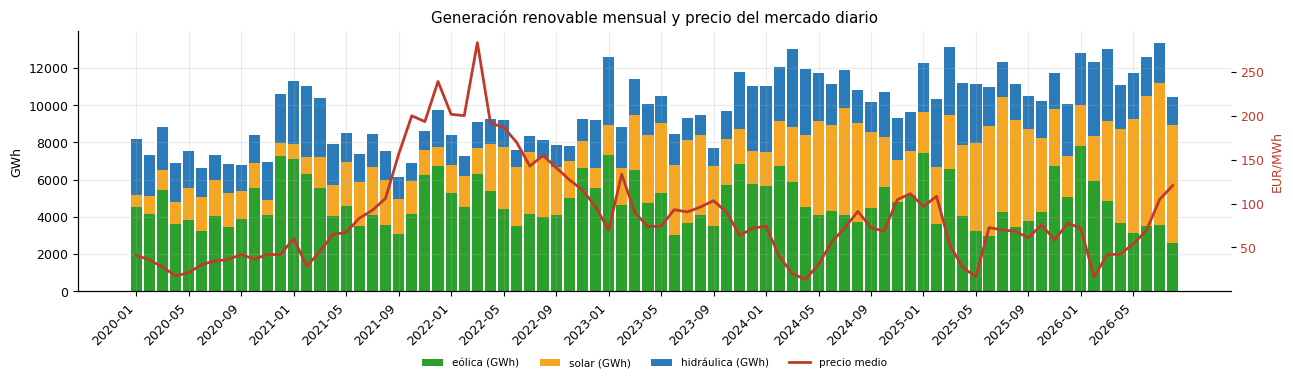

Correlación mensual entre energía renovable y precio : -0.3029
Correlación mensual entre % de cobertura y precio    : -0.3622

La segunda es más intensa que la primera: confirma que lo determinante es la
fracción cubierta, no el volumen.


In [76]:
if all([DEM, EOL, FV]):
    m2 = df.groupby("mes_p").agg(dem=(DEM, "sum"), eol=(EOL, "sum"), sol=(FV, "sum"),
                                 precio=(P, "mean"))
    if HID:
        m2["hid"] = df.groupby("mes_p")[HID].sum()
    m2["pct_ren"] = (m2["eol"] + m2["sol"] + m2.get("hid", 0)) / m2["dem"] * 100

    fig, ax = plt.subplots(figsize=(13, 4))
    x = np.arange(len(m2))
    abajo = np.zeros(len(m2))
    for k, etq_, col in [("eol", "eólica", PALETA["ok"]), ("sol", "solar", PALETA["acento"]),
                         ("hid", "hidráulica", PALETA["secundario"])]:
        if k not in m2:
            continue
        ax.bar(x, m2[k] / 1000, bottom=abajo, width=0.85, color=col, label=f"{etq_} (GWh)")
        abajo += (m2[k] / 1000).values
    ax2 = ax.twinx()
    ax2.plot(x, m2["precio"], color=PALETA["alerta"], lw=2, label="precio medio")
    ax2.set_ylabel("EUR/MWh", color=PALETA["alerta"]); ax2.grid(False)
    ax2.tick_params(axis="y", labelcolor=PALETA["alerta"])
    paso = max(1, len(m2) // 20)
    ax.set_xticks(x[::paso], [str(i) for i in m2.index[::paso]], rotation=45, ha="right")
    ax.set_ylabel("GWh"); ax.set_title("Generación renovable mensual y precio del mercado diario")
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, frameon=False, ncol=4, fontsize=7.5,
              loc="upper center", bbox_to_anchor=(0.5, -0.22))
    plt.tight_layout(); plt.show()

    ren_total = m2[[c for c in ("eol", "sol", "hid") if c in m2]].sum(axis=1)
    print(f"Correlación mensual entre energía renovable y precio : "
          f"{corr_segura(ren_total, m2['precio']):+.4f}")
    print(f"Correlación mensual entre % de cobertura y precio    : "
          f"{corr_segura(m2['pct_ren'], m2['precio']):+.4f}")
    print("\nLa segunda es más intensa que la primera: confirma que lo determinante es la")
    print("fracción cubierta, no el volumen.")

### La consecuencia que interesa al almacenamiento

La relación agregada es informativa, pero el modelo trabaja hora a hora. La tabla siguiente
divide las horas por su penetración renovable instantánea y mide, en cada tramo, **con qué
frecuencia el precio cae a cero o por debajo**.

Es la cifra que da valor a cargar la batería: no interesa sólo que el precio baje, sino que
llegue a ser retribuido consumir.

,horas,precio_medio,pct_precio_cero_o_negativo
pct,,,
<20 %,12235,114.10,0.01
20-40 %,20941,100.41,0.40
40-60 %,14345,78.82,2.07
60-80 %,8760,39.87,16.94
>80 %,1986,12.25,34.89


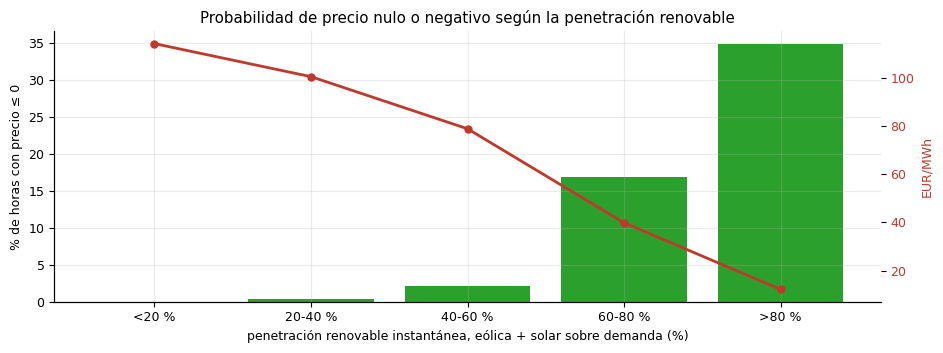

Con penetración por debajo del 20 %, el precio es nulo o negativo el 0.0 % de las horas.
Por encima del 80 %, el 34.9 %.
  [M.6] confirmado: La penetración renovable instantánea determina el precio nulo o negativo


In [77]:
if all([DEM, EOL, FV]):
    hh = df[[P, DEM, EOL, FV]].dropna().copy()
    hh["pct"] = (hh[EOL] + hh[FV]) / hh[DEM].replace(0, np.nan) * 100
    tramos = pd.cut(hh["pct"], [0, 20, 40, 60, 80, 200],
                    labels=["<20 %", "20-40 %", "40-60 %", "60-80 %", ">80 %"])
    resumen_pen = hh.groupby(tramos, observed=True)[P].agg(
        horas="size", precio_medio="mean",
        pct_precio_cero_o_negativo=lambda s_: (s_ <= 0).mean() * 100).round(2)
    display(resumen_pen)

    fig, ax = plt.subplots(figsize=(9.5, 3.6))
    ax.bar(resumen_pen.index.astype(str), resumen_pen["pct_precio_cero_o_negativo"],
           color=PALETA["ok"])
    ax.set_ylabel("% de horas con precio ≤ 0")
    ax.set_xlabel("penetración renovable instantánea, eólica + solar sobre demanda (%)")
    ax2 = ax.twinx()
    ax2.plot(resumen_pen.index.astype(str), resumen_pen["precio_medio"], color=PALETA["alerta"],
             lw=2, marker="o", ms=5, label="precio medio")
    ax2.set_ylabel("EUR/MWh", color=PALETA["alerta"]); ax2.grid(False)
    ax2.tick_params(axis="y", labelcolor=PALETA["alerta"])
    ax.set_title("Probabilidad de precio nulo o negativo según la penetración renovable")
    plt.tight_layout(); plt.show()

    bajo_t = resumen_pen["pct_precio_cero_o_negativo"].iloc[0]
    alto_t = resumen_pen["pct_precio_cero_o_negativo"].iloc[-1]
    print(f"Con penetración por debajo del 20 %, el precio es nulo o negativo el {bajo_t:.1f} % "
          "de las horas.")
    print(f"Por encima del 80 %, el {alto_t:.1f} %.")
    REG.anotar("M.6", "La penetración renovable instantánea determina el precio nulo o negativo",
               "confirmado",
               f"La probabilidad de precio ≤ 0 pasa del {bajo_t:.1f} % al {alto_t:.1f} % entre "
               "el tramo de menor y el de mayor penetración. La versión PREVISTA de esta "
               "variable sí es utilizable a las 12:00 de D, y es la que el cuaderno de "
               "ingeniería construye como cobertura renovable prevista.")

## 6.6 · La demanda peninsular: nivel, máximos y perfil

La demanda es la otra mitad de la ecuación del precio, y conviene caracterizarla con el mismo
detalle que la generación. Interesa por tres vías distintas: su **nivel** anual, que dice si el
sistema crece o se estanca; sus **máximos** estacionales, que son los momentos de mayor tensión;
y su **perfil horario**, que junto con el de la renovable determina la forma del precio.

Los años incompletos se excluyen de las comparaciones de nivel: sumar energía sobre un año a
medias produce una caída ficticia que no significa nada.

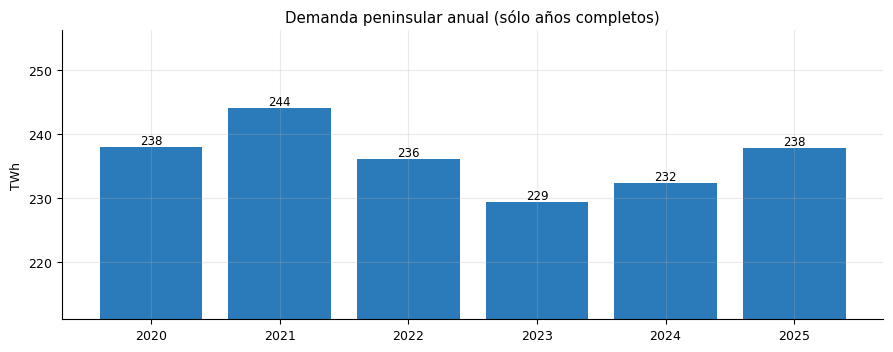

Excluidos por incompletos: [2026] ({2026: 160.1} TWh hasta el corte de datos).

Variación entre el primer y el último año completo: -0.1 %.
La demanda peninsular no crece: el cambio del precio no viene del consumo sino de
la oferta, que es lo que documentan los apartados anteriores.


In [78]:
if DEM:
    anual_dem = df.groupby("anio")[DEM].sum() / 1e6          # MWh -> TWh
    dem_completos = anual_dem.loc[[a for a in anual_dem.index if a in completos]]

    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.bar(dem_completos.index.astype(str), dem_completos.values, color=PALETA["secundario"])
    for x_, v in zip(dem_completos.index.astype(str), dem_completos.values):
        ax.text(x_, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8.5)
    ax.set_ylabel("TWh"); ax.set_xlabel("")
    ax.set_ylim(dem_completos.min() * 0.92, dem_completos.max() * 1.05)
    ax.set_title("Demanda peninsular anual (sólo años completos)")
    plt.tight_layout(); plt.show()

    parciales = [a for a in anual_dem.index if a not in completos]
    if parciales:
        print(f"Excluidos por incompletos: {parciales} "
              f"({anual_dem.loc[parciales].round(1).to_dict()} TWh hasta el corte de datos).")
    var_dem = (dem_completos.iloc[-1] / dem_completos.iloc[0] - 1) * 100
    print(f"\nVariación entre el primer y el último año completo: {var_dem:+.1f} %.")
    print("La demanda peninsular no crece: el cambio del precio no viene del consumo sino de")
    print("la oferta, que es lo que documentan los apartados anteriores.")

### Los máximos estacionales y el desplazamiento del pico

**Un resultado que confirma el cambio estructural desde una variable independiente del precio.**
Si el desplazamiento del perfil horario fuera un artefacto del mercado, no debería aparecer en la
demanda física. El máximo de invierno se mantiene estable; el de verano se desplaza hacia la
tarde-noche conforme la fotovoltaica cubre la demanda de mediodía.

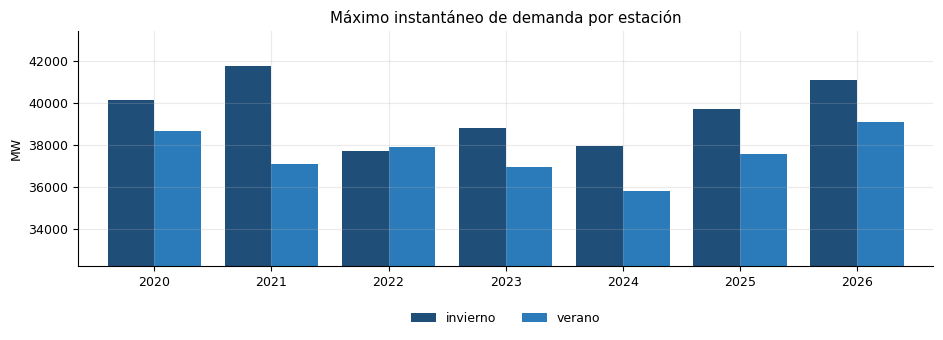

In [79]:
if DEM:
    d2 = df[["ts_local", "anio", "mes", "hora", DEM]].dropna().copy()
    d2["estacion"] = np.where(d2["mes"].isin([12, 1, 2]), "invierno",
                      np.where(d2["mes"].isin([6, 7, 8]), "verano", "resto"))
    maximos = (d2[d2["estacion"] != "resto"].groupby(["anio", "estacion"])[DEM].max().unstack())

    fig, ax = plt.subplots(figsize=(9.5, 3.6))
    maximos.plot(kind="bar", ax=ax, width=0.8,
                 color={"invierno": PALETA["principal"], "verano": PALETA["secundario"]})
    ax.set_ylabel("MW"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(maximos.min().min() * 0.9, maximos.max().max() * 1.04)
    ax.set_title("Máximo instantáneo de demanda por estación")
    ax.legend(frameon=False, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.30))
    plt.tight_layout(); plt.show()

Hora local del máximo diario de demanda (moda por año y estación):


estacion,invierno,resto,verano
anio,,,
2020,20,13,13
2021,20,20,13
2022,20,20,14
2023,20,21,14
2024,20,21,21
2025,20,21,21
2026,20,21,20


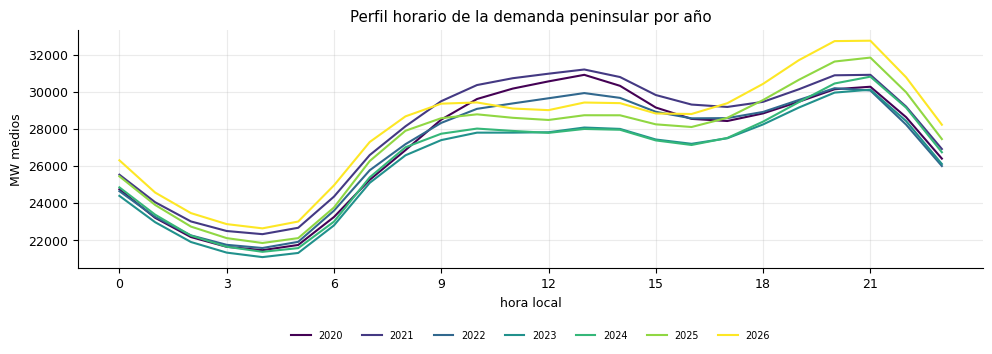

El perfil de la demanda apenas cambia de forma: el hueco de mediodía del PRECIO no
procede de que se consuma menos a esa hora, sino de que la fotovoltaica cubre esa
demanda. Es lo que muestra el apartado siguiente con la demanda residual.


In [80]:
if DEM:
    d2["dia"] = df.loc[d2.index, "dia"]
    idx = d2.groupby("dia")[DEM].idxmax().dropna()
    picos = d2.loc[idx]
    print("Hora local del máximo diario de demanda (moda por año y estación):")
    display(picos.groupby(["anio", "estacion"])["hora"].agg(
        lambda s_: s_.mode().iat[0] if len(s_.mode()) else np.nan).unstack())

    perfil_dem = d2.pivot_table(index="hora", columns="anio", values=DEM, aggfunc="mean")
    cmap = plt.get_cmap("viridis")
    fig, ax = plt.subplots(figsize=(10, 3.8))
    for i, a in enumerate(perfil_dem.columns):
        ax.plot(perfil_dem.index, perfil_dem[a], lw=1.5,
                color=cmap(i / max(len(perfil_dem.columns) - 1, 1)), label=str(a))
    ax.set_xlabel("hora local"); ax.set_ylabel("MW medios"); ax.set_xticks(range(0, 24, 3))
    ax.set_title("Perfil horario de la demanda peninsular por año")
    ax.legend(frameon=False, ncol=len(perfil_dem.columns), fontsize=7,
              loc="lower center", bbox_to_anchor=(0.5, -0.34))
    plt.tight_layout(); plt.show()

    print("El perfil de la demanda apenas cambia de forma: el hueco de mediodía del PRECIO no")
    print("procede de que se consuma menos a esa hora, sino de que la fotovoltaica cubre esa")
    print("demanda. Es lo que muestra el apartado siguiente con la demanda residual.")

## 6.7 · La demanda residual: la curva de pato del sistema

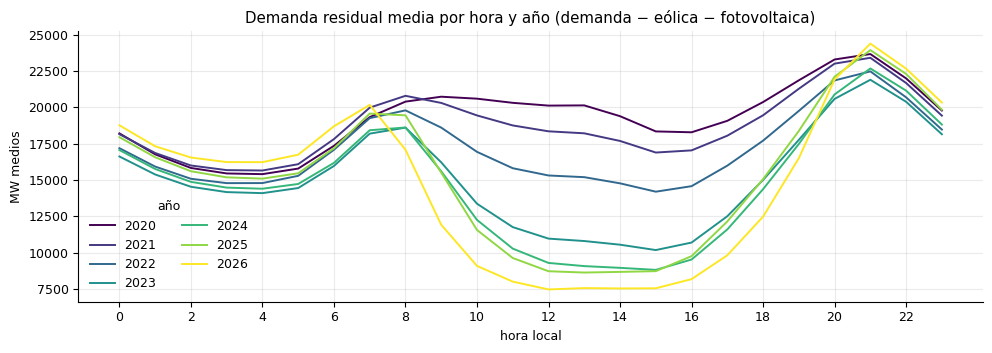

El hueco de mediodía se profundiza año a año: es la explicación física de la
forma del precio horario.

La demanda residual se calcula aquí sobre magnitudes REALES, para describir el
sistema. Su versión utilizable —construida sobre las previsiones de REE— es una
variable derivada del cuaderno siguiente, apartado 4.3.


In [81]:
if all([DEM, EOL, FV]):
    d3 = df[["hora", "anio", DEM, EOL, FV]].dropna().copy()
    d3["residual"] = d3[DEM] - d3[EOL] - d3[FV]
    res = d3.pivot_table(index="hora", columns="anio", values="residual", aggfunc="mean")
    ax = res.plot(figsize=(10, 3.6), colormap="viridis", lw=1.4)
    ax.set_xlabel("hora local"); ax.set_ylabel("MW medios"); ax.set_xticks(range(0, 24, 2))
    ax.set_title("Demanda residual media por hora y año (demanda − eólica − fotovoltaica)")
    ax.legend(title="año", frameon=False, ncol=2)
    plt.tight_layout(); plt.show()
    print("El hueco de mediodía se profundiza año a año: es la explicación física de la")
    print("forma del precio horario.")
    print("\nLa demanda residual se calcula aquí sobre magnitudes REALES, para describir el")
    print("sistema. Su versión utilizable —construida sobre las previsiones de REE— es una")
    print("variable derivada del cuaderno siguiente, apartado 4.3.")

## 6.8 · La curva de oferta empírica

El orden de mérito del sistema deducido del dato: cuánto cuesta cubrir cada nivel de demanda
residual. Su desplazamiento entre años mide el cambio del parque de generación.

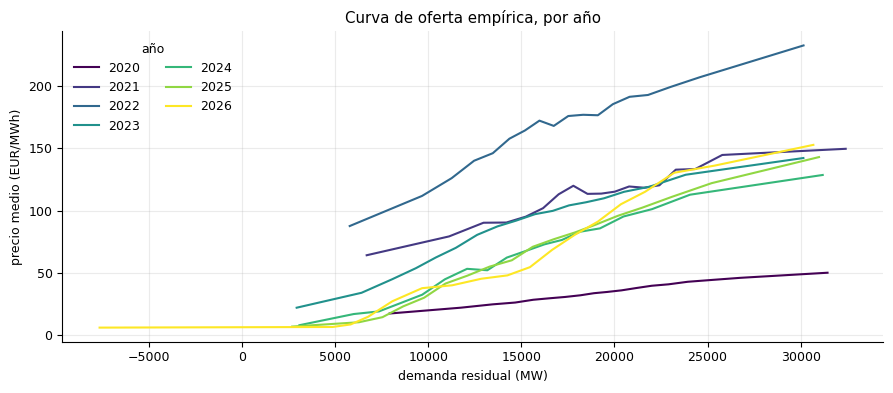

In [82]:
if all([DEM, EOL, FV]):
    r = df[["anio", P, DEM, EOL, FV]].dropna().copy()
    r["residual"] = r[DEM] - r[EOL] - r[FV]
    fig, ax = plt.subplots(figsize=(9, 4))
    cmap = plt.get_cmap("viridis"); aa = sorted(r["anio"].unique())
    for i, a in enumerate(aa):
        sub = r[r["anio"] == a]
        tr = pd.qcut(sub["residual"], 18, duplicates="drop")
        pf = sub.groupby(tr, observed=True)[P].mean()
        ax.plot([iv.mid for iv in pf.index], pf.values, lw=1.5,
                color=cmap(i / max(len(aa) - 1, 1)), label=str(a))
    ax.set_xlabel("demanda residual (MW)"); ax.set_ylabel("precio medio (EUR/MWh)")
    ax.set_title("Curva de oferta empírica, por año")
    ax.legend(frameon=False, ncol=2, title="año")
    plt.tight_layout(); plt.show()

## 6.9 · La demanda frente a la temperatura: una relación en U

La correlación lineal entre temperatura y demanda es casi nula, lo que sugeriría que la
temperatura no explica nada. Es falso: la relación tiene forma de U —sube con el frío y con el
calor— y al separarla en sus dos ramas mediante grados-día aparece con claridad.

El caso ilustra que un coeficiente de correlación reducido no permite concluir la ausencia de
relación entre dos variables.

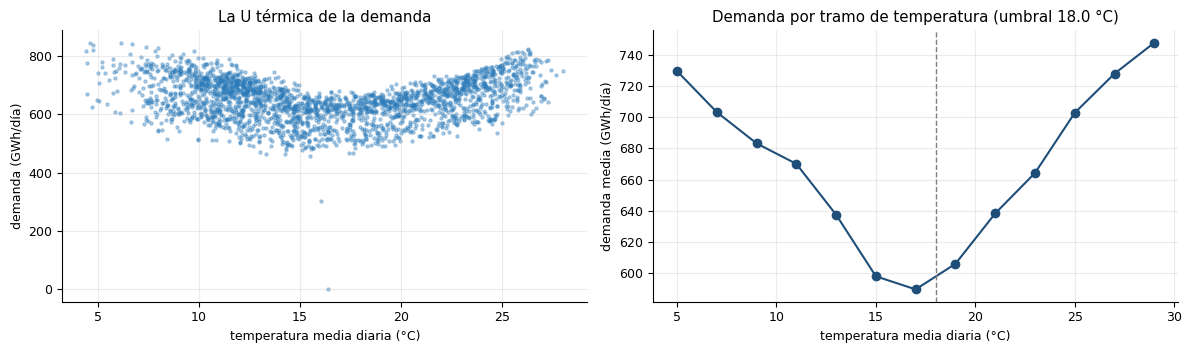

Correlación con la demanda (sólo días laborables):
  temperatura lineal  : +0.0109
  grados-día de frío  : +0.2292
  grados-día de calor : +0.3371
  [P.6] confirmado: La demanda responde a la temperatura en forma de U


In [83]:
if T2M and DEM:
    dia_ = df.groupby("dia").agg(temp=(T2M, "mean"), demanda=(DEM, "sum")).dropna()
    if dia_["temp"].mean() > 200:
        dia_["temp"] = dia_["temp"] - 273.15    # ERA5 publica en Kelvin
    dia_["demanda"] /= 1000
    dia_.index = pd.to_datetime(dia_.index)
    dia_["laborable"] = dia_.index.dayofweek < 5
    UMBRAL_C = 18.0
    dia_["HDD"] = (UMBRAL_C - dia_["temp"]).clip(lower=0)
    dia_["CDD"] = (dia_["temp"] - UMBRAL_C).clip(lower=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
    axes[0].scatter(dia_["temp"], dia_["demanda"], s=5, alpha=0.35, color=PALETA["secundario"])
    axes[0].set_xlabel("temperatura media diaria (°C)"); axes[0].set_ylabel("demanda (GWh/día)")
    axes[0].set_title("La U térmica de la demanda")
    binned = dia_.groupby(pd.cut(dia_["temp"], bins=np.arange(-2, 34, 2)),
                          observed=True)["demanda"].mean()
    axes[1].plot([i.mid for i in binned.index], binned.values, marker="o",
                 color=PALETA["principal"])
    axes[1].axvline(UMBRAL_C, color=PALETA["neutro"], ls="--", lw=1)
    axes[1].set_xlabel("temperatura media diaria (°C)"); axes[1].set_ylabel("demanda media (GWh/día)")
    axes[1].set_title(f"Demanda por tramo de temperatura (umbral {UMBRAL_C} °C)")
    plt.tight_layout(); plt.show()

    lab = dia_[dia_["laborable"]]
    print("Correlación con la demanda (sólo días laborables):")
    print(f"  temperatura lineal  : {lab['temp'].corr(lab['demanda']):+.4f}")
    print(f"  grados-día de frío  : {lab['HDD'].corr(lab['demanda']):+.4f}")
    print(f"  grados-día de calor : {lab['CDD'].corr(lab['demanda']):+.4f}")

    REG.anotar("P.6", "La demanda responde a la temperatura en forma de U", "confirmado",
               "La temperatura entra al modelo partida en grados-día de frío y de calor, no "
               "como término lineal. Se construyen en el cuaderno siguiente, apartado 4.3.")

### La severidad térmica del año

Los grados-día acumulados resumen en una cifra lo frío o caluroso que fue cada año. Sirven para
lo que aquí importa: **comparar años sin confundir el clima con el resto**. Un año con más
demanda puede serlo por actividad económica o simplemente porque hizo más frío, y sin esta
corrección ambas cosas se mezclan.

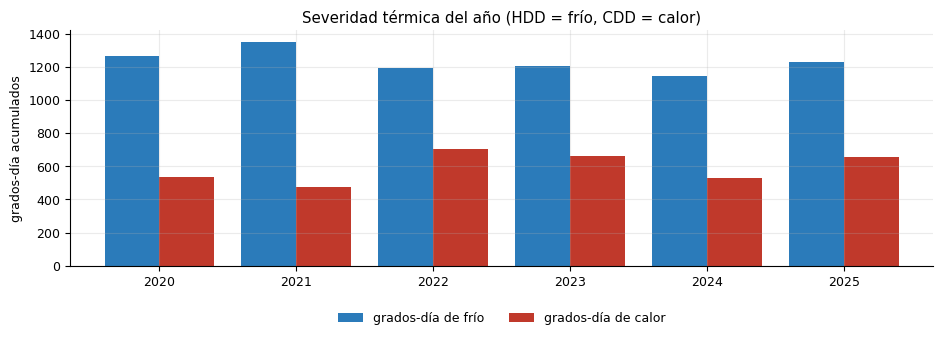

,HDD,CDD
dia,,
2020,1263.0,534.0
2021,1352.0,477.0
2022,1195.0,706.0
2023,1206.0,659.0
2024,1143.0,527.0
2025,1229.0,653.0


Comparar la demanda de dos años sin corregir por severidad térmica mezcla el efecto
del clima con el de la actividad económica. Los grados-día permiten separarlos, y
son además la forma en que la temperatura entra al modelo (apartado 4.3 del cuaderno
de ingeniería de variables).


In [84]:
if T2M and DEM:
    gd = dia_.groupby(dia_.index.year)[["HDD", "CDD"]].sum()
    gd_completos = gd.loc[[a for a in gd.index if a in completos]]

    fig, ax = plt.subplots(figsize=(9.5, 3.6))
    gd_completos.plot(kind="bar", ax=ax, width=0.8,
                      color={"HDD": PALETA["secundario"], "CDD": PALETA["alerta"]})
    ax.set_ylabel("grados-día acumulados"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.set_title("Severidad térmica del año (HDD = frío, CDD = calor)")
    ax.legend(["grados-día de frío", "grados-día de calor"], frameon=False, ncol=2,
              loc="lower center", bbox_to_anchor=(0.5, -0.30))
    plt.tight_layout(); plt.show()
    display(gd_completos.round(0))

    print("Comparar la demanda de dos años sin corregir por severidad térmica mezcla el efecto")
    print("del clima con el de la actividad económica. Los grados-día permiten separarlos, y")
    print("son además la forma en que la temperatura entra al modelo (apartado 4.3 del cuaderno")
    print("de ingeniería de variables).")

## 6.10 · La hidráulica: estacionalidad y años secos

La hidráulica de embalse es la tecnología con **más margen de decisión del operador**: se guarda
agua cuando el precio es bajo y se turbina cuando es alto, de modo que su estacionalidad no es
sólo climática sino también estratégica.

Su relevancia para este trabajo es concreta: **un año seco cambia el orden de mérito de todo el
sistema**. Si el período de entrenamiento incluye un año hidrológicamente atípico, conviene
saberlo antes de interpretar los errores del modelo en ese tramo, porque no serán atribuibles al
modelo sino al año.

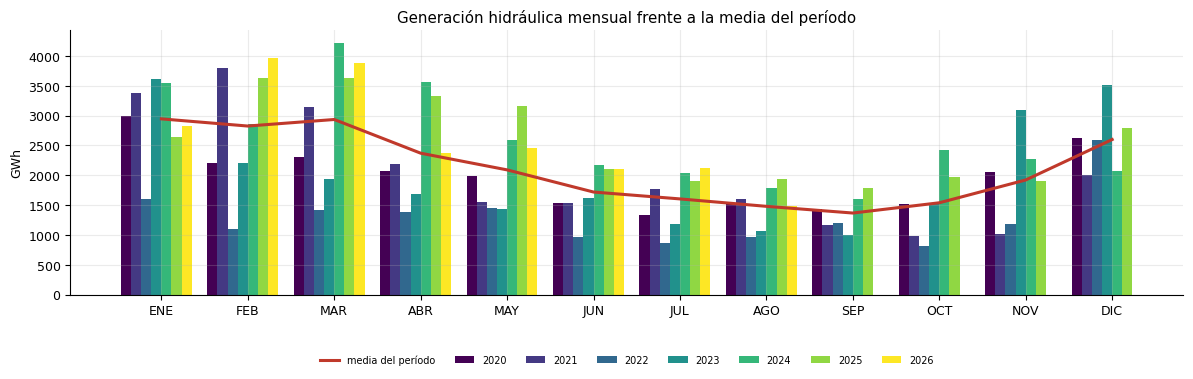

In [85]:
if HID:
    h = df.groupby(["anio", "mes"])[HID].sum().unstack() / 1000        # GWh
    media_mes = h.mean()

    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(1, 13)
    w_barra = 0.82 / len(h)          # no llamarlo `ancho`: ese nombre lo usa la matriz de 3.7
    cmap = plt.get_cmap("viridis")
    for i, (a_, fila) in enumerate(h.iterrows()):
        ax.bar(x + i * w_barra - 0.41, fila.values, width=w_barra,
               color=cmap(i / max(len(h) - 1, 1)), label=str(a_))
    ax.plot(x, media_mes.values, color=PALETA["alerta"], lw=2.2, label="media del período")
    ax.set_xticks(x, ["ENE", "FEB", "MAR", "ABR", "MAY", "JUN", "JUL", "AGO",
                      "SEP", "OCT", "NOV", "DIC"])
    ax.set_ylabel("GWh"); ax.set_xlabel("")
    ax.set_title("Generación hidráulica mensual frente a la media del período")
    ax.legend(frameon=False, ncol=8, fontsize=7, loc="lower center", bbox_to_anchor=(0.5, -0.30))
    plt.tight_layout(); plt.show()

In [86]:
if HID:
    anual_h = h.sum(axis=1)
    ref = anual_h.loc[[a for a in anual_h.index if a in completos]].mean()
    desv = ((anual_h / ref - 1) * 100).round(1)
    tabla_h = pd.DataFrame({"GWh": anual_h.round(0),
                            "desviación % sobre la media": desv,
                            "año completo": [a in completos for a in anual_h.index]})
    display(tabla_h)

    secos = desv[(desv < -15) & tabla_h["año completo"]].index.tolist()
    humedos = desv[(desv > 15) & tabla_h["año completo"]].index.tolist()
    print(f"Años secos (más de un 15 % por debajo de la media): {secos if secos else 'ninguno'}")
    print(f"Años húmedos (más de un 15 % por encima):           {humedos if humedos else 'ninguno'}")

    if secos or humedos:
        REG.anotar("L.10", "El período contiene años hidrológicamente atípicos", "confirmado",
                   f"Secos: {secos}. Húmedos: {humedos}. La hidrología desplaza el orden de "
                   "mérito del sistema, de modo que los errores del modelo en esos tramos no son "
                   "necesariamente atribuibles al modelo. Tenerlo presente al leer la evaluación "
                   "por períodos.")
    else:
        print("\nNingún año se aparta más de un 15 % de la media: la hidrología del período es")
        print("razonablemente homogénea y no distorsiona la comparación entre tramos.")

,GWh,desviación % sobre la media,año completo
anio,,,
2020,23593.0,-5.1,True
2021,24152.0,-2.8,True
2022,15520.0,-37.5,True
2023,23902.0,-3.8,True
2024,31129.0,25.3,True
2025,30799.0,23.9,True
2026,21232.0,-14.6,False


Años secos (más de un 15 % por debajo de la media): [2022]
Años húmedos (más de un 15 % por encima):           [2024, 2025]
  [L.10] confirmado: El período contiene años hidrológicamente atípicos


## 6.11 · Las interconexiones: España cambia de rol

El saldo con Francia, Portugal y Marruecos actúa como válvula del sistema: en horas de excedente
renovable se exporta y en horas de escasez se importa. Su evolución dice si el sistema está
absorbiendo o expulsando energía.

,Francia,Portugal,Marruecos,saldo total
anio,,,,
2020,5149.0,-1498.0,-295.0,3355.0
2021,5560.0,-4776.0,183.0,967.0
2022,-8845.0,-9261.0,-1435.0,-19542.0
2023,-1695.0,-10252.0,-1858.0,-13806.0
2024,2942.0,-10488.0,-2541.0,-10087.0
2025,400.0,-9303.0,-3753.0,-12657.0
2026,78.0,-7154.0,-3043.0,-10119.0


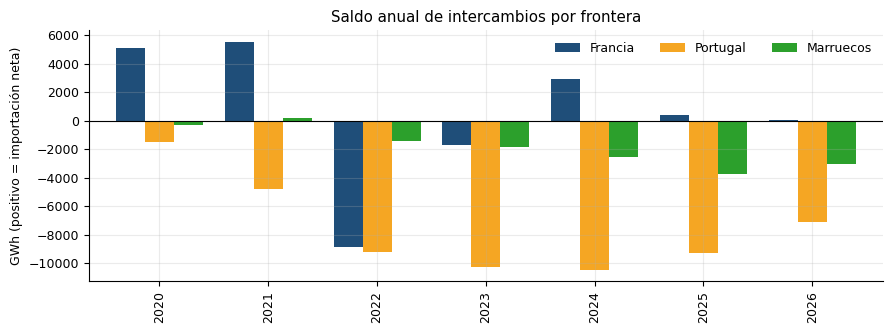

El paso de importador a exportador neto indica que el excedente renovable ya no
cabe en el sistema peninsular y sale por la interconexión.


In [87]:
FRONTERAS = {"Francia": cm.pick(df, "load_inter_ree_netflow_fr"),
             "Portugal": cm.pick(df, "load_inter_ree_netflow_pt"),
             "Marruecos": cm.pick(df, "load_inter_ree_netflow_ma")}
FRONTERAS = {k: v for k, v in FRONTERAS.items() if v}
if FRONTERAS:
    inter = pd.DataFrame({k: df.groupby("anio")[v].sum() / 1000
                          for k, v in FRONTERAS.items()})
    inter["saldo total"] = inter.sum(axis=1)
    display(inter.round(0))
    ax = inter.drop(columns="saldo total").plot(kind="bar", figsize=(9, 3.4), width=0.8)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("GWh (positivo = importación neta)"); ax.set_xlabel("")
    ax.set_title("Saldo anual de intercambios por frontera")
    ax.legend(frameon=False, ncol=3); plt.tight_layout(); plt.show()
    print("El paso de importador a exportador neto indica que el excedente renovable ya no")
    print("cabe en el sistema peninsular y sale por la interconexión.")

### El saldo dentro de su banda de capacidad

La capacidad comercial máxima en cada sentido varía hora a hora según el estado de la red, y el
saldo real se mueve dentro de esa banda. Cuando la toca, la interconexión está **saturada** y los
precios a uno y otro lado pueden separarse: es el mecanismo que el apartado 6.12 mide en euros.

Se representa un año completo para que la estructura horaria y estacional resulte visible.

Año representado: 2025


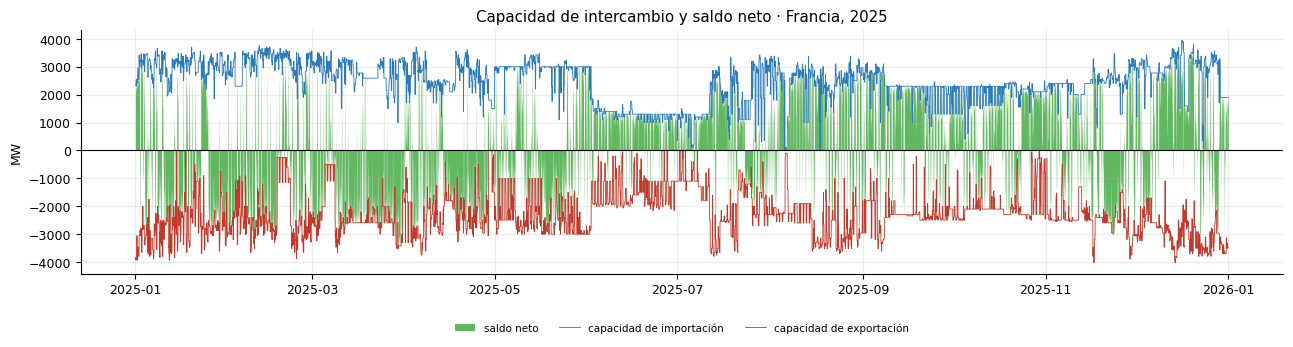

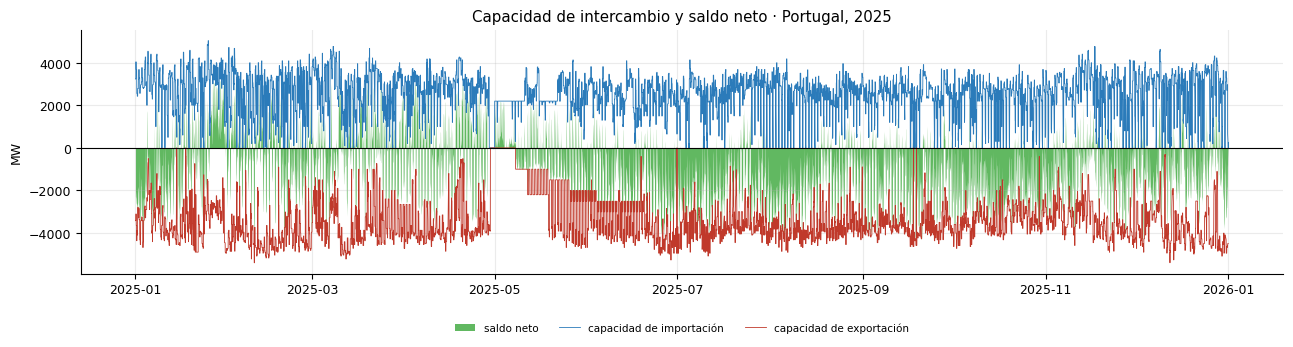

La banda no es constante: la capacidad se reduce por mantenimientos y por el estado de
la red. Un saldo pegado a la banda durante horas seguidas es congestión sostenida, y es
cuando el precio español deja de seguir al de sus vecinos.


In [88]:
anios_llenos = [a for a in sorted(df["anio"].unique()) if a in completos]
ANIO_MUESTRA = anios_llenos[-1] if anios_llenos else df["anio"].max()
print(f"Año representado: {ANIO_MUESTRA}")

PARES_BANDA = [("Francia", cm.pick(df, "load_inter_ree_netflow_fr"),
                cm.pick(df, "load_inter_ree_ntc_impfr"), cm.pick(df, "load_inter_ree_ntc_expfr")),
               ("Portugal", cm.pick(df, "load_inter_ree_netflow_pt"),
                cm.pick(df, "load_inter_ree_ntc_imppt"), cm.pick(df, "load_inter_ree_ntc_exppt"))]

for pais, flujo, imp, exp in PARES_BANDA:
    if not (flujo and imp):
        continue
    d_ = df[df["anio"] == ANIO_MUESTRA][["ts_local", flujo, imp] + ([exp] if exp else [])]
    d_ = d_.dropna(subset=[flujo])
    fig, ax = plt.subplots(figsize=(13, 3.6))
    ax.fill_between(d_["ts_local"], d_[flujo], 0, color=PALETA["ok"], lw=0, alpha=0.75,
                    label="saldo neto")
    ax.plot(d_["ts_local"], d_[imp].abs(), color=PALETA["secundario"], lw=0.6,
            label="capacidad de importación")
    if exp:
        ax.plot(d_["ts_local"], -d_[exp].abs(), color=PALETA["alerta"], lw=0.6,
                label="capacidad de exportación")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("MW"); ax.set_xlabel("")
    ax.set_title(f"Capacidad de intercambio y saldo neto · {pais}, {ANIO_MUESTRA}")
    ax.legend(frameon=False, ncol=3, fontsize=7.5, loc="upper center",
              bbox_to_anchor=(0.5, -0.16))
    plt.tight_layout(); plt.show()

print("La banda no es constante: la capacidad se reduce por mantenimientos y por el estado de")
print("la red. Un saldo pegado a la banda durante horas seguidas es congestión sostenida, y es")
print("cuando el precio español deja de seguir al de sus vecinos.")

### El uso de la capacidad de intercambio

El saldo neto dice cuánta energía cruza; no dice si podría cruzar más. Esa pregunta la responde
el grado de utilización de la capacidad comercial disponible, y es la que enlaza con el apartado
siguiente: **la interconexión sólo desacopla los precios cuando se satura**.

In [89]:
PARES_NTC = [("Francia", cm.pick(df, "load_inter_ree_netflow_fr"),
              cm.pick(df, "load_inter_ree_ntc_impfr"), cm.pick(df, "load_inter_ree_ntc_expfr")),
             ("Portugal", cm.pick(df, "load_inter_ree_netflow_pt"),
              cm.pick(df, "load_inter_ree_ntc_imppt"), cm.pick(df, "load_inter_ree_ntc_exppt"))]

filas = []
for pais, flujo, imp, exp in PARES_NTC:
    if not (flujo and imp and exp):
        continue
    d = df[[flujo, imp, exp, "anio"]].dropna()
    # La capacidad relevante depende del sentido del flujo en cada hora.
    capacidad = np.where(d[flujo] >= 0, d[imp].abs(), d[exp].abs())
    uso = d[flujo].abs() / np.where(capacidad > 0, capacidad, np.nan)
    d = d.assign(uso=uso)
    filas.append(d.groupby("anio")["uso"].agg(
        uso_medio=lambda s_: s_.mean() * 100,
        horas_saturadas=lambda s_: (s_ > 0.95).mean() * 100).add_prefix(f"{pais} · "))
if filas:
    USO = pd.concat(filas, axis=1).round(1)
    display(USO)
    print("«horas_saturadas» es el porcentaje de horas en que el flujo supera el 95 % de la")
    print("capacidad disponible en su sentido. Es la magnitud que explica cuándo el precio")
    print("español puede separarse del de sus vecinos, y da contexto al apartado siguiente.")

,Francia · uso_medio,Francia · horas_saturadas,Portugal · uso_medio,Portugal · horas_saturadas
anio,,,,
2020,78.7,54.9,43.8,8.1
2021,78.5,40.8,36.8,3.0
2022,84.1,54.4,42.9,5.0
2023,80.5,41.9,50.6,10.5
2024,77.9,39.3,55.0,9.0
2025,73.4,30.9,50.6,10.6
2026,72.8,30.1,58.0,22.4


«horas_saturadas» es el porcentaje de horas en que el flujo supera el 95 % de la
capacidad disponible en su sentido. Es la magnitud que explica cuándo el precio
español puede separarse del de sus vecinos, y da contexto al apartado siguiente.


## 6.12 · ¿Es el perímetro peninsular una sola zona de precio?

El proyecto asume que España y Portugal forman una zona única. En un mercado acoplado, si la
interconexión no se satura los precios convergen; cuando difieren, hay congestión.

Se trata de un supuesto que el presente análisis verifica en lugar de darlo por establecido.

In [90]:
UMBRAL_CONV = 0.01
for pais, col in [("Portugal", cm.pick(df, "spot_pt_omie", "spot_pt_entsoe")),
                  ("Francia", cm.pick(df, "spot_fr_entsoe"))]:
    if col is None:
        continue
    d = df[["anio", P, col]].dropna()
    dif = (d[P] - d[col])
    estado = np.select([dif.abs() <= UMBRAL_CONV, dif > UMBRAL_CONV],
                       ["acoplado", "ES más caro"], default="ES más barato")
    tabla = pd.crosstab(d["anio"], estado, normalize="index").mul(100).round(1)
    tabla["|dif| media"] = dif.abs().groupby(d["anio"]).mean().round(2)
    print(f"\nEspaña – {pais}:")
    display(tabla)

print("\nCon Portugal: la fracción de horas acopladas verifica —o matiza— el supuesto de")
print("zona única. Con Francia: cuanta más congestión, más independiente es el precio")
print("español, y menos aportaría el francés aunque estuviera disponible.")


España – Portugal:


col_0,ES más barato,ES más caro,acoplado,|dif| media
anio,,,,
2020,2.2,1.9,95.9,0.12
2021,1.3,1.3,97.4,0.20
2022,2.4,0.5,97.1,0.53
2023,4.6,0.7,94.7,1.34
2024,4.6,1.3,94.1,0.74
2025,9.5,0.9,89.5,1.29
2026,9.4,6.1,84.5,1.90



España – Francia:


col_0,ES más barato,ES más caro,acoplado,|dif| media
anio,,,,
2020,19.9,40.7,39.3,5.85
2021,22.9,42.3,34.8,20.23
2022,63.4,9.9,26.7,115.19
2023,38.7,28.5,32.8,26.32
2024,27.8,39.5,32.7,22.33
2025,28.3,35.4,36.3,20.33
2026,38.9,31.8,29.2,27.72



Con Portugal: la fracción de horas acopladas verifica —o matiza— el supuesto de
zona única. Con Francia: cuanta más congestión, más independiente es el precio
español, y menos aportaría el francés aunque estuviera disponible.


### La evolución mes a mes, que el agregado anual esconde

La media anual puede ocultar tanto un desacople creciente como episodios concentrados. La serie
mensual distingue ambas cosas y muestra si el supuesto de zona única peninsular se sostiene de
forma estable o se ha ido deteriorando —lo que importaría, porque el período reciente es el de
validación y prueba.

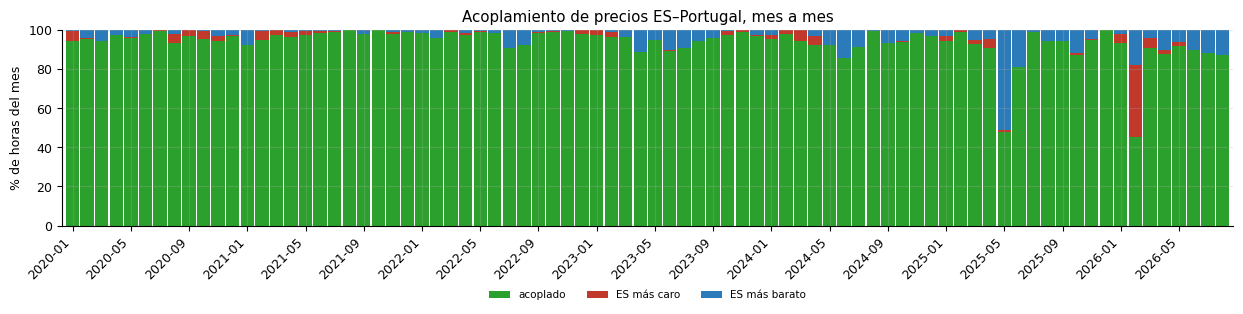

Portugal: acoplamiento medio 93.7 % · primeros 12 meses 95.9 % · últimos 12 meses 87.5 %


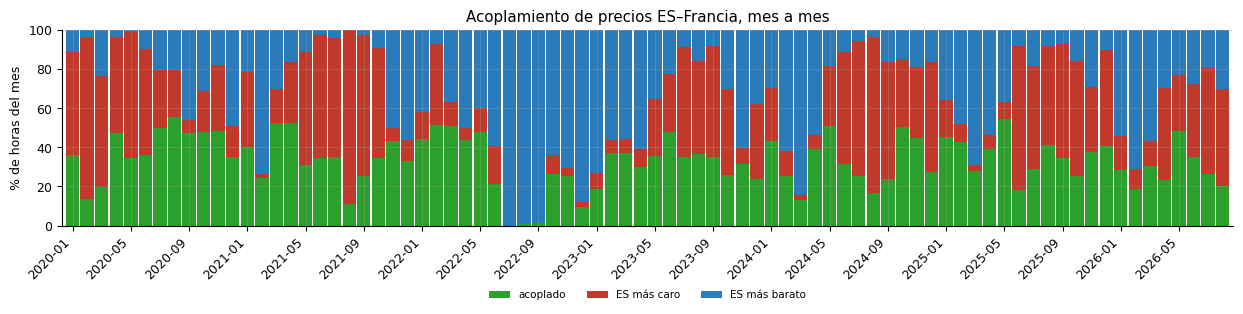

Francia: acoplamiento medio 33.3 % · primeros 12 meses 39.3 % · últimos 12 meses 30.8 %


In [91]:
for pais, col in [("Portugal", cm.pick(df, "spot_pt_omie", "spot_pt_entsoe")),
                  ("Francia", cm.pick(df, "spot_fr_entsoe"))]:
    if col is None:
        continue
    d_ = df[["mes_p", P, col]].dropna().copy()
    d_["dif"] = d_[P] - d_[col]
    d_["estado"] = np.select([d_["dif"].abs() <= UMBRAL_CONV, d_["dif"] > UMBRAL_CONV],
                             ["acoplado", "ES más caro"], default="ES más barato")
    mensual = pd.crosstab(d_["mes_p"], d_["estado"], normalize="index") * 100

    fig, ax = plt.subplots(figsize=(12.5, 3.4))
    orden_est = [c for c in ["acoplado", "ES más caro", "ES más barato"] if c in mensual.columns]
    mensual[orden_est].plot(kind="bar", stacked=True, ax=ax, width=0.92, legend=False,
                            color=[PALETA["ok"], PALETA["alerta"], PALETA["secundario"]][:len(orden_est)])
    paso = max(1, len(mensual) // 20)
    ax.set_xticks(range(0, len(mensual), paso),
                  [str(i) for i in mensual.index[::paso]], rotation=45, ha="right")
    ax.set_ylabel("% de horas del mes"); ax.set_xlabel(""); ax.set_ylim(0, 100)
    ax.set_title(f"Acoplamiento de precios ES–{pais}, mes a mes")
    ax.legend(orden_est, frameon=False, ncol=3, loc="upper center",
              bbox_to_anchor=(0.5, -0.28), fontsize=7.5)
    plt.tight_layout(); plt.show()

    if "acoplado" in mensual.columns:
        ac = mensual["acoplado"]
        print(f"{pais}: acoplamiento medio {ac.mean():.1f} % · "
              f"primeros 12 meses {ac.head(12).mean():.1f} % · "
              f"últimos 12 meses {ac.tail(12).mean():.1f} %")

In [92]:
col_pt = cm.pick(df, "spot_pt_omie", "spot_pt_entsoe")
if col_pt:
    d_ = df[["anio", P, col_pt]].dropna()
    ac_pt = (d_[P] - d_[col_pt]).abs().le(UMBRAL_CONV).groupby(d_["anio"]).mean() * 100
    print("Fracción de horas acopladas con Portugal, por año:")
    display(ac_pt.round(1).rename("% acoplado").to_frame().T)

    tendencia = ac_pt.iloc[-1] - ac_pt.iloc[0]
    if ac_pt.mean() > 85:
        print(f"\nEl acoplamiento medio del período es del {ac_pt.mean():.1f} %: tratar el")
        print("perímetro peninsular como una sola zona de precio queda justificado con datos,")
        print("y no como supuesto heredado.\n")
        print(f"Pero la serie no es plana: pasa del {ac_pt.iloc[0]:.1f} % en {ac_pt.index[0]} al "
              f"{ac_pt.iloc[-1]:.1f} % en {ac_pt.index[-1]} ({tendencia:+.1f} puntos).")
        if tendencia < -3:
            print("El desacople CRECE, y lo hace en el tramo que sirve de validación y prueba.")
            print("El supuesto se sostiene hoy, pero se está debilitando, de modo que conviene")
            print("declararlo con su fecha y vigilar el diferencial con Portugal en lugar de")
            print("darlo por permanente.")
        REG.anotar("J.1", f"España y Portugal comparten precio el {ac_pt.mean():.0f} % de las horas",
                   "confirmado con reserva" if tendencia < -3 else "confirmado",
                   f"El supuesto de zona única peninsular queda verificado con evidencia propia. "
                   f"Reserva: el acoplamiento cae {abs(tendencia):.1f} puntos entre el primer y "
                   "el último año, y el deterioro se concentra en el período de validación y "
                   "prueba. Vigilar el diferencial con Portugal en la evaluación.")
    else:
        print(f"\nEl acoplamiento medio es del {ac_pt.mean():.1f} %: el supuesto de zona única")
        print("es sólo aproximado y conviene declararlo como tal en la memoria.")
        REG.anotar("J.1", f"España y Portugal se desacoplan el {100 - ac_pt.mean():.0f} % de las horas",
                   "matizado",
                   "El supuesto de zona única peninsular es aproximado. Declararlo como "
                   "limitación, o incorporar el diferencial con Portugal como variable.")

Fracción de horas acopladas con Portugal, por año:


anio,2020,2021,2022,2023,2024,2025,2026
% acoplado,95.9,97.4,97.1,94.7,94.1,89.5,84.5



El acoplamiento medio del período es del 93.3 %: tratar el
perímetro peninsular como una sola zona de precio queda justificado con datos,
y no como supuesto heredado.

Pero la serie no es plana: pasa del 95.9 % en 2020 al 84.5 % en 2026 (-11.4 puntos).
El desacople CRECE, y lo hace en el tramo que sirve de validación y prueba.
El supuesto se sostiene hoy, pero se está debilitando, de modo que conviene
declararlo con su fecha y vigilar el diferencial con Portugal en lugar de
darlo por permanente.
  [J.1] confirmado con reserva: España y Portugal comparten precio el 93 % de las horas


**El ejemplo de manual del bloque 4.** Las correlaciones de la tabla anterior son altísimas
—Portugal por encima de 0,99, y varios mercados centroeuropeos por encima de 0,6— y **todas ellas
son inutilizables**. Los precios de todas las zonas se casan simultáneamente a las 12:00 y se
publican hacia las 12:45, de modo que el precio francés de D+1 no existe cuando hay que predecir
el español de D+1.

Es la ilustración más limpia del criterio que gobierna todo el trabajo: **una correlación fuerte
no autoriza una variable**. Lo único aprovechable de estas series es el precio del día D, ya
publicado, que el cuaderno de ingeniería incorpora como retardo.

## 6.13 · El orden de mérito, en una sola figura

La figura que cierra el bloque: el reparto porcentual del mix mes a mes, con el precio del
mercado diario y el del gas superpuestos. Es la representación visual del **orden de mérito**,
que es el mecanismo por el que todo lo anterior acaba convirtiéndose en un precio.

Su interés no es ilustrativo. El precio sigue al gas **mientras el ciclo combinado tenga peso en
el mix**, y se despega cuando la renovable lo desplaza fuera del margen. Si eso es cierto, ni el
gas ni la penetración renovable explican el precio por separado: hace falta que el efecto de uno
dependa del otro.

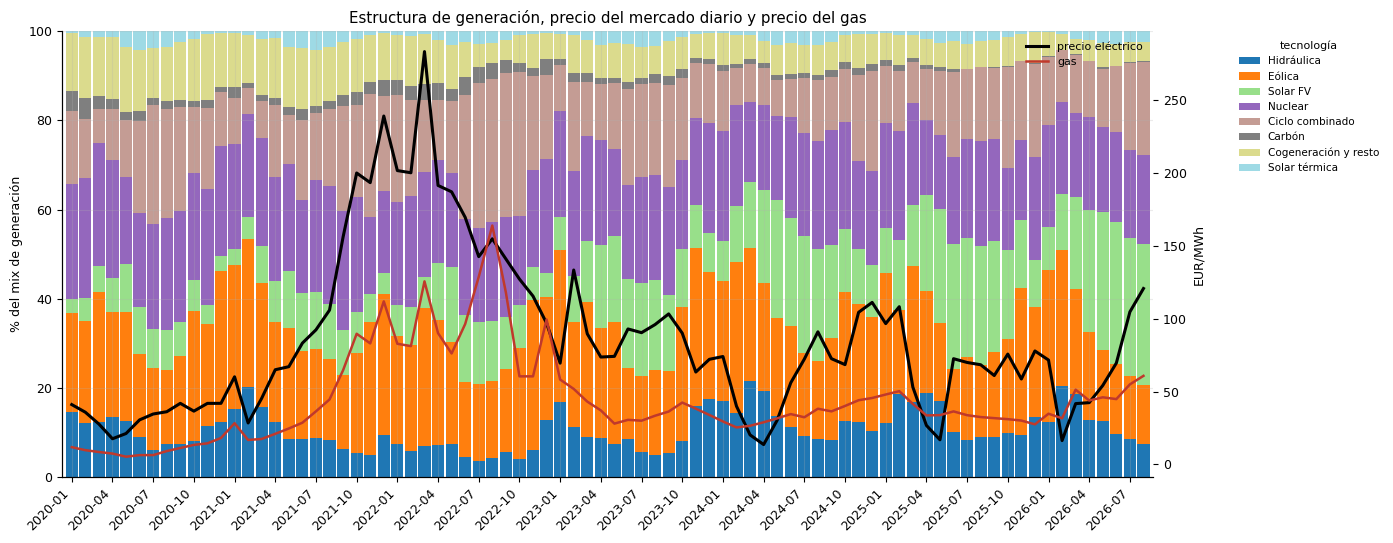

In [93]:
COLS_MIX = {k: v for k, v in {
    "Hidráulica": HID, "Eólica": EOL, "Solar FV": FV,
    "Nuclear": cm.pick(df, "esios_gen_ree_gnuclear_mw"),
    "Ciclo combinado": CCGT,
    "Carbón": cm.pick(df, "esios_gen_ree_gcoal_mw"),
    "Cogeneración y resto": OTHERTH,
    "Solar térmica": SOLTER,
}.items() if v}

mix_m = df.groupby("mes_p").agg(**{k: (v, "sum") for k, v in COLS_MIX.items()})
mix_m_pct = mix_m.div(mix_m.sum(axis=1), axis=0) * 100
precio_m = df.groupby("mes_p")[P].mean()
gas_m = df.groupby("mes_p")[GAS].mean() if GAS else None

fig, ax = plt.subplots(figsize=(14, 5.5))
mix_m_pct.plot(kind="bar", stacked=True, ax=ax, width=0.9, colormap="tab20", legend=False)
ax2 = ax.twinx()
ax2.plot(range(len(precio_m)), precio_m.values, color="black", lw=2.2, label="precio eléctrico")
if gas_m is not None:
    ax2.plot(range(len(gas_m)), gas_m.values, color=PALETA["alerta"], lw=1.8, label="gas")
ax2.set_ylabel("EUR/MWh"); ax2.grid(False)
ax2.legend(frameon=False, loc="upper right", fontsize=8)
ax.set_ylabel("% del mix de generación"); ax.set_xlabel(""); ax.set_ylim(0, 100)
paso = max(1, len(mix_m_pct) // 22)
ax.set_xticks(range(0, len(mix_m_pct), paso),
              [str(i) for i in mix_m_pct.index[::paso]], rotation=45, ha="right")
ax.set_title("Estructura de generación, precio del mercado diario y precio del gas")
ax.legend(bbox_to_anchor=(1.07, 1), loc="upper left", frameon=False, fontsize=7.5,
          title="tecnología", title_fontsize=8)
plt.tight_layout(); plt.show()

### La prueba, y el factor de confusión que la echa abajo a la primera

La lectura visual sugiere la relación; el contraste la establece. Se parten los meses en dos
mitades según el peso del ciclo combinado en el mix y se mide, **dentro de cada mitad**, la
correlación entre el precio eléctrico y el del gas.

Sobre el histórico completo el resultado sale **al revés de lo previsto**, y merece la pena
detenerse en por qué: es un caso de manual de variable de confusión, y el propio cuaderno ya
tenía la pista.

In [94]:
def test_acoplamiento(sub_precio, sub_gas, sub_ccgt, etq):
    corte_ = sub_ccgt.median()
    a_, b_ = sub_ccgt > corte_, sub_ccgt <= corte_
    ra, rb = corr_segura(sub_precio[a_], sub_gas[a_]), corr_segura(sub_precio[b_], sub_gas[b_])
    return {"ámbito": etq, "meses": len(sub_ccgt),
            "r con CCGT alto": ra, "r con CCGT bajo": rb, "diferencia": ra - rb}

ccgt_pct = mix_m_pct["Ciclo combinado"]
res_todo = test_acoplamiento(precio_m, gas_m, ccgt_pct, "todo el histórico")
print(f"Correlación precio-gas con el CCGT por encima de la mediana: "
      f"{res_todo['r con CCGT alto']:+.4f}")
print(f"Correlación precio-gas con el CCGT por debajo de la mediana: "
      f"{res_todo['r con CCGT bajo']:+.4f}")
print(f"Diferencia: {res_todo['diferencia']:+.4f}")
print("\nSale al revés de lo previsto. Antes de dar la hipótesis por falsa conviene mirar QUÉ")
print("meses son los de mucho ciclo combinado.")

Correlación precio-gas con el CCGT por encima de la mediana: +0.8085
Correlación precio-gas con el CCGT por debajo de la mediana: +0.7371
Diferencia: +0.0714

Sale al revés de lo previsto. Antes de dar la hipótesis por falsa conviene mirar QUÉ
meses son los de mucho ciclo combinado.


In [95]:
# Los meses de mayor peso termico, repartidos por regimen: ahi esta la explicacion.
reg_mes = df.groupby("mes_p")["regimen"].agg(lambda s_: s_.mode().iat[0])
alto = ccgt_pct > ccgt_pct.median()
reparto_reg = pd.crosstab(alto.map({True: "CCGT alto", False: "CCGT bajo"}),
                          reg_mes.reindex(ccgt_pct.index))
display(reparto_reg)

pct_exc = (reparto_reg.loc["CCGT alto"].get("excepción ibérica", 0)
           / reparto_reg.loc["CCGT alto"].sum() * 100)
print(f"El {pct_exc:.0f} % de los meses de mucho ciclo combinado cae bajo la excepción ibérica.")
print("\nY la excepción ibérica es EXACTAMENTE un tope al precio del gas: por construcción")
print("desacopla las dos series, según estableció el apartado 3.5. De modo que los meses de")
print("más térmica son también los meses en que el vínculo con el gas estaba intervenido.")
print("La confusión no es sutil: es el mecanismo regulatorio metido dentro de la prueba.")

regimen,excepción ibérica,normal
Ciclo combinado,,
CCGT alto,13,27
CCGT bajo,6,34


El 32 % de los meses de mucho ciclo combinado cae bajo la excepción ibérica.

Y la excepción ibérica es EXACTAMENTE un tope al precio del gas: por construcción
desacopla las dos series, según estableció el apartado 3.5. De modo que los meses de
más térmica son también los meses en que el vínculo con el gas estaba intervenido.
La confusión no es sutil: es el mecanismo regulatorio metido dentro de la prueba.


Retirado el período intervenido, la misma prueba sobre el mecanismo de mercado ordinario:

,meses,r con CCGT alto,r con CCGT bajo,diferencia
ámbito,,,,
todo el histórico,80,0.8085,0.7371,0.0714
sólo régimen normal,61,0.9862,0.7611,0.2252


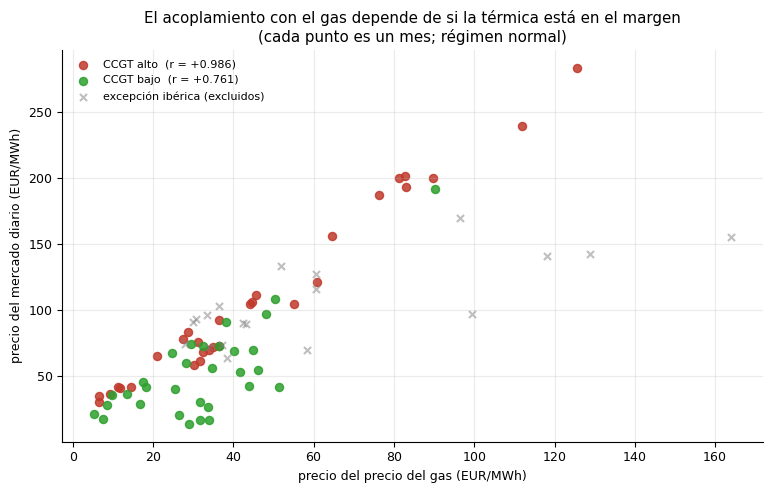

En régimen normal la diferencia es +0.2252, frente a +0.0714 sobre el histórico completo.

Ahora sí: con la térmica en el margen el precio sigue al gas casi perfectamente
(+0.986); cuando la renovable la desplaza, el vínculo
se afloja (+0.761).
  [P.13] confirmado: El acoplamiento del precio al gas depende del peso del ciclo combinado


In [96]:
mes_normal = reg_mes.reindex(ccgt_pct.index) == "normal"
res_norm = test_acoplamiento(precio_m[mes_normal], gas_m[mes_normal], ccgt_pct[mes_normal],
                             "sólo régimen normal")
display(pd.DataFrame([res_todo, res_norm]).set_index("ámbito").round(4))

fig, ax = plt.subplots(figsize=(7.8, 5))
cc_n = ccgt_pct[mes_normal]
a_n, b_n = cc_n > cc_n.median(), cc_n <= cc_n.median()
ax.scatter(gas_m[mes_normal][a_n], precio_m[mes_normal][a_n], s=34, alpha=0.85,
           color=PALETA["alerta"], label=f"CCGT alto  (r = {res_norm['r con CCGT alto']:+.3f})")
ax.scatter(gas_m[mes_normal][b_n], precio_m[mes_normal][b_n], s=34, alpha=0.85,
           color=PALETA["ok"], label=f"CCGT bajo  (r = {res_norm['r con CCGT bajo']:+.3f})")
ax.scatter(gas_m[~mes_normal], precio_m[~mes_normal], s=26, alpha=0.5, marker="x",
           color=PALETA["neutro"], label="excepción ibérica (excluidos)")
ax.set_xlabel("precio del precio del gas (EUR/MWh)")
ax.set_ylabel("precio del mercado diario (EUR/MWh)")
ax.set_title("El acoplamiento con el gas depende de si la térmica está en el margen\n"
             "(cada punto es un mes; régimen normal)")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

d_norm = res_norm["diferencia"]
print(f"En régimen normal la diferencia es {d_norm:+.4f}, frente a "
      f"{res_todo['diferencia']:+.4f} sobre el histórico completo.")

if d_norm > 0.15:
    print("\nAhora sí: con la térmica en el margen el precio sigue al gas casi perfectamente")
    print(f"({res_norm['r con CCGT alto']:+.3f}); cuando la renovable la desplaza, el vínculo")
    print(f"se afloja ({res_norm['r con CCGT bajo']:+.3f}).")
    REG.anotar("P.13", "El acoplamiento del precio al gas depende del peso del ciclo combinado",
               "confirmado",
               f"En régimen normal, la correlación precio-gas pasa de "
               f"{res_norm['r con CCGT bajo']:+.3f} en los meses de poca térmica a "
               f"{res_norm['r con CCGT alto']:+.3f} en los de mucha. Sobre el histórico completo "
               "la prueba sale invertida porque los meses de más térmica coinciden con la "
               "excepción ibérica, que topaba el gas. Junto con P.10 sostiene que el gas debe "
               "entrar interactuado con la cobertura renovable, no como término aislado.")
else:
    print("\nTampoco en régimen normal se sostiene la hipótesis.")

**Lo que este apartado enseña además del resultado.** La primera versión de la prueba daba una
respuesta clara y equivocada, y no por un error de cálculo: la variable que partía la muestra
—el peso de la térmica— estaba correlacionada con el período en que el gas estuvo intervenido.
Un factor de confusión no se detecta mirando el coeficiente, sino preguntándose **qué
observaciones caen a cada lado del corte**.

Es la misma disciplina que el apartado 6.4 aplicó al controlar por mes del calendario y que el
8.3 aplica al controlar por año. Aquí el control es por régimen, y estaba disponible desde el
apartado 3.5.

**Los dos hallazgos sobre el gas se apoyan mutuamente.** El apartado 3.6 midió que la asociación
con el gas crece con el **nivel de precio**, y éste que crece con el **peso de la térmica en el
mix**. Son la misma cosa vista desde dos ángulos —la tecnología marginal— y juntos dicen algo más
preciso que cualquiera por separado: el gas no es un driver del precio, es el driver *condicionado
a que la térmica marque*.

De ahí la variable de interacción que el cuaderno de ingeniería construye en su apartado 4.7, y
la razón de que el coste del ciclo combinado se derive combinando gas y CO2 en lugar de entregar
ambas series sueltas al modelo.

---
# 7 · El problema en términos económicos

El objetivo último no es predecir el precio sino operar un sistema de almacenamiento. Y para una
batería la decisión no es «¿cuánto valdrá el MWh?» sino **«¿es esta hora de cargar o de
descargar?»**.

Planteado así, el análisis proporciona una **referencia económica** que la evaluación estadística
no da: cuánto arbitraje deja sobre la mesa una regla trivial, y cuánto cuesta cada tipo de error.

La clasificación de horas se calcula aquí **para describir el problema**. Su versión definitiva
—la columna que se persiste como segundo objetivo del modelado— se construye en el cuaderno de
ingeniería, apartado 5, con esta misma función del módulo compartido.

In [97]:
cl = clasificar_horas(df, P, K_HORAS)
medias = cl.groupby("clase")[P].mean()

print(f"Clasificación por rango dentro del día, con K = {K_HORAS} horas de carga y descarga.")
print("\nPrecio medio por clase de hora (EUR/MWh):")
display(medias.round(2).rename("EUR/MWh").to_frame().T)
display(cl["clase"].value_counts(normalize=True).mul(100).round(1)
        .rename("% de horas").to_frame().T)

spread = cl.groupby("dia").apply(
    lambda g: g.nlargest(K_HORAS, P)[P].mean() - g.nsmallest(K_HORAS, P)[P].mean(),
    include_groups=False)
print(f"\nDiferencial medio entre las {K_HORAS} horas caras y las {K_HORAS} baratas: "
      f"{spread.mean():,.2f} EUR/MWh")

Clasificación por rango dentro del día, con K = 4 horas de carga y descarga.

Precio medio por clase de hora (EUR/MWh):


clase,barata,cara,intermedia
EUR/MWh,56.59,117.75,85.14


clase,intermedia,barata,cara
% de horas,66.7,16.7,16.7



Diferencial medio entre las 4 horas caras y las 4 baratas: 61.16 EUR/MWh


## 7.1 · ¿Cuándo caen las horas caras y las baratas?

Antes de buscar qué variables las distinguen conviene una pregunta más básica: **¿ocurren siempre
a la misma hora?** Si así fuera, el problema estaría resuelto con una regla fija de calendario y
no haría falta modelo alguno.

La respuesta tiene dos partes, y la segunda es la que decide. Primero, cuánto se concentran las
horas caras y baratas en determinadas horas del día. Y después, si esa concentración **se mantiene
a lo largo de los años** o se desplaza: una regla horaria fija que envejece mal es precisamente el
argumento para un modelo, y para ponderar los años recientes.

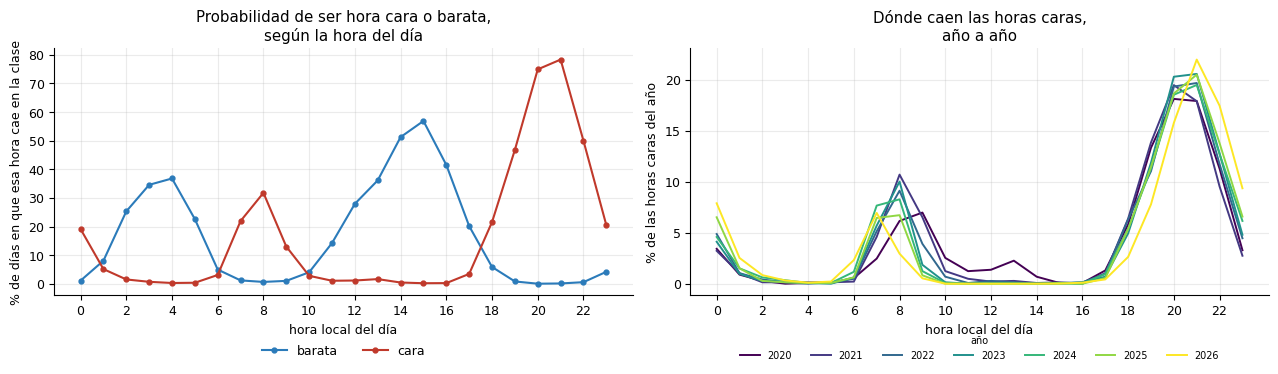

In [98]:
tab_hora = pd.crosstab(cl["hora"], cl["clase"], normalize="index").mul(100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(tab_hora.index, tab_hora["barata"], marker="o", ms=3.5, lw=1.5,
             color=PALETA["secundario"], label="barata")
axes[0].plot(tab_hora.index, tab_hora["cara"], marker="o", ms=3.5, lw=1.5,
             color=PALETA["alerta"], label="cara")
axes[0].set_xlabel("hora local del día")
axes[0].set_ylabel("% de días en que esa hora cae en la clase")
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_title("Probabilidad de ser hora cara o barata,\nsegún la hora del día")
axes[0].legend(frameon=False, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.30))

caras_anio = cl[cl["clase"] == "cara"].pivot_table(index="hora", columns="anio",
                                                   values="es_cara", aggfunc="size").fillna(0)
reparto = caras_anio / caras_anio.sum() * 100
cmap = plt.get_cmap("viridis")
for i, a_ in enumerate(reparto.columns):
    axes[1].plot(reparto.index, reparto[a_], lw=1.4,
                 color=cmap(i / max(len(reparto.columns) - 1, 1)), label=str(a_))
axes[1].set_xlabel("hora local del día")
axes[1].set_ylabel("% de las horas caras del año")
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_title("Dónde caen las horas caras,\naño a año")
axes[1].legend(title="año", frameon=False, fontsize=7, ncol=len(reparto.columns),
               title_fontsize=7, loc="lower center", bbox_to_anchor=(0.5, -0.30))
plt.tight_layout(); plt.show()

In [99]:
# Cuanto se desplaza el reparto de horas caras entre el primer y el ultimo ano completo.
anios_cl = list(reparto.columns)
hora_pico_ini = reparto[anios_cl[0]].idxmax()
hora_pico_fin = reparto[anios_cl[-1]].idxmax()

print("Hora en que se concentran más horas caras, por año:")
display(reparto.idxmax().rename("hora del máximo").to_frame().T)

print(f"\nSe desplaza de las {hora_pico_ini}:00 en {anios_cl[0]} a las {hora_pico_fin}:00 "
      f"en {anios_cl[-1]}.")

# Distancia entre los repartos del primer y el ultimo ano: 0 = identicos, 100 = disjuntos.
solape = np.minimum(reparto[anios_cl[0]], reparto[anios_cl[-1]]).sum()
print(f"Solapamiento entre el reparto del primer y el último año: {solape:.1f} %")
print(f"Es decir, el {100 - solape:.1f} % de las horas caras ha cambiado de franja horaria.\n")

concentracion = tab_hora["cara"].max()
print(f"La hora más propensa a ser cara lo es en el {concentracion:.1f} % de los días,")
print("lejos del 100 % que haría innecesario un modelo.")

REG.anotar("P.12", "Las horas caras no ocurren siempre a la misma hora, y la franja se desplaza",
           "confirmado",
           f"La hora más propensa lo es sólo el {concentracion:.0f} % de los días, y el reparto "
           f"horario de las horas caras se desplaza de las {hora_pico_ini}:00 a las "
           f"{hora_pico_fin}:00 entre el primer y el último año. Una regla horaria fija envejece: "
           "es el argumento para un modelo y para ponderar los años recientes.")

Hora en que se concentran más horas caras, por año:


anio,2020,2021,2022,2023,2024,2025,2026
hora del máximo,20,20,21,21,21,21,21



Se desplaza de las 20:00 en 2020 a las 21:00 en 2026.
Solapamiento entre el reparto del primer y el último año: 70.3 %
Es decir, el 29.7 % de las horas caras ha cambiado de franja horaria.

La hora más propensa a ser cara lo es en el 78.3 % de los días,
lejos del 100 % que haría innecesario un modelo.
  [P.12] confirmado: Las horas caras no ocurren siempre a la misma hora, y la franja se desplaza


## 7.2 · Qué driver distingue una hora cara de una barata

Planteada la operación como una clasificación, la pregunta sobre las variables explicativas
cambia de forma: ya no interesa cuánto se mueve el precio con el driver, sino **cuánto separa el
driver las horas caras de las baratas**.

Se emplean dos medidas complementarias. La *d* de Cohen expresa la distancia entre las medias de
ambos grupos en desviaciones típicas, de modo que es comparable entre variables de escalas
distintas. El área bajo la curva ROC mide la separación **sin fijar ningún umbral**: vale 0,5 si
el driver no discrimina y 1 si lo hace perfectamente, y por ello es la métrica adecuada para
comparar variables que se distribuyen de formas muy diferentes.

In [100]:
from sklearn.metrics import roc_auc_score, roc_curve

CL = cl.merge(df[["dia", "hora"] + [c for c, _ in DRIVERS.values()]],
              on=["dia", "hora"], how="left")

filas = []
for k, (c, f) in DRIVERS.items():
    a = CL.loc[CL["clase"] == "cara", c].dropna()
    b = CL.loc[CL["clase"] == "barata", c].dropna()
    if len(a) < 100 or len(b) < 100:
        continue
    s_ = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    d_cohen = (a.mean() - b.mean()) / s_ if s_ else np.nan
    m = CL[c].notna()
    auc = roc_auc_score(CL.loc[m, "es_cara"], CL.loc[m, c])
    filas.append({"driver": k, "disponibilidad": f, "d de Cohen": d_cohen,
                  "AUC": auc, "AUC ajustado": max(auc, 1 - auc),
                  "sentido": "valor alto = hora cara" if auc >= 0.5 else "valor bajo = hora cara"})
B = pd.DataFrame(filas).set_index("driver").sort_values("AUC ajustado", ascending=False)
display(B.round(4))

,disponibilidad,d de Cohen,AUC,AUC ajustado,sentido
driver,,,,,
hidráulica,CON FUGA,2.1972,0.8373,0.8373,valor alto = hora cara
demanda prevista,SIN FUGA,0.9810,0.7078,0.7078,valor alto = hora cara
demanda real,CON FUGA,0.9737,0.7076,0.7076,valor alto = hora cara
ciclo combinado,CON FUGA,1.0068,0.6843,0.6843,valor alto = hora cara
solar prevista,SIN FUGA,-1.3967,0.3364,0.6636,valor bajo = hora cara
solar FV real,CON FUGA,-1.4528,0.3549,0.6451,valor bajo = hora cara
eólica real,CON FUGA,0.1008,0.5207,0.5207,valor alto = hora cara
eólica prevista,SIN FUGA,-0.0563,0.5107,0.5107,valor alto = hora cara
temperatura,CON FUGA,-0.1700,0.5097,0.5097,valor alto = hora cara


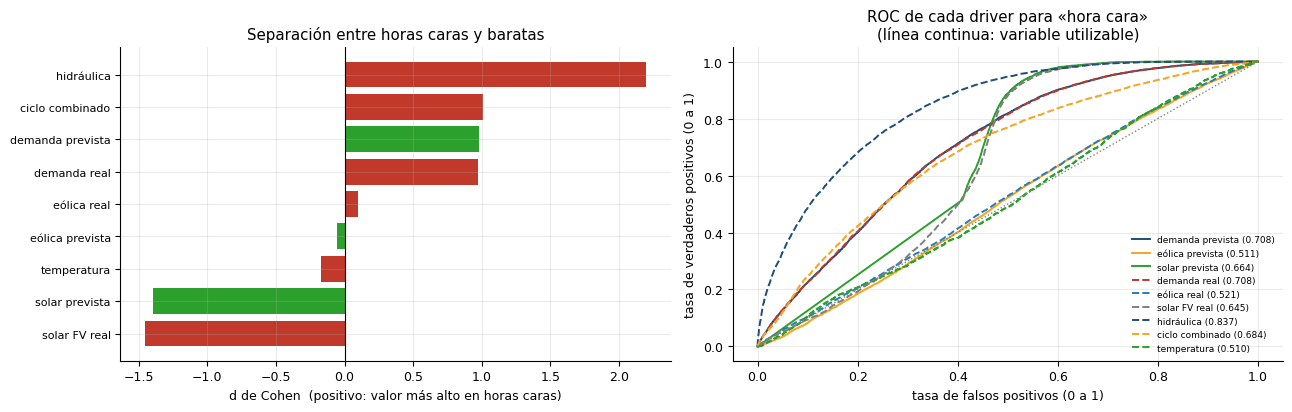

Mejor separador entre las variables utilizables: demanda prevista (AUC 0.708)
Mejor separador en términos absolutos:          hidráulica (AUC 0.837)

El contraste entre las previsiones de generación solar y eólica resulta ilustrativo: la
generación eólica desplaza el nivel general del precio, pero carece del perfil horario
marcado que caracteriza a la fotovoltaica, y es ese perfil el que determina qué horas
concretas de la jornada resultan más costosas.


In [101]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

Bs = B.sort_values("d de Cohen")
axes[0].barh(Bs.index, Bs["d de Cohen"],
             color=[COLOR_FUGA.get(f, PALETA["neutro"]) for f in Bs["disponibilidad"]])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("d de Cohen  (positivo: valor más alto en horas caras)")
axes[0].set_title("Separación entre horas caras y baratas")
axes[0].tick_params(axis="y", labelsize=8)

for k, (c, f) in DRIVERS.items():
    if k not in B.index:
        continue
    m = CL[c].notna()
    score = CL.loc[m, c] if B.loc[k, "AUC"] >= 0.5 else -CL.loc[m, c]
    fpr, tpr, _ = roc_curve(CL.loc[m, "es_cara"], score)
    estilo = "-" if f in cm.ADMISIBLES else "--"
    axes[1].plot(fpr, tpr, estilo, lw=1.4, label=f"{k} ({B.loc[k, 'AUC ajustado']:.3f})")
axes[1].plot([0, 1], [0, 1], color="grey", lw=1, ls=":")
axes[1].set_xlabel("tasa de falsos positivos (0 a 1)"); axes[1].set_ylabel("tasa de verdaderos positivos (0 a 1)")
axes[1].set_title("ROC de cada driver para «hora cara»\n(línea continua: variable utilizable)")
axes[1].legend(frameon=False, fontsize=6.5, loc="lower right")
plt.tight_layout(); plt.show()

mejor_util = B[B["disponibilidad"].isin(cm.ADMISIBLES)]["AUC ajustado"].idxmax()
print(f"Mejor separador entre las variables utilizables: {mejor_util} "
      f"(AUC {B.loc[mejor_util, 'AUC ajustado']:.3f})")
print(f"Mejor separador en términos absolutos:          {B['AUC ajustado'].idxmax()} "
      f"(AUC {B['AUC ajustado'].max():.3f})")
print("\nEl contraste entre las previsiones de generación solar y eólica resulta ilustrativo: la")
print("generación eólica desplaza el nivel general del precio, pero carece del perfil horario")
print("marcado que caracteriza a la fotovoltaica, y es ese perfil el que determina qué horas")
print("concretas de la jornada resultan más costosas.")

## 7.3 · El coste de equivocarse, en euros

No todos los errores cuestan lo mismo. Confundir una hora cara con una barata implica el
diferencial completo; confundirla con una intermedia, aproximadamente la mitad.

**Una métrica simétrica como el error absoluto medio no recoge esa asimetría.**

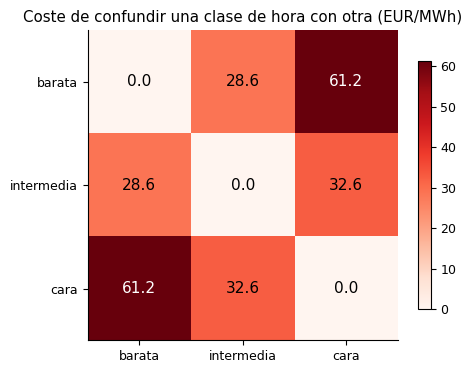

  [P.7] confirmado: El coste del error es asimétrico entre clases de hora


In [102]:
clases = ["barata", "intermedia", "cara"]
COSTE = pd.DataFrame([[abs(medias[a] - medias[b]) for b in clases] for a in clases],
                     index=[f"real {c}" for c in clases],
                     columns=[f"predicho {c}" for c in clases])
fig, ax = plt.subplots(figsize=(5, 3.8))
im = ax.imshow(COSTE.values, cmap="Reds")
ax.set_xticks(range(3), clases); ax.set_yticks(range(3), clases)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{COSTE.iloc[i, j]:.1f}", ha="center", va="center", fontsize=11,
                color="white" if COSTE.iloc[i, j] > COSTE.values.max() * 0.6 else "black")
ax.set_title("Coste de confundir una clase de hora con otra (EUR/MWh)")
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

REG.anotar("P.7", "El coste del error es asimétrico entre clases de hora", "confirmado",
           f"Confundir cara con barata cuesta {COSTE.iloc[2, 0]:.1f} EUR/MWh frente a "
           f"{COSTE.iloc[2, 1]:.1f} si se confunde con intermedia. Complementar las métricas "
           "estadísticas con una medida económica en la validación.")

## 7.4 · La referencia: cuánto arbitraje captura una regla trivial

Si una heurística sin modelo alguno ya captura buena parte del arbitraje posible, **el margen
restante es todo lo que un modelo puede aportar**, y la referencia frente a la que debe
evaluarse.

Regla fija — descargar en [19, 20, 21, 22], cargar en [4, 14, 15, 16]

Ingreso diario medio por MWh de batería:
  con previsión perfecta :   244.65 EUR
  con la regla fija      :   175.66 EUR  (71.8 % del techo)


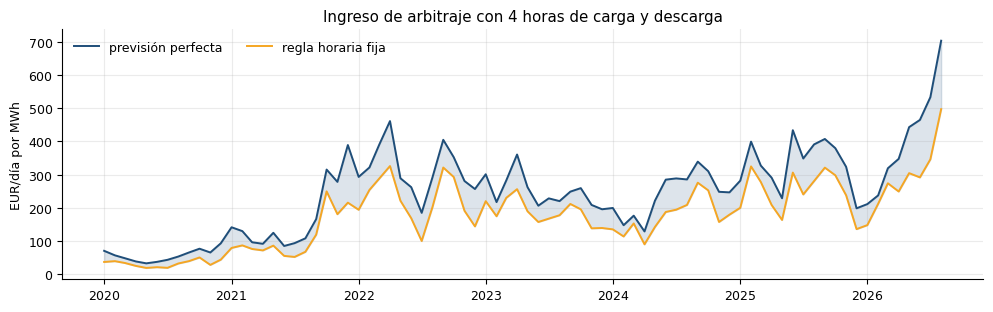


El 28.2 % restante delimita la aportación máxima de un modelo predictivo
sobre esta heurística, y constituye la referencia frente a la que debe evaluarse.

Salvedad metodológica: la regla se evalúa sobre el mismo período del que se derivan
sus horas de operación, por lo que incorpora sobreajuste por construcción. Su empleo
como referencia formal exige determinar dichas horas sobre el subconjunto de
entrenamiento y evaluarlas sobre el de validación — que es lo que hace el cuaderno
de ingeniería, una vez establecida la partición.


In [103]:
tab = pd.crosstab(cl["hora"], cl["clase"], normalize="index") * 100
mejores = tab["cara"].nlargest(K_HORAS).index.tolist()
peores = tab["barata"].nlargest(K_HORAS).index.tolist()
print(f"Regla fija — descargar en {sorted(mejores)}, cargar en {sorted(peores)}")

filas = []
for dia_v, g in cl.groupby("dia"):
    if len(g) < 20:
        continue
    perf = g.nlargest(K_HORAS, P)[P].sum() - g.nsmallest(K_HORAS, P)[P].sum()
    c_ = g[g["hora"].isin(peores)].head(K_HORAS)
    v_ = g[g["hora"].isin(mejores)].head(K_HORAS)
    if len(c_) < K_HORAS or len(v_) < K_HORAS:
        continue
    filas.append({"dia": dia_v, "perfecto": perf, "regla": v_[P].sum() - c_[P].sum()})
Eg = pd.DataFrame(filas).set_index("dia")
Eg.index = pd.to_datetime(Eg.index)

pct = Eg["regla"].sum() / Eg["perfecto"].sum() * 100
print("\nIngreso diario medio por MWh de batería:")
print(f"  con previsión perfecta : {Eg['perfecto'].mean():>8,.2f} EUR")
print(f"  con la regla fija      : {Eg['regla'].mean():>8,.2f} EUR  ({pct:.1f} % del techo)")

fig, ax = plt.subplots(figsize=(10, 3.2))
m_ = Eg.resample("MS").mean()
ax.plot(m_.index, m_["perfecto"], lw=1.4, color=PALETA["principal"], label="previsión perfecta")
ax.plot(m_.index, m_["regla"], lw=1.4, color=PALETA["acento"], label="regla horaria fija")
ax.fill_between(m_.index, m_["regla"], m_["perfecto"], alpha=0.15, color=PALETA["principal"])
ax.set_ylabel("EUR/día por MWh"); ax.set_xlabel("")
ax.set_title(f"Ingreso de arbitraje con {K_HORAS} horas de carga y descarga")
ax.legend(frameon=False, ncol=2); plt.tight_layout(); plt.show()

print(f"\nEl {100 - pct:.1f} % restante delimita la aportación máxima de un modelo predictivo")
print("sobre esta heurística, y constituye la referencia frente a la que debe evaluarse.")
print("\nSalvedad metodológica: la regla se evalúa sobre el mismo período del que se derivan")
print("sus horas de operación, por lo que incorpora sobreajuste por construcción. Su empleo")
print("como referencia formal exige determinar dichas horas sobre el subconjunto de")
print("entrenamiento y evaluarlas sobre el de validación — que es lo que hace el cuaderno")
print("de ingeniería, una vez establecida la partición.")

---
# 8 · La estructura del conjunto: ¿cuánta información distinta hay?

Los bloques anteriores han examinado las variables **una a una** frente al precio. Éste las mira
**entre sí**, para responder a una pregunta que ninguna correlación individual contesta: noventa
y siete columnas no son noventa y siete piezas de información, y conviene saber cuántas lo son
de verdad antes de construir una matriz de modelado.

Todo el bloque se calcula sobre el marco diario del apartado 4.1, por el motivo allí establecido.

## 8.1 · La matriz completa, y por qué no se lee tal cual

Una matriz de correlación de ochenta y dos columnas tiene 3.321 pares únicos. Representada en el
orden en que las columnas llegan del bronce **no es legible**, y conviene verlo antes de saltar
al resultado depurado: cada paso siguiente quita información a cambio de legibilidad, y el
intercambio forma parte del método.

Dos reducciones bastan. La primera **reordena** las columnas por similitud, de modo que las que
se parecen quedan contiguas y los bloques de redundancia aparecen solos como cuadrados en la
diagonal; no se pierde ni un dato, es la misma matriz permutada. La segunda **borra lo que está
por debajo de |r| = 0,7**, que es ruido de fondo ocupando la mayor parte de la imagen.

Matriz de 82×82 = 3,321 pares únicos


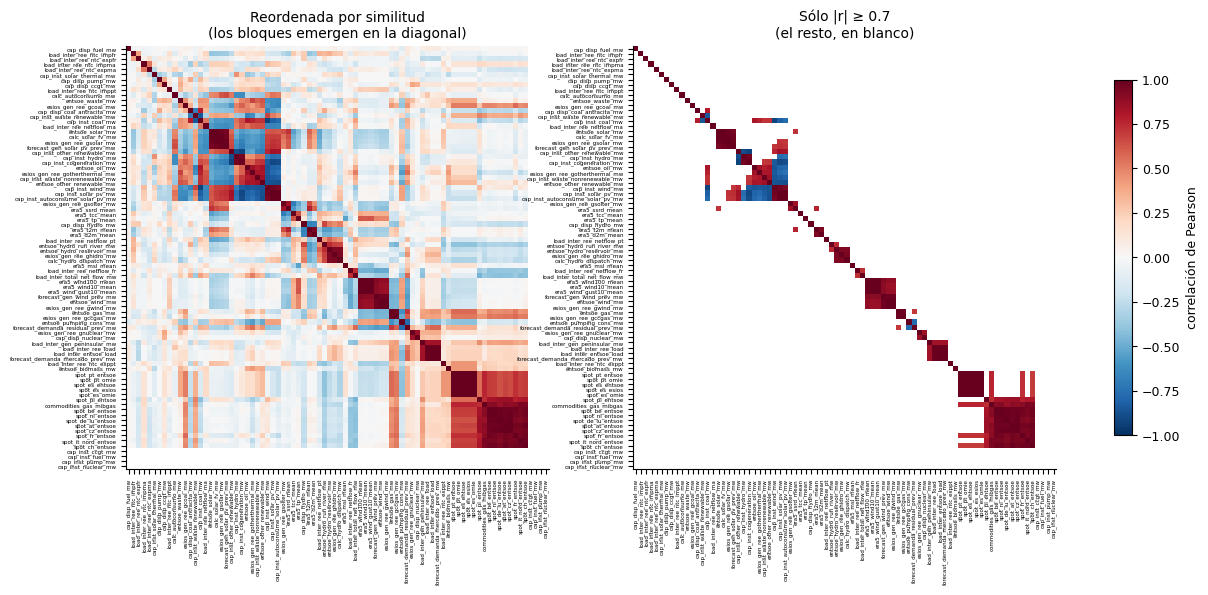

Pares por encima de 0.7: 156 de 3,321 (4.7 %).
El 95 % de la primera imagen era ruido de fondo sin significado.


In [104]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

cols_est = [c for c in DIA.columns
            if c not in ("dow", "mes", "anio") and DIA[c].notna().mean() > 0.90
            and DIA[c].std(skipna=True) > 0]
C_full = DIA[cols_est].corr()
print(f"Matriz de {C_full.shape[0]}×{C_full.shape[1]} = "
      f"{C_full.shape[0] * (C_full.shape[0] - 1) // 2:,} pares únicos")

# Reordenacion por similitud: el mismo enlace jerarquico que despues da los grupos.
D_ = 1 - C_full.abs().fillna(0)
np.fill_diagonal(D_.values, 0)
Z = linkage(squareform(D_.values, checks=False), method="average")
orden = dendrogram(Z, no_plot=True)["leaves"]
C_ord = C_full.iloc[orden, orden]

UMBRAL_VISUAL = 0.7
fig, axes = plt.subplots(1, 2, figsize=(15, 6.6))
for ax, datos, tit in [
        (axes[0], C_ord.values, "Reordenada por similitud\n(los bloques emergen en la diagonal)"),
        (axes[1], C_ord.where(C_ord.abs() >= UMBRAL_VISUAL).values,
         f"Sólo |r| ≥ {UMBRAL_VISUAL}\n(el resto, en blanco)")]:
    im = ax.imshow(datos, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(C_ord)), C_ord.columns, rotation=90, fontsize=4)
    ax.set_yticks(range(len(C_ord)), C_ord.columns, fontsize=4)
    ax.set_title(tit, fontsize=10); ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.7, label="correlación de Pearson")
plt.show()

n_fuertes = int((C_ord.abs() >= UMBRAL_VISUAL).sum().sum() - len(C_ord)) // 2
total_pares = len(C_ord) * (len(C_ord) - 1) // 2
print(f"Pares por encima de {UMBRAL_VISUAL}: {n_fuertes:,} de {total_pares:,} "
      f"({n_fuertes / total_pares * 100:.1f} %).")
print("El 95 % de la primera imagen era ruido de fondo sin significado.")

### De imagen a lista

Los mapas dicen **dónde** está la redundancia; para decidir hace falta saber **entre qué columnas
exactamente**, y eso sólo se lee en una lista ordenada. El histograma acompaña la lista para
situarla: dice cuánta redundancia hay en total y dónde caen los umbrales.

Pares con |r| ≥ 0.95: 50



,columna A,columna B,r
0,spot_es_esios,spot_es_omie,1.0000
1,spot_pt_entsoe,spot_pt_omie,1.0000
2,spot_es_esios,spot_es_entsoe,1.0000
3,spot_es_entsoe,spot_es_omie,1.0000
4,entsoe_wind_mw,esios_gen_ree_gwind_mw,0.9999
5,spot_es_entsoe,spot_pt_entsoe,0.9988
6,spot_es_omie,spot_pt_omie,0.9988
7,spot_es_esios,spot_pt_omie,0.9988
8,spot_es_esios,spot_pt_entsoe,0.9988
9,spot_es_entsoe,spot_pt_omie,0.9988


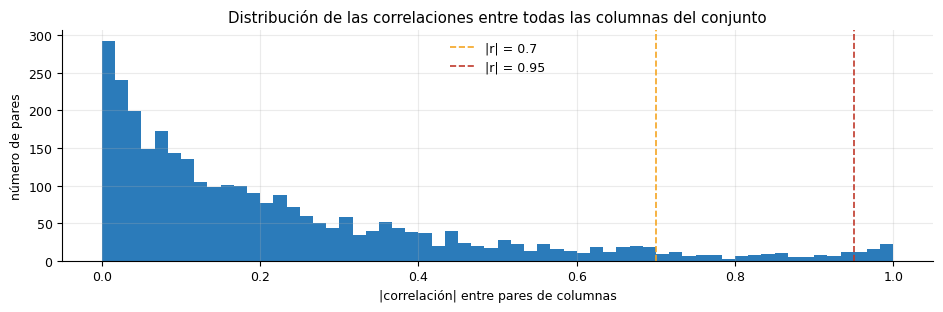

  |r| ≥ 0.7:   158 pares (  5.3 %)
  |r| ≥ 0.9:    74 pares (  2.5 %)
  |r| ≥ 0.95:    50 pares (  1.7 %)
  |r| ≥ 0.99:    18 pares (  0.6 %)


In [105]:
mask = np.triu(np.ones(C_full.shape, dtype=bool), k=1)
pares = (C_full.where(mask).stack().rename("r").reset_index()
         .rename(columns={"level_0": "columna A", "level_1": "columna B"}))
pares["|r|"] = pares["r"].abs()

UMBRAL_RED = 0.95
redundantes = pares[pares["|r|"] >= UMBRAL_RED].sort_values("|r|", ascending=False)
print(f"Pares con |r| ≥ {UMBRAL_RED}: {len(redundantes)}\n")
display(redundantes[["columna A", "columna B", "r"]].head(20).round(4).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9.5, 3.2))
ax.hist(pares["|r|"].dropna(), bins=60, color=PALETA["secundario"])
for u, col in [(0.7, PALETA["acento"]), (0.95, PALETA["alerta"])]:
    ax.axvline(u, color=col, ls="--", lw=1.2, label=f"|r| = {u}")
ax.set_xlabel("|correlación| entre pares de columnas")
ax.set_ylabel("número de pares")
ax.set_title("Distribución de las correlaciones entre todas las columnas del conjunto")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

for u in (0.7, 0.9, 0.95, 0.99):
    n_ = int((pares["|r|"] >= u).sum())
    print(f"  |r| ≥ {u}: {n_:>5,} pares ({n_ / len(pares) * 100:5.1f} %)")

## 8.2 · El mapa por familias

La matriz completa sí resulta legible **agregada por familia de origen**: en lugar de ochenta y
dos filas, una matriz de nueve por nueve con la correlación absoluta media entre cada par de
grupos. Dice de un vistazo qué bloques del bronce se solapan entre sí, que es la pregunta previa
a decidir qué tablas hacía falta traer.

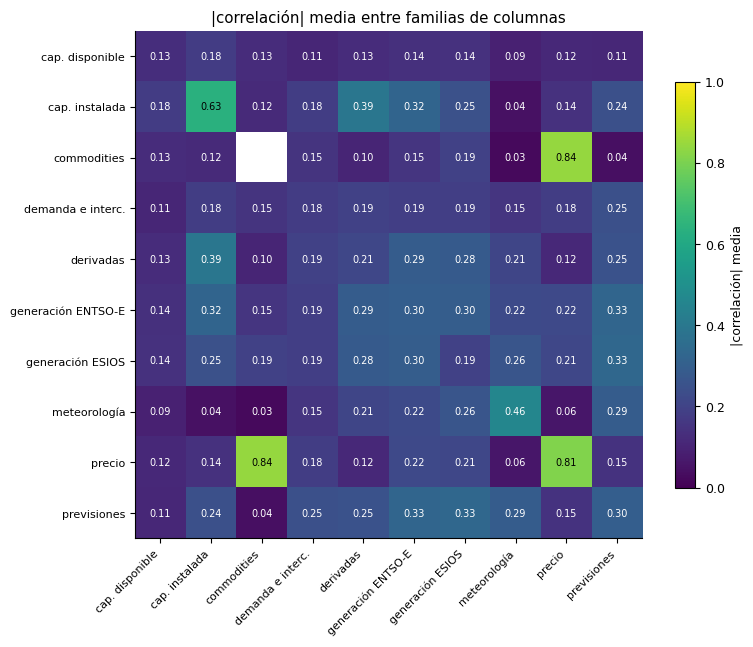

Redundancia INTERNA de cada familia (correlación media entre sus propias columnas):


,precio,cap. instalada,meteorología,previsiones,generación ENTSO-E,derivadas,generación ESIOS,demanda e interc.,cap. disponible
|r| media interna,0.809,0.634,0.46,0.301,0.3,0.214,0.195,0.179,0.132


Un valor alto en la diagonal significa que esa familia trae varias columnas que miden
prácticamente lo mismo, y que basta con una parte de ellas.


In [106]:
def familia_de(c):
    for p_, n_ in [("cap_inst_", "cap. instalada"), ("cap_disp_", "cap. disponible"),
                   ("esios_gen_", "generación ESIOS"), ("entsoe_", "generación ENTSO-E"),
                   ("load_inter_", "demanda e interc."), ("forecast_", "previsiones"),
                   ("commodities_", "commodities"), ("era5_", "meteorología"),
                   ("calc_", "derivadas"), ("spot_", "precio")]:
        if c.startswith(p_):
            return n_
    return "otras"

fam_col = pd.Series({c: familia_de(c) for c in cols_est})
grupos_fam = sorted(fam_col.unique())

MF = pd.DataFrame(index=grupos_fam, columns=grupos_fam, dtype=float)
for g1 in grupos_fam:
    for g2 in grupos_fam:
        c1, c2 = fam_col[fam_col == g1].index, fam_col[fam_col == g2].index
        sub_ = C_full.loc[c1, c2].abs()
        if g1 == g2:
            sub_ = sub_.where(np.triu(np.ones(sub_.shape, dtype=bool), k=1))
        MF.loc[g1, g2] = sub_.stack().mean()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(MF.values.astype(float), cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(grupos_fam)), grupos_fam, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(grupos_fam)), grupos_fam, fontsize=8)
for i in range(len(grupos_fam)):
    for j in range(len(grupos_fam)):
        v = MF.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if v < 0.6 else "black")
ax.set_title("|correlación| media entre familias de columnas")
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.8, label="|correlación| media")
plt.tight_layout(); plt.show()

diag = pd.Series({g: MF.loc[g, g] for g in grupos_fam}).dropna().sort_values(ascending=False)
print("Redundancia INTERNA de cada familia (correlación media entre sus propias columnas):")
display(diag.round(3).rename("|r| media interna").to_frame().T)
print("Un valor alto en la diagonal significa que esa familia trae varias columnas que miden")
print("prácticamente lo mismo, y que basta con una parte de ellas.")

## 8.3 · ¿Sobrevive la correlación dentro de cada año?

**La comprobación que el resto del bloque necesita para ser creíble.** El conjunto cubre seis
años y medio con tendencias muy fuertes —la fotovoltaica instalada se multiplica por seis, el
carbón se cierra, el autoconsumo aparece en 2025—, y dos series que crecen o caen a la vez
correlacionan **aunque no tengan relación alguna**.

El contraste consiste en recalcular cada correlación **dentro de cada año** y compararla con la
global. Si la global es alta y las anuales bajas, lo que se estaba midiendo era tendencia
compartida. Es el mismo control que el apartado 4.4 aplica a la relación con el precio, ahora
aplicado a las relaciones entre columnas, que son las que justifican descartar duplicados.

In [107]:
CAND_PARES = pares[pares["|r|"] >= 0.80].sort_values("|r|", ascending=False).head(30)

filas = []
for _, fila in CAND_PARES.iterrows():
    a_, b_ = fila["columna A"], fila["columna B"]
    por_anio = DIA.assign(anio=DIA.index.year).groupby("anio").apply(
        lambda g: corr_segura(g[a_], g[b_]) if g[[a_, b_]].dropna().shape[0] > 60 else np.nan,
        include_groups=False).dropna()
    if len(por_anio) < 3:
        continue
    filas.append({"columna A": a_, "columna B": b_, "r global": fila["r"],
                  "r anual media": por_anio.mean(), "r anual mínima": por_anio.min(),
                  "caída": abs(fila["r"]) - por_anio.abs().mean()})
EST = pd.DataFrame(filas).set_index(["columna A", "columna B"])

print("Ordenado por CAÍDA: arriba, los pares cuya correlación se desmorona dentro del año.")
display(EST.sort_values("caída", ascending=False).head(12).round(4))

Ordenado por CAÍDA: arriba, los pares cuya correlación se desmorona dentro del año.


r global  r anual media  r anual mínima   caída
columna A               columna B                                                                        
spot_nl_entsoe          spot_at_entsoe                      0.9758         0.9092          0.7970  0.0666
                        spot_cz_entsoe                      0.9769         0.9199          0.8710  0.0570
spot_de_lu_entsoe       spot_cz_entsoe                      0.9853         0.9303          0.8977  0.0551
spot_ch_entsoe          spot_at_entsoe                      0.9779         0.9289          0.8530  0.0490
spot_de_lu_entsoe       spot_be_entsoe                      0.9772         0.9403          0.9206  0.0369
cap_inst_solar_pv_mw    cap_inst_autoconsume_solar_pv_mw    0.9923         0.9573          0.7677  0.0350
spot_de_lu_entsoe       spot_nl_entsoe                      0.9815         0.9549          0.8923  0.0266
spot_at_entsoe          spot_cz_entsoe                      0.9886         0.9685          0.9440  0.0201
spot_be_entsoe          spot_nl_entsoe                      0.9915         0.9714          0.9557  0.0200
esios_gen_ree_gsolar_mw forecast_gen_solar_pv_prev_mw       0.9841         0.9731          0.9494  0.0110
spot_es_entsoe          spot_pt_omie                        0.9988         0.9966          0.9905  0.0022
spot_es_omie            spot_pt_omie                        0.9988         0.9966          0.9905  0.0022

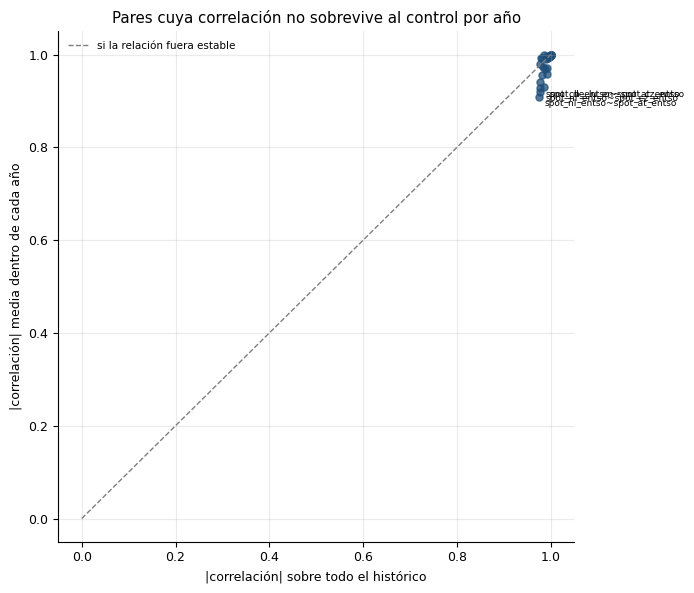

Pares cuya correlación cae más de 0,2 al controlar por año: 0 de 30
Ninguno: las correlaciones fuertes del conjunto son estables dentro del año y
reflejan relaciones reales, no tendencia compartida.


In [108]:
if len(EST):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(EST["r global"].abs(), EST["r anual media"].abs(), s=26, alpha=0.75,
               color=PALETA["principal"])
    ax.plot([0, 1], [0, 1], color=PALETA["neutro"], ls="--", lw=1,
            label="si la relación fuera estable")
    peor = EST.reindex(EST["caída"].sort_values(ascending=False).index).head(4)
    for (a_, b_), fila in peor.iterrows():
        ax.annotate(f"{a_[:13]}~{b_[:13]}",
                    (abs(fila["r global"]), abs(fila["r anual media"])),
                    fontsize=6.5, xytext=(4, -7), textcoords="offset points")
    ax.set_xlabel("|correlación| sobre todo el histórico")
    ax.set_ylabel("|correlación| media dentro de cada año")
    ax.set_title("Pares cuya correlación no sobrevive al control por año")
    ax.legend(frameon=False, fontsize=7.5)
    plt.tight_layout(); plt.show()

    espurias = EST[EST["caída"] > 0.2]
    print(f"Pares cuya correlación cae más de 0,2 al controlar por año: {len(espurias)} "
          f"de {len(EST)}")
    if len(espurias):
        for (a_, b_), fila in espurias.head(5).iterrows():
            print(f"  {a_[:32]:34s} ~ {b_[:32]:34s} "
                  f"{fila['r global']:+.3f} → {fila['r anual media']:+.3f}")
        REG.anotar("M.7", f"{len(espurias)} pares con correlación explicada por la tendencia",
                   "confirmado",
                   "Su asociación se desmorona al medirla dentro de cada año. Descartar una "
                   "columna por una correlación de este tipo sería un error: no miden lo mismo, "
                   "sólo crecieron a la vez. El agrupamiento del apartado 8.4 se lee con esta "
                   "salvedad.")
    else:
        print("Ninguno: las correlaciones fuertes del conjunto son estables dentro del año y")
        print("reflejan relaciones reales, no tendencia compartida.")

## 8.4 · Grupos de variables que miden lo mismo

En lugar de recorrer miles de pares, se agrupan las columnas por su similitud mediante
agrupamiento jerárquico sobre la distancia `1 − |r|`. Cortando el árbol a una altura declarada se
obtienen bloques dentro de los cuales todas las columnas se comportan como una sola variable.

De cada bloque basta con conservar una, y el criterio de elección no es estadístico sino
práctico: la de mejor cobertura, o la que una decisión de fuente ya tomada haya señalado.

**El agrupamiento propone; la decisión documentada dispone.** Que dos columnas caigan en el mismo
grupo no implica que sobre una: la eólica de ESIOS y la de ENTSO-E correlacionan 0,9996 y son
intercambiables, pero el gas de ENTSO-E y el ciclo combinado de ESIOS también correlacionan alto
y **no lo son**, según estableció el hallazgo D-02. Cuando existe una decisión de fuente tomada
con evidencia, esa manda sobre el resultado del agrupamiento.

In [109]:
# `Z` y `cols_est` vienen del apartado 8.1: es exactamente el mismo enlace jerárquico que
# reordenó la matriz, ahora cortado a una altura concreta para obtener los grupos.
UMBRAL_GRUPO = 0.10                     # 1 - |r| = 0,10  ->  |r| >= 0,90 dentro del grupo
etiquetas = fcluster(Z, t=UMBRAL_GRUPO, criterion="distance")
G = pd.DataFrame({"columna": cols_est, "grupo": etiquetas})
tam = G["grupo"].value_counts()
multi = tam[tam > 1].index

print(f"{len(cols_est)} columnas con cobertura suficiente → "
      f"{G['grupo'].nunique()} grupos independientes")
print(f"{len(multi)} grupos reúnen más de una columna (|r| ≥ {1 - UMBRAL_GRUPO:.2f} dentro):\n")
for g in multi[:8]:
    miembros = G.loc[G["grupo"] == g, "columna"].tolist()
    nulos_g = DIA[miembros].isna().mean().mul(100).round(1)
    print(f"  Grupo {g} ({len(miembros)} columnas)")
    for m_ in miembros[:6]:
        print(f"     {m_:44s} {nulos_g[m_]:>5.1f} % nulos  [{fuga_de(m_, P)}]")
    print(f"     → conservar '{nulos_g.idxmin()}' (mejor cobertura)\n")

REG.anotar("M.3", f"{len(multi)} grupos de columnas se comportan como una sola variable",
           "confirmado",
           f"Agrupamiento jerárquico con |r| ≥ {1 - UMBRAL_GRUPO:.2f}. La ingeniería de "
           "variables retira los duplicados de cada grupo antes de medir importancia, porque "
           "la redundancia distorsiona cualquier cribado.")

82 columnas con cobertura suficiente → 53 grupos independientes
11 grupos reúnen más de una columna (|r| ≥ 0.90 dentro):

  Grupo 45 (9 columnas)
     spot_fr_entsoe                                 0.0 % nulos  [CON FUGA]
     spot_de_lu_entsoe                              0.0 % nulos  [CON FUGA]
     spot_it_nord_entsoe                            0.0 % nulos  [CON FUGA]
     spot_ch_entsoe                                 0.0 % nulos  [CON FUGA]
     spot_be_entsoe                                 0.0 % nulos  [CON FUGA]
     spot_nl_entsoe                                 0.0 % nulos  [CON FUGA]
     → conservar 'spot_fr_entsoe' (mejor cobertura)

  Grupo 44 (5 columnas)
     spot_es_esios                                  0.0 % nulos  [TARGET]
     spot_es_entsoe                                 0.0 % nulos  [CON FUGA]
     spot_es_omie                                   0.0 % nulos  [CON FUGA]
     spot_pt_entsoe                                 0.0 % nulos  [CON FUGA]
     spot_pt_omie  

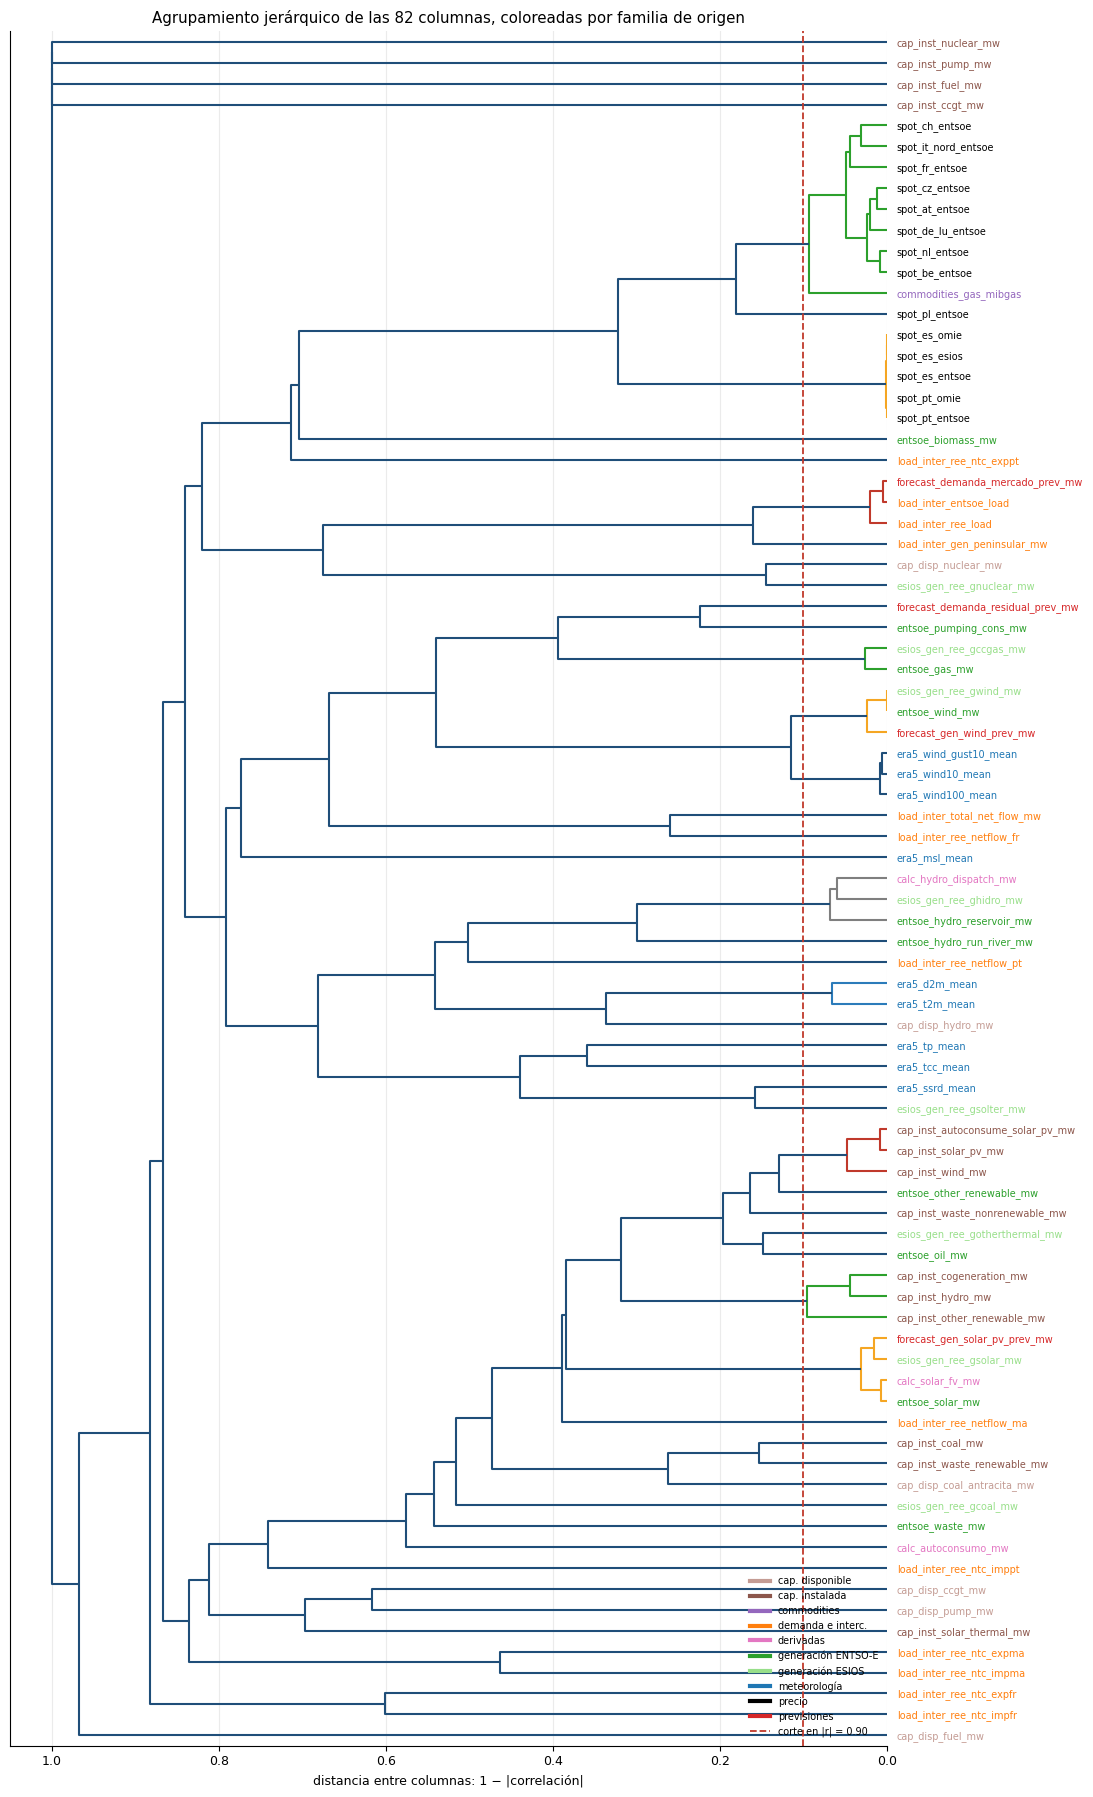

El color permite ver si los grupos coinciden con las tablas de origen o las cruzan.
Un grupo que mezcla familias es el caso interesante: dos organismos midiendo lo mismo.


In [110]:
# En horizontal: con ~80 etiquetas, el formato vertical las deja ilegibles.
from matplotlib.lines import Line2D

COLOR_FAM = {"meteorología": "#1f77b4", "generación ENTSO-E": "#2ca02c",
             "generación ESIOS": "#98df8a", "demanda e interc.": "#ff7f0e",
             "previsiones": "#d62728", "commodities": "#9467bd",
             "cap. instalada": "#8c564b", "cap. disponible": "#c49c94",
             "derivadas": "#e377c2", "precio": "#000000", "otras": "#bcbd22"}

fig, ax = plt.subplots(figsize=(11, max(8, 0.22 * len(cols_est))))
dendrogram(Z, labels=list(cols_est), orientation="left", leaf_font_size=7,
           color_threshold=UMBRAL_GRUPO, ax=ax)
ax.axvline(UMBRAL_GRUPO, color=PALETA["alerta"], ls="--", lw=1.3)
ax.set_xlabel("distancia entre columnas: 1 − |correlación|")
ax.set_title(f"Agrupamiento jerárquico de las {len(cols_est)} columnas, "
             f"coloreadas por familia de origen")
ax.grid(False, axis="y")
for etiqueta in ax.get_ymajorticklabels():
    etiqueta.set_color(COLOR_FAM.get(familia_de(etiqueta.get_text()), "black"))
presentes = sorted({familia_de(c) for c in cols_est})
ax.legend(handles=[Line2D([0], [0], color=COLOR_FAM.get(f, "black"), lw=3, label=f)
                   for f in presentes]
                  + [Line2D([0], [0], color=PALETA["alerta"], ls="--", lw=1.3,
                            label=f"corte en |r| = {1 - UMBRAL_GRUPO:.2f}")],
          frameon=False, fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

print("El color permite ver si los grupos coinciden con las tablas de origen o las cruzan.")
print("Un grupo que mezcla familias es el caso interesante: dos organismos midiendo lo mismo.")

## 8.5 · La dimensionalidad efectiva

El agrupamiento dice qué columnas se solapan; no dice cuántas dimensiones independientes tiene el
conjunto en total. El análisis de componentes principales sobre las variables estandarizadas
responde a eso: el número de componentes necesarias para explicar una fracción dada de la
varianza es una medida directa de cuánta información distinta hay.

**Se emplea como diagnóstico, no como transformación.** Las componentes no se usarán como
variables del modelo, y el motivo es el que gobierna todo el trabajo: una componente principal
mezcla columnas de familias distintas y por tanto **pierde la etiqueta de disponibilidad**. Una
combinación lineal que carga a la vez sobre una previsión y sobre una generación real es
inutilizable en producción por mucha varianza que explique.

Días completos para el análisis: 2,378 de 2,430
  70 % de la varianza →  6 componentes de 82
  80 % de la varianza → 10 componentes de 82
  90 % de la varianza → 17 componentes de 82
  95 % de la varianza → 24 componentes de 82


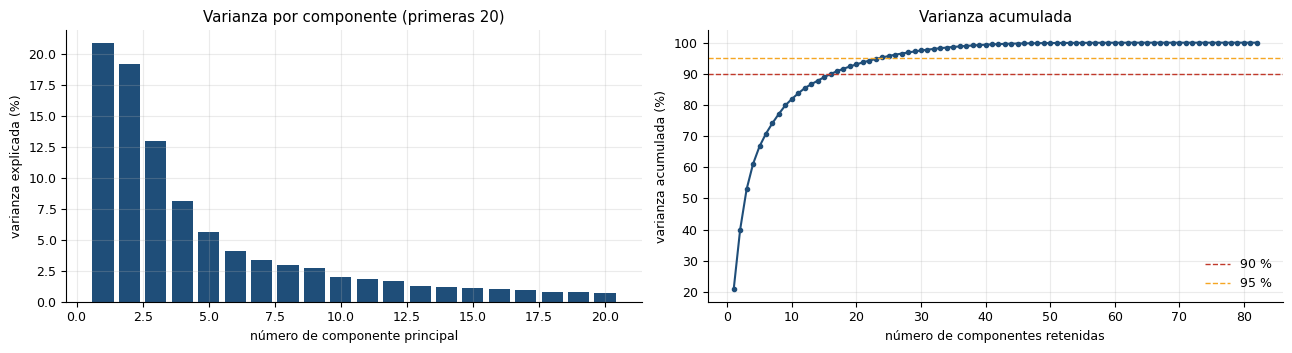

In [111]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_pca = DIA[cols_est].dropna()
print(f"Días completos para el análisis: {len(X_pca):,} de {len(DIA):,}")

Xs = StandardScaler().fit_transform(X_pca)
pca = PCA().fit(Xs)
var = pd.Series(pca.explained_variance_ratio_ * 100,
                index=[f"PC{i+1}" for i in range(pca.n_components_)])
acum = var.cumsum()

for u in (70, 80, 90, 95):
    k = int((acum < u).sum() + 1)
    print(f"  {u} % de la varianza → {k:2d} componentes de {X_pca.shape[1]}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].bar(range(1, min(21, len(var) + 1)), var.values[:20], color=PALETA["principal"])
axes[0].set_xlabel("número de componente principal"); axes[0].set_ylabel("varianza explicada (%)")
axes[0].set_title("Varianza por componente (primeras 20)")
axes[1].plot(range(1, len(acum) + 1), acum.values, marker="o", ms=3, color=PALETA["principal"])
for u, col in [(90, PALETA["alerta"]), (95, PALETA["acento"])]:
    axes[1].axhline(u, color=col, ls="--", lw=1, label=f"{u} %")
axes[1].set_xlabel("número de componentes retenidas"); axes[1].set_ylabel("varianza acumulada (%)")
axes[1].set_title("Varianza acumulada"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

In [112]:
# Qué mide cada componente: las cargas más altas le dan nombre, y su mezcla de etiquetas
# de disponibilidad demuestra por qué no puede usarse como variable.
cargas = pd.DataFrame(pca.components_[:3].T, index=X_pca.columns,
                      columns=[f"PC{i+1}" for i in range(3)])
for pc in cargas.columns:
    top = cargas[pc].abs().nlargest(5)
    etiquetas_pc = {fuga_de(v, P) for v in top.index}
    print(f"\n{pc} ({var[pc]:.1f} % de la varianza) — variables con más peso:")
    for v in top.index:
        print(f"    {cargas.loc[v, pc]:+.3f}  {v[:44]:46s} [{fuga_de(v, P)}]")
    if len(etiquetas_pc) > 1:
        print(f"    → mezcla {sorted(etiquetas_pc)}: inutilizable como variable del modelo.")

k90 = int((acum < 90).sum() + 1)
REG.anotar("M.4", f"La dimensionalidad efectiva del conjunto es de {k90} componentes",
           "confirmado",
           f"{k90} componentes explican el 90 % de la varianza de {X_pca.shape[1]} columnas. "
           "Hay mucha redundancia, pero las componentes no sirven como variables porque "
           "mezclan familias con distinta disponibilidad.")


PC1 (20.8 % de la varianza) — variables con más peso:
    +0.217  spot_fr_entsoe                                 [CON FUGA]
    +0.216  spot_es_esios                                  [TARGET]
    +0.216  spot_es_omie                                   [CON FUGA]
    +0.216  spot_es_entsoe                                 [CON FUGA]
    +0.215  spot_pt_omie                                   [CON FUGA]
    → mezcla ['CON FUGA', 'TARGET']: inutilizable como variable del modelo.

PC2 (19.2 % de la varianza) — variables con más peso:
    +0.226  cap_inst_wind_mw                               [SIN FUGA]
    -0.215  cap_inst_coal_mw                               [SIN FUGA]
    +0.209  forecast_gen_solar_pv_prev_mw                  [SIN FUGA]
    +0.208  esios_gen_ree_gsolar_mw                        [CON FUGA]
    +0.208  cap_inst_solar_pv_mw                           [SIN FUGA]
    → mezcla ['CON FUGA', 'SIN FUGA']: inutilizable como variable del modelo.

PC3 (12.9 % de la varianza) — variabl

---
# 9 · Hallazgos y traspaso a la ingeniería de variables

El resultado operativo del análisis. La tabla siguiente no se escribe a mano al cerrar: se deriva
de las anotaciones que cada bloque ha ido dejando en el momento en que demostraba algo.

In [113]:
print(f"{REG.titulo}\n")
display(REG.tabla())

HALLAZGOS DEL ANÁLISIS



,hallazgo,estado,consecuencia
código,,,
D-02,entsoe_gas_mw agrega CCGT y cogeneración con d...,confirmado,La diferencia media se mueve entre -806 y -177...
D-03,esios_gen_ree_gsolar_mw cambia de perímetro (i...,confirmado,"Usar calc_solar_fv_mw, que mantiene el perímet..."
E.2,esios_gen_ree_ghidro_mw mezcla generación hidr...,confirmado,"Usar las columnas de ENTSO-E, que separan fluy..."
D-04,6 columnas constantes y 6 cuasi-constantes,confirmado,El criterio correcto es el coeficiente de vari...
A.5,La demanda residual prevista NO arrastra el au...,descartado,El residuo de la identidad se mantiene estable...
B.2,Los nulos de la ráfaga no son censura por vien...,descartado,"No hay ceros exactos, el mínimo está lejos de ..."
B.1,Convención asimétrica NULL/0 entre turbinación...,confirmado,Aplicar fillna(0) sobre pumping_gen_mw ANTES d...
C.1,9 horas de demanda en cero por fallo de ingesta,confirmado,"Reparar con load_inter_ree_load, que es un seg..."
C.2,Generación solar negativa en horas nocturnas,fenómeno físico,Consumo auxiliar de plantas termosolares. No r...


## 9.1 · Lo que este análisis entrega al cuaderno siguiente

Cada hallazgo lleva asociada una consecuencia, y esa consecuencia es una instrucción concreta
para la ingeniería de variables. Agrupadas por el tipo de operación que exigen:

In [114]:
TRASPASO = pd.DataFrame([
    ("2 · corrección",   "C.1", "Reparar los ceros de demanda con la segunda fuente"),
    ("2 · corrección",   "B.1", "fillna(0) en pumping_gen_mw antes de agregar"),
    ("2 · corrección",   "D-04", "Descartar las columnas de varianza nula"),
    ("2 · corrección",   "D-02", "Descartar entsoe_gas_mw; usar ESIOS separado"),
    ("2 · corrección",   "D-03", "Descartar esios_gen_ree_gsolar_mw y load_inter_ree_load"),
    ("2 · corrección",   "E.2", "Descartar esios_gen_ree_ghidro_mw"),
    ("2 · corrección",   "P.5", "Corregir el sesgo de las previsiones de generación"),
    ("3 · perdidos",     "F.1", "No interpolar la ráfaga: el hueco es un mes entero"),
    ("4 · construcción", "P.0", "Antigüedad y capacidad FV instalada como regresores"),
    ("4 · construcción", "P.1", "Retardos de 24 y 168 h, e interacción con el día de la semana"),
    ("4 · construcción", "M.5", "Retardo de cada driver en su desfase óptimo (apartado 4.6)"),
    ("4 · construcción", "P.2", "Indicadora de régimen"),
    ("4 · construcción", "P.3", "Interacciones de los drivers con la hora del día"),
    ("4 · construcción", "P.6", "Grados-día de frío y de calor en vez de temperatura lineal"),
    ("4 · construcción", "P.4", "Transformaciones, verificadas fuera de muestra"),
    ("5 · objetivos",    "P.7", "Objetivo categórico barata/intermedia/cara y matriz de coste"),
    ("6 · depuración",   "M.3", "Retirar los duplicados de cada grupo de redundancia"),
    ("7 · cribado",      "M.2", "Penalizar los drivers cuya asociación era sólo ciclo"),
    ("—  método",        "M.1", "Medir toda asociación entre familias sobre el marco diario"),
    ("—  sin resolver",  "F.2", "Perímetro de cap_disp_*: no usar sin resolver D-01"),
    ("—  sin resolver",  "C.2", "Solar negativa nocturna: fenómeno físico, sin corrección"),
], columns=["destino en 02_ingenieria_variables", "hallazgo", "instrucción"])
display(TRASPASO.set_index(["destino en 02_ingenieria_variables", "hallazgo"]))

instrucción
destino en 02_ingenieria_variables hallazgo                                                   
2 · corrección                     C.1       Reparar los ceros de demanda con la segunda fu...
                                   B.1            fillna(0) en pumping_gen_mw antes de agregar
                                   D-04                Descartar las columnas de varianza nula
                                   D-02           Descartar entsoe_gas_mw; usar ESIOS separado
                                   D-03      Descartar esios_gen_ree_gsolar_mw y load_inter...
                                   E.2                       Descartar esios_gen_ree_ghidro_mw
                                   P.5       Corregir el sesgo de las previsiones de genera...
3 · perdidos                       F.1       No interpolar la ráfaga: el hueco es un mes en...
4 · construcción                   P.0       Antigüedad y capacidad FV instalada como regre...
                                   P.1       Retardos de 24 y 168 h, e interacción con el d...
                                   M.5       Retardo de cada driver en su desfase óptimo (a...
                                   P.2                                   Indicadora de régimen
                                   P.3        Interacciones de los drivers con la hora del día
                                   P.6       Grados-día de frío y de calor en vez de temper...
                                   P.4          Transformaciones, verificadas fuera de muestra
5 · objetivos                      P.7       Objetivo categórico barata/intermedia/cara y m...
6 · depuración                     M.3       Retirar los duplicados de cada grupo de redund...
7 · cribado                        M.2       Penalizar los drivers cuya asociación era sólo...
—  método                          M.1       Medir toda asociación entre familias sobre el ...
—  sin resolver                    F.2       Perímetro de cap_disp_*: no usar sin resolver ...
                                   C.2       Solar negativa nocturna: fenómeno físico, sin ...

## 9.2 · Alcance: lo que este análisis no ha podido cubrir

La declaración del alcance forma parte del resultado. Cinco líneas de análisis previstas en el
plan de trabajo no se han podido ejecutar sobre la capa bronce disponible, y en todos los casos
el motivo es que la tabla correspondiente **no está incorporada al conjunto unificado**, no que
se hayan omitido por conveniencia.

Se dejan enumeradas con lo que cada una habría aportado, de modo que la limitación quede acotada
y sea recuperable si la ingesta las incorpora más adelante.

In [115]:
TABLAS_ESPERADAS = {
    "esios_pdbc_gen / esios_pbf_*": (
        "pdbc_",
        "Medir si el programa de casación aporta algo con retardo por encima de la generación "
        "real, y cuánto pesan los contratos bilaterales."),
    "entsoe_forecast_da": (
        "ent_fc_",
        "Contrastar la previsión de REE con una segunda previsión independiente del mismo "
        "fenómeno, que mide la incertidumbre de la propia entrada del modelo."),
    "ecmwf_forecast_agg": (
        "ecmwf_",
        "Ablación de «meteorología perfecta»: cuánto se pierde al usar previsión en lugar de "
        "reanálisis. Es la limitación descrita en el apartado 5.2."),
}

filas = []
for tabla, (prefijo, aporte) in TABLAS_ESPERADAS.items():
    presentes = [c for c in df.columns if c.startswith(prefijo)]
    filas.append({"tabla": tabla, "columnas en el bronce": len(presentes),
                  "estado": "disponible" if presentes else "NO incorporada",
                  "qué habría aportado": aporte})
ALCANCE = pd.DataFrame(filas).set_index("tabla")
display(ALCANCE)

fuera = ALCANCE[ALCANCE["estado"] == "NO incorporada"]
print(f"{len(fuera)} de {len(ALCANCE)} líneas de análisis quedan fuera de alcance por falta de "
      "la tabla en el bronce.")
print("\nNo se añade a esta lista el cambio de entorno de ingesta de ERA5 de enero de 2025.")
print("Documentar la ruta exacta exigiría la columna `tensor_path`, que es metadato y no viaja")
print("al conjunto unificado; pero lo que de verdad importaba —si ese cambio introdujo un sesgo")
print("entre el período de entrenamiento y el de prueba— sí puede contrastarse sin ella, y se")
print("resuelve en el apartado 2.10.")

,columnas en el bronce,estado,qué habría aportado
tabla,,,
esios_pdbc_gen / esios_pbf_*,0,NO incorporada,Medir si el programa de casación aporta algo c...
entsoe_forecast_da,0,NO incorporada,Contrastar la previsión de REE con una segunda...
ecmwf_forecast_agg,0,NO incorporada,Ablación de «meteorología perfecta»: cuánto se...


3 de 3 líneas de análisis quedan fuera de alcance por falta de la tabla en el bronce.

No se añade a esta lista el cambio de entorno de ingesta de ERA5 de enero de 2025.
Documentar la ruta exacta exigiría la columna `tensor_path`, que es metadato y no viaja
al conjunto unificado; pero lo que de verdad importaba —si ese cambio introdujo un sesgo
entre el período de entrenamiento y el de prueba— sí puede contrastarse sin ella, y se
resuelve en el apartado 2.10.


---
# 10 · Láminas para la memoria

Veinte páginas para toda la memoria obligan a una aritmética sencilla: **una figura por página es
inviable**. La solución no es recortar el análisis, sino agrupar. Cada lámina reúne cuatro
diagramas que responden a **una misma pregunta** desde ángulos que no se solapan, ocupa una
página y lleva un pie que la lee como conjunto.

Los paneles se componen a partir de los objetos ya calculados en los bloques anteriores, de modo
que **ninguna lámina puede decir algo distinto del análisis del que sale**. Si un panel falla, se
escribe el aviso en su hueco en lugar de tumbar la lámina entera.

### Dos criterios de composición

**Escala lineal, no logarítmica.** La escala logarítmica revela las colas, pero deforma la
percepción del cuerpo de la distribución, que es donde está el 95 % de las horas. Se representa
en escala lineal y la información de las colas se da donde no engaña: en la curva de duración,
que dice cuántas horas al año se supera cada nivel, y en las cifras anotadas sobre el propio
panel.

**Las leyendas van fuera del área de datos.** Una leyenda superpuesta tapa precisamente las
barras o las curvas que justifican la figura. Todas se colocan bajo el eje, en horizontal.

In [116]:
FIGURAS = cm.RAIZ / "docs" / "figuras" / "eda"
PANELES = FIGURAS / "paneles"
LAMINAS = []

def leyenda(ax, ncol=4, titulo=None, tam=6.5, y=-0.17):
    # Fuera del area de datos: una leyenda superpuesta tapa lo que justifica la figura.
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False,
              fontsize=tam, title=titulo, title_fontsize=tam,
              handlelength=1.4, columnspacing=1.1, handletextpad=0.5)

def sin_rejilla(ax):
    ax.grid(False)
    return ax

def lamina(etq, titulo, pie, paneles, ncol=2, alto=3.5):
    '''Compone cuatro paneles en una figura de pagina. Cada panel es (subtitulo, funcion(ax)).'''
    FIGURAS.mkdir(parents=True, exist_ok=True)
    nfil = int(np.ceil(len(paneles) / ncol))
    fig, axes = plt.subplots(nfil, ncol, figsize=(6.6 * ncol, alto * nfil),
                             constrained_layout=True)
    ejes = np.atleast_1d(axes).ravel()
    fallos = []
    for ax, (sub, fn) in zip(ejes, paneles):
        try:
            fn(ax)
            ax.set_title(sub, fontsize=9.5)
        except Exception as e:
            ax.clear(); ax.axis("off")
            ax.text(0.5, 0.5, f"{sub}\n\nno disponible\n({type(e).__name__}: {e})",
                    ha="center", va="center", fontsize=7.5, color=PALETA["neutro"], wrap=True)
            fallos.append(sub)
    for ax in ejes[len(paneles):]:
        ax.axis("off")
    fig.suptitle(titulo, fontsize=11.5)
    ruta = FIGURAS / f"{etq}.png"
    fig.savefig(ruta, dpi=170, bbox_inches="tight", facecolor="white")
    LAMINAS.append({"lámina": etq, "título": titulo, "paneles": len(paneles),
                    "fallos": len(fallos), "pie": pie})
    print(f"  {etq}: {len(paneles) - len(fallos)}/{len(paneles)} paneles"
          + (f"  FALLAN: {fallos}" if fallos else ""))
    plt.show(); plt.close(fig)

plt.rcParams.update({"savefig.dpi": 170, "figure.dpi": 105})
print(f"Las láminas se guardan en {FIGURAS.relative_to(cm.RAIZ)}")

Las láminas se guardan en docs\figuras\eda


## L01 · ¿Cómo es lo que hay que predecir?

  L01_objetivo: 4/4 paneles


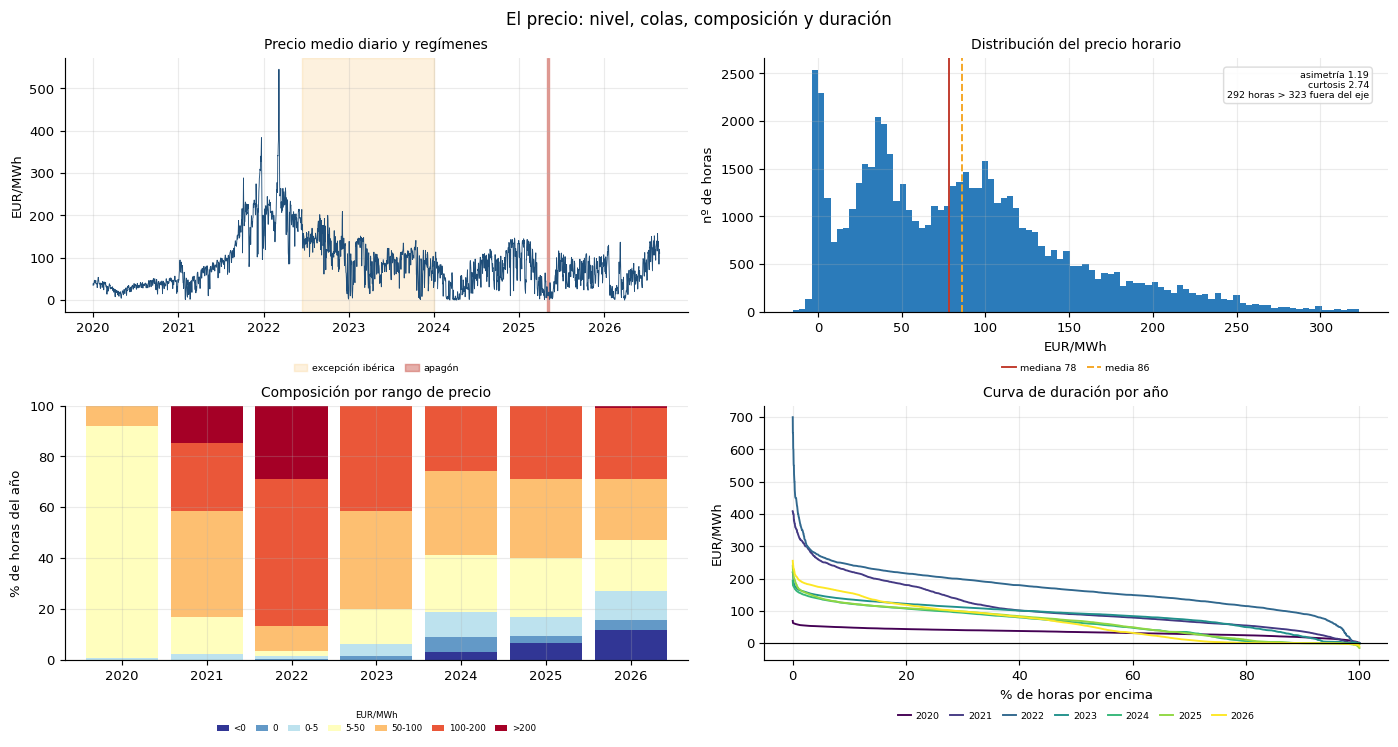

In [117]:
def p_serie(ax):
    s_ = df.groupby("dia")[P].mean()
    ax.plot(pd.to_datetime(s_.index), s_.values, lw=0.6, color=PALETA["principal"])
    ax.axvspan(EXCEPCION[0].tz_localize(None), EXCEPCION[1].tz_localize(None),
               alpha=0.15, color=PALETA["acento"], label="excepción ibérica")
    ax.axvspan(APAGON[0].tz_localize(None), APAGON[1].tz_localize(None),
               alpha=0.40, color=PALETA["alerta"], label="apagón")
    ax.set_ylabel("EUR/MWh")
    leyenda(ax, ncol=2)

def p_distrib(ax):
    # Escala LINEAL: es donde se lee el cuerpo de la distribucion, que es el 95 % de las horas.
    v = df[P].dropna()
    lim = v.quantile(0.995)
    ax.hist(v[v <= lim], bins=90, color=PALETA["secundario"], edgecolor="none")
    ax.axvline(v.median(), color=PALETA["alerta"], lw=1.3, label=f"mediana {v.median():.0f}")
    ax.axvline(v.mean(), color=PALETA["acento"], lw=1.3, ls="--", label=f"media {v.mean():.0f}")
    ax.set_xlabel("EUR/MWh"); ax.set_ylabel("nº de horas")
    fuera = int((v > lim).sum())
    ax.text(0.97, 0.95, f"asimetría {v.skew():.2f}\ncurtosis {v.kurtosis():.2f}\n"
                        f"{fuera} horas > {lim:.0f} fuera del eje",
            transform=ax.transAxes, ha="right", va="top", fontsize=6.5,
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=PALETA["suave"], alpha=0.9))
    leyenda(ax, ncol=2)

def p_composicion(ax):
    bins = [-np.inf, 0, 0.001, 5, 50, 100, 200, np.inf]
    etq = ["<0", "0", "0-5", "5-50", "50-100", "100-200", ">200"]
    t = pd.crosstab(df["anio"], pd.cut(df[P], bins=bins, labels=etq, right=False))
    (t.div(t.sum(axis=1), axis=0) * 100).plot(kind="bar", stacked=True, ax=ax, width=0.85,
                                              colormap="RdYlBu_r", legend=False)
    ax.set_ylabel("% de horas del año"); ax.set_xlabel("")
    ax.set_ylim(0, 100); ax.tick_params(axis="x", rotation=0)
    leyenda(ax, ncol=7, titulo="EUR/MWh", tam=6)

def p_duracion(ax):
    cmap = plt.get_cmap("viridis"); aa = sorted(df["anio"].unique())
    for i, a in enumerate(aa):
        v = df.loc[df["anio"] == a, P].dropna().sort_values(ascending=False).values
        ax.plot(np.linspace(0, 100, len(v)), v, lw=1.3,
                color=cmap(i / max(len(aa) - 1, 1)), label=str(a))
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("% de horas por encima"); ax.set_ylabel("EUR/MWh")
    leyenda(ax, ncol=len(aa))

lamina("L01_objetivo", "El precio: nivel, colas, composición y duración",
       "Cuatro vistas del objetivo. La distribución se representa en escala lineal, que es donde "
       "se lee el cuerpo de las observaciones, y las colas se cuantifican en la curva de "
       "duración, que dice cuántas horas al año se supera cada nivel. La composición por rango "
       "muestra que los precios nulos y negativos aparecen a mitad del histórico y crecen cada "
       "año: el problema cambió de naturaleza durante el propio período de entrenamiento, lo que "
       "condiciona cómo debe ponderarse el histórico.",
       [("Precio medio diario y regímenes", p_serie),
        ("Distribución del precio horario", p_distrib),
        ("Composición por rango de precio", p_composicion),
        ("Curva de duración por año", p_duracion)])

## L02 · ¿Qué estructura temporal tiene?

  L02_estructura_temporal: 4/4 paneles


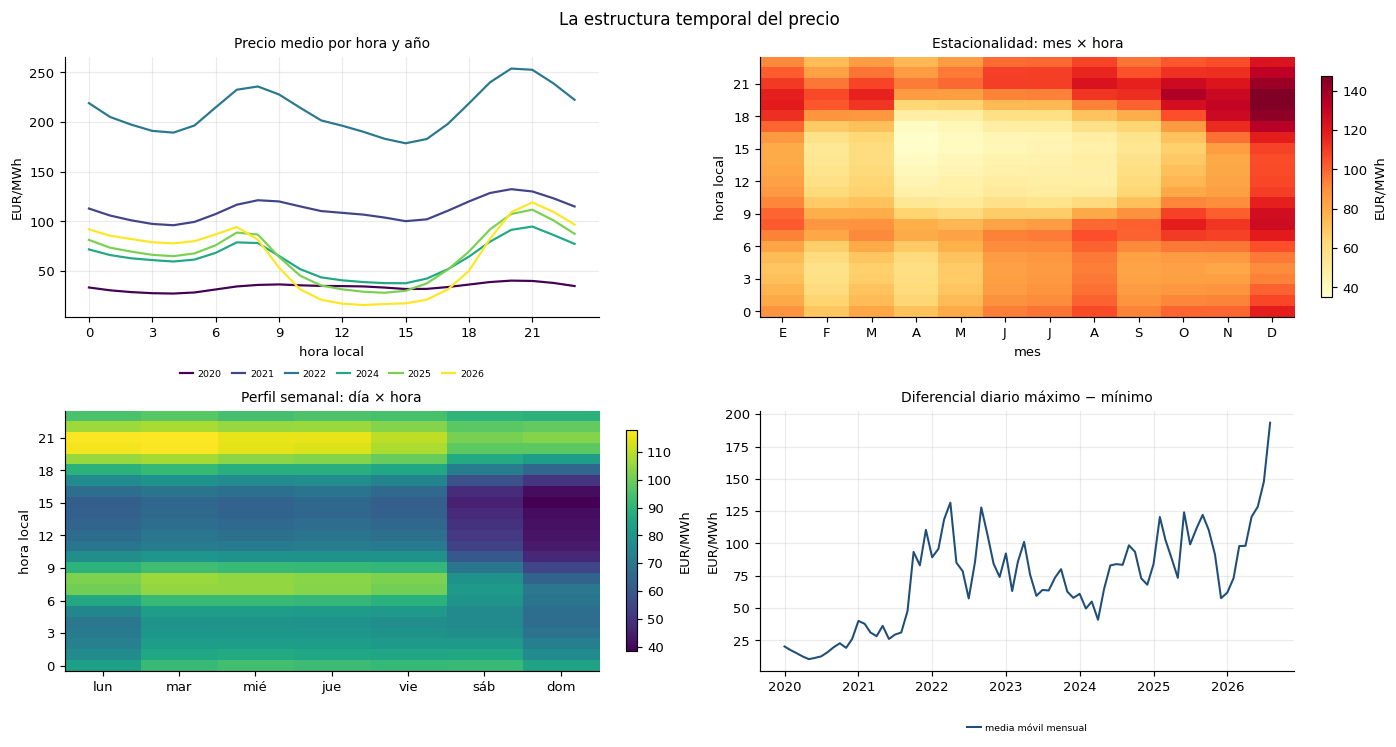

In [118]:
def p_perfil_anio(ax):
    perf = NORMAL.pivot_table(index="hora", columns="anio", values=P, aggfunc="mean")
    cmap = plt.get_cmap("viridis")
    for i, a in enumerate(perf.columns):
        ax.plot(perf.index, perf[a], lw=1.5, color=cmap(i / max(len(perf.columns) - 1, 1)),
                label=str(a))
    ax.set_xlabel("hora local"); ax.set_ylabel("EUR/MWh"); ax.set_xticks(range(0, 24, 3))
    leyenda(ax, ncol=len(perf.columns))

def p_mes_hora(ax):
    mh = NORMAL.pivot_table(index="hora", columns="mes", values=P, aggfunc="mean")
    im = ax.imshow(mh.values, aspect="auto", origin="lower", cmap="YlOrRd")
    ax.set_xticks(range(12), ["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.set_yticks(range(0, 24, 3)); ax.set_ylabel("hora local"); ax.set_xlabel("mes")
    plt.colorbar(im, ax=ax, shrink=0.85, label="EUR/MWh")
    sin_rejilla(ax)

def p_dow_hora(ax):
    sm = NORMAL.pivot_table(index="hora", columns="dow", values=P, aggfunc="mean")
    im = ax.imshow(sm.values, aspect="auto", origin="lower", cmap="viridis")
    ax.set_xticks(range(7), [d[:3] for d in DIAS])
    ax.set_yticks(range(0, 24, 3)); ax.set_ylabel("hora local")
    plt.colorbar(im, ax=ax, shrink=0.85, label="EUR/MWh")
    sin_rejilla(ax)

def p_diferencial(ax):
    sp_ = df.groupby("dia")[P].agg(["min", "max"]).dropna()
    sp_.index = pd.to_datetime(sp_.index)
    dif = (sp_["max"] - sp_["min"]).resample("MS").mean()
    ax.plot(dif.index, dif.values, lw=1.4, color=PALETA["principal"], label="media móvil mensual")
    ax.set_ylabel("EUR/MWh"); ax.set_xlabel("")
    leyenda(ax, ncol=1)

lamina("L02_estructura_temporal", "La estructura temporal del precio",
       "El perfil horario cambia de forma a lo largo del período: la hora barata se desplaza de "
       "la madrugada al mediodía y la amplitud del día se multiplica. Los dos mapas de calor "
       "separan las dos estacionalidades que conviven —la anual y la semanal— y el diferencial "
       "diario cuantifica lo único que una batería puede aprovechar, que no es el nivel del "
       "precio sino su recorrido dentro de la jornada.",
       [("Precio medio por hora y año", p_perfil_anio),
        ("Estacionalidad: mes × hora", p_mes_hora),
        ("Perfil semanal: día × hora", p_dow_hora),
        ("Diferencial diario máximo − mínimo", p_diferencial)])

## L03 · ¿Cuánto se explica el precio a sí mismo?

  L03_persistencia: 4/4 paneles


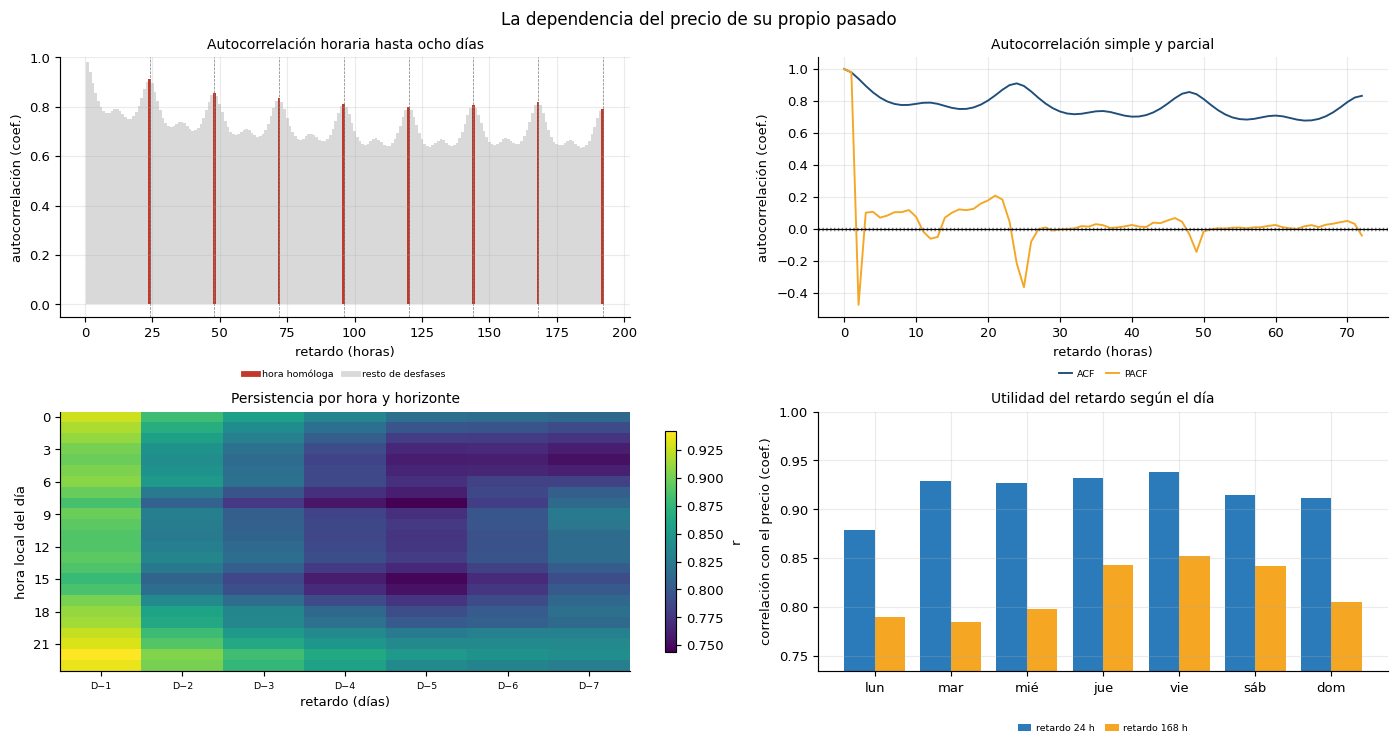

In [119]:
def p_acf_barras(ax):
    misma = acf["desfase_h"] == 24
    ax.bar(acf["retardo"], acf["r"], width=1.0,
           color=np.where(misma, PALETA["alerta"], PALETA["suave"]))
    for k in range(24, 193, 24):
        ax.axvline(k, color=PALETA["neutro"], lw=0.5, ls="--")
    ax.set_xlabel("retardo (horas)"); ax.set_ylabel("autocorrelación (coef.)")
    ax.set_ylim(min(0, acf["r"].min()) - 0.05, 1.0)
    ax.plot([], [], color=PALETA["alerta"], lw=4, label="hora homóloga")
    ax.plot([], [], color=PALETA["suave"], lw=4, label="resto de desfases")
    leyenda(ax, ncol=2)

def p_pacf(ax):
    from statsmodels.tsa.stattools import acf as _acf, pacf as _p
    s_ = df.set_index("ts_utc")[P].asfreq("h").interpolate(limit=3).dropna()
    n = 72
    a_ = _acf(s_, nlags=n); pa = _p(s_, nlags=n, method="ywm")
    u = 1.96 / np.sqrt(len(s_))
    ax.plot(range(n + 1), a_, lw=1.3, color=PALETA["principal"], label="ACF")
    ax.plot(range(n + 1), pa, lw=1.3, color=PALETA["acento"], label="PACF")
    ax.axhline(u, color=PALETA["neutro"], ls=":", lw=1)
    ax.axhline(-u, color=PALETA["neutro"], ls=":", lw=1)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("retardo (horas)"); ax.set_ylabel("autocorrelación (coef.)")
    leyenda(ax, ncol=2)

def p_persistencia(ax):
    Mp = pd.DataFrame({f"D−{k}": {h: ancho[h].corr(ancho[h].shift(k)) for h in ancho.columns}
                       for k in range(1, 8)})
    im = ax.imshow(Mp.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(Mp.columns)), Mp.columns, fontsize=6.5)
    ax.set_yticks(range(0, 24, 3), range(0, 24, 3))
    ax.set_ylabel("hora local del día"); ax.set_xlabel("retardo (días)")
    plt.colorbar(im, ax=ax, shrink=0.85, label="r")
    sin_rejilla(ax)

def p_retardo_dow(ax):
    x = np.arange(7)
    ax.bar(x - 0.2, comparativa["ayer (D−1)"], width=0.4, label="retardo 24 h",
           color=PALETA["secundario"])
    ax.bar(x + 0.2, comparativa["hace una semana (D−7)"], width=0.4, label="retardo 168 h",
           color=PALETA["acento"])
    ax.set_xticks(x, [d[:3] for d in DIAS]); ax.set_ylabel("correlación con el precio (coef.)")
    ax.set_ylim(min(comparativa[["ayer (D−1)", "hace una semana (D−7)"]].min()) - 0.05, 1.0)
    leyenda(ax, ncol=2)

lamina("L03_persistencia", "La dependencia del precio de su propio pasado",
       "El precio se explica en muy buena medida a sí mismo, y esa autocorrelación fija la "
       "referencia mínima que cualquier variable exógena debe superar para justificar su "
       "incorporación. La autocorrelación parcial demuestra que el retardo de veinticuatro horas "
       "aporta información propia y no sólo transmitida por los retardos vecinos. Los dos "
       "últimos paneles muestran que esa dependencia no es homogénea: varía con la hora del día "
       "y con el día de la semana, lo que aconseja interactuar el retardo con el calendario.",
       [("Autocorrelación horaria hasta ocho días", p_acf_barras),
        ("Autocorrelación simple y parcial", p_pacf),
        ("Persistencia por hora y horizonte", p_persistencia),
        ("Utilidad del retardo según el día", p_retardo_dow)])

## L04 · ¿Son fiables los datos de partida?

  L04_calidad: 4/4 paneles


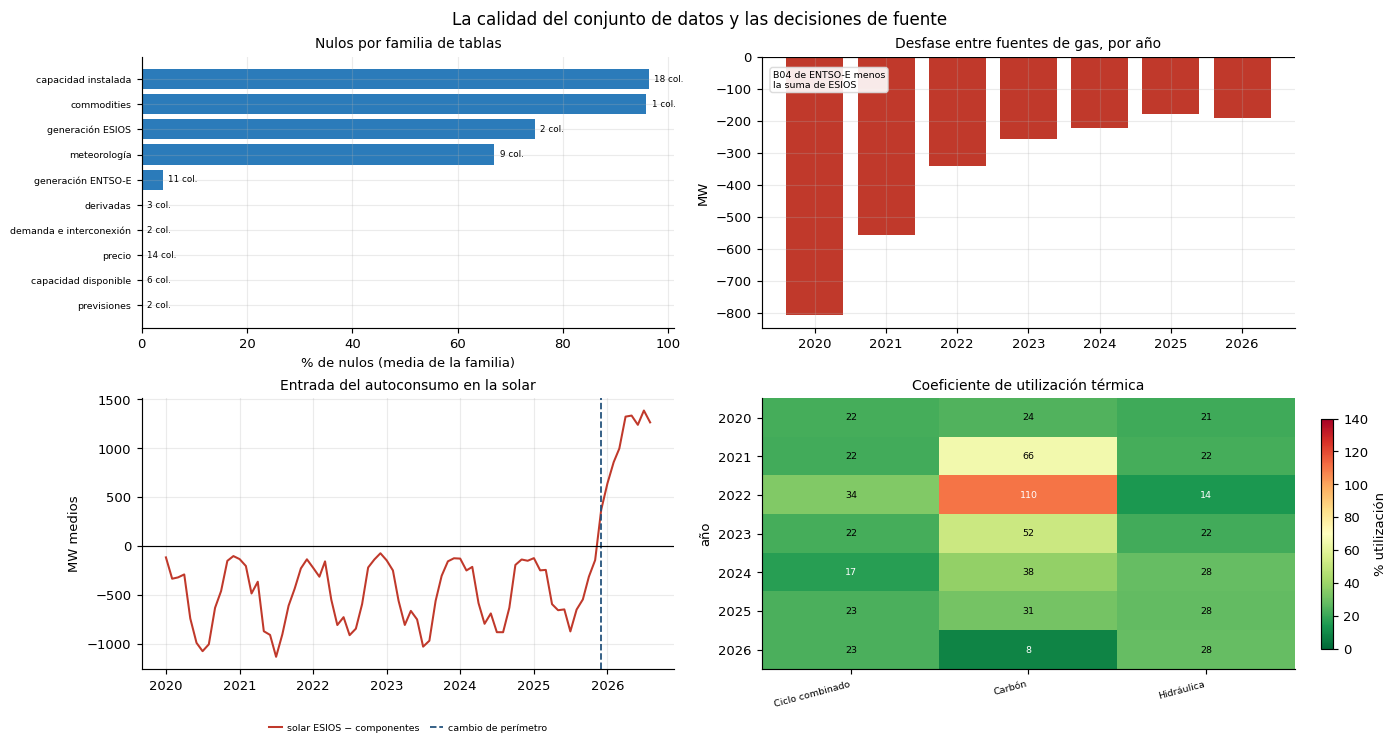

In [120]:
def p_nulos(ax):
    fam = nulos.groupby("familia")["% nulos"].agg(["mean", "size"]).sort_values("mean")
    ax.barh(fam.index, fam["mean"], color=PALETA["secundario"])
    for i, (n_, r_) in enumerate(zip(fam["size"], fam["mean"])):
        ax.text(r_ + 1, i, f"{int(n_)} col.", va="center", fontsize=6)
    ax.set_xlabel("% de nulos (media de la familia)")
    ax.tick_params(axis="y", labelsize=6.5)

def p_gas_fuentes(ax):
    g = df[[GAS_ENT, CCGT, OTHERTH, "anio"]].dropna()
    g = g.assign(dif=g[GAS_ENT] - g[CCGT] - g[OTHERTH])
    d = g.groupby("anio")["dif"].mean()
    ax.bar(d.index.astype(str), d.values, color=PALETA["alerta"])
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("MW"); ax.set_xlabel("")
    ax.text(0.02, 0.95, "B04 de ENTSO-E menos\nla suma de ESIOS", transform=ax.transAxes,
            va="top", fontsize=6.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=PALETA["suave"], alpha=0.9))

def p_autoconsumo(ax):
    s_ = df.groupby("mes_p")[[SOLREE, SOLTER, FV]].mean().dropna()
    dif = s_[SOLREE] - s_[SOLTER] - s_[FV]
    ax.plot(dif.index.to_timestamp(), dif.values, lw=1.4, color=PALETA["alerta"],
            label="solar ESIOS − componentes")
    ax.axvline(pd.Timestamp("2025-12-01"), color=PALETA["principal"], ls="--", lw=1.2,
               label="cambio de perímetro")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("MW medios"); ax.set_xlabel("")
    leyenda(ax, ncol=2)

def p_utilizacion(ax):
    im = ax.imshow(U.values.astype(float), aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=140)
    ax.set_xticks(range(U.shape[1]), U.columns, fontsize=6.5, rotation=15, ha="right")
    ax.set_yticks(range(len(U)), U.index)
    for i in range(U.shape[0]):
        for j in range(U.shape[1]):
            v = U.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=6.5,
                        color="white" if (v > 110 or v < 20) else "black")
    ax.set_ylabel("año")
    plt.colorbar(im, ax=ax, shrink=0.85, label="% utilización")
    sin_rejilla(ax)

lamina("L04_calidad", "La calidad del conjunto de datos y las decisiones de fuente",
       "El perfil de nulos separa lo estructural —tablas diarias y paso trihorario, que generan "
       "ausencias por diseño— de los huecos reales. Los tres paneles restantes documentan "
       "decisiones de fuente tomadas con evidencia propia: el agregado de gas de ENTSO-E no es "
       "el ciclo combinado de ESIOS y su desfase no es estable; la serie solar de ESIOS cambia "
       "de perímetro a finales de 2025; y el coeficiente de utilización de las térmicas supera "
       "el 100 %, lo que es físicamente imposible y deja abierta la verificación del "
       "denominador.",
       [("Nulos por familia de tablas", p_nulos),
        ("Desfase entre fuentes de gas, por año", p_gas_fuentes),
        ("Entrada del autoconsumo en la solar", p_autoconsumo),
        ("Coeficiente de utilización térmica", p_utilizacion)])

## L05 · ¿Qué explica el precio, y qué de eso se puede usar?

  L05_drivers: 4/4 paneles


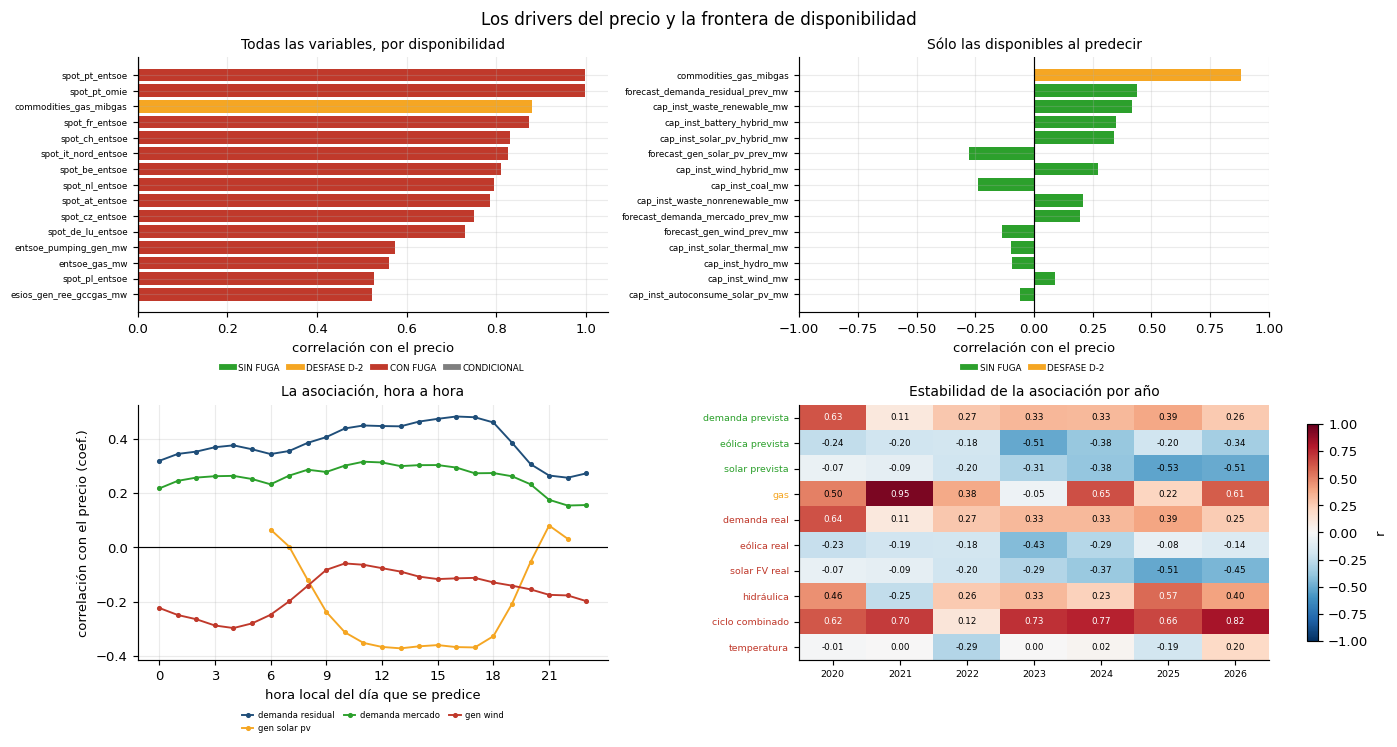

In [121]:
def p_ranking(ax):
    ax.barh(range(len(corr)), corr.values[::-1],
            color=[COLOR_FUGA.get(f, PALETA["neutro"]) for f in fugas[::-1]])
    ax.set_yticks(range(len(corr)), [c[:34] for c in corr.index[::-1]], fontsize=6)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("correlación con el precio")
    for k, v in COLOR_FUGA.items():
        if k != "TARGET":
            ax.plot([], [], color=v, lw=4, label=k)
    leyenda(ax, ncol=4, tam=6)

def p_utilizables(ax):
    # Misma escala que el panel anterior: la comparacion entre ambos ES el resultado.
    ax.barh(range(len(sin_fuga)), sin_fuga.values[::-1],
            color=[COLOR_FUGA[fuga_todas[c]] for c in sin_fuga.index[::-1]])
    ax.set_yticks(range(len(sin_fuga)), [c[:34] for c in sin_fuga.index[::-1]], fontsize=6)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel("correlación con el precio")
    for k in cm.ADMISIBLES:
        ax.plot([], [], color=COLOR_FUGA[k], lw=4, label=k)
    leyenda(ax, ncol=2, tam=6)

def nombre_corto(c):
    return (c.replace("forecast_", "").replace("commodities_", "")
             .replace("cap_inst_", "cap. ").replace("_prev_mw", "").replace("_mw", "")
             .replace("_", " "))

def p_por_hora(ax):
    for c in por_hora.columns:
        ax.plot(por_hora.index, por_hora[c], marker="o", ms=2.5, lw=1.3, label=nombre_corto(c))
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("hora local del día que se predice"); ax.set_ylabel("correlación con el precio (coef.)")
    ax.set_xticks(range(0, 24, 3))
    leyenda(ax, ncol=3, tam=5.8)

def p_por_anio(ax):
    im = ax.imshow(E.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(E.shape[1]), E.columns, fontsize=6.5)
    ax.set_yticks(range(len(E)), E.index, fontsize=6.5)
    for et, k in zip(ax.get_yticklabels(), E.index):
        et.set_color(COLOR_FUGA.get(DRIVERS[k][1], "black"))
    for i in range(E.shape[0]):
        for j in range(E.shape[1]):
            if pd.notna(E.iloc[i, j]):
                ax.text(j, i, f"{E.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if abs(E.iloc[i, j]) > 0.55 else "black")
    plt.colorbar(im, ax=ax, shrink=0.85, label="r")
    sin_rejilla(ax)

lamina("L05_drivers", "Los drivers del precio y la frontera de disponibilidad",
       "Los dos paneles superiores son el resultado central del bloque, y su comparación importa "
       "más que cualquiera de ellos por separado: están dibujados en la misma escala. Las "
       "variables más correlacionadas con el precio son, casi todas, consecuencia de la misma "
       "casación que lo forma, y por tanto inutilizables al predecir; restringido a lo que sí "
       "está disponible a las 12:00 de D, el panorama se reduce drásticamente, y esa diferencia "
       "es el coste de la restricción operativa. Los dos paneles inferiores matizan la "
       "asociación de lo que queda: depende de la hora del día —lo que exige interacciones— y no "
       "es estable entre años. Esto último importa especialmente aquí: varias de las variables que "
       "sobreviven al filtro son series de capacidad instalada, que crecen de forma monótona a lo "
       "largo del período, y su correlación con el precio puede ser tendencia compartida antes que "
       "relación.",
       [("Todas las variables, por disponibilidad", p_ranking),
        ("Sólo las disponibles al predecir", p_utilizables),
        ("La asociación, hora a hora", p_por_hora),
        ("Estabilidad de la asociación por año", p_por_anio)])

## L06 · ¿Cómo se comporta la asociación en el tiempo?

  L06_asociacion_temporal: 4/4 paneles


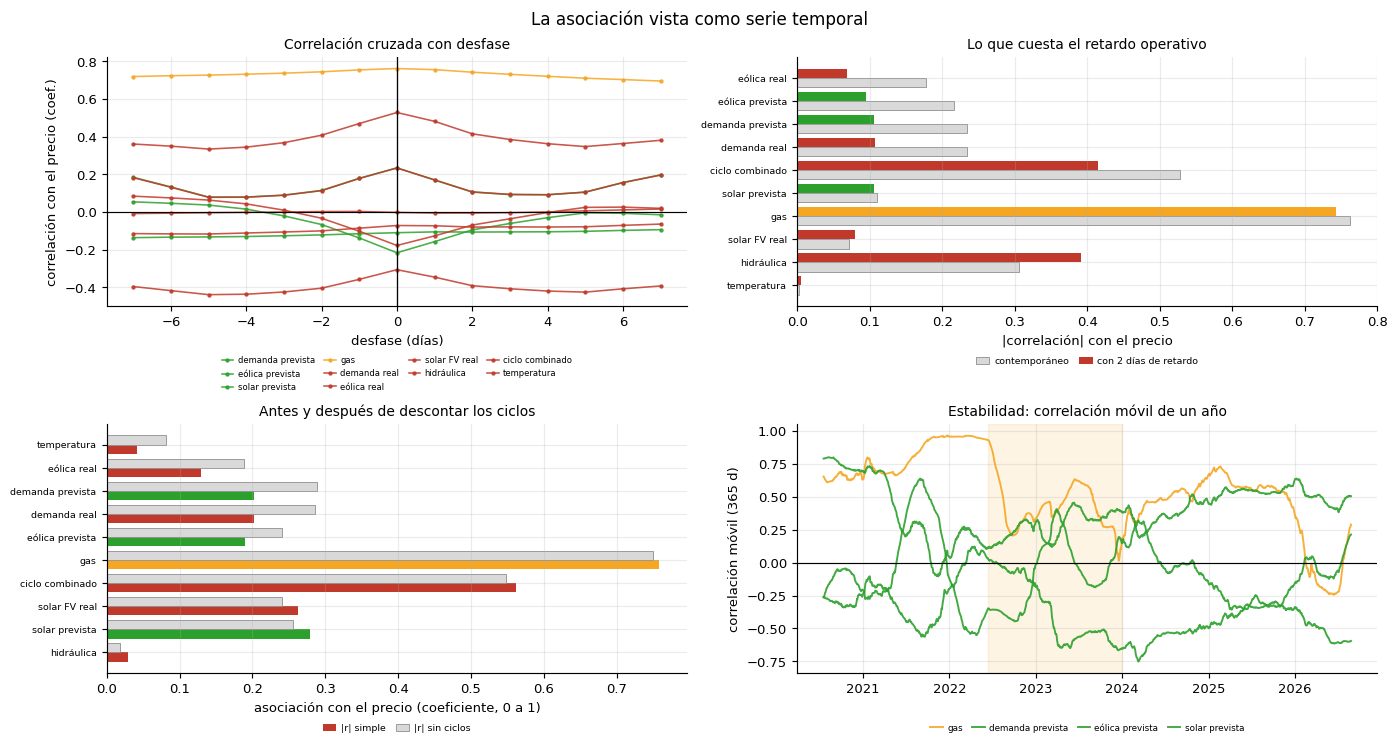

In [122]:
def p_cruzada(ax):
    for k in X.columns:
        ax.plot(X.index, X[k], lw=1.1, marker="o", ms=2,
                color=COLOR_FUGA.get(DRIVERS_DIA[k][1], PALETA["neutro"]), alpha=0.85, label=k)
    ax.axvline(0, color="black", lw=0.9); ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("desfase (días)"); ax.set_ylabel("correlación con el precio (coef.)")
    leyenda(ax, ncol=4, tam=5.8)

def p_retencion(ax):
    y = np.arange(len(RET))
    ax.barh(y - 0.2, RET["|r| contemporáneo"], height=0.4, label="contemporáneo",
            color=PALETA["suave"], edgecolor="grey", lw=0.5)
    ax.barh(y + 0.2, RET[f"|r| con {DESFASE_OPERATIVO} días"], height=0.4,
            label=f"con {DESFASE_OPERATIVO} días de retardo",
            color=[COLOR_FUGA.get(f, PALETA["neutro"]) for f in RET["disponibilidad"]])
    ax.set_yticks(y, RET.index, fontsize=6.5)
    ax.set_xlabel("|correlación| con el precio")
    leyenda(ax, ncol=2)

def p_parcial(ax):
    y = np.arange(len(PARC))
    ax.barh(y - 0.2, PARC["r simple"].abs(), height=0.4, label="|r| simple",
            color=[COLOR_FUGA.get(f, PALETA["neutro"]) for f in PARC["disponibilidad"]])
    ax.barh(y + 0.2, PARC["r parcial"].abs(), height=0.4, label="|r| sin ciclos",
            color=PALETA["suave"], edgecolor="grey", lw=0.5)
    ax.set_yticks(y, PARC.index, fontsize=6.5)
    ax.set_xlabel("asociación con el precio (coeficiente, 0 a 1)")
    leyenda(ax, ncol=2)

def p_movil(ax):
    for k in COMPARADOS:
        mv = DIA[P].rolling(VENTANA, min_periods=200).corr(DIA[DRIVERS_DIA[k][0]])
        ax.plot(mv.index, mv.values, lw=1.3,
                color=COLOR_FUGA.get(DRIVERS_DIA[k][1], PALETA["neutro"]), label=k, alpha=0.9)
    ax.axhline(0, color="black", lw=0.8)
    ax.axvspan(EXCEPCION[0].tz_localize(None), EXCEPCION[1].tz_localize(None),
               alpha=0.12, color=PALETA["acento"])
    ax.set_ylabel(f"correlación móvil ({VENTANA} d)"); ax.set_xlabel("")
    leyenda(ax, ncol=4, tam=6)

lamina("L06_asociacion_temporal", "La asociación vista como serie temporal",
       "Cuatro comprobaciones que la caja de herramientas para datos transversales no puede dar. "
       "El desfase que maximiza la asociación identifica el retardo que conviene construir, y el "
       "segundo panel lo cruza con la restricción real: las magnitudes lentas —temperatura, "
       "hidrología, combustibles— conservan casi toda su asociación al retardarlas dos días, "
       "mientras que las de información intradiaria la pierden. La correlación parcial revela "
       "cuánta de esa asociación era en realidad el ciclo diario y estacional, que el calendario "
       "ya aporta sin coste; y la correlación móvil muestra que ninguna relación es estable a lo "
       "largo del período.",
       [("Correlación cruzada con desfase", p_cruzada),
        ("Lo que cuesta el retardo operativo", p_retencion),
        ("Antes y después de descontar los ciclos", p_parcial),
        ("Estabilidad: correlación móvil de un año", p_movil)])

## L07 · ¿Cómo de buenas son las entradas disponibles?

  L07_calidad_entradas: 4/4 paneles


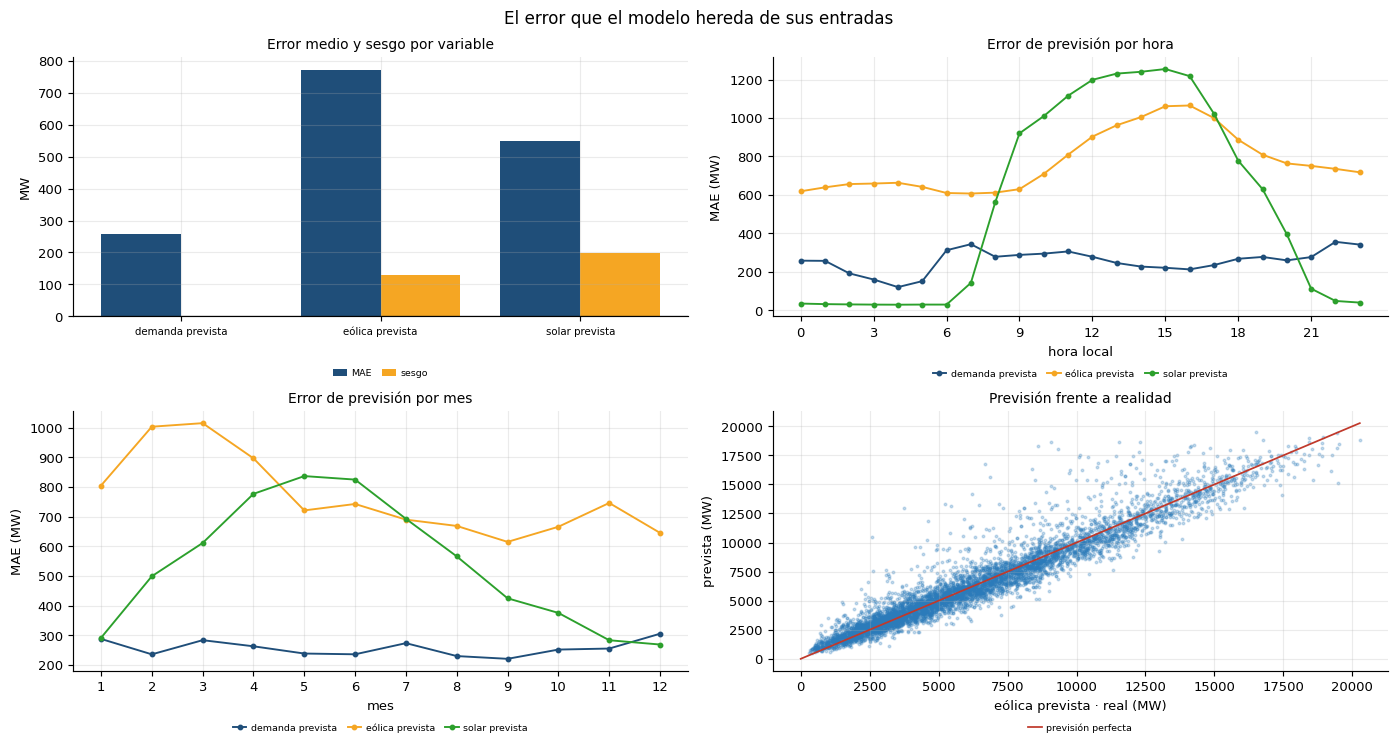

In [123]:
def p_error_barras(ax):
    x = np.arange(len(ERR))
    ax.bar(x - 0.2, ERR["MAE (MW)"], width=0.4, label="MAE", color=PALETA["principal"])
    ax.bar(x + 0.2, ERR["sesgo (MW)"], width=0.4, label="sesgo", color=PALETA["acento"])
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x, ERR.index, fontsize=7); ax.set_ylabel("MW")
    leyenda(ax, ncol=2)

def p_error_hora(ax):
    for etq_, cp, cr in PARES:
        d_ = df[["hora", cp, cr]].dropna().copy()
        d_["err"] = (d_[cp] - d_[cr]).abs()
        ax.plot(d_.groupby("hora")["err"].mean(), marker="o", ms=3, lw=1.3, label=etq_)
    ax.set_xlabel("hora local"); ax.set_ylabel("MAE (MW)"); ax.set_xticks(range(0, 24, 3))
    leyenda(ax, ncol=3)

def p_error_mes(ax):
    for etq_, cp, cr in PARES:
        d_ = df[["mes", cp, cr]].dropna().copy()
        d_["err"] = (d_[cp] - d_[cr]).abs()
        ax.plot(d_.groupby("mes")["err"].mean(), marker="o", ms=3, lw=1.3, label=etq_)
    ax.set_xlabel("mes"); ax.set_ylabel("MAE (MW)"); ax.set_xticks(range(1, 13))
    leyenda(ax, ncol=3)

def p_prev_real(ax):
    etq_, cp, cr = PARES[1] if len(PARES) > 1 else PARES[0]
    d_ = df[[cp, cr]].dropna().sample(min(6000, len(df)), random_state=0)
    ax.scatter(d_[cr], d_[cp], s=3, alpha=0.25, color=PALETA["secundario"])
    lim = [0, max(d_[cr].max(), d_[cp].max())]
    ax.plot(lim, lim, color=PALETA["alerta"], lw=1.2, label="previsión perfecta")
    ax.set_xlabel(f"{etq_} · real (MW)"); ax.set_ylabel("prevista (MW)")
    leyenda(ax, ncol=1)

lamina("L07_calidad_entradas", "El error que el modelo hereda de sus entradas",
       "Las variables realmente disponibles al predecir no son magnitudes observadas sino "
       "previsiones, y una previsión trae su propio error, que el modelo hereda entero. Este "
       "hecho establece un suelo al error alcanzable: ningún algoritmo recupera información que "
       "la entrada no contiene. El sesgo y el error aleatorio tienen consecuencias opuestas —el "
       "primero se corrige antes de entrenar, el segundo no es recuperable—, y los dos paneles "
       "centrales muestran que los tramos en que la entrada falla coinciden con los de mayor "
       "dificultad del objetivo, lo que explica de antemano dónde fallará el modelo.",
       [("Error medio y sesgo por variable", p_error_barras),
        ("Error de previsión por hora", p_error_hora),
        ("Error de previsión por mes", p_error_mes),
        ("Previsión frente a realidad", p_prev_real)])

## L08 · ¿Cómo se forma el precio en el sistema?

  L08_sistema: 4/4 paneles


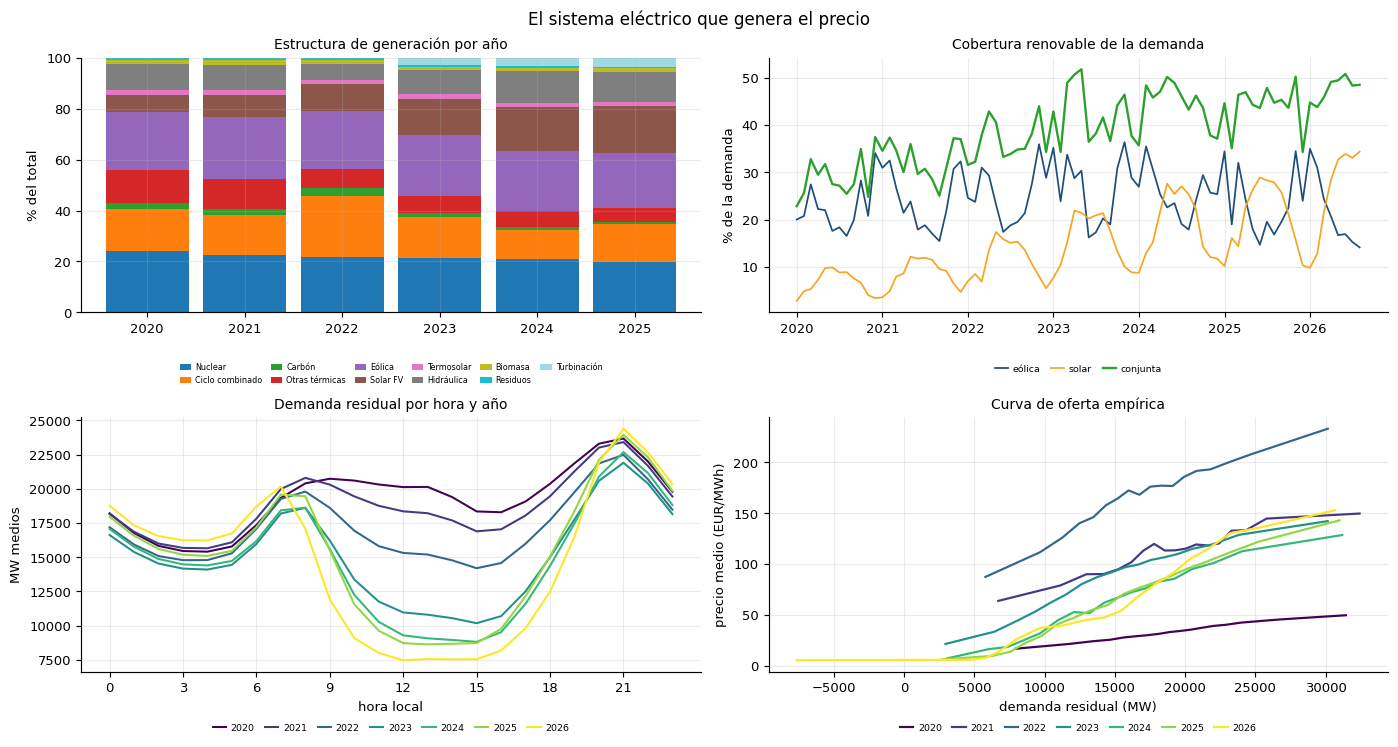

In [124]:
def p_mix(ax):
    mp = mix_pct.loc[completos]
    mp.plot(kind="bar", stacked=True, ax=ax, width=0.85, colormap="tab20", legend=False)
    ax.set_ylabel("% del total"); ax.set_xlabel(""); ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)
    leyenda(ax, ncol=6, tam=5.5)

def p_cobertura(ax):
    mm = df.groupby("mes_p").agg(dem=(DEM, "sum"), eol=(EOL, "sum"), sol=(FV, "sum"))
    t_ = mm.index.to_timestamp()
    ax.plot(t_, mm["eol"] / mm["dem"] * 100, lw=1.2, label="eólica")
    ax.plot(t_, mm["sol"] / mm["dem"] * 100, lw=1.2, label="solar")
    ax.plot(t_, (mm["eol"] + mm["sol"]) / mm["dem"] * 100, lw=1.6, label="conjunta")
    ax.set_ylabel("% de la demanda"); ax.set_xlabel("")
    leyenda(ax, ncol=3)

def p_residual(ax):
    d3 = df[["hora", "anio", DEM, EOL, FV]].dropna().copy()
    d3["residual"] = d3[DEM] - d3[EOL] - d3[FV]
    rs = d3.pivot_table(index="hora", columns="anio", values="residual", aggfunc="mean")
    cmap = plt.get_cmap("viridis")
    for i, a in enumerate(rs.columns):
        ax.plot(rs.index, rs[a], lw=1.4, color=cmap(i / max(len(rs.columns) - 1, 1)), label=str(a))
    ax.set_xlabel("hora local"); ax.set_ylabel("MW medios"); ax.set_xticks(range(0, 24, 3))
    leyenda(ax, ncol=len(rs.columns))

def p_oferta(ax):
    rr = df[["anio", P, DEM, EOL, FV]].dropna().copy()
    rr["residual"] = rr[DEM] - rr[EOL] - rr[FV]
    cmap = plt.get_cmap("viridis"); aa = sorted(rr["anio"].unique())
    for i, a in enumerate(aa):
        sub = rr[rr["anio"] == a]
        tr_ = pd.qcut(sub["residual"], 18, duplicates="drop")
        pf = sub.groupby(tr_, observed=True)[P].mean()
        ax.plot([iv.mid for iv in pf.index], pf.values, lw=1.5,
                color=cmap(i / max(len(aa) - 1, 1)), label=str(a))
    ax.set_xlabel("demanda residual (MW)"); ax.set_ylabel("precio medio (EUR/MWh)")
    leyenda(ax, ncol=len(aa))

lamina("L08_sistema", "El sistema eléctrico que genera el precio",
       "La explicación física de todo lo anterior. La cobertura renovable de la demanda casi se "
       "duplica en el período, y el hueco de mediodía de la demanda residual se profundiza año a "
       "año: ésa es la causa del desplazamiento del perfil horario del precio documentado en la "
       "lámina L02. La curva de oferta empírica —cuánto cuesta cubrir cada nivel de demanda "
       "residual— se desplaza entre años, lo que mide el cambio del parque de generación y "
       "explica por qué una relación estimada sobre el histórico completo no describe el sistema "
       "actual.",
       [("Estructura de generación por año", p_mix),
        ("Cobertura renovable de la demanda", p_cobertura),
        ("Demanda residual por hora y año", p_residual),
        ("Curva de oferta empírica", p_oferta)])

## L09 · ¿Qué condiciona al sistema desde fuera?

  L09_contexto: 4/4 paneles


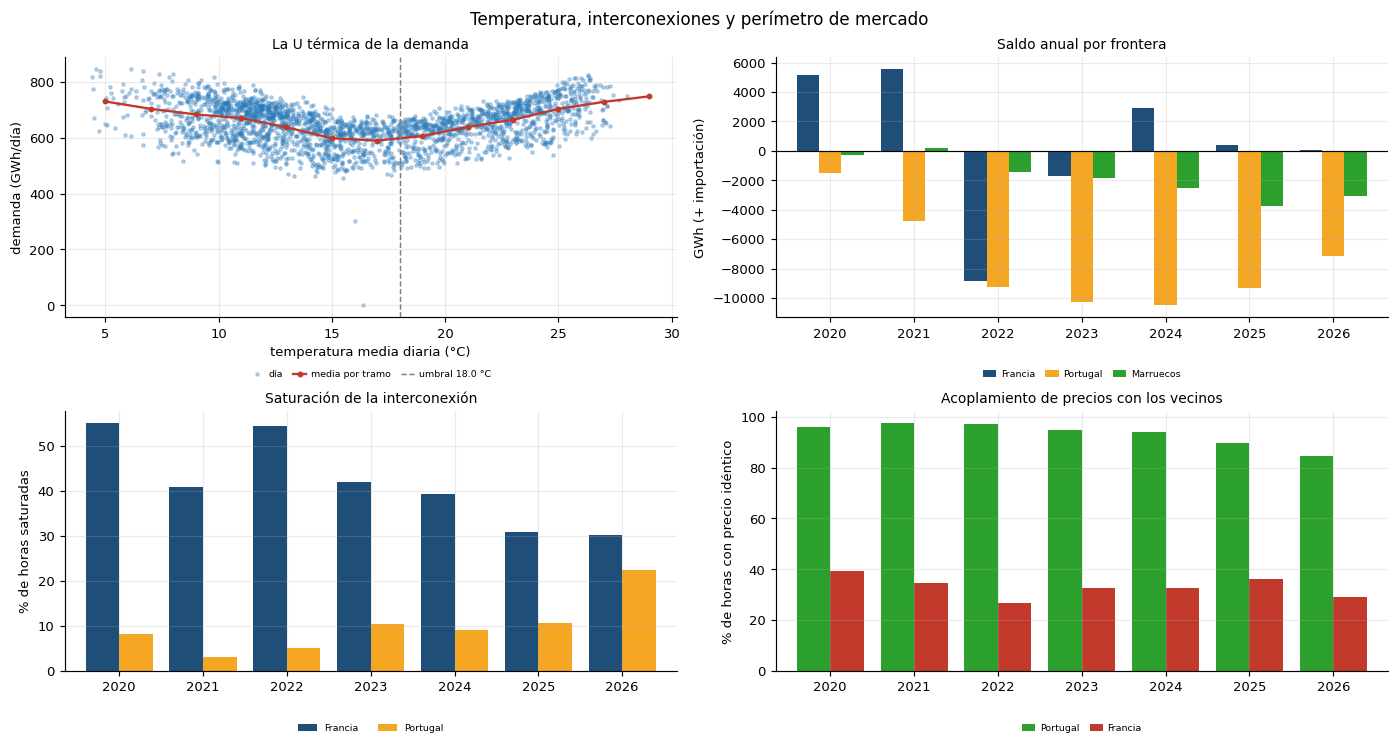

In [125]:
def p_termica(ax):
    ax.scatter(dia_["temp"], dia_["demanda"], s=5, alpha=0.3, color=PALETA["secundario"],
               label="día")
    binned = dia_.groupby(pd.cut(dia_["temp"], bins=np.arange(-2, 34, 2)),
                          observed=True)["demanda"].mean()
    ax.plot([i.mid for i in binned.index], binned.values, marker="o", ms=3, lw=1.6,
            color=PALETA["alerta"], label="media por tramo")
    ax.axvline(UMBRAL_C, color=PALETA["neutro"], ls="--", lw=1, label=f"umbral {UMBRAL_C} °C")
    ax.set_xlabel("temperatura media diaria (°C)"); ax.set_ylabel("demanda (GWh/día)")
    leyenda(ax, ncol=3)

def p_interconexion(ax):
    inter.drop(columns="saldo total", errors="ignore").plot(kind="bar", ax=ax, width=0.8,
                                                            legend=False)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("GWh (+ importación)"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    leyenda(ax, ncol=3)

def p_uso_ntc(ax):
    cols_uso = [c for c in USO.columns if "saturadas" in c]
    USO[cols_uso].plot(kind="bar", ax=ax, width=0.8, legend=False,
                       color=[PALETA["principal"], PALETA["acento"]][:len(cols_uso)])
    ax.set_ylabel("% de horas saturadas"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend([c.split(" · ")[0] for c in cols_uso], loc="upper center",
              bbox_to_anchor=(0.5, -0.17), ncol=2, frameon=False, fontsize=6.5)

def p_acoplamiento(ax):
    filas_ac = []
    for pais, col in [("Portugal", cm.pick(df, "spot_pt_omie", "spot_pt_entsoe")),
                      ("Francia", cm.pick(df, "spot_fr_entsoe"))]:
        if col is None:
            continue
        d_ = df[["anio", P, col]].dropna()
        aco = (d_[P] - d_[col]).abs().le(0.01).groupby(d_["anio"]).mean() * 100
        filas_ac.append(aco.rename(pais))
    AC = pd.concat(filas_ac, axis=1)
    AC.plot(kind="bar", ax=ax, width=0.8, legend=False,
            color=[PALETA["ok"], PALETA["alerta"]][:AC.shape[1]])
    ax.set_ylabel("% de horas con precio idéntico"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    leyenda(ax, ncol=2)

lamina("L09_contexto", "Temperatura, interconexiones y perímetro de mercado",
       "Tres condicionantes externos. La demanda responde a la temperatura en forma de U —sube "
       "con el frío y con el calor—, de modo que un término lineal no la captura y hay que "
       "partirla en grados-día. El saldo de intercambios documenta el paso de España a "
       "exportador neto, señal de que el excedente renovable ya no cabe en el sistema "
       "peninsular, y la saturación de la interconexión explica cuándo el precio español puede "
       "separarse del de sus vecinos. El último panel verifica —en lugar de dar por supuesto— "
       "que España y Portugal forman una sola zona de precio.",
       [("La U térmica de la demanda", p_termica),
        ("Saldo anual por frontera", p_interconexion),
        ("Saturación de la interconexión", p_uso_ntc),
        ("Acoplamiento de precios con los vecinos", p_acoplamiento)])

## L10 · ¿Sirve todo esto para decidir cuándo operar?

  L10_decision: 4/4 paneles


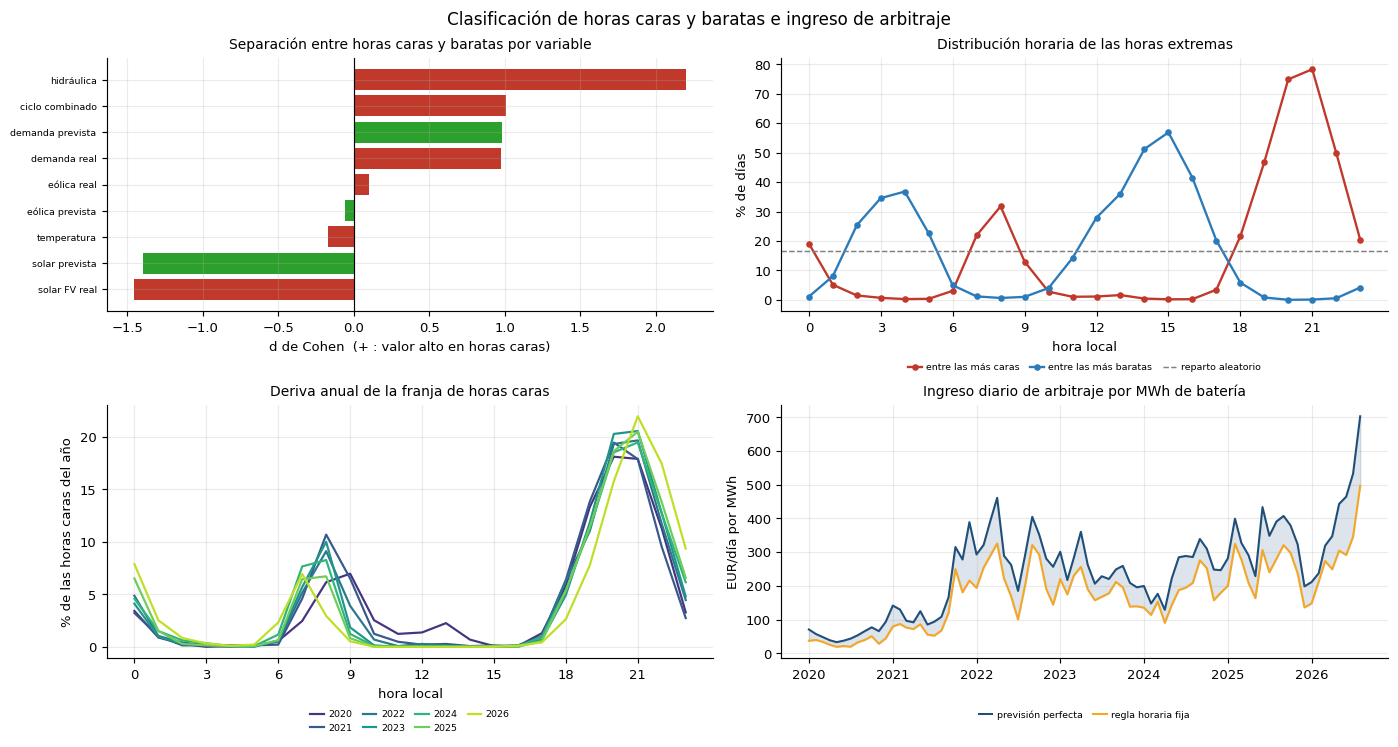

In [126]:
def p_cohen(ax):
    Bs_ = B.sort_values("d de Cohen")
    ax.barh(Bs_.index, Bs_["d de Cohen"],
            color=[COLOR_FUGA.get(f, PALETA["neutro"]) for f in Bs_["disponibilidad"]])
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("d de Cohen  (+ : valor alto en horas caras)")
    ax.tick_params(axis="y", labelsize=6.5)

def p_horas_extremas(ax):
    # De este panel se deduce la regla horaria fija cuyo rendimiento evalúa el panel del
    # ingreso de arbitraje: las horas de descarga son aquellas con mayor probabilidad de
    # resultar caras, y las de carga, aquellas con mayor probabilidad de resultar baratas.
    tab_ = pd.crosstab(CL["hora"], CL["clase"], normalize="index") * 100
    ax.plot(tab_.index, tab_["cara"], marker="o", ms=3.5, lw=1.6,
            color=PALETA["alerta"], label="entre las más caras")
    ax.plot(tab_.index, tab_["barata"], marker="o", ms=3.5, lw=1.6,
            color=PALETA["secundario"], label="entre las más baratas")
    ax.axhline(100 * K_HORAS / 24, color=PALETA["neutro"], ls="--", lw=1,
               label="reparto aleatorio")
    ax.set_xlabel("hora local"); ax.set_ylabel("% de días")
    ax.set_xticks(range(0, 24, 3))
    leyenda(ax, ncol=3)

def p_deriva_franja(ax):
    # El panel anterior promedia los seis años y de ahi sale la regla horaria fija. Aqui
    # se abre por año para ver si esa regla se sostiene: si la franja cara estuviera
    # quieta, bastaria con la regla y el area sombreada del panel de al lado seria
    # residual. Se normaliza dentro de cada año para comparar formas, no volumenes.
    d = CL[CL["clase"] == "cara"].copy()
    d["anio"] = pd.to_datetime(d["dia"]).dt.year
    rep = d.groupby(["anio", "hora"]).size().unstack(0).reindex(range(24)).fillna(0)
    rep = rep.div(rep.sum()) * 100
    colores = plt.cm.viridis(np.linspace(0.15, 0.9, rep.shape[1]))
    for c, (a, s) in zip(colores, rep.items()):
        ax.plot(s.index, s.values, lw=1.5, color=c, label=str(a))
    ax.set_xlabel("hora local"); ax.set_ylabel("% de las horas caras del año")
    ax.set_xticks(range(0, 24, 3))
    leyenda(ax, ncol=4)

def p_arbitraje(ax):
    mm = Eg.resample("MS").mean()
    ax.plot(mm.index, mm["perfecto"], lw=1.4, color=PALETA["principal"],
            label="previsión perfecta")
    ax.plot(mm.index, mm["regla"], lw=1.4, color=PALETA["acento"], label="regla horaria fija")
    ax.fill_between(mm.index, mm["regla"], mm["perfecto"], alpha=0.15, color=PALETA["principal"])
    ax.set_ylabel("EUR/día por MWh"); ax.set_xlabel("")
    leyenda(ax, ncol=2)

lamina("L10_decision", "Clasificación de horas caras y baratas e ingreso de arbitraje",
       "Planteado el problema como una decisión —cargar o descargar— y no como una estimación de "
       "nivel, el análisis entrega tres referencias que la evaluación estadística no proporciona. "
       "La primera es la capacidad de discriminación de cada variable, donde las previsiones "
       "disponibles alcanzan prácticamente el rendimiento de las magnitudes observadas mientras "
       "la generación eólica resulta indistinguible del azar. La segunda es la distribución "
       "horaria de las clases, de la que se deduce una regla de operación fija cuyo rendimiento "
       "evalúa el último panel: esa regla captura ya buena parte del arbitraje posible, de modo "
       "que el margen para un modelo predictivo está acotado y es cuantificable en euros, y "
       "corresponde al área sombreada. La tercera es que esa regla envejece: el reparto horario "
       "de las horas caras se desplaza año a año, de manera que una operación con horario fijo "
       "pierde eficacia con el tiempo y el margen del modelo no es una cantidad estable sino "
       "creciente.",
       [("Separación entre horas caras y baratas por variable", p_cohen),
        ("Distribución horaria de las horas extremas", p_horas_extremas),
        ("Deriva anual de la franja de horas caras", p_deriva_franja),
        ("Ingreso diario de arbitraje por MWh de batería", p_arbitraje)])

## L11 · ¿Cuánta información distinta hay en el conjunto?

  L11_estructura: 4/4 paneles


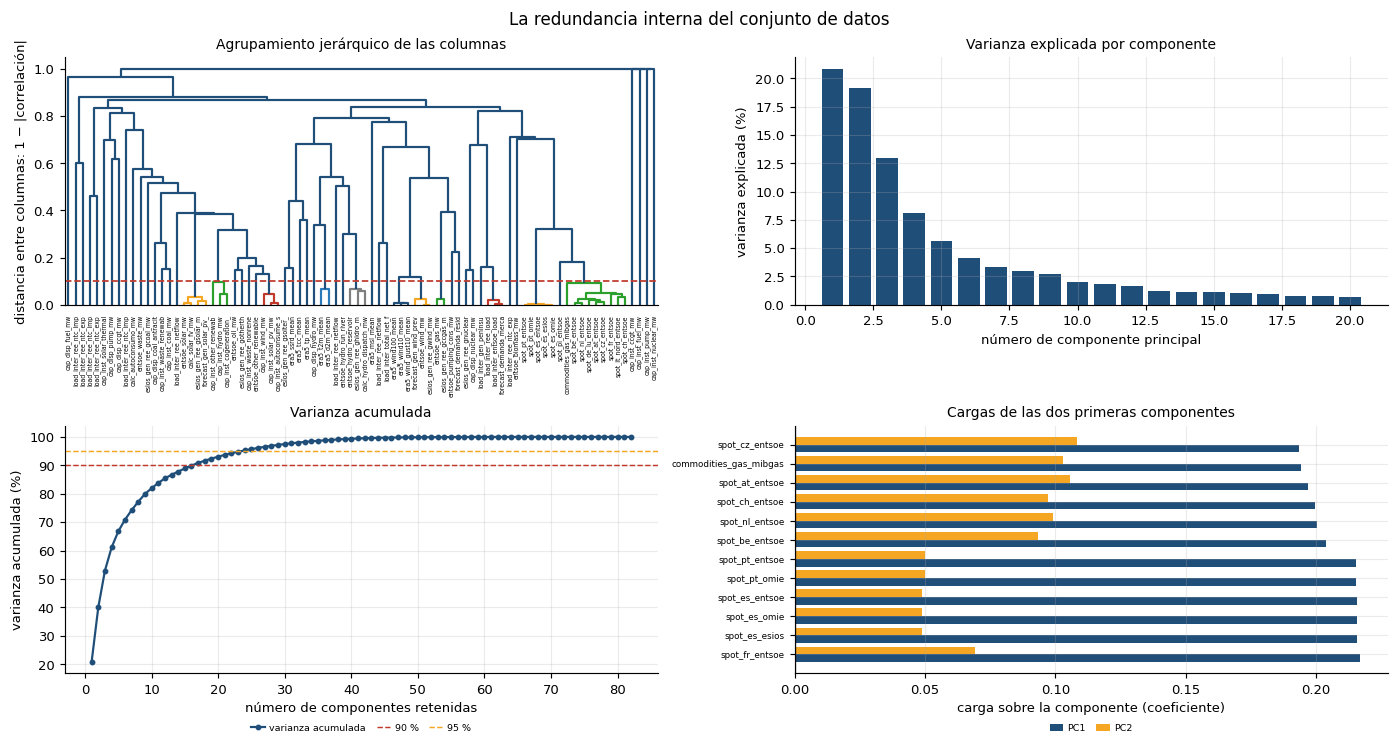

In [127]:
def p_dendro(ax):
    from scipy.cluster.hierarchy import dendrogram
    dendrogram(Z, labels=[c[:22] for c in cols_est], ax=ax,
               color_threshold=UMBRAL_GRUPO, leaf_font_size=4.2)
    ax.axhline(UMBRAL_GRUPO, color=PALETA["alerta"], ls="--", lw=1.2)
    ax.set_ylabel("distancia entre columnas: 1 − |correlación|")
    sin_rejilla(ax)

def p_scree(ax):
    ax.bar(range(1, min(21, len(var) + 1)), var.values[:20], color=PALETA["principal"])
    ax.set_xlabel("número de componente principal"); ax.set_ylabel("varianza explicada (%)")

def p_acumulada(ax):
    ax.plot(range(1, len(acum) + 1), acum.values, marker="o", ms=3, color=PALETA["principal"],
            label="varianza acumulada")
    for u, col in [(90, PALETA["alerta"]), (95, PALETA["acento"])]:
        ax.axhline(u, color=col, ls="--", lw=1, label=f"{u} %")
    ax.set_xlabel("número de componentes retenidas"); ax.set_ylabel("varianza acumulada (%)")
    leyenda(ax, ncol=3)

def p_cargas(ax):
    top = cargas["PC1"].abs().nlargest(12).index
    cg = cargas.loc[top, ["PC1", "PC2"]]
    y = np.arange(len(cg))
    ax.barh(y - 0.2, cg["PC1"], height=0.4, label="PC1", color=PALETA["principal"])
    ax.barh(y + 0.2, cg["PC2"], height=0.4, label="PC2", color=PALETA["acento"])
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(y, [c[:26] for c in cg.index], fontsize=6)
    ax.set_xlabel("carga sobre la componente (coeficiente)")
    leyenda(ax, ncol=2)

lamina("L11_estructura", "La redundancia interna del conjunto de datos",
       "Las columnas del conjunto no son piezas independientes de información. El agrupamiento "
       "jerárquico identifica bloques que se comportan como una sola variable, de los que basta "
       "conservar un miembro, y el análisis de componentes principales mide la dimensionalidad "
       "efectiva: una fracción reducida de componentes explica la mayor parte de la varianza. "
       "Las cargas de las dos primeras componentes muestran, además, por qué esas componentes no "
       "pueden usarse como variables del modelo: mezclan columnas con etiquetas de "
       "disponibilidad distintas, y una combinación de una previsión con una generación real es "
       "inutilizable en producción por mucha varianza que explique.",
       [("Agrupamiento jerárquico de las columnas", p_dendro),
        ("Varianza explicada por componente", p_scree),
        ("Varianza acumulada", p_acumulada),
        ("Cargas de las dos primeras componentes", p_cargas)])

## L12 · ¿Por qué cambió la estructura del precio?

  L12_parque_precio: 4/4 paneles


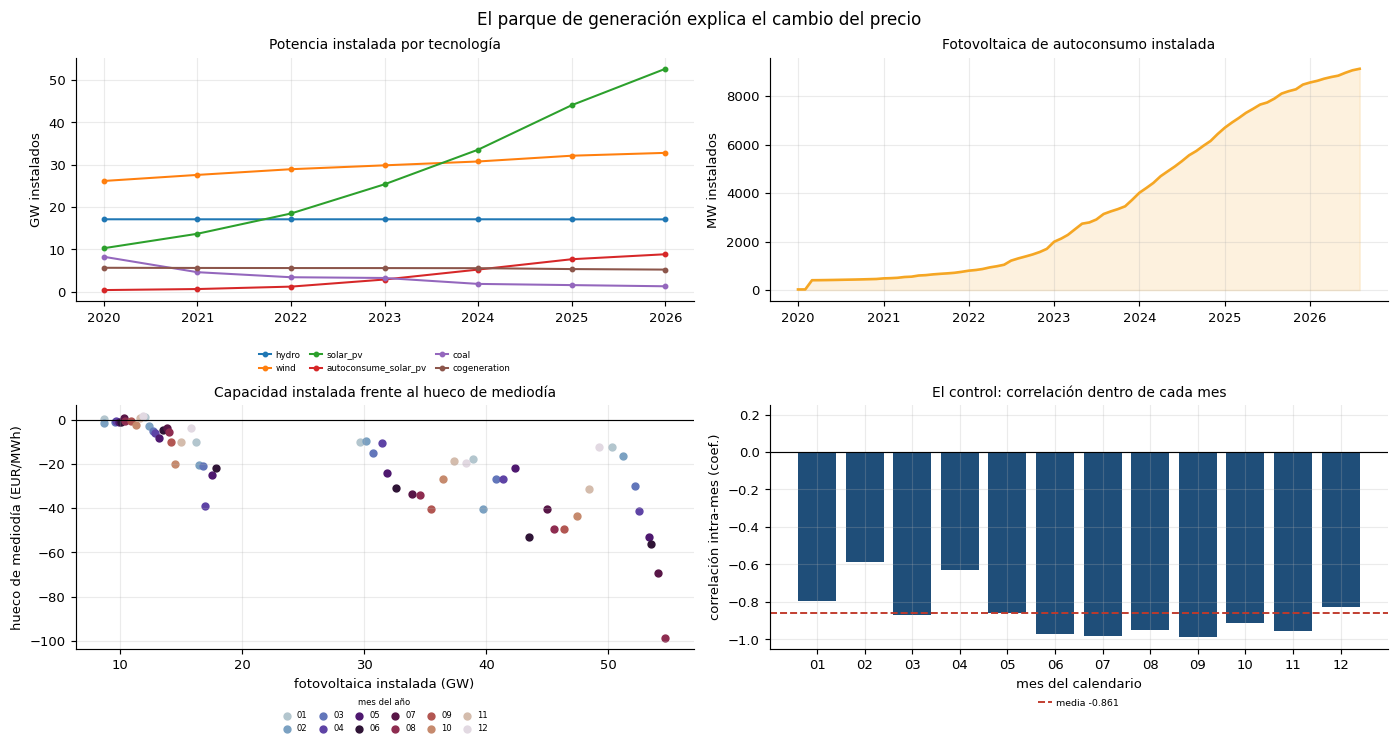

In [128]:
def p_parque(ax):
    cmap = plt.get_cmap("tab10")
    grandes = [c for c in crecen.columns if crecen[c].max() > 1500]
    for i, c in enumerate(grandes):
        ax.plot(crecen.index, crecen[c] / 1000, marker="o", ms=3, lw=1.4,
                color=cmap(i % 10), label=c)
    ax.set_ylabel("GW instalados"); ax.set_xlabel("")
    leyenda(ax, ncol=3, tam=6)

def p_autoconsumo_cap(ax):
    if not AUTO_CAP:
        raise ValueError("sin columna de autoconsumo instalado")
    s_ = df.groupby("mes_p")[AUTO_CAP].mean().dropna()
    ax.plot(s_.index.to_timestamp(), s_.values, lw=1.8, color=PALETA["acento"])
    ax.fill_between(s_.index.to_timestamp(), 0, s_.values, alpha=0.15, color=PALETA["acento"])
    ax.set_ylabel("MW instalados"); ax.set_xlabel("")

def p_fv_hueco(ax):
    cmap = plt.get_cmap("twilight")
    for mm in sorted(MES["mes"].unique()):
        sub = MES[MES["mes"] == mm]
        ax.scatter(sub["fv_instalada"] / 1000, sub["hueco_mediodia"], s=22, color=cmap(mm / 12),
                   label=f"{mm:02d}")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("fotovoltaica instalada (GW)")
    ax.set_ylabel("hueco de mediodía (EUR/MWh)")
    leyenda(ax, ncol=6, titulo="mes del año", tam=5.8)

def p_intra_mes(ax):
    ax.bar([f"{m:02d}" for m in intra.index], intra.values, color=PALETA["principal"])
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(intra.mean(), color=PALETA["alerta"], ls="--", lw=1.3,
               label=f"media {intra.mean():+.3f}")
    ax.set_ylim(-1.05, 0.25)
    ax.set_xlabel("mes del calendario"); ax.set_ylabel("correlación intra-mes (coef.)")
    leyenda(ax, ncol=1)

lamina("L12_parque_precio", "El parque de generación explica el cambio del precio",
       "La lámina cierra el argumento central del análisis. Los dos paneles superiores "
       "documentan la transformación del parque: la fotovoltaica se multiplica por seis y el "
       "autoconsumo pasa de ser testimonial a superar los nueve gigavatios. Los dos inferiores "
       "la conectan con el precio. El tercero muestra que cuanta más potencia fotovoltaica hay "
       "instalada, más profundo es el hueco de precio del mediodía. Y el cuarto responde a la "
       "objeción obligada —que ambas series simplemente crecen con el tiempo— midiendo la "
       "relación dentro de cada mes del calendario, donde la estacionalidad queda fijada: es "
       "negativa en los doce meses. La no estacionariedad del precio deja así de ser una "
       "limitación que hay que soportar y pasa a ser un efecto con una causa medible, "
       "disponible como variable explicativa.",
       [("Potencia instalada por tecnología", p_parque),
        ("Fotovoltaica de autoconsumo instalada", p_autoconsumo_cap),
        ("Capacidad instalada frente al hueco de mediodía", p_fv_hueco),
        ("El control: correlación dentro de cada mes", p_intra_mes)])

## 10.1 · La lámina del capítulo

Las doce láminas anteriores documentan el análisis y constituyen el anexo. La memoria selecciona
tres, correspondientes a los eslabones primero, tercero y quinto del hilo argumental, que son los
que no pueden enunciarse sin evidencia visual.

Dos de ellas —**L05**, los dos rankings de disponibilidad en la misma escala, y **L10**, la
traducción económica— sirven tal como están. La primera requiere recomponerse.

**El motivo.** El primer eslabón sostiene que el perfil horario del precio se invierte a lo largo
del período, desplazándose la hora más barata de la madrugada al mediodía. Es la afirmación
central del capítulo, y el panel que la demuestra —el perfil horario por año— pertenece a la
lámina L02, mientras que L01 reúne la serie diaria, la distribución, la composición por rango y
la curva de duración. La lámina siguiente toma de cada una los paneles que sostienen el
argumento.

  F1_objetivo: 4/4 paneles


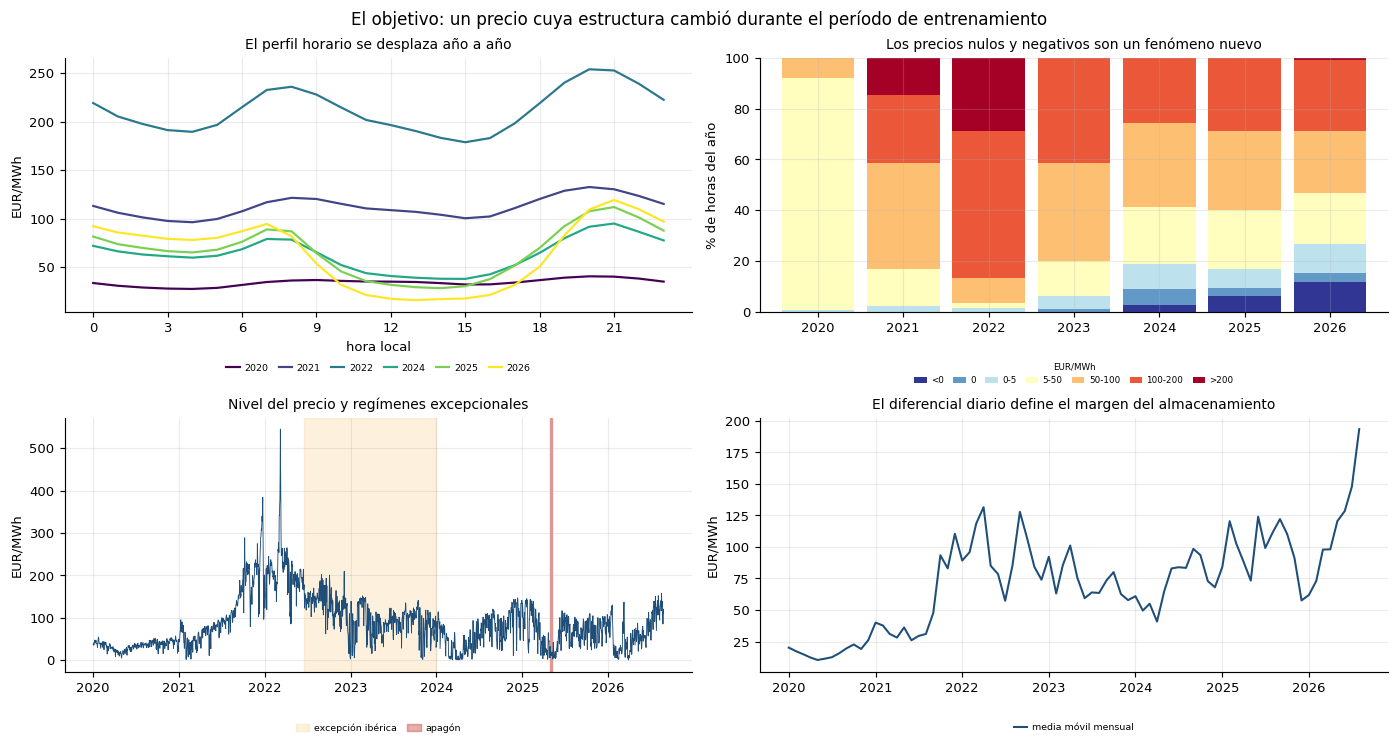

In [129]:
# Esta celda depende de utilidades definidas en apartados anteriores. Si el cuaderno se
# reabre y el núcleo pierde su estado, basta con haber ejecutado el apartado 1 —la carga
# del conjunto— para que lo que falte se reconstruya aquí.
_faltan = [n for n in ("df", "P", "NORMAL", "PALETA", "EXCEPCION", "APAGON")
           if n not in globals()]
if _faltan:
    raise RuntimeError(
        f"Faltan {_faltan}. Ejecutar el apartado 1 (carga del conjunto) antes de esta celda."
    )

# Reconstrucción de las utilidades de composición, por si no están en memoria.
if "leyenda" not in globals():
    def leyenda(ax, ncol=1, loc="best"):
        ax.legend(frameon=False, fontsize=6.5, ncol=ncol, loc=loc)

if "FIGURAS" not in globals():
    FIGURAS = RAIZ / "docs" / "figuras" / "eda"
    FIGURAS.mkdir(parents=True, exist_ok=True)

if "LAMINAS" not in globals():
    LAMINAS = []

if "lamina" not in globals():
    def lamina(etq, titulo, pie, paneles, ncol=2, alto=3.5):
        """Compone los paneles en una figura de página y registra su pie."""
        nfil = int(np.ceil(len(paneles) / ncol))
        fig, axes = plt.subplots(nfil, ncol, figsize=(6.6 * ncol, alto * nfil))
        ejes = np.atleast_1d(axes).ravel()
        fallos = 0
        for ax, (sub, fn) in zip(ejes, paneles):
            try:
                fn(ax)
                ax.set_title(sub, fontsize=9.5)
            except Exception as e:
                fallos += 1
                ax.clear(); ax.axis("off")
                ax.text(0.5, 0.5, f"{sub}\n\nsin datos\n({type(e).__name__})",
                        ha="center", va="center", fontsize=8, color=PALETA["neutro"])
        for ax in ejes[len(paneles):]:
            ax.axis("off")
        fig.suptitle(titulo, fontsize=11.5, y=1.003)
        plt.tight_layout()
        fig.savefig(FIGURAS / f"{etq}.png", dpi=200, bbox_inches="tight")
        LAMINAS.append({"lámina": etq, "título": titulo, "pie": pie,
                        "paneles": len(paneles), "fallos": fallos})
        print(f"  {etq}: {len(paneles) - fallos}/{len(paneles)} paneles")
        plt.show(); plt.close(fig)

# Los cuatro paneles del capítulo. Se redefinen únicamente si no están en memoria.
if "p_serie" not in globals():
    def p_serie(ax):
        s_ = df.groupby("dia")[P].mean()
        ax.plot(pd.to_datetime(s_.index), s_.values, lw=0.6, color=PALETA["principal"])
        ax.axvspan(EXCEPCION[0].tz_localize(None), EXCEPCION[1].tz_localize(None),
                   alpha=0.15, color=PALETA["acento"], label="excepción ibérica")
        ax.axvspan(APAGON[0].tz_localize(None), APAGON[1].tz_localize(None),
                   alpha=0.40, color=PALETA["alerta"], label="apagón")
        ax.set_ylabel("EUR/MWh")
        leyenda(ax, ncol=2)

if "p_composicion" not in globals():
    def p_composicion(ax):
        bins = [-np.inf, 0, 0.001, 5, 50, 100, 200, np.inf]
        etq = ["<0", "0", "0-5", "5-50", "50-100", "100-200", ">200"]
        t = pd.crosstab(df["anio"], pd.cut(df[P], bins=bins, labels=etq, right=False))
        (t.div(t.sum(axis=1), axis=0) * 100).plot(kind="bar", stacked=True, ax=ax,
                                                  width=0.85, colormap="RdYlBu_r", legend=False)
        ax.set_ylabel("% de horas del año"); ax.set_xlabel("")
        leyenda(ax, ncol=4)

if "p_perfil_anio" not in globals():
    def p_perfil_anio(ax):
        perf = NORMAL.pivot_table(index="hora", columns="anio", values=P, aggfunc="mean")
        cmap = plt.get_cmap("viridis")
        for i, a in enumerate(perf.columns):
            ax.plot(perf.index, perf[a], lw=1.5,
                    color=cmap(i / max(len(perf.columns) - 1, 1)), label=str(a))
        ax.set_xlabel("hora local"); ax.set_ylabel("EUR/MWh"); ax.set_xticks(range(0, 24, 3))
        leyenda(ax, ncol=len(perf.columns))

if "p_diferencial" not in globals():
    def p_diferencial(ax):
        sp_ = df.groupby("dia")[P].agg(["min", "max"]).dropna()
        sp_.index = pd.to_datetime(sp_.index)
        dif = (sp_["max"] - sp_["min"]).resample("MS").mean()
        ax.plot(dif.index, dif.values, lw=1.4, color=PALETA["principal"])
        ax.set_ylabel("EUR/MWh"); ax.set_xlabel("")


lamina(
    "F1_objetivo",
    "El objetivo: un precio cuya estructura cambió durante el período de entrenamiento",
    "El perfil horario del precio se transforma a lo largo del período analizado: la hora más "
    "barata se desplaza de la madrugada al mediodía y la amplitud entre la hora más cara y la "
    "más barata se multiplica. La composición por rango muestra que las horas de precio nulo o "
    "negativo constituyen un fenómeno que aparece a mitad del histórico y crece cada año, y no "
    "una cola de la distribución. La serie diaria sitúa el nivel y delimita los dos períodos que "
    "responden a otro mecanismo de formación de precios, y el diferencial diario cuantifica el "
    "margen que aprovecha el almacenamiento. En conjunto describen un objetivo no estacionario, "
    "cuya predicción exige ponderar el histórico de forma no uniforme.",
    [("El perfil horario se desplaza año a año", p_perfil_anio),
     ("Los precios nulos y negativos son un fenómeno nuevo", p_composicion),
     ("Nivel del precio y regímenes excepcionales", p_serie),
     ("El diferencial diario define el margen del almacenamiento", p_diferencial)],
)

### Selección definitiva

| # | Lámina | Eslabón del hilo | Estado |
|---|---|---|---|
| 1 | **F1 · El objetivo** | 1 · qué hay que predecir | recompuesta |
| 2 | **L05 · Drivers y frontera** | 3 · qué puede usarse | sin cambios |
| 3 | **L10 · La decisión** | 5 · contra qué se compara | sin cambios |

Los eslabones segundo y cuarto —la causa del cambio y el error heredado de las previsiones— se
sostienen con su cifra en el texto, remitiendo al anexo. Sus resultados son autoexplicativos y no
requieren evidencia visual para entenderse, a diferencia de la comparación entre rankings del
eslabón tercero, que sólo se aprecia mirándolos.

## 10.2 · Cifras para el texto de la memoria

Cada eslabón del hilo argumental se apoya en una cifra. Se reúnen aquí para su cita directa,
evitando que la memoria reproduzca las tablas completas del análisis.

In [130]:
CIFRAS = {}

# --- El objetivo no es estable a lo largo del período
perf_f = NORMAL.pivot_table(index="hora", columns="anio", values=P, aggfunc="mean")
amp_f = perf_f.max() - perf_f.min()
CIFRAS["Amplitud del perfil horario, primer año"] = f"{amp_f.iloc[0]:.0f} EUR/MWh"
CIFRAS["Amplitud del perfil horario, último año"] = f"{amp_f.iloc[-1]:.0f} EUR/MWh"
CIFRAS["Hora del mínimo, primer año"] = f"{perf_f.idxmin().iloc[0]}:00"
CIFRAS["Hora del mínimo, último año"] = f"{perf_f.idxmin().iloc[-1]}:00"

neg_f = df[df[P] <= 0].groupby("anio").size()
if len(neg_f):
    CIFRAS["Horas con precio nulo o negativo, último año"] = f"{neg_f.iloc[-1]:,}"

sp_f = df.groupby("dia")[P].agg(["min", "max"]).dropna()
dif_f = (sp_f["max"] - sp_f["min"]).groupby(pd.to_datetime(sp_f.index).year).mean()
CIFRAS["Diferencial diario medio, primer año"] = f"{dif_f.iloc[0]:.0f} EUR/MWh"
CIFRAS["Diferencial diario medio, último año"] = f"{dif_f.iloc[-1]:.0f} EUR/MWh"

# --- La frontera de disponibilidad, si el apartado correspondiente está en memoria
if "num" in globals() and "fuga_de" in globals():
    utiles = sum(1 for c in num if fuga_de(c, P) in ("SIN FUGA", "DESFASE D-2"))
    CIFRAS["Variables numéricas del conjunto"] = f"{len(num)}"
    CIFRAS["Variables disponibles al predecir"] = f"{utiles} ({utiles / len(num) * 100:.0f} %)"

# --- El error heredado de las previsiones
if "PARES" in globals():
    for etq_f, cp_f, cr_f in PARES:
        if cp_f in df.columns and cr_f in df.columns:
            dd = df[[cp_f, cr_f]].dropna()
            err_f = dd[cp_f] - dd[cr_f]
            CIFRAS[f"Error de la previsión de {etq_f}"] = \
                f"MAE {err_f.abs().mean():.0f} MW · sesgo {err_f.mean():+.0f} MW"

print("CIFRAS PARA EL TEXTO")
print("=" * 66)
for k_f, v_f in CIFRAS.items():
    print(f"  {k_f:46s} {v_f}")

CIFRAS PARA EL TEXTO
  Amplitud del perfil horario, primer año        13 EUR/MWh
  Amplitud del perfil horario, último año        103 EUR/MWh
  Hora del mínimo, primer año                    4:00
  Hora del mínimo, último año                    13:00
  Horas con precio nulo o negativo, último año   879
  Diferencial diario medio, primer año           17 EUR/MWh
  Diferencial diario medio, último año           114 EUR/MWh
  Variables numéricas del conjunto               86
  Variables disponibles al predecir              22 (26 %)
  Error de la previsión de demanda prevista      MAE 257 MW · sesgo +1 MW
  Error de la previsión de eólica prevista       MAE 772 MW · sesgo +129 MW
  Error de la previsión de solar prevista        MAE 547 MW · sesgo +198 MW


## 10.3 · Los pies de las tres láminas seleccionadas

Los pies se generan del propio análisis, de modo que se mantienen consistentes con las cifras si
el cuaderno se reejecuta sobre datos actualizados.

In [131]:
SELECCION = ["F1_objetivo", "L05_drivers", "L10_decision"]

if "LAMINAS" not in globals() or not LAMINAS:
    print("No hay láminas registradas en esta ejecución.")
else:
    registro = pd.DataFrame(LAMINAS)
    for orden, etq_l in enumerate(SELECCION, start=1):
        fila = registro[registro["lámina"] == etq_l]
        if fila.empty:
            print(f"Figura {orden} — {etq_l}: no generada en esta ejecución.\n")
            continue
        fila = fila.iloc[0]
        print(f"FIGURA {orden} — {fila['título']}")
        print(f"  archivo: {FIGURAS / (etq_l + '.png')}")
        print(f"  paneles: {fila['paneles'] - fila['fallos']}/{fila['paneles']}")
        print(f"  pie: {fila['pie']}\n")

FIGURA 1 — El objetivo: un precio cuya estructura cambió durante el período de entrenamiento
  archivo: C:\Users\torgi\proyectos\tfm-energia\docs\figuras\eda\F1_objetivo.png
  paneles: 4/4
  pie: El perfil horario del precio se transforma a lo largo del período analizado: la hora más barata se desplaza de la madrugada al mediodía y la amplitud entre la hora más cara y la más barata se multiplica. La composición por rango muestra que las horas de precio nulo o negativo constituyen un fenómeno que aparece a mitad del histórico y crece cada año, y no una cola de la distribución. La serie diaria sitúa el nivel y delimita los dos períodos que responden a otro mecanismo de formación de precios, y el diferencial diario cuantifica el margen que aprovecha el almacenamiento. En conjunto describen un objetivo no estacionario, cuya predicción exige ponderar el histórico de forma no uniforme.

FIGURA 2 — Los drivers del precio y la frontera de disponibilidad
  archivo: C:\Users\torgi\proyectos\tfm-

## 10.4 · Índice de láminas

Recoge las doce láminas del anexo y la lámina recompuesta del capítulo.


In [132]:
IDX = pd.DataFrame(LAMINAS)
display(IDX[["lámina", "título", "paneles", "fallos"]].set_index("lámina"))
total = IDX["paneles"].sum(); mal = IDX["fallos"].sum()
print(f"{len(IDX)} láminas · {total} paneles · {total - mal} correctos"
      + (f" · {mal} con incidencia" if mal else ""))
print(f"\nFicheros PNG en {FIGURAS.relative_to(cm.RAIZ)}")

# Pies de figura listos para pegar en la memoria.
print("\n" + "=" * 78)
print("PIES DE FIGURA")
print("=" * 78)
for _, f in IDX.iterrows():
    print(f"\n{f['lámina']} — {f['título']}")
    print(f"  {f['pie']}")

,título,paneles,fallos
lámina,,,
L01_objetivo,"El precio: nivel, colas, composición y duración",4,0
L02_estructura_temporal,La estructura temporal del precio,4,0
L03_persistencia,La dependencia del precio de su propio pasado,4,0
L04_calidad,La calidad del conjunto de datos y las decisio...,4,0
L05_drivers,Los drivers del precio y la frontera de dispon...,4,0
L06_asociacion_temporal,La asociación vista como serie temporal,4,0
L07_calidad_entradas,El error que el modelo hereda de sus entradas,4,0
L08_sistema,El sistema eléctrico que genera el precio,4,0
L09_contexto,"Temperatura, interconexiones y perímetro de me...",4,0


13 láminas · 52 paneles · 52 correctos

Ficheros PNG en docs\figuras\eda

PIES DE FIGURA

L01_objetivo — El precio: nivel, colas, composición y duración
  Cuatro vistas del objetivo. La distribución se representa en escala lineal, que es donde se lee el cuerpo de las observaciones, y las colas se cuantifican en la curva de duración, que dice cuántas horas al año se supera cada nivel. La composición por rango muestra que los precios nulos y negativos aparecen a mitad del histórico y crecen cada año: el problema cambió de naturaleza durante el propio período de entrenamiento, lo que condiciona cómo debe ponderarse el histórico.

L02_estructura_temporal — La estructura temporal del precio
  El perfil horario cambia de forma a lo largo del período: la hora barata se desplaza de la madrugada al mediodía y la amplitud del día se multiplica. Los dos mapas de calor separan las dos estacionalidades que conviven —la anual y la semanal— y el diferencial diario cuantifica lo único que una batería 

---
## Cierre

**Lo que este análisis establece para las fases siguientes:**

*Sobre el conjunto de datos.* Las decisiones de fuente tomadas durante la ingesta se confirman
con evidencia propia, y quedan documentadas cuatro incidencias de calidad con su corrección: la
convención asimétrica del bombeo, los ceros espurios de la demanda, la previsión que se reescribe
retroactivamente y dos valores físicamente imposibles pendientes de resolver.

*Sobre el problema.* La estructura horaria del precio no es estable a lo largo del período de
entrenamiento, lo que condiciona cómo debe ponderarse el histórico. El precio se explica en buena
medida a sí mismo, lo que fija una referencia mínima exigente para cualquier variable exógena. Y
las variables realmente disponibles en el momento de predecir son previsiones cuyo error el
modelo hereda entero, lo que establece un suelo al error alcanzable.

*Sobre el objetivo final.* Una regla horaria trivial ya captura buena parte del arbitraje
posible, de modo que el margen para un modelo predictivo está acotado y es cuantificable en
euros. Y el coste de los distintos tipos de error es asimétrico, lo que aconseja complementar las
métricas estadísticas con medidas económicas en la validación.

*Sobre el método.* La comprobación del apartado 4.0 obligó a rehacer el análisis de asociación
sobre un marco diario: en la rejilla horaria, cualquier par que cruce dos frecuencias de
publicación se calcula sobre una fracción minúscula de las filas, y en algún caso sobre ninguna.
Es un artefacto de la unión que produce coeficientes con apariencia normal, y de no haberse
verificado habría contaminado todas las conclusiones del bloque 4.

**Limitaciones identificadas.** El análisis deja constancia de cuatro limitaciones que acotan el
alcance de las conclusiones posteriores: el carácter de cota superior optimista de cualquier
resultado que incorpore variables meteorológicas, la revisión retroactiva de una de las tablas de
previsiones, la verificación pendiente sobre la potencia disponible descrita en el bloque 2, y
las cuatro líneas de análisis que el apartado 10.2 declara fuera de alcance por no estar sus
tablas incorporadas al conjunto unificado.

**Sobre el instrumental empleado.** Los procedimientos con que se ha trabajado aquí son
descriptivos y transfieren sin reservas a una serie temporal. Los que sí exigen adaptación
—tratamiento de atípicos, imputación, transformaciones y selección de variables— no se emplean en
este cuaderno, sino en el siguiente, y su discusión se encuentra por tanto en el apartado 0.2 de
`02_ingenieria_variables.ipynb`, junto a las operaciones que justifica.

**Lo que este cuaderno deliberadamente no hace.** No corrige ningún valor, no construye ninguna
variable y no selecciona ninguna. Todo eso ocurre en `02_ingenieria_variables.ipynb`, después de
la partición temporal y bajo el filtro de la frontera de disponibilidad declarada en el
apartado 0.1.